[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Forecasting_Electricity_Demand_RNN.ipynb)

# Forecasting Electricity Demand with an RNN
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

You work for the utility. Every hour, the grid has to serve whatever Connecticut demands - and the dispatch desk wants to know **tomorrow's hourly load** today. This is the Assignment 2 dataset (hourly demand plus Bradley airport weather, 2011-2021), now treated the way it deserves: as a **sequence**.

By the end you'll have: the three dumb baselines every forecast must beat, a univariate LSTM (last 24 hours -> next hour), a multivariate LSTM that also sees the weather, a **24-hour-ahead** multi-step model, and a peak-hour classifier - all on the same business question.

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 16 — Forecasting electricity demand, Pt 1: data, baselines, a univariate LSTM
- The business question: you are the utility, forecast tomorrow's hourly load. Same dataset as Assignment 2 - now as a SEQUENCE.
- The file is UNSORTED - show is_monotonic_increasing == False before and after the sort. Never trust that a time series arrives in order.
- EDA beats: one July week (daily peaks at 6 PM), hour-of-day profile (2,790 at midnight -> ~3,990 at 6 PM), month profile (summer AC and winter heat, cheap shoulders), demand vs temperature is a U (heating on the left, cooling on the right), and the 2020 COVID dip = distribution shift.
- Chronological split: 2017-2018 train, 2019 test. No shuffle - say why.
- Baselines FIRST: mean-only (554 MW), same-hour-yesterday (227), last-hour persistence (129). Persistence at one hour ahead is brutal - that's the villain.
- Univariate LSTM: scale on train only, look-back 24 -> next hour, LSTM(32) + Dense(1), early stopping. Read the MAE against 129: the LSTM lands at ~44 MW - it beats persistence by 3x because two years of history taught it the daily shape, not just the last value.
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
import keras
keras.utils.set_random_seed(5509)   # reproducibility: same numbers every run (CPU exact; a GPU may drift a little)

## Read in the data - and sort it!

The file is not in date order. `df.info()` won't tell you that; you have to ask.

In [2]:
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/BDL_cleanweather_energy.csv"
df = pd.read_csv(url, parse_dates=["Datetime"])
print("rows:", len(df), "| in date order?", df["Datetime"].is_monotonic_increasing)

df = df.sort_values("Datetime").set_index("Datetime")
print("after sorting - in date order?", df.index.is_monotonic_increasing, "| span:", df.index.min().date(), "->", df.index.max().date())

df = df.ffill()          # 0.3% of the weather rows are missing - carry the last reading forward (fine at hourly cadence)
df.info()

rows: 96427 | in date order? False
after sorting - in date order? True | span: 2011-01-01 -> 2021-12-31
<class 'pandas.DataFrame'>
DatetimeIndex: 96427 entries, 2011-01-01 00:00:00 to 2021-12-31 23:00:00
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Demand    96427 non-null  float64
 1   BDL_tmpf  96427 non-null  float64
 2   BDL_dwpf  96427 non-null  float64
 3   BDL_relh  96427 non-null  float64
 4   BDL_drct  96427 non-null  float64
 5   BDL_sknt  96427 non-null  float64
 6   BDL_p01i  96427 non-null  float64
 7   BDL_alti  96427 non-null  float64
 8   BDL_mslp  96427 non-null  float64
 9   BDL_vsby  96427 non-null  float64
dtypes: float64(10)
memory usage: 8.1 MB


In [3]:
df.describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
Demand,96427.0,3388.6,761.5,1372.0,2843.0,3333.4,3813.0,7219.0
BDL_tmpf,96427.0,52.0,19.3,-11.0,36.0,52.0,68.0,102.0
BDL_dwpf,96427.0,39.7,19.7,-27.0,25.0,41.0,55.9,78.1
BDL_relh,96427.0,65.6,21.4,0.0,49.5,66.6,84.5,100.0
BDL_drct,96427.0,221.3,118.6,0.0,170.0,230.0,330.0,360.0
BDL_sknt,96427.0,7.6,4.8,0.0,4.0,7.0,10.0,40.0
BDL_p01i,96427.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
BDL_alti,96427.0,30.0,0.3,0.0,29.9,30.0,30.2,30.8
BDL_mslp,96427.0,1010.0,80.9,0.0,1011.1,1016.3,1021.5,1044.7
BDL_vsby,96427.0,9.3,2.0,0.0,10.0,10.0,10.0,10.0


## EDA: the shape of demand

Before any model - what does a week look like, what does a day look like, what does a year look like, and what does temperature do to it?

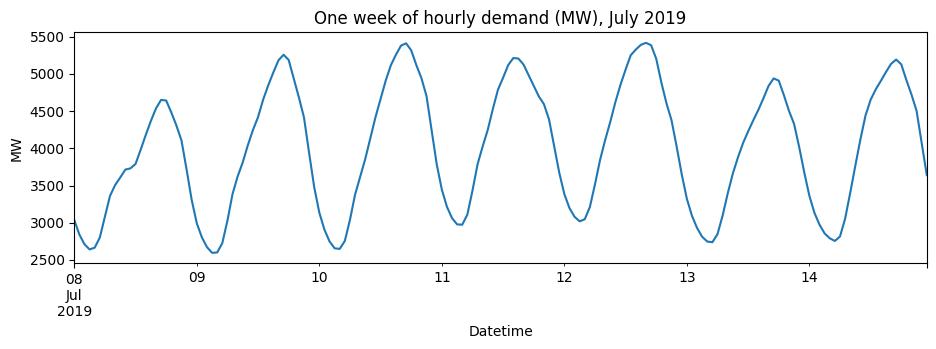

In [4]:
# one summer week - daily peaks in the evening, lower weekend load
wk = df.loc["2019-07-08":"2019-07-14", "Demand"]
wk.plot(figsize=(11, 3), title="One week of hourly demand (MW), July 2019"); plt.ylabel("MW"); plt.show()

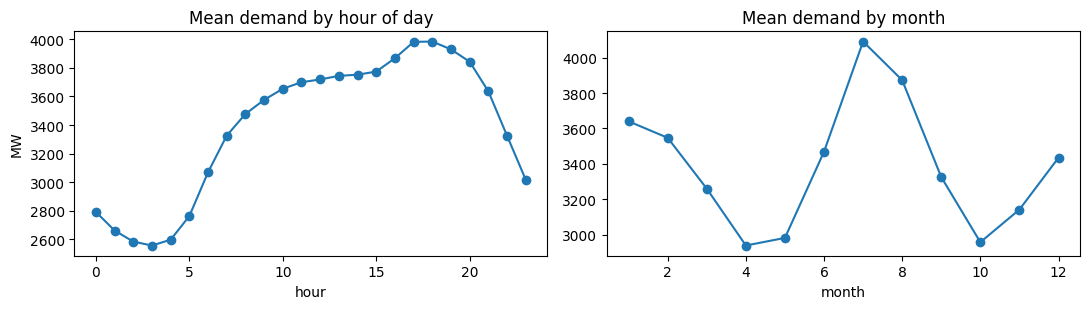

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
df.groupby(df.index.hour)["Demand"].mean().plot(ax=ax[0], marker="o", title="Mean demand by hour of day"); ax[0].set_xlabel("hour"); ax[0].set_ylabel("MW")
df.groupby(df.index.month)["Demand"].mean().plot(ax=ax[1], marker="o", title="Mean demand by month"); ax[1].set_xlabel("month")
plt.tight_layout(); plt.show()

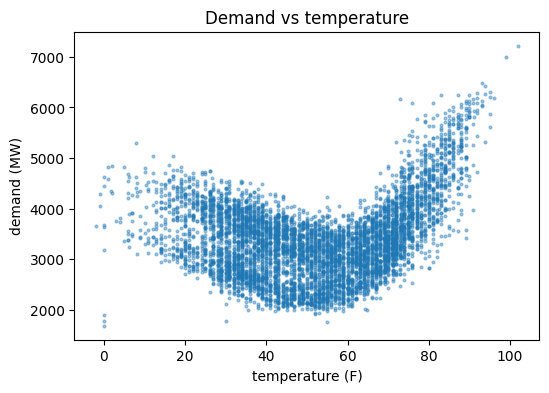

In [6]:
# demand vs temperature is a U: heating on the cold side, air conditioning on the hot side
s = df.sample(6000, random_state=5509)
plt.figure(figsize=(6, 4)); plt.scatter(s["BDL_tmpf"], s["Demand"], s=4, alpha=0.4)
plt.xlabel("temperature (F)"); plt.ylabel("demand (MW)"); plt.title("Demand vs temperature"); plt.show()

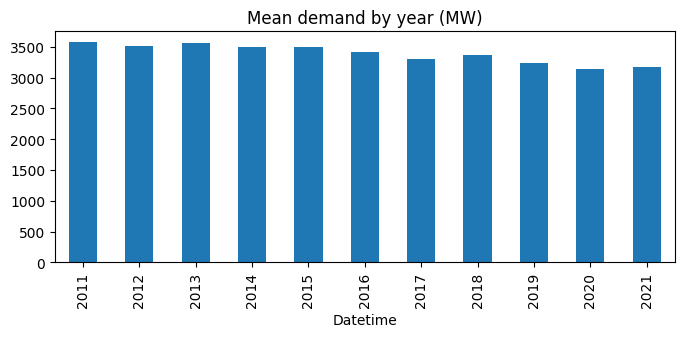

In [7]:
# the 2020 dip: the world changed and the model's data didn't - that's "distribution shift"
df.groupby(df.index.year)["Demand"].mean().plot(kind="bar", figsize=(8, 3), title="Mean demand by year (MW)"); plt.show()

## Slice and split - chronologically

Three years is plenty for the lecture and fast to train on. **Train on 2017-2018, test on 2019** - the future is never in the training set.

In [8]:
data  = df.loc["2017-01-01":"2019-12-31"].copy()
train = data.loc[:"2018-12-31"]
test  = data.loc["2019-01-01":]
print("train:", train.shape, "| test:", test.shape)

train: (17520, 10) | test: (8760, 10)


## Baselines first

A forecast is only good relative to the dumb thing you could have done instead. Three dumb things, scored on the **test** year:

In [9]:
y = test["Demand"]
baselines = pd.Series({
    "mean-only (predict the train average)": mean_absolute_error(y, np.full(len(y), train["Demand"].mean())),
    "seasonal naive (same hour yesterday)":  mean_absolute_error(y.iloc[24:], y.shift(24).iloc[24:]),
    "persistence (same as last hour)":       mean_absolute_error(y.iloc[1:],  y.shift(1).iloc[1:]),
}, name="test MAE (MW)").round(1)
baselines

mean-only (predict the train average)    553.7
seasonal naive (same hour yesterday)     227.1
persistence (same as last hour)          129.0
Name: test MAE (MW), dtype: float64

## Univariate LSTM: the last 24 hours -> the next hour

Same `split_sequence` as the temperature notebook. Scale on **train only** (the scaler is part of the model), window the scaled series, reshape to `(samples, look-back, 1)`.

In [10]:
def split_sequence(seq, n_steps):
    X, y = [], []
    for i in range(len(seq) - n_steps):
        X.append(seq[i:i+n_steps]); y.append(seq[i+n_steps])
    return np.array(X), np.array(y)

n_steps = 24                                   # one day of history
sc_y = MinMaxScaler().fit(train[["Demand"]])   # fit on TRAIN only
tr_s = sc_y.transform(train[["Demand"]]).ravel()
te_s = sc_y.transform(test[["Demand"]]).ravel()

X_tr, y_tr = split_sequence(tr_s, n_steps)
X_te, y_te = split_sequence(te_s, n_steps)
X_tr = X_tr.reshape(X_tr.shape[0], n_steps, 1)   # (samples, look-back, features=1) - the 3-D tensor
X_te = X_te.reshape(X_te.shape[0], n_steps, 1)
print("train tensor:", X_tr.shape, "| test tensor:", X_te.shape)

train tensor: (17496, 24, 1) | test tensor: (8736, 24, 1)


In [11]:
es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1)

uni = Sequential([LSTM(32, input_shape=(n_steps, 1)), Dense(1)])
uni.compile(optimizer="adam", loss="mse", metrics=["mae"])
uni.summary()
hist = uni.fit(X_tr, y_tr, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=1)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 11:53 3s/step - loss: 0.1573 - mae: 0.3516

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0995 - mae: 0.2742 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0769 - mae: 0.2339

 17/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0585 - mae: 0.1954

 22/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0487 - mae: 0.1731

 27/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0436 - mae: 0.1620

 32/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0394 - mae: 0.1526

 37/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0358 - mae: 0.1443

 42/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0335 - mae: 0.1395

 47/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0314 - mae: 0.1346

 52/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0297 - mae: 0.1309

 57/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0284 - mae: 0.1282

 62/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0272 - mae: 0.1252

 67/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0261 - mae: 0.1226

 72/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0252 - mae: 0.1200

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0244 - mae: 0.1180

 82/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0236 - mae: 0.1163

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0228 - mae: 0.1144

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0221 - mae: 0.1129

 98/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0216 - mae: 0.1114

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0210 - mae: 0.1100

108/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0205 - mae: 0.1085

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0201 - mae: 0.1075

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0197 - mae: 0.1066

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0193 - mae: 0.1054

128/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0189 - mae: 0.1043

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0185 - mae: 0.1035

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0182 - mae: 0.1027

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0179 - mae: 0.1017

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0176 - mae: 0.1009

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0173 - mae: 0.1001

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0170 - mae: 0.0992

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0167 - mae: 0.0983

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0164 - mae: 0.0976

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0162 - mae: 0.0969

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0159 - mae: 0.0961

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0157 - mae: 0.0953

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0154 - mae: 0.0945

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0152 - mae: 0.0936

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0149 - mae: 0.0926

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0146 - mae: 0.0917

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0144 - mae: 0.0908

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0141 - mae: 0.0897

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0139 - mae: 0.0888

219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0139 - mae: 0.0887 - val_loss: 0.0035 - val_mae: 0.0490


Epoch 2/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - loss: 0.0032 - mae: 0.0456

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0032 - mae: 0.0469 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0032 - mae: 0.0471

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0033 - mae: 0.0474

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0032 - mae: 0.0466

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0031 - mae: 0.0457

 31/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0031 - mae: 0.0453

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0031 - mae: 0.0453

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0030 - mae: 0.0450

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0030 - mae: 0.0446

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0030 - mae: 0.0446

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0030 - mae: 0.0445

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0029 - mae: 0.0444

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0029 - mae: 0.0441

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0029 - mae: 0.0438

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0029 - mae: 0.0437

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0028 - mae: 0.0434

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0028 - mae: 0.0433

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0028 - mae: 0.0432

 97/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0028 - mae: 0.0429

102/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0027 - mae: 0.0427

108/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0027 - mae: 0.0424

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0027 - mae: 0.0422

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0027 - mae: 0.0421

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0026 - mae: 0.0420

128/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0026 - mae: 0.0419

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0026 - mae: 0.0417

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0026 - mae: 0.0416

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0026 - mae: 0.0415

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0026 - mae: 0.0414

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0025 - mae: 0.0412

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0025 - mae: 0.0410

164/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0025 - mae: 0.0409

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0025 - mae: 0.0407

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0025 - mae: 0.0405

179/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0024 - mae: 0.0404

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0024 - mae: 0.0402

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0024 - mae: 0.0400

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0024 - mae: 0.0398

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0024 - mae: 0.0397

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0024 - mae: 0.0395

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0023 - mae: 0.0393

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0023 - mae: 0.0391

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0023 - mae: 0.0390 - val_loss: 0.0015 - val_mae: 0.0323


Epoch 3/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 8:53 2s/step - loss: 0.0012 - mae: 0.0288

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0014 - mae: 0.0290

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0015 - mae: 0.0315

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0015 - mae: 0.0316

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0015 - mae: 0.0312

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0015 - mae: 0.0306

 32/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014 - mae: 0.0303

 37/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014 - mae: 0.0302

 42/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014 - mae: 0.0300

 47/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014 - mae: 0.0298

 52/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014 - mae: 0.0298

 58/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014 - mae: 0.0297

 64/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0014 - mae: 0.0294

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013 - mae: 0.0293

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013 - mae: 0.0291

 78/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013 - mae: 0.0289

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013 - mae: 0.0287

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013 - mae: 0.0286

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013 - mae: 0.0284

 98/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013 - mae: 0.0283

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012 - mae: 0.0281

108/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012 - mae: 0.0279

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012 - mae: 0.0277

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012 - mae: 0.0277

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012 - mae: 0.0276

129/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - mae: 0.0274

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - mae: 0.0274

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - mae: 0.0273

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - mae: 0.0271

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - mae: 0.0271

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - mae: 0.0272

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - mae: 0.0272

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - mae: 0.0273

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - mae: 0.0272

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - mae: 0.0272

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - mae: 0.0272

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - mae: 0.0272

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - mae: 0.0271

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - mae: 0.0271

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - mae: 0.0270

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - mae: 0.0270

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - mae: 0.0269

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - mae: 0.0267

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - mae: 0.0266

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0011 - mae: 0.0266 - val_loss: 8.0627e-04 - val_mae: 0.0219


Epoch 4/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - loss: 7.1825e-04 - mae: 0.0206

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 7.3880e-04 - mae: 0.0210 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 8.0570e-04 - mae: 0.0223

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 7.9813e-04 - mae: 0.0223

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 7.9183e-04 - mae: 0.0222

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 7.8241e-04 - mae: 0.0220

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 7.6557e-04 - mae: 0.0218

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.7360e-04 - mae: 0.0218

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.6999e-04 - mae: 0.0217

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.5946e-04 - mae: 0.0216

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.5191e-04 - mae: 0.0215

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.5574e-04 - mae: 0.0216

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.5058e-04 - mae: 0.0215

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.4681e-04 - mae: 0.0214

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.4499e-04 - mae: 0.0214

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.4066e-04 - mae: 0.0214

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.3279e-04 - mae: 0.0213

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.2914e-04 - mae: 0.0212

 89/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.2890e-04 - mae: 0.0211

 94/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.2417e-04 - mae: 0.0211

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.2114e-04 - mae: 0.0210

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.1163e-04 - mae: 0.0209

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.0702e-04 - mae: 0.0208

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.0334e-04 - mae: 0.0207

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.0616e-04 - mae: 0.0208

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.0567e-04 - mae: 0.0208

127/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.0429e-04 - mae: 0.0207

131/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.0563e-04 - mae: 0.0208

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.0464e-04 - mae: 0.0208

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.0010e-04 - mae: 0.0207

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.9909e-04 - mae: 0.0207

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.0214e-04 - mae: 0.0207

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.0371e-04 - mae: 0.0208

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.0585e-04 - mae: 0.0208

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.0446e-04 - mae: 0.0208

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.0862e-04 - mae: 0.0208

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.1261e-04 - mae: 0.0209

179/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.1826e-04 - mae: 0.0210

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.2101e-04 - mae: 0.0210

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.2045e-04 - mae: 0.0210

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.2254e-04 - mae: 0.0211

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.2277e-04 - mae: 0.0211

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.2388e-04 - mae: 0.0211

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.2051e-04 - mae: 0.0211

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.1757e-04 - mae: 0.0210

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.1521e-04 - mae: 0.0210

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 7.1369e-04 - mae: 0.0210 - val_loss: 7.2692e-04 - val_mae: 0.0204


Epoch 5/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 7:46 2s/step - loss: 7.1304e-04 - mae: 0.0206

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 6.2542e-04 - mae: 0.0195

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.5106e-04 - mae: 0.0202

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.3509e-04 - mae: 0.0200

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.3409e-04 - mae: 0.0199

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.2593e-04 - mae: 0.0198

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.1176e-04 - mae: 0.0196

 34/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.1877e-04 - mae: 0.0196

 39/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.1451e-04 - mae: 0.0195

 42/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.1003e-04 - mae: 0.0194

 47/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.9937e-04 - mae: 0.0192

 51/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.9728e-04 - mae: 0.0192

 56/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.9887e-04 - mae: 0.0192

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.9779e-04 - mae: 0.0192

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.9754e-04 - mae: 0.0192

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.9577e-04 - mae: 0.0191

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.9532e-04 - mae: 0.0191

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.8937e-04 - mae: 0.0190

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.8766e-04 - mae: 0.0190

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.8798e-04 - mae: 0.0189

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.8589e-04 - mae: 0.0189

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.8388e-04 - mae: 0.0189

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.7848e-04 - mae: 0.0188

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.7574e-04 - mae: 0.0188

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.7420e-04 - mae: 0.0187

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.7743e-04 - mae: 0.0188

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.7693e-04 - mae: 0.0188

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.7825e-04 - mae: 0.0188

134/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.7947e-04 - mae: 0.0188

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.7996e-04 - mae: 0.0188

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.7983e-04 - mae: 0.0188

147/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.8040e-04 - mae: 0.0189

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.8488e-04 - mae: 0.0189

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.8921e-04 - mae: 0.0190

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.9310e-04 - mae: 0.0191

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.9540e-04 - mae: 0.0191

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.9946e-04 - mae: 0.0192

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.0272e-04 - mae: 0.0192

179/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.0586e-04 - mae: 0.0193

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.0645e-04 - mae: 0.0193

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.0494e-04 - mae: 0.0193

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.0893e-04 - mae: 0.0194

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.0866e-04 - mae: 0.0194

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.1047e-04 - mae: 0.0194

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.0799e-04 - mae: 0.0194

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.0535e-04 - mae: 0.0193

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.0329e-04 - mae: 0.0193

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 6.0243e-04 - mae: 0.0193 - val_loss: 5.7184e-04 - val_mae: 0.0182


Epoch 6/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step - loss: 5.6020e-04 - mae: 0.0180

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.2159e-04 - mae: 0.0176 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.4514e-04 - mae: 0.0183

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.3816e-04 - mae: 0.0182

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.3687e-04 - mae: 0.0182

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.3415e-04 - mae: 0.0182

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.2689e-04 - mae: 0.0181

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.3265e-04 - mae: 0.0181

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.2951e-04 - mae: 0.0180

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.2413e-04 - mae: 0.0179

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.1920e-04 - mae: 0.0178

 54/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.1680e-04 - mae: 0.0178

 59/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.2220e-04 - mae: 0.0179

 64/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.2377e-04 - mae: 0.0179

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.2234e-04 - mae: 0.0178

 74/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.2085e-04 - mae: 0.0178

 79/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.1942e-04 - mae: 0.0178

 84/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.1666e-04 - mae: 0.0177

 89/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.1746e-04 - mae: 0.0177

 94/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.1791e-04 - mae: 0.0178

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.1734e-04 - mae: 0.0177

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.1212e-04 - mae: 0.0177

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.0951e-04 - mae: 0.0176

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.0817e-04 - mae: 0.0176

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.1141e-04 - mae: 0.0176

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.1122e-04 - mae: 0.0176

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.1277e-04 - mae: 0.0176

134/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.1356e-04 - mae: 0.0177

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.1409e-04 - mae: 0.0177

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.1623e-04 - mae: 0.0177

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.1654e-04 - mae: 0.0177

147/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.1835e-04 - mae: 0.0178

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.2504e-04 - mae: 0.0179

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.2884e-04 - mae: 0.0180

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.3187e-04 - mae: 0.0180

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.3533e-04 - mae: 0.0181

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.3684e-04 - mae: 0.0181

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.3693e-04 - mae: 0.0181

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.3646e-04 - mae: 0.0181

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.3593e-04 - mae: 0.0181

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.3533e-04 - mae: 0.0181

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.3607e-04 - mae: 0.0181

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.3544e-04 - mae: 0.0181

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.3725e-04 - mae: 0.0181

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.3538e-04 - mae: 0.0181

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.3329e-04 - mae: 0.0181

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.3174e-04 - mae: 0.0181

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 5.3112e-04 - mae: 0.0181 - val_loss: 5.2577e-04 - val_mae: 0.0174


Epoch 7/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - loss: 5.2046e-04 - mae: 0.0173

  5/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.5104e-04 - mae: 0.0164 

 10/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.0992e-04 - mae: 0.0176

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.9476e-04 - mae: 0.0174

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.9304e-04 - mae: 0.0174

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.8780e-04 - mae: 0.0173

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.8013e-04 - mae: 0.0172

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.8458e-04 - mae: 0.0172

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.8150e-04 - mae: 0.0171

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7705e-04 - mae: 0.0171

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7311e-04 - mae: 0.0170

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7095e-04 - mae: 0.0169

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7645e-04 - mae: 0.0170

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.8128e-04 - mae: 0.0171

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7747e-04 - mae: 0.0170

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7680e-04 - mae: 0.0170

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7477e-04 - mae: 0.0169

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7193e-04 - mae: 0.0169

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7487e-04 - mae: 0.0169

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7373e-04 - mae: 0.0169

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7321e-04 - mae: 0.0169

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6931e-04 - mae: 0.0168

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6822e-04 - mae: 0.0168

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6581e-04 - mae: 0.0168

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6871e-04 - mae: 0.0168

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6953e-04 - mae: 0.0168

130/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.7108e-04 - mae: 0.0168

135/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.7138e-04 - mae: 0.0169

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.7260e-04 - mae: 0.0169

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.7559e-04 - mae: 0.0170

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.8269e-04 - mae: 0.0171

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.8598e-04 - mae: 0.0171

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.8902e-04 - mae: 0.0172

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9066e-04 - mae: 0.0173

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9167e-04 - mae: 0.0173

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9273e-04 - mae: 0.0173

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9300e-04 - mae: 0.0173

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9144e-04 - mae: 0.0173

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9050e-04 - mae: 0.0173

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9150e-04 - mae: 0.0173

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9128e-04 - mae: 0.0173

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9166e-04 - mae: 0.0173

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9114e-04 - mae: 0.0173

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.8933e-04 - mae: 0.0173

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 4.8773e-04 - mae: 0.0172 - val_loss: 4.9202e-04 - val_mae: 0.0168


Epoch 8/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 8:30 2s/step - loss: 4.8917e-04 - mae: 0.0168

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.4560e-04 - mae: 0.0162

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.6417e-04 - mae: 0.0168

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.5742e-04 - mae: 0.0167

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.5435e-04 - mae: 0.0166

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.5038e-04 - mae: 0.0165

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.4688e-04 - mae: 0.0165

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.4714e-04 - mae: 0.0165

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.4199e-04 - mae: 0.0164

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.3921e-04 - mae: 0.0163

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.3654e-04 - mae: 0.0163

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.3816e-04 - mae: 0.0163

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.4160e-04 - mae: 0.0163

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.4534e-04 - mae: 0.0164

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.4217e-04 - mae: 0.0163

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.4314e-04 - mae: 0.0163

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.3829e-04 - mae: 0.0162

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.3757e-04 - mae: 0.0162

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.3913e-04 - mae: 0.0162

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.3999e-04 - mae: 0.0163

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.3800e-04 - mae: 0.0162

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.3544e-04 - mae: 0.0162

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.3333e-04 - mae: 0.0161

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.3222e-04 - mae: 0.0161

121/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.3493e-04 - mae: 0.0162

126/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.3677e-04 - mae: 0.0162

131/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.3797e-04 - mae: 0.0162

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.3802e-04 - mae: 0.0162

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.3884e-04 - mae: 0.0162

147/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.4343e-04 - mae: 0.0163

152/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5046e-04 - mae: 0.0165

157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5300e-04 - mae: 0.0165

162/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5475e-04 - mae: 0.0166

167/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5704e-04 - mae: 0.0166

172/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5757e-04 - mae: 0.0166

177/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5799e-04 - mae: 0.0166

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5703e-04 - mae: 0.0166

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5535e-04 - mae: 0.0166

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5675e-04 - mae: 0.0166

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5580e-04 - mae: 0.0166

202/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5718e-04 - mae: 0.0166

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5653e-04 - mae: 0.0166

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5509e-04 - mae: 0.0166

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5401e-04 - mae: 0.0166

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 4.5351e-04 - mae: 0.0166 - val_loss: 4.6163e-04 - val_mae: 0.0162


Epoch 9/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - loss: 4.5907e-04 - mae: 0.0162

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.1700e-04 - mae: 0.0156 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.3468e-04 - mae: 0.0162

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.2835e-04 - mae: 0.0161

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.2464e-04 - mae: 0.0160

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.1986e-04 - mae: 0.0159

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.1587e-04 - mae: 0.0159

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.1595e-04 - mae: 0.0159

 41/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.1119e-04 - mae: 0.0158

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.0912e-04 - mae: 0.0157

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.0709e-04 - mae: 0.0157

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.0838e-04 - mae: 0.0157

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.1198e-04 - mae: 0.0157

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.1593e-04 - mae: 0.0158

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.1292e-04 - mae: 0.0157

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.1364e-04 - mae: 0.0157

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.0903e-04 - mae: 0.0157

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.0837e-04 - mae: 0.0156

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.1001e-04 - mae: 0.0156

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.1084e-04 - mae: 0.0157

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.0904e-04 - mae: 0.0157

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.0677e-04 - mae: 0.0156

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.0464e-04 - mae: 0.0155

117/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.0520e-04 - mae: 0.0156

122/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.0716e-04 - mae: 0.0156

127/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.0640e-04 - mae: 0.0156

132/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0910e-04 - mae: 0.0156

137/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0952e-04 - mae: 0.0156

142/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.1064e-04 - mae: 0.0157

147/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.1422e-04 - mae: 0.0157

152/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.2074e-04 - mae: 0.0159

157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.2298e-04 - mae: 0.0159

162/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.2474e-04 - mae: 0.0160

167/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.2687e-04 - mae: 0.0160

172/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.2763e-04 - mae: 0.0160

177/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.2809e-04 - mae: 0.0160

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.2727e-04 - mae: 0.0160

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.2574e-04 - mae: 0.0160

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.2721e-04 - mae: 0.0160

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.2625e-04 - mae: 0.0160

202/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.2750e-04 - mae: 0.0161

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.2698e-04 - mae: 0.0160

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.2579e-04 - mae: 0.0160

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.2486e-04 - mae: 0.0160

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 4.2437e-04 - mae: 0.0160 - val_loss: 4.3251e-04 - val_mae: 0.0156


Epoch 10/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 4.2913e-04 - mae: 0.0157

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.9078e-04 - mae: 0.0151 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.0779e-04 - mae: 0.0157

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.0214e-04 - mae: 0.0156

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.9817e-04 - mae: 0.0154

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.9286e-04 - mae: 0.0154

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.8819e-04 - mae: 0.0153

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8819e-04 - mae: 0.0153

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8390e-04 - mae: 0.0152

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8241e-04 - mae: 0.0152

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8096e-04 - mae: 0.0151

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8193e-04 - mae: 0.0152

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8551e-04 - mae: 0.0152

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8950e-04 - mae: 0.0152

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8677e-04 - mae: 0.0152

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8728e-04 - mae: 0.0152

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8458e-04 - mae: 0.0151

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8237e-04 - mae: 0.0151

 89/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8397e-04 - mae: 0.0151

 92/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8401e-04 - mae: 0.0151

 97/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8581e-04 - mae: 0.0152

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8318e-04 - mae: 0.0151

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8116e-04 - mae: 0.0151

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7902e-04 - mae: 0.0150

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7811e-04 - mae: 0.0150

121/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8044e-04 - mae: 0.0150

126/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8192e-04 - mae: 0.0151

131/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.8310e-04 - mae: 0.0151

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.8343e-04 - mae: 0.0151

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.8409e-04 - mae: 0.0151

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.8684e-04 - mae: 0.0152

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.9313e-04 - mae: 0.0153

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.9530e-04 - mae: 0.0154

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.9736e-04 - mae: 0.0154

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.9906e-04 - mae: 0.0155

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0102e-04 - mae: 0.0155

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0107e-04 - mae: 0.0155

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0063e-04 - mae: 0.0155

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0046e-04 - mae: 0.0155

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0010e-04 - mae: 0.0155

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0045e-04 - mae: 0.0155

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0044e-04 - mae: 0.0155

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0110e-04 - mae: 0.0155

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.0051e-04 - mae: 0.0155

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.9931e-04 - mae: 0.0155

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3.9842e-04 - mae: 0.0155 - val_loss: 4.0428e-04 - val_mae: 0.0151


Epoch 11/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - loss: 3.9946e-04 - mae: 0.0151

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.6644e-04 - mae: 0.0146 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.8272e-04 - mae: 0.0152

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.7797e-04 - mae: 0.0151

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.7408e-04 - mae: 0.0149

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.6850e-04 - mae: 0.0148

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.6177e-04 - mae: 0.0147

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.6402e-04 - mae: 0.0147

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.6228e-04 - mae: 0.0147

 45/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.5958e-04 - mae: 0.0147

 49/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.5698e-04 - mae: 0.0147

 53/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5654e-04 - mae: 0.0146

 58/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5820e-04 - mae: 0.0146

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.6143e-04 - mae: 0.0147

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.6532e-04 - mae: 0.0147

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.6290e-04 - mae: 0.0147

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.6325e-04 - mae: 0.0147

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5927e-04 - mae: 0.0146

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5880e-04 - mae: 0.0146

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.6040e-04 - mae: 0.0146

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.6108e-04 - mae: 0.0147

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5966e-04 - mae: 0.0146

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5786e-04 - mae: 0.0146

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5572e-04 - mae: 0.0145

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5491e-04 - mae: 0.0145

121/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5707e-04 - mae: 0.0146

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5749e-04 - mae: 0.0146

130/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5937e-04 - mae: 0.0146

135/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.5979e-04 - mae: 0.0146

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.6060e-04 - mae: 0.0146

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.6326e-04 - mae: 0.0147

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.6803e-04 - mae: 0.0148

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.6995e-04 - mae: 0.0148

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.7214e-04 - mae: 0.0149

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.7372e-04 - mae: 0.0149

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.7546e-04 - mae: 0.0150

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.7668e-04 - mae: 0.0150

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.7724e-04 - mae: 0.0150

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7614e-04 - mae: 0.0150

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7610e-04 - mae: 0.0150

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7682e-04 - mae: 0.0150

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7647e-04 - mae: 0.0150

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7688e-04 - mae: 0.0150

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7720e-04 - mae: 0.0150

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7593e-04 - mae: 0.0150

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 3.7482e-04 - mae: 0.0150 - val_loss: 3.7690e-04 - val_mae: 0.0145


Epoch 12/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - loss: 3.7025e-04 - mae: 0.0145

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.4385e-04 - mae: 0.0142 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.5929e-04 - mae: 0.0147

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.5562e-04 - mae: 0.0146

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.5463e-04 - mae: 0.0145

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.4978e-04 - mae: 0.0144

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.3950e-04 - mae: 0.0142

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.4125e-04 - mae: 0.0142

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.3986e-04 - mae: 0.0142

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3736e-04 - mae: 0.0142

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3677e-04 - mae: 0.0142

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3511e-04 - mae: 0.0142

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3892e-04 - mae: 0.0142

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.4427e-04 - mae: 0.0143

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.4126e-04 - mae: 0.0142

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.4029e-04 - mae: 0.0142

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3893e-04 - mae: 0.0142

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3707e-04 - mae: 0.0141

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3992e-04 - mae: 0.0142

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3925e-04 - mae: 0.0142

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3899e-04 - mae: 0.0142

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3678e-04 - mae: 0.0141

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3581e-04 - mae: 0.0141

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3405e-04 - mae: 0.0141

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3580e-04 - mae: 0.0141

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3601e-04 - mae: 0.0141

130/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3789e-04 - mae: 0.0141

135/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3839e-04 - mae: 0.0141

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3901e-04 - mae: 0.0142

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.4140e-04 - mae: 0.0142

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.4559e-04 - mae: 0.0143

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.4727e-04 - mae: 0.0143

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.4935e-04 - mae: 0.0144

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5110e-04 - mae: 0.0145

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5305e-04 - mae: 0.0145

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5435e-04 - mae: 0.0145

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5503e-04 - mae: 0.0145

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5407e-04 - mae: 0.0145

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5452e-04 - mae: 0.0145

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5501e-04 - mae: 0.0146

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5424e-04 - mae: 0.0145

202/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5516e-04 - mae: 0.0146

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5509e-04 - mae: 0.0146

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5537e-04 - mae: 0.0146

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5422e-04 - mae: 0.0145

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 3.5319e-04 - mae: 0.0145 - val_loss: 3.5032e-04 - val_mae: 0.0139


Epoch 13/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - loss: 3.4162e-04 - mae: 0.0138

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.2300e-04 - mae: 0.0137 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.3750e-04 - mae: 0.0142

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.3494e-04 - mae: 0.0141

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.3197e-04 - mae: 0.0140

 27/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.2629e-04 - mae: 0.0139

 32/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1991e-04 - mae: 0.0138

 37/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1922e-04 - mae: 0.0138

 42/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1744e-04 - mae: 0.0137

 47/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1456e-04 - mae: 0.0137

 52/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1600e-04 - mae: 0.0137

 58/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1640e-04 - mae: 0.0137

 64/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2171e-04 - mae: 0.0138

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2155e-04 - mae: 0.0138

 74/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2018e-04 - mae: 0.0138

 79/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1951e-04 - mae: 0.0137

 84/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1792e-04 - mae: 0.0137

 89/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1883e-04 - mae: 0.0137

 94/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2010e-04 - mae: 0.0137

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2022e-04 - mae: 0.0137

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1758e-04 - mae: 0.0137

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1629e-04 - mae: 0.0137

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1466e-04 - mae: 0.0136

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1628e-04 - mae: 0.0136

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1643e-04 - mae: 0.0137

130/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1827e-04 - mae: 0.0137

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1900e-04 - mae: 0.0137

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1929e-04 - mae: 0.0137

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2136e-04 - mae: 0.0138

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2537e-04 - mae: 0.0139

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2726e-04 - mae: 0.0139

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2949e-04 - mae: 0.0140

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3062e-04 - mae: 0.0140

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3365e-04 - mae: 0.0141

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3415e-04 - mae: 0.0141

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3394e-04 - mae: 0.0141

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3425e-04 - mae: 0.0141

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3449e-04 - mae: 0.0141

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3449e-04 - mae: 0.0141

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3442e-04 - mae: 0.0141

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3487e-04 - mae: 0.0141

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3492e-04 - mae: 0.0141

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3417e-04 - mae: 0.0141

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 3.3333e-04 - mae: 0.0141 - val_loss: 3.2455e-04 - val_mae: 0.0134


Epoch 14/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - loss: 3.1378e-04 - mae: 0.0131

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.0393e-04 - mae: 0.0132 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.1740e-04 - mae: 0.0137

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.1603e-04 - mae: 0.0137

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.1382e-04 - mae: 0.0136

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.0873e-04 - mae: 0.0135

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.0184e-04 - mae: 0.0134

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0126e-04 - mae: 0.0134

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9817e-04 - mae: 0.0133

 47/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9667e-04 - mae: 0.0133

 52/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9827e-04 - mae: 0.0133

 57/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9957e-04 - mae: 0.0133

 62/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0174e-04 - mae: 0.0134

 67/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0645e-04 - mae: 0.0134

 72/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0178e-04 - mae: 0.0133

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0123e-04 - mae: 0.0133

 82/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9833e-04 - mae: 0.0132

 87/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9937e-04 - mae: 0.0133

 92/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0103e-04 - mae: 0.0133

 97/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0210e-04 - mae: 0.0133

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0050e-04 - mae: 0.0133

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9934e-04 - mae: 0.0133

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9729e-04 - mae: 0.0132

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9676e-04 - mae: 0.0132

121/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9847e-04 - mae: 0.0132

126/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9947e-04 - mae: 0.0133

131/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.0055e-04 - mae: 0.0133

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.0122e-04 - mae: 0.0133

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.0139e-04 - mae: 0.0133

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.0328e-04 - mae: 0.0133

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.0666e-04 - mae: 0.0134

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.0842e-04 - mae: 0.0135

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1072e-04 - mae: 0.0135

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1175e-04 - mae: 0.0136

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1495e-04 - mae: 0.0136

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1559e-04 - mae: 0.0136

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1538e-04 - mae: 0.0137

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1578e-04 - mae: 0.0137

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1614e-04 - mae: 0.0137

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1605e-04 - mae: 0.0137

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1600e-04 - mae: 0.0137

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1634e-04 - mae: 0.0137

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1654e-04 - mae: 0.0137

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1593e-04 - mae: 0.0137

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 3.1511e-04 - mae: 0.0137 - val_loss: 2.9992e-04 - val_mae: 0.0128


Epoch 15/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - loss: 2.8722e-04 - mae: 0.0125

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.8673e-04 - mae: 0.0128 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.9914e-04 - mae: 0.0133

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.9887e-04 - mae: 0.0133

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.9755e-04 - mae: 0.0132

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.9291e-04 - mae: 0.0131

 31/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8579e-04 - mae: 0.0130

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8498e-04 - mae: 0.0130

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8189e-04 - mae: 0.0129

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8156e-04 - mae: 0.0129

 52/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.8238e-04 - mae: 0.0129

 57/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8334e-04 - mae: 0.0129

 62/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8517e-04 - mae: 0.0130

 67/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8953e-04 - mae: 0.0130

 72/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8522e-04 - mae: 0.0129

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8464e-04 - mae: 0.0129

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8213e-04 - mae: 0.0129

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8449e-04 - mae: 0.0129

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8509e-04 - mae: 0.0129

 98/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8589e-04 - mae: 0.0129

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.8429e-04 - mae: 0.0129

108/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.8294e-04 - mae: 0.0129

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.8115e-04 - mae: 0.0128

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.8284e-04 - mae: 0.0129

124/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8249e-04 - mae: 0.0128

130/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8432e-04 - mae: 0.0129

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8513e-04 - mae: 0.0129

142/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8551e-04 - mae: 0.0129

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8756e-04 - mae: 0.0130

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9117e-04 - mae: 0.0131

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9192e-04 - mae: 0.0131

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9453e-04 - mae: 0.0131

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9672e-04 - mae: 0.0132

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9906e-04 - mae: 0.0133

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9875e-04 - mae: 0.0132

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9846e-04 - mae: 0.0132

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9910e-04 - mae: 0.0133

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9970e-04 - mae: 0.0133

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9918e-04 - mae: 0.0133

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9959e-04 - mae: 0.0133

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9993e-04 - mae: 0.0133

214/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9922e-04 - mae: 0.0133

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9848e-04 - mae: 0.0133

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.9848e-04 - mae: 0.0133 - val_loss: 2.7695e-04 - val_mae: 0.0123


Epoch 16/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - loss: 2.6254e-04 - mae: 0.0120

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.7146e-04 - mae: 0.0124 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.8281e-04 - mae: 0.0129

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.8349e-04 - mae: 0.0129

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.8311e-04 - mae: 0.0129

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.7900e-04 - mae: 0.0128

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.7179e-04 - mae: 0.0127

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.7075e-04 - mae: 0.0126

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6753e-04 - mae: 0.0125

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6716e-04 - mae: 0.0126

 52/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6826e-04 - mae: 0.0126

 58/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6803e-04 - mae: 0.0126

 64/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.7154e-04 - mae: 0.0126

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.7125e-04 - mae: 0.0126

 74/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.7012e-04 - mae: 0.0126

 79/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.7013e-04 - mae: 0.0126

 84/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.6870e-04 - mae: 0.0125

 89/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.6995e-04 - mae: 0.0126

 94/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.7094e-04 - mae: 0.0126

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.7100e-04 - mae: 0.0126

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.6941e-04 - mae: 0.0125

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.6811e-04 - mae: 0.0125

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.6699e-04 - mae: 0.0125

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.6842e-04 - mae: 0.0125

124/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.6811e-04 - mae: 0.0125

129/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.6945e-04 - mae: 0.0125

134/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.7100e-04 - mae: 0.0126

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.7078e-04 - mae: 0.0126

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7211e-04 - mae: 0.0126

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7454e-04 - mae: 0.0127

157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7625e-04 - mae: 0.0127

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7925e-04 - mae: 0.0128

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8135e-04 - mae: 0.0128

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8381e-04 - mae: 0.0129

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8352e-04 - mae: 0.0129

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8349e-04 - mae: 0.0129

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8310e-04 - mae: 0.0129

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8445e-04 - mae: 0.0129

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8410e-04 - mae: 0.0129

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8411e-04 - mae: 0.0129

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8445e-04 - mae: 0.0129

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8410e-04 - mae: 0.0129

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.8335e-04 - mae: 0.0129 - val_loss: 2.5615e-04 - val_mae: 0.0119


Epoch 17/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - loss: 2.4034e-04 - mae: 0.0115

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.5812e-04 - mae: 0.0120 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.6846e-04 - mae: 0.0125

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.6984e-04 - mae: 0.0126

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.7041e-04 - mae: 0.0126

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.6690e-04 - mae: 0.0125

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.5971e-04 - mae: 0.0124

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.5845e-04 - mae: 0.0123

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5504e-04 - mae: 0.0122

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5456e-04 - mae: 0.0122

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5569e-04 - mae: 0.0123

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5559e-04 - mae: 0.0123

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5732e-04 - mae: 0.0123

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5912e-04 - mae: 0.0123

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5756e-04 - mae: 0.0123

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5736e-04 - mae: 0.0123

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5554e-04 - mae: 0.0122

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5603e-04 - mae: 0.0122

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5721e-04 - mae: 0.0122

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5726e-04 - mae: 0.0123

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5709e-04 - mae: 0.0122

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5629e-04 - mae: 0.0122

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5515e-04 - mae: 0.0122

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5393e-04 - mae: 0.0122

122/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5528e-04 - mae: 0.0122

128/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.5583e-04 - mae: 0.0122

134/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.5803e-04 - mae: 0.0123

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.5765e-04 - mae: 0.0123

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.5886e-04 - mae: 0.0123

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.5987e-04 - mae: 0.0123

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.6160e-04 - mae: 0.0123

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.6475e-04 - mae: 0.0124

167/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.6710e-04 - mae: 0.0125

172/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.6905e-04 - mae: 0.0125

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.6978e-04 - mae: 0.0125

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.6945e-04 - mae: 0.0126

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.6953e-04 - mae: 0.0126

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7009e-04 - mae: 0.0126

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7022e-04 - mae: 0.0126

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7019e-04 - mae: 0.0126

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7053e-04 - mae: 0.0126

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.6992e-04 - mae: 0.0126

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.6958e-04 - mae: 0.0126 - val_loss: 2.3808e-04 - val_mae: 0.0115


Epoch 18/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 2.2116e-04 - mae: 0.0111

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.4667e-04 - mae: 0.0118 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.5609e-04 - mae: 0.0122

 17/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.5860e-04 - mae: 0.0123

 23/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.5863e-04 - mae: 0.0123

 29/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.5298e-04 - mae: 0.0122

 35/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.4883e-04 - mae: 0.0121

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.4434e-04 - mae: 0.0120 

 47/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.4341e-04 - mae: 0.0120

 53/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.4460e-04 - mae: 0.0120

 59/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.4553e-04 - mae: 0.0120

 64/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.4677e-04 - mae: 0.0120

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.4619e-04 - mae: 0.0120

 74/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.4516e-04 - mae: 0.0120

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.4480e-04 - mae: 0.0120

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.4464e-04 - mae: 0.0119

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.4566e-04 - mae: 0.0119

 97/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.4587e-04 - mae: 0.0120

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.4532e-04 - mae: 0.0119

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.4376e-04 - mae: 0.0119

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.4287e-04 - mae: 0.0119

120/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.4385e-04 - mae: 0.0119

126/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.4443e-04 - mae: 0.0119

132/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.4527e-04 - mae: 0.0119

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.4652e-04 - mae: 0.0120

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.4704e-04 - mae: 0.0120

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.4875e-04 - mae: 0.0120

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.4997e-04 - mae: 0.0121

162/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.5271e-04 - mae: 0.0121

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.5508e-04 - mae: 0.0122

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.5740e-04 - mae: 0.0122

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.5769e-04 - mae: 0.0123

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.5740e-04 - mae: 0.0123 

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.5804e-04 - mae: 0.0123

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.5782e-04 - mae: 0.0123

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.5793e-04 - mae: 0.0123

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.5826e-04 - mae: 0.0123

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.5769e-04 - mae: 0.0123

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 2.5704e-04 - mae: 0.0122 - val_loss: 2.2348e-04 - val_mae: 0.0112


Epoch 19/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - loss: 2.0574e-04 - mae: 0.0108

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.3700e-04 - mae: 0.0115 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.4566e-04 - mae: 0.0119

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.4754e-04 - mae: 0.0120

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.4961e-04 - mae: 0.0121

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.4756e-04 - mae: 0.0121

 31/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.4088e-04 - mae: 0.0119

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3937e-04 - mae: 0.0119

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3542e-04 - mae: 0.0118

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3460e-04 - mae: 0.0118

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3588e-04 - mae: 0.0118

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3548e-04 - mae: 0.0117

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3648e-04 - mae: 0.0118

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3740e-04 - mae: 0.0118

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3579e-04 - mae: 0.0117

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3536e-04 - mae: 0.0117

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3405e-04 - mae: 0.0117

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3472e-04 - mae: 0.0117

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3608e-04 - mae: 0.0117

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3534e-04 - mae: 0.0117

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3516e-04 - mae: 0.0117

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3471e-04 - mae: 0.0117

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3351e-04 - mae: 0.0116

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3273e-04 - mae: 0.0116

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3374e-04 - mae: 0.0116

126/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3421e-04 - mae: 0.0116

131/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.3490e-04 - mae: 0.0117

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.3562e-04 - mae: 0.0117

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.3522e-04 - mae: 0.0117

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.3657e-04 - mae: 0.0117

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.3789e-04 - mae: 0.0117

157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.3925e-04 - mae: 0.0118

162/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4173e-04 - mae: 0.0118

167/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4370e-04 - mae: 0.0119

172/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4561e-04 - mae: 0.0119

177/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4642e-04 - mae: 0.0120

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4632e-04 - mae: 0.0120

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4527e-04 - mae: 0.0119

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4647e-04 - mae: 0.0120

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4646e-04 - mae: 0.0120

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4686e-04 - mae: 0.0120

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4636e-04 - mae: 0.0120

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4594e-04 - mae: 0.0120

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4594e-04 - mae: 0.0120

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.4562e-04 - mae: 0.0120 - val_loss: 2.1325e-04 - val_mae: 0.0110


Epoch 20/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 8:47 2s/step - loss: 1.9493e-04 - mae: 0.0105

  7/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.2846e-04 - mae: 0.0114

 12/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.3723e-04 - mae: 0.0117

 17/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.4010e-04 - mae: 0.0118

 22/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.4145e-04 - mae: 0.0119

 27/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.3869e-04 - mae: 0.0119

 32/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.3343e-04 - mae: 0.0117

 38/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.3282e-04 - mae: 0.0117

 44/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2867e-04 - mae: 0.0116

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2987e-04 - mae: 0.0116

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2782e-04 - mae: 0.0115

 62/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2789e-04 - mae: 0.0115

 68/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2868e-04 - mae: 0.0115

 74/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2641e-04 - mae: 0.0115

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2613e-04 - mae: 0.0115

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2620e-04 - mae: 0.0115

 92/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2645e-04 - mae: 0.0114

 97/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2650e-04 - mae: 0.0115

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2626e-04 - mae: 0.0114

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2479e-04 - mae: 0.0114

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2402e-04 - mae: 0.0114

120/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2492e-04 - mae: 0.0114

125/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2468e-04 - mae: 0.0114

130/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2585e-04 - mae: 0.0114

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2656e-04 - mae: 0.0114

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2604e-04 - mae: 0.0114

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2733e-04 - mae: 0.0115

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2842e-04 - mae: 0.0115

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2945e-04 - mae: 0.0115

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.3189e-04 - mae: 0.0116

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.3253e-04 - mae: 0.0116

172/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.3575e-04 - mae: 0.0117

177/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.3647e-04 - mae: 0.0117

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.3626e-04 - mae: 0.0117

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.3519e-04 - mae: 0.0117

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.3630e-04 - mae: 0.0117

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.3601e-04 - mae: 0.0117

202/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.3654e-04 - mae: 0.0117

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.3588e-04 - mae: 0.0117

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.3556e-04 - mae: 0.0117

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.3558e-04 - mae: 0.0117

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 2.3526e-04 - mae: 0.0117 - val_loss: 2.0787e-04 - val_mae: 0.0110


Epoch 21/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - loss: 1.8921e-04 - mae: 0.0106

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.2196e-04 - mae: 0.0112 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.2972e-04 - mae: 0.0115

 17/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.3278e-04 - mae: 0.0116

 22/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.3431e-04 - mae: 0.0117

 27/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.3186e-04 - mae: 0.0117

 33/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2819e-04 - mae: 0.0116

 39/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2598e-04 - mae: 0.0116

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2229e-04 - mae: 0.0115

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2264e-04 - mae: 0.0114

 57/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2173e-04 - mae: 0.0114

 63/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2087e-04 - mae: 0.0114

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.2027e-04 - mae: 0.0113 

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1888e-04 - mae: 0.0113

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1831e-04 - mae: 0.0113

 87/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1866e-04 - mae: 0.0113

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1868e-04 - mae: 0.0112

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1890e-04 - mae: 0.0113

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1831e-04 - mae: 0.0112

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1707e-04 - mae: 0.0112

116/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.1655e-04 - mae: 0.0112

122/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.1708e-04 - mae: 0.0112

127/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.1691e-04 - mae: 0.0112

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.1796e-04 - mae: 0.0112

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.1839e-04 - mae: 0.0112

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.1915e-04 - mae: 0.0112

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2022e-04 - mae: 0.0113

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2112e-04 - mae: 0.0113

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2349e-04 - mae: 0.0114

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2403e-04 - mae: 0.0114

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2646e-04 - mae: 0.0114

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2762e-04 - mae: 0.0115

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2732e-04 - mae: 0.0115

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2625e-04 - mae: 0.0114

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2709e-04 - mae: 0.0115

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2684e-04 - mae: 0.0115

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2746e-04 - mae: 0.0115

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2678e-04 - mae: 0.0115

214/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2645e-04 - mae: 0.0114

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.2595e-04 - mae: 0.0114 - val_loss: 2.0663e-04 - val_mae: 0.0111


Epoch 22/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 1.8789e-04 - mae: 0.0108

  7/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1550e-04 - mae: 0.0112 

 13/219 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.2059e-04 - mae: 0.0114

 19/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.2549e-04 - mae: 0.0115

 25/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.3033e-04 - mae: 0.0117

 31/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.2347e-04 - mae: 0.0116

 37/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.2230e-04 - mae: 0.0115

 43/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1890e-04 - mae: 0.0114

 49/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1828e-04 - mae: 0.0114

 54/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1667e-04 - mae: 0.0113

 59/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1650e-04 - mae: 0.0113

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1709e-04 - mae: 0.0113

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1364e-04 - mae: 0.0112

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1296e-04 - mae: 0.0111

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1293e-04 - mae: 0.0111

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1251e-04 - mae: 0.0111

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1311e-04 - mae: 0.0111

 97/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1233e-04 - mae: 0.0111

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1226e-04 - mae: 0.0111

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1080e-04 - mae: 0.0110

115/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1029e-04 - mae: 0.0110

121/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1091e-04 - mae: 0.0110

126/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1109e-04 - mae: 0.0110

131/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.1151e-04 - mae: 0.0110

137/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1234e-04 - mae: 0.0111 

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1244e-04 - mae: 0.0111

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1293e-04 - mae: 0.0111

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1367e-04 - mae: 0.0111

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1627e-04 - mae: 0.0112

167/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1777e-04 - mae: 0.0112

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2012e-04 - mae: 0.0113

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2000e-04 - mae: 0.0113

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1913e-04 - mae: 0.0112

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1850e-04 - mae: 0.0112

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1914e-04 - mae: 0.0113

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1897e-04 - mae: 0.0112

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1859e-04 - mae: 0.0112

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.1850e-04 - mae: 0.0112

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.1785e-04 - mae: 0.0112

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 2.1774e-04 - mae: 0.0112 - val_loss: 2.0723e-04 - val_mae: 0.0112


Epoch 23/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 30s 141ms/step - loss: 1.8872e-04 - mae: 0.0111

  7/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1032e-04 - mae: 0.0111   

 12/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.1647e-04 - mae: 0.0113

 17/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.2017e-04 - mae: 0.0114

 22/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.2192e-04 - mae: 0.0115

 27/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2001e-04 - mae: 0.0114

 33/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1997e-04 - mae: 0.0115

 39/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1869e-04 - mae: 0.0114

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1477e-04 - mae: 0.0113

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1487e-04 - mae: 0.0112

 57/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1294e-04 - mae: 0.0112

 62/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1134e-04 - mae: 0.0111

 68/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1080e-04 - mae: 0.0111

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0811e-04 - mae: 0.0110

 79/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0869e-04 - mae: 0.0110

 84/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0755e-04 - mae: 0.0109

 89/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0812e-04 - mae: 0.0110

 94/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0781e-04 - mae: 0.0109

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0712e-04 - mae: 0.0109

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0662e-04 - mae: 0.0109

108/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0587e-04 - mae: 0.0109

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0479e-04 - mae: 0.0109

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0574e-04 - mae: 0.0109

123/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0490e-04 - mae: 0.0108

128/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0556e-04 - mae: 0.0109

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0606e-04 - mae: 0.0109

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0682e-04 - mae: 0.0109

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0691e-04 - mae: 0.0109

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0656e-04 - mae: 0.0109

152/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0803e-04 - mae: 0.0109

157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0844e-04 - mae: 0.0109

162/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1027e-04 - mae: 0.0110

167/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1145e-04 - mae: 0.0110

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1235e-04 - mae: 0.0110

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1322e-04 - mae: 0.0111

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1313e-04 - mae: 0.0111

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1258e-04 - mae: 0.0111

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1136e-04 - mae: 0.0110

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1187e-04 - mae: 0.0110

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1196e-04 - mae: 0.0110

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1186e-04 - mae: 0.0110

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1192e-04 - mae: 0.0110

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1132e-04 - mae: 0.0110

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.1073e-04 - mae: 0.0110 - val_loss: 2.0696e-04 - val_mae: 0.0113


Epoch 24/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 8:34 2s/step - loss: 1.8903e-04 - mae: 0.0112

  7/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.0566e-04 - mae: 0.0110 

 13/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.0959e-04 - mae: 0.0111

 19/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1335e-04 - mae: 0.0112

 24/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1575e-04 - mae: 0.0113

 29/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1626e-04 - mae: 0.0113

 34/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1786e-04 - mae: 0.0114

 40/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1578e-04 - mae: 0.0114

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1227e-04 - mae: 0.0112

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1398e-04 - mae: 0.0112

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1028e-04 - mae: 0.0111

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0919e-04 - mae: 0.0110

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0800e-04 - mae: 0.0110

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0554e-04 - mae: 0.0109

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0458e-04 - mae: 0.0109

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0380e-04 - mae: 0.0108

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0460e-04 - mae: 0.0109

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0419e-04 - mae: 0.0108

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0289e-04 - mae: 0.0108

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0280e-04 - mae: 0.0108

107/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0247e-04 - mae: 0.0108

112/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0119e-04 - mae: 0.0107

117/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0167e-04 - mae: 0.0107

122/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0137e-04 - mae: 0.0107

128/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0146e-04 - mae: 0.0107

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0194e-04 - mae: 0.0107

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0258e-04 - mae: 0.0108

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0263e-04 - mae: 0.0108

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0223e-04 - mae: 0.0107

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0355e-04 - mae: 0.0108

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0420e-04 - mae: 0.0108

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0624e-04 - mae: 0.0108

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0642e-04 - mae: 0.0109

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0830e-04 - mae: 0.0109

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0823e-04 - mae: 0.0109

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0704e-04 - mae: 0.0109

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0632e-04 - mae: 0.0109

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0648e-04 - mae: 0.0109

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0630e-04 - mae: 0.0109

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0676e-04 - mae: 0.0109

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0615e-04 - mae: 0.0108

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0543e-04 - mae: 0.0108

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0543e-04 - mae: 0.0108

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 2.0510e-04 - mae: 0.0108 - val_loss: 2.0507e-04 - val_mae: 0.0113


Epoch 25/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 1.8805e-04 - mae: 0.0112

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.0129e-04 - mae: 0.0108 

 12/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.0664e-04 - mae: 0.0110

 17/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.1017e-04 - mae: 0.0111

 23/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1164e-04 - mae: 0.0112

 29/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1269e-04 - mae: 0.0112

 34/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1533e-04 - mae: 0.0113

 39/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1438e-04 - mae: 0.0113

 44/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1167e-04 - mae: 0.0112

 49/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1085e-04 - mae: 0.0112

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0897e-04 - mae: 0.0111

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0703e-04 - mae: 0.0110

 67/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0538e-04 - mae: 0.0109

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0171e-04 - mae: 0.0108

 78/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0183e-04 - mae: 0.0108

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0086e-04 - mae: 0.0107

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0235e-04 - mae: 0.0108

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0053e-04 - mae: 0.0107

 98/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0051e-04 - mae: 0.0107

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0034e-04 - mae: 0.0107

108/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9913e-04 - mae: 0.0107

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9825e-04 - mae: 0.0106

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9914e-04 - mae: 0.0107

123/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9814e-04 - mae: 0.0106

128/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9862e-04 - mae: 0.0106

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9908e-04 - mae: 0.0106

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9960e-04 - mae: 0.0107

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9962e-04 - mae: 0.0107

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9917e-04 - mae: 0.0106

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0033e-04 - mae: 0.0107

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0088e-04 - mae: 0.0107

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0279e-04 - mae: 0.0107

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0273e-04 - mae: 0.0107

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0440e-04 - mae: 0.0108

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0431e-04 - mae: 0.0108

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0303e-04 - mae: 0.0108

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0198e-04 - mae: 0.0107

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0221e-04 - mae: 0.0107

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0196e-04 - mae: 0.0107

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0235e-04 - mae: 0.0107

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0195e-04 - mae: 0.0107

214/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0150e-04 - mae: 0.0107

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0099e-04 - mae: 0.0107

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.0099e-04 - mae: 0.0107 - val_loss: 2.0312e-04 - val_mae: 0.0113


Epoch 26/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 1.8721e-04 - mae: 0.0112

  7/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.9995e-04 - mae: 0.0108  

 13/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.0317e-04 - mae: 0.0109

 19/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.0592e-04 - mae: 0.0110

 25/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1289e-04 - mae: 0.0112

 31/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1086e-04 - mae: 0.0112

 37/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1344e-04 - mae: 0.0113

 43/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1066e-04 - mae: 0.0112

 49/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.0997e-04 - mae: 0.0111

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.0796e-04 - mae: 0.0110

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0613e-04 - mae: 0.0109

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0517e-04 - mae: 0.0109

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0090e-04 - mae: 0.0107

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0039e-04 - mae: 0.0107

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9988e-04 - mae: 0.0107

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0088e-04 - mae: 0.0107

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0014e-04 - mae: 0.0107

 97/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9869e-04 - mae: 0.0106

102/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9858e-04 - mae: 0.0106

107/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9811e-04 - mae: 0.0106

112/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9694e-04 - mae: 0.0106

117/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9744e-04 - mae: 0.0106

123/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9645e-04 - mae: 0.0106

129/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9709e-04 - mae: 0.0106

134/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9865e-04 - mae: 0.0106

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9703e-04 - mae: 0.0106

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9770e-04 - mae: 0.0106

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9771e-04 - mae: 0.0106

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9821e-04 - mae: 0.0106

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9874e-04 - mae: 0.0106

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9999e-04 - mae: 0.0106

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0045e-04 - mae: 0.0107

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0150e-04 - mae: 0.0107

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0114e-04 - mae: 0.0107

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0022e-04 - mae: 0.0107

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9926e-04 - mae: 0.0106

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9893e-04 - mae: 0.0106

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9931e-04 - mae: 0.0106

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9889e-04 - mae: 0.0106

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9892e-04 - mae: 0.0106

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.9873e-04 - mae: 0.0106

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.9824e-04 - mae: 0.0106 - val_loss: 2.0205e-04 - val_mae: 0.0112


Epoch 27/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - loss: 1.8728e-04 - mae: 0.0112

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.9856e-04 - mae: 0.0107 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0359e-04 - mae: 0.0109

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0468e-04 - mae: 0.0110

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0394e-04 - mae: 0.0110

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0790e-04 - mae: 0.0111

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1010e-04 - mae: 0.0112

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1235e-04 - mae: 0.0113

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1217e-04 - mae: 0.0113

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0899e-04 - mae: 0.0111

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.1105e-04 - mae: 0.0111

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0751e-04 - mae: 0.0110

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0559e-04 - mae: 0.0109

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0442e-04 - mae: 0.0108

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0006e-04 - mae: 0.0107

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9959e-04 - mae: 0.0107

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9969e-04 - mae: 0.0107

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9958e-04 - mae: 0.0107

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9982e-04 - mae: 0.0107

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9825e-04 - mae: 0.0106

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9770e-04 - mae: 0.0106

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9748e-04 - mae: 0.0106

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9619e-04 - mae: 0.0106

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9618e-04 - mae: 0.0105

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9652e-04 - mae: 0.0106

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9597e-04 - mae: 0.0105

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9574e-04 - mae: 0.0105

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9615e-04 - mae: 0.0105

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9648e-04 - mae: 0.0105

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9644e-04 - mae: 0.0105

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9594e-04 - mae: 0.0105

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9688e-04 - mae: 0.0106

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9730e-04 - mae: 0.0106

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9906e-04 - mae: 0.0106

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9875e-04 - mae: 0.0106

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0012e-04 - mae: 0.0106

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9994e-04 - mae: 0.0106

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9852e-04 - mae: 0.0106

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9769e-04 - mae: 0.0106

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9766e-04 - mae: 0.0106

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9738e-04 - mae: 0.0106

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9780e-04 - mae: 0.0106

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9730e-04 - mae: 0.0106

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9668e-04 - mae: 0.0105

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9677e-04 - mae: 0.0105

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.9646e-04 - mae: 0.0105 - val_loss: 2.0128e-04 - val_mae: 0.0112


Epoch 28/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - loss: 1.8761e-04 - mae: 0.0112

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9840e-04 - mae: 0.0107 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0291e-04 - mae: 0.0109

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0376e-04 - mae: 0.0109

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0322e-04 - mae: 0.0110

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1105e-04 - mae: 0.0112

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1187e-04 - mae: 0.0112

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1204e-04 - mae: 0.0113

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1182e-04 - mae: 0.0113

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0868e-04 - mae: 0.0111

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.1078e-04 - mae: 0.0111

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0717e-04 - mae: 0.0110

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0513e-04 - mae: 0.0109

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0384e-04 - mae: 0.0108

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9944e-04 - mae: 0.0107

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9899e-04 - mae: 0.0107

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9913e-04 - mae: 0.0107

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9902e-04 - mae: 0.0107

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9917e-04 - mae: 0.0106

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9753e-04 - mae: 0.0106

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9696e-04 - mae: 0.0106

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9673e-04 - mae: 0.0106

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9544e-04 - mae: 0.0105

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9507e-04 - mae: 0.0105

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9585e-04 - mae: 0.0105

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9464e-04 - mae: 0.0105

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9490e-04 - mae: 0.0105

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9528e-04 - mae: 0.0105

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9555e-04 - mae: 0.0105

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9550e-04 - mae: 0.0105

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9499e-04 - mae: 0.0105

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9590e-04 - mae: 0.0105

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9628e-04 - mae: 0.0105

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9803e-04 - mae: 0.0106

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9769e-04 - mae: 0.0106

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9900e-04 - mae: 0.0106

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9877e-04 - mae: 0.0106

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9733e-04 - mae: 0.0106

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9651e-04 - mae: 0.0105

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9649e-04 - mae: 0.0105

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9621e-04 - mae: 0.0105

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9661e-04 - mae: 0.0105

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9611e-04 - mae: 0.0105

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9563e-04 - mae: 0.0105

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9537e-04 - mae: 0.0105

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.9528e-04 - mae: 0.0105 - val_loss: 2.0033e-04 - val_mae: 0.0112


Epoch 29/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - loss: 1.8765e-04 - mae: 0.0112

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.9838e-04 - mae: 0.0108 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0244e-04 - mae: 0.0109

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0306e-04 - mae: 0.0109

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0302e-04 - mae: 0.0110

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0736e-04 - mae: 0.0111

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0997e-04 - mae: 0.0112

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1379e-04 - mae: 0.0113

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0904e-04 - mae: 0.0112

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0641e-04 - mae: 0.0111

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0847e-04 - mae: 0.0110

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0586e-04 - mae: 0.0109

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0419e-04 - mae: 0.0109

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0220e-04 - mae: 0.0108

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9927e-04 - mae: 0.0107

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9835e-04 - mae: 0.0107

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9795e-04 - mae: 0.0106

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9902e-04 - mae: 0.0107

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9847e-04 - mae: 0.0106

 94/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9724e-04 - mae: 0.0106

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9619e-04 - mae: 0.0106

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9584e-04 - mae: 0.0105

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9469e-04 - mae: 0.0105

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9500e-04 - mae: 0.0105

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9508e-04 - mae: 0.0105

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9447e-04 - mae: 0.0105

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9434e-04 - mae: 0.0105

134/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9577e-04 - mae: 0.0105

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9404e-04 - mae: 0.0105

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9464e-04 - mae: 0.0105

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9454e-04 - mae: 0.0105

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9501e-04 - mae: 0.0105

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9546e-04 - mae: 0.0105

164/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9684e-04 - mae: 0.0105

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9679e-04 - mae: 0.0105

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9805e-04 - mae: 0.0106

179/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9761e-04 - mae: 0.0106

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9644e-04 - mae: 0.0105

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9539e-04 - mae: 0.0105

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9565e-04 - mae: 0.0105

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9540e-04 - mae: 0.0105

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9577e-04 - mae: 0.0105

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9525e-04 - mae: 0.0105

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9463e-04 - mae: 0.0105

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9472e-04 - mae: 0.0105

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.9442e-04 - mae: 0.0105 - val_loss: 1.9927e-04 - val_mae: 0.0112


Epoch 30/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - loss: 1.8747e-04 - mae: 0.0112

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9853e-04 - mae: 0.0108 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0216e-04 - mae: 0.0109

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0257e-04 - mae: 0.0109

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0326e-04 - mae: 0.0110

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0775e-04 - mae: 0.0111

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1023e-04 - mae: 0.0112

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1347e-04 - mae: 0.0113

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1107e-04 - mae: 0.0112

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0794e-04 - mae: 0.0111

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0987e-04 - mae: 0.0111

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0614e-04 - mae: 0.0110

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0378e-04 - mae: 0.0109

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0248e-04 - mae: 0.0108

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9893e-04 - mae: 0.0107

 74/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9761e-04 - mae: 0.0106

 78/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9782e-04 - mae: 0.0107

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9698e-04 - mae: 0.0106

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9816e-04 - mae: 0.0106

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9578e-04 - mae: 0.0105

 98/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9558e-04 - mae: 0.0105

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9548e-04 - mae: 0.0105

108/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9422e-04 - mae: 0.0105

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9369e-04 - mae: 0.0105

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9442e-04 - mae: 0.0105

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9317e-04 - mae: 0.0105

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9334e-04 - mae: 0.0104

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9365e-04 - mae: 0.0105

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9381e-04 - mae: 0.0105

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9377e-04 - mae: 0.0105

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9327e-04 - mae: 0.0104

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9418e-04 - mae: 0.0105

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9455e-04 - mae: 0.0105

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9636e-04 - mae: 0.0105

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9610e-04 - mae: 0.0105

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9737e-04 - mae: 0.0106

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9710e-04 - mae: 0.0106

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9565e-04 - mae: 0.0105

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9490e-04 - mae: 0.0105

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9496e-04 - mae: 0.0105

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9475e-04 - mae: 0.0105

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9511e-04 - mae: 0.0105

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9457e-04 - mae: 0.0105

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9395e-04 - mae: 0.0105

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9403e-04 - mae: 0.0104

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.9373e-04 - mae: 0.0104 - val_loss: 1.9837e-04 - val_mae: 0.0111


Epoch 31/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - loss: 1.8741e-04 - mae: 0.0112

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9904e-04 - mae: 0.0108 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0216e-04 - mae: 0.0109

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.9889e-04 - mae: 0.0108

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0724e-04 - mae: 0.0111

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1185e-04 - mae: 0.0112

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1238e-04 - mae: 0.0112

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1112e-04 - mae: 0.0112

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1062e-04 - mae: 0.0112

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0740e-04 - mae: 0.0111

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0914e-04 - mae: 0.0111

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0539e-04 - mae: 0.0110

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0288e-04 - mae: 0.0109

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0168e-04 - mae: 0.0108

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9734e-04 - mae: 0.0106

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9689e-04 - mae: 0.0106

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9702e-04 - mae: 0.0106

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9686e-04 - mae: 0.0106

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9677e-04 - mae: 0.0106

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9498e-04 - mae: 0.0105

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9453e-04 - mae: 0.0105

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9433e-04 - mae: 0.0105

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9320e-04 - mae: 0.0105

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9330e-04 - mae: 0.0105

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9353e-04 - mae: 0.0105

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9255e-04 - mae: 0.0104

130/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9295e-04 - mae: 0.0104

135/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9340e-04 - mae: 0.0104

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9192e-04 - mae: 0.0104

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9265e-04 - mae: 0.0104

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9291e-04 - mae: 0.0104

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9298e-04 - mae: 0.0104

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9400e-04 - mae: 0.0105

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9513e-04 - mae: 0.0105

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9541e-04 - mae: 0.0105

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9622e-04 - mae: 0.0105

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9578e-04 - mae: 0.0105

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9502e-04 - mae: 0.0105

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9369e-04 - mae: 0.0105

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9402e-04 - mae: 0.0105

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9414e-04 - mae: 0.0105

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9400e-04 - mae: 0.0105

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9408e-04 - mae: 0.0105

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9364e-04 - mae: 0.0104

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.9314e-04 - mae: 0.0104 - val_loss: 1.9758e-04 - val_mae: 0.0111


Epoch 32/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - loss: 1.8744e-04 - mae: 0.0112

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.0003e-04 - mae: 0.0108 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0248e-04 - mae: 0.0109

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0247e-04 - mae: 0.0109

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0500e-04 - mae: 0.0111

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0963e-04 - mae: 0.0112

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1106e-04 - mae: 0.0112

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1248e-04 - mae: 0.0113

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0744e-04 - mae: 0.0111

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0502e-04 - mae: 0.0110

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0639e-04 - mae: 0.0110

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0345e-04 - mae: 0.0109

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0167e-04 - mae: 0.0108

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9982e-04 - mae: 0.0107

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9697e-04 - mae: 0.0106

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9605e-04 - mae: 0.0106

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9564e-04 - mae: 0.0106

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9652e-04 - mae: 0.0106

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9521e-04 - mae: 0.0105

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9363e-04 - mae: 0.0105

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9350e-04 - mae: 0.0105

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9299e-04 - mae: 0.0105

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9227e-04 - mae: 0.0105

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9267e-04 - mae: 0.0104

121/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9261e-04 - mae: 0.0104

126/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9196e-04 - mae: 0.0104

131/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9189e-04 - mae: 0.0104

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9225e-04 - mae: 0.0104

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9090e-04 - mae: 0.0104

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9181e-04 - mae: 0.0104

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9198e-04 - mae: 0.0104

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9231e-04 - mae: 0.0104

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9402e-04 - mae: 0.0105

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9424e-04 - mae: 0.0105

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9512e-04 - mae: 0.0105

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9536e-04 - mae: 0.0105

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9450e-04 - mae: 0.0105

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9414e-04 - mae: 0.0105

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9302e-04 - mae: 0.0104

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9343e-04 - mae: 0.0105

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9362e-04 - mae: 0.0105

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9339e-04 - mae: 0.0105

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9351e-04 - mae: 0.0104

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9311e-04 - mae: 0.0104

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.9263e-04 - mae: 0.0104 - val_loss: 1.9615e-04 - val_mae: 0.0110


Epoch 33/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - loss: 1.8692e-04 - mae: 0.0111

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.0142e-04 - mae: 0.0109 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0305e-04 - mae: 0.0109

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0283e-04 - mae: 0.0109

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0638e-04 - mae: 0.0111

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1093e-04 - mae: 0.0112

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1140e-04 - mae: 0.0112

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1165e-04 - mae: 0.0112

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0662e-04 - mae: 0.0111

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0414e-04 - mae: 0.0110

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0688e-04 - mae: 0.0110

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0328e-04 - mae: 0.0109

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0060e-04 - mae: 0.0108

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9980e-04 - mae: 0.0107

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9560e-04 - mae: 0.0106

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9516e-04 - mae: 0.0106

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9529e-04 - mae: 0.0106

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9444e-04 - mae: 0.0105

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.9535e-04 - mae: 0.0105

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9292e-04 - mae: 0.0105

 98/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9284e-04 - mae: 0.0105

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9280e-04 - mae: 0.0104

108/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9168e-04 - mae: 0.0104

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9136e-04 - mae: 0.0104

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9209e-04 - mae: 0.0104

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9088e-04 - mae: 0.0104

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9086e-04 - mae: 0.0104

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9105e-04 - mae: 0.0104

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9104e-04 - mae: 0.0104

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9096e-04 - mae: 0.0104

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9046e-04 - mae: 0.0104

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9140e-04 - mae: 0.0104

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9177e-04 - mae: 0.0104

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9376e-04 - mae: 0.0104

167/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9378e-04 - mae: 0.0105

172/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9478e-04 - mae: 0.0105

177/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9472e-04 - mae: 0.0105

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9357e-04 - mae: 0.0105

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9275e-04 - mae: 0.0104

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9295e-04 - mae: 0.0104

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9282e-04 - mae: 0.0104

202/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9329e-04 - mae: 0.0105

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9272e-04 - mae: 0.0104

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9292e-04 - mae: 0.0104

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9260e-04 - mae: 0.0104

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.9216e-04 - mae: 0.0104 - val_loss: 1.9268e-04 - val_mae: 0.0109


Epoch 34/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - loss: 1.8460e-04 - mae: 0.0110

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0283e-04 - mae: 0.0109 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0354e-04 - mae: 0.0110

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0315e-04 - mae: 0.0110

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0776e-04 - mae: 0.0111

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1203e-04 - mae: 0.0112

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1127e-04 - mae: 0.0112

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.1024e-04 - mae: 0.0112

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0529e-04 - mae: 0.0111

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0263e-04 - mae: 0.0110

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0330e-04 - mae: 0.0109

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0159e-04 - mae: 0.0109

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9897e-04 - mae: 0.0108

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9842e-04 - mae: 0.0107

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9431e-04 - mae: 0.0106

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9393e-04 - mae: 0.0106

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9412e-04 - mae: 0.0105

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9386e-04 - mae: 0.0105

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9371e-04 - mae: 0.0105

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9192e-04 - mae: 0.0104

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9169e-04 - mae: 0.0104

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9154e-04 - mae: 0.0104

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9065e-04 - mae: 0.0104

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9083e-04 - mae: 0.0104

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9116e-04 - mae: 0.0104

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9009e-04 - mae: 0.0104

130/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9035e-04 - mae: 0.0104

135/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9058e-04 - mae: 0.0104

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8905e-04 - mae: 0.0103

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8969e-04 - mae: 0.0103

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9002e-04 - mae: 0.0104

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8991e-04 - mae: 0.0104

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9112e-04 - mae: 0.0104

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9252e-04 - mae: 0.0104

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9286e-04 - mae: 0.0104

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9393e-04 - mae: 0.0105

179/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9346e-04 - mae: 0.0105

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9242e-04 - mae: 0.0104

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9174e-04 - mae: 0.0104

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9231e-04 - mae: 0.0104

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9214e-04 - mae: 0.0104

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9224e-04 - mae: 0.0104

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9196e-04 - mae: 0.0104

214/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9190e-04 - mae: 0.0104

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9161e-04 - mae: 0.0104

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.9161e-04 - mae: 0.0104 - val_loss: 1.8641e-04 - val_mae: 0.0107


Epoch 35/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step - loss: 1.7990e-04 - mae: 0.0107

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0365e-04 - mae: 0.0109 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0335e-04 - mae: 0.0109

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0297e-04 - mae: 0.0109

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0851e-04 - mae: 0.0111

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1220e-04 - mae: 0.0113

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1008e-04 - mae: 0.0112

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0791e-04 - mae: 0.0111

 41/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0308e-04 - mae: 0.0110

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0015e-04 - mae: 0.0109

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0070e-04 - mae: 0.0108

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9805e-04 - mae: 0.0107

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9688e-04 - mae: 0.0107

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9551e-04 - mae: 0.0106

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9297e-04 - mae: 0.0105

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9216e-04 - mae: 0.0105

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9196e-04 - mae: 0.0105

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9281e-04 - mae: 0.0105

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9157e-04 - mae: 0.0104

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9020e-04 - mae: 0.0104

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9018e-04 - mae: 0.0104

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8979e-04 - mae: 0.0104

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8953e-04 - mae: 0.0104

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8971e-04 - mae: 0.0104

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9009e-04 - mae: 0.0104

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8946e-04 - mae: 0.0103

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8899e-04 - mae: 0.0103

134/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.9004e-04 - mae: 0.0104

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8837e-04 - mae: 0.0103

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8870e-04 - mae: 0.0103

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8820e-04 - mae: 0.0103

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8908e-04 - mae: 0.0103

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8945e-04 - mae: 0.0103

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.9153e-04 - mae: 0.0104

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.9172e-04 - mae: 0.0104

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.9297e-04 - mae: 0.0104

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.9246e-04 - mae: 0.0104

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9124e-04 - mae: 0.0104

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9080e-04 - mae: 0.0104

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9107e-04 - mae: 0.0104

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9116e-04 - mae: 0.0104

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9125e-04 - mae: 0.0104

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9094e-04 - mae: 0.0104

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9084e-04 - mae: 0.0104

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9106e-04 - mae: 0.0104

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.9083e-04 - mae: 0.0104 - val_loss: 1.7891e-04 - val_mae: 0.0104


Epoch 36/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - loss: 1.7445e-04 - mae: 0.0103

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0336e-04 - mae: 0.0109 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0203e-04 - mae: 0.0109

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0196e-04 - mae: 0.0109

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0801e-04 - mae: 0.0111

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1090e-04 - mae: 0.0112

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.0960e-04 - mae: 0.0111

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.0467e-04 - mae: 0.0110

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0242e-04 - mae: 0.0110

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9818e-04 - mae: 0.0108

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9924e-04 - mae: 0.0108

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9626e-04 - mae: 0.0107

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9410e-04 - mae: 0.0106

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9395e-04 - mae: 0.0106

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9005e-04 - mae: 0.0104

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8998e-04 - mae: 0.0104

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9043e-04 - mae: 0.0104

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9035e-04 - mae: 0.0104

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9036e-04 - mae: 0.0104

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8866e-04 - mae: 0.0103

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8870e-04 - mae: 0.0103

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8864e-04 - mae: 0.0103

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8797e-04 - mae: 0.0103

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8829e-04 - mae: 0.0103

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8877e-04 - mae: 0.0103

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8767e-04 - mae: 0.0103

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8749e-04 - mae: 0.0103

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8758e-04 - mae: 0.0103

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8748e-04 - mae: 0.0103

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8728e-04 - mae: 0.0103

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8680e-04 - mae: 0.0103

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8765e-04 - mae: 0.0103

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8802e-04 - mae: 0.0103

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9013e-04 - mae: 0.0103

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9040e-04 - mae: 0.0104

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9162e-04 - mae: 0.0104

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9106e-04 - mae: 0.0104

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8989e-04 - mae: 0.0103

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8947e-04 - mae: 0.0103

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8974e-04 - mae: 0.0103

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8985e-04 - mae: 0.0104

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8988e-04 - mae: 0.0104

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8969e-04 - mae: 0.0103

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8974e-04 - mae: 0.0103

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8998e-04 - mae: 0.0104

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.8978e-04 - mae: 0.0104 - val_loss: 1.7281e-04 - val_mae: 0.0101


Epoch 37/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - loss: 1.7064e-04 - mae: 0.0099

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0203e-04 - mae: 0.0108 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9982e-04 - mae: 0.0108

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0029e-04 - mae: 0.0108

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0630e-04 - mae: 0.0110

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.0847e-04 - mae: 0.0111

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0448e-04 - mae: 0.0110

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0120e-04 - mae: 0.0109

 41/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9671e-04 - mae: 0.0108

 45/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.9483e-04 - mae: 0.0107

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.9606e-04 - mae: 0.0107

 53/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.9369e-04 - mae: 0.0106

 58/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.9183e-04 - mae: 0.0105

 63/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.9029e-04 - mae: 0.0104

 68/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8947e-04 - mae: 0.0104

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8723e-04 - mae: 0.0103

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8785e-04 - mae: 0.0104

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8778e-04 - mae: 0.0103

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8830e-04 - mae: 0.0103

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8839e-04 - mae: 0.0103

 94/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8720e-04 - mae: 0.0103

 98/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8684e-04 - mae: 0.0103

102/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8712e-04 - mae: 0.0103

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8647e-04 - mae: 0.0103

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8650e-04 - mae: 0.0103

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8693e-04 - mae: 0.0103

121/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8704e-04 - mae: 0.0103

126/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8626e-04 - mae: 0.0102

131/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8608e-04 - mae: 0.0102

136/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8633e-04 - mae: 0.0102

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8489e-04 - mae: 0.0102

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8563e-04 - mae: 0.0102

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8582e-04 - mae: 0.0102

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8610e-04 - mae: 0.0102

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8801e-04 - mae: 0.0103

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8856e-04 - mae: 0.0103

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8972e-04 - mae: 0.0103

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8966e-04 - mae: 0.0103

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8870e-04 - mae: 0.0103

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8854e-04 - mae: 0.0103

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8841e-04 - mae: 0.0103

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8809e-04 - mae: 0.0103

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8841e-04 - mae: 0.0103

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8789e-04 - mae: 0.0103

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8877e-04 - mae: 0.0103

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8882e-04 - mae: 0.0103

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.8860e-04 - mae: 0.0103 - val_loss: 1.6903e-04 - val_mae: 0.0100


Epoch 38/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - loss: 1.6910e-04 - mae: 0.0098

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.0018e-04 - mae: 0.0107 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9732e-04 - mae: 0.0107

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.9834e-04 - mae: 0.0107

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0397e-04 - mae: 0.0110

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0564e-04 - mae: 0.0110

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0129e-04 - mae: 0.0109

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9796e-04 - mae: 0.0108

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.9592e-04 - mae: 0.0107

 44/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.9364e-04 - mae: 0.0106

 47/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.9140e-04 - mae: 0.0106

 52/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.9175e-04 - mae: 0.0105

 55/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.9069e-04 - mae: 0.0105

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8898e-04 - mae: 0.0104

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8906e-04 - mae: 0.0104

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8538e-04 - mae: 0.0103

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8563e-04 - mae: 0.0103

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8629e-04 - mae: 0.0103

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8642e-04 - mae: 0.0103

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8657e-04 - mae: 0.0103

 94/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8543e-04 - mae: 0.0102

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8513e-04 - mae: 0.0102

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8523e-04 - mae: 0.0102

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8450e-04 - mae: 0.0102

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8528e-04 - mae: 0.0102

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8579e-04 - mae: 0.0102

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8511e-04 - mae: 0.0102

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8469e-04 - mae: 0.0102

134/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8573e-04 - mae: 0.0102

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8462e-04 - mae: 0.0102

142/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8405e-04 - mae: 0.0102

147/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8392e-04 - mae: 0.0102

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8443e-04 - mae: 0.0102

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8428e-04 - mae: 0.0102

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8573e-04 - mae: 0.0102

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8727e-04 - mae: 0.0103

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8742e-04 - mae: 0.0103

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8842e-04 - mae: 0.0103

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8873e-04 - mae: 0.0103

179/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8809e-04 - mae: 0.0103

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8709e-04 - mae: 0.0102

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8673e-04 - mae: 0.0102

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8721e-04 - mae: 0.0103

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8715e-04 - mae: 0.0103

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8708e-04 - mae: 0.0103

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8710e-04 - mae: 0.0103

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8732e-04 - mae: 0.0103

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8759e-04 - mae: 0.0103

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.8742e-04 - mae: 0.0103 - val_loss: 1.6700e-04 - val_mae: 0.0099


Epoch 39/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - loss: 1.6913e-04 - mae: 0.0097

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.9813e-04 - mae: 0.0106 

 10/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 2.0068e-04 - mae: 0.0107

 12/219 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 1.9337e-04 - mae: 0.0105

 17/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1.9866e-04 - mae: 0.0107

 22/219 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 2.0244e-04 - mae: 0.0109

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 2.0282e-04 - mae: 0.0109

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.9832e-04 - mae: 0.0108

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.9533e-04 - mae: 0.0107

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.9317e-04 - mae: 0.0106

 45/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.8921e-04 - mae: 0.0105

 50/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.9082e-04 - mae: 0.0105

 55/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.8842e-04 - mae: 0.0104

 59/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.8700e-04 - mae: 0.0104

 63/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.8585e-04 - mae: 0.0103

 68/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8521e-04 - mae: 0.0103

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8323e-04 - mae: 0.0102

 78/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8447e-04 - mae: 0.0102

 82/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8399e-04 - mae: 0.0102

 87/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8484e-04 - mae: 0.0102

 92/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8364e-04 - mae: 0.0102

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8327e-04 - mae: 0.0102

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8351e-04 - mae: 0.0102

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8335e-04 - mae: 0.0102

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8355e-04 - mae: 0.0102

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8404e-04 - mae: 0.0102

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8431e-04 - mae: 0.0102

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8374e-04 - mae: 0.0102

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8335e-04 - mae: 0.0101

134/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8439e-04 - mae: 0.0102

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8287e-04 - mae: 0.0101

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8319e-04 - mae: 0.0101

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8295e-04 - mae: 0.0101

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8315e-04 - mae: 0.0101

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8428e-04 - mae: 0.0102

164/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8583e-04 - mae: 0.0102

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8616e-04 - mae: 0.0102

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8748e-04 - mae: 0.0102

179/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8683e-04 - mae: 0.0102

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8583e-04 - mae: 0.0102

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8551e-04 - mae: 0.0102

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8597e-04 - mae: 0.0102

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8575e-04 - mae: 0.0102

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8575e-04 - mae: 0.0102

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8590e-04 - mae: 0.0102

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8601e-04 - mae: 0.0102

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8642e-04 - mae: 0.0102

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.8627e-04 - mae: 0.0102 - val_loss: 1.6597e-04 - val_mae: 0.0098


Epoch 40/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - loss: 1.6995e-04 - mae: 0.0097

  5/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.8700e-04 - mae: 0.0103 

  9/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.9913e-04 - mae: 0.0107

 14/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.9188e-04 - mae: 0.0105

 19/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.9597e-04 - mae: 0.0106

 23/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 2.0049e-04 - mae: 0.0109

 27/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.9861e-04 - mae: 0.0108

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.9554e-04 - mae: 0.0107

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.9244e-04 - mae: 0.0106

 41/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.8851e-04 - mae: 0.0105

 46/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.8546e-04 - mae: 0.0104

 51/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.8714e-04 - mae: 0.0104

 56/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.8534e-04 - mae: 0.0103

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8515e-04 - mae: 0.0103

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8515e-04 - mae: 0.0102

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8236e-04 - mae: 0.0102

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8153e-04 - mae: 0.0101

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8238e-04 - mae: 0.0102

 82/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8243e-04 - mae: 0.0102

 87/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8330e-04 - mae: 0.0102

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8279e-04 - mae: 0.0101

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8195e-04 - mae: 0.0101

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8234e-04 - mae: 0.0101

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8236e-04 - mae: 0.0101

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8169e-04 - mae: 0.0101

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8252e-04 - mae: 0.0101

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.8305e-04 - mae: 0.0101

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8242e-04 - mae: 0.0101

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8192e-04 - mae: 0.0101

133/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8201e-04 - mae: 0.0101

138/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8206e-04 - mae: 0.0101

142/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8153e-04 - mae: 0.0101

147/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8141e-04 - mae: 0.0101

152/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8213e-04 - mae: 0.0101

157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8242e-04 - mae: 0.0101

162/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8434e-04 - mae: 0.0102

167/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8510e-04 - mae: 0.0102

172/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8610e-04 - mae: 0.0102

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8583e-04 - mae: 0.0102

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8554e-04 - mae: 0.0102

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8462e-04 - mae: 0.0102

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8434e-04 - mae: 0.0102

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8477e-04 - mae: 0.0102

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8455e-04 - mae: 0.0102

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8453e-04 - mae: 0.0102

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8470e-04 - mae: 0.0102

214/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8531e-04 - mae: 0.0102

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8529e-04 - mae: 0.0102

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.8513e-04 - mae: 0.0102 - val_loss: 1.6547e-04 - val_mae: 0.0098


Epoch 41/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - loss: 1.7107e-04 - mae: 0.0097

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9357e-04 - mae: 0.0105 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.8997e-04 - mae: 0.0104

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9226e-04 - mae: 0.0105

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9609e-04 - mae: 0.0107

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9739e-04 - mae: 0.0107

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9285e-04 - mae: 0.0106

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9016e-04 - mae: 0.0105

 40/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8827e-04 - mae: 0.0104

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8459e-04 - mae: 0.0103

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8656e-04 - mae: 0.0103

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8442e-04 - mae: 0.0103

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8316e-04 - mae: 0.0102

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8336e-04 - mae: 0.0102

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7998e-04 - mae: 0.0101

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8054e-04 - mae: 0.0101

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8135e-04 - mae: 0.0101

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8172e-04 - mae: 0.0101

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8201e-04 - mae: 0.0101

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8055e-04 - mae: 0.0101

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8098e-04 - mae: 0.0101

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8099e-04 - mae: 0.0101

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8064e-04 - mae: 0.0101

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8123e-04 - mae: 0.0101

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8160e-04 - mae: 0.0101

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8074e-04 - mae: 0.0101

130/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8099e-04 - mae: 0.0101

135/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8117e-04 - mae: 0.0101

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7988e-04 - mae: 0.0100

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8052e-04 - mae: 0.0100

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8092e-04 - mae: 0.0101

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8057e-04 - mae: 0.0100

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8286e-04 - mae: 0.0101

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8367e-04 - mae: 0.0101

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8484e-04 - mae: 0.0102

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8463e-04 - mae: 0.0102

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8373e-04 - mae: 0.0101

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8306e-04 - mae: 0.0101

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8336e-04 - mae: 0.0101

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8340e-04 - mae: 0.0101

202/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8341e-04 - mae: 0.0101

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8323e-04 - mae: 0.0101

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8371e-04 - mae: 0.0101

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8415e-04 - mae: 0.0102

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.8395e-04 - mae: 0.0102 - val_loss: 1.6519e-04 - val_mae: 0.0097


Epoch 42/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 1.7219e-04 - mae: 0.0097

  7/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.8841e-04 - mae: 0.0103 

 12/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.8619e-04 - mae: 0.0103

 17/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.9170e-04 - mae: 0.0104

 23/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9453e-04 - mae: 0.0106

 28/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9420e-04 - mae: 0.0106

 33/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.8924e-04 - mae: 0.0105

 38/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.8702e-04 - mae: 0.0104

 43/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.8408e-04 - mae: 0.0103

 48/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.8249e-04 - mae: 0.0102

 53/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.8266e-04 - mae: 0.0102

 58/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.8151e-04 - mae: 0.0102

 63/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.8047e-04 - mae: 0.0101

 68/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.7989e-04 - mae: 0.0101

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7827e-04 - mae: 0.0100

 78/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7972e-04 - mae: 0.0101

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7946e-04 - mae: 0.0101

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8072e-04 - mae: 0.0101

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7887e-04 - mae: 0.0100

 98/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7939e-04 - mae: 0.0100

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7988e-04 - mae: 0.0100

108/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7907e-04 - mae: 0.0100

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7921e-04 - mae: 0.0100

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8034e-04 - mae: 0.0101

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7942e-04 - mae: 0.0100

128/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7925e-04 - mae: 0.0100

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7935e-04 - mae: 0.0100

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7949e-04 - mae: 0.0100

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7938e-04 - mae: 0.0100

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7907e-04 - mae: 0.0100

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7991e-04 - mae: 0.0100

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8024e-04 - mae: 0.0100

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8240e-04 - mae: 0.0101

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8278e-04 - mae: 0.0101

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8396e-04 - mae: 0.0101

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8343e-04 - mae: 0.0101

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8232e-04 - mae: 0.0101

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8196e-04 - mae: 0.0101

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8224e-04 - mae: 0.0101

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8228e-04 - mae: 0.0101

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8205e-04 - mae: 0.0101

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8234e-04 - mae: 0.0101

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8248e-04 - mae: 0.0101

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8291e-04 - mae: 0.0101

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.8268e-04 - mae: 0.0101 - val_loss: 1.6488e-04 - val_mae: 0.0097


Epoch 43/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - loss: 1.7303e-04 - mae: 0.0097

  5/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.7853e-04 - mae: 0.0100 

 10/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.9126e-04 - mae: 0.0104

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.8392e-04 - mae: 0.0102

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.9289e-04 - mae: 0.0105

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9426e-04 - mae: 0.0106

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.8959e-04 - mae: 0.0104

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.8513e-04 - mae: 0.0103

 40/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8342e-04 - mae: 0.0103

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8009e-04 - mae: 0.0102

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8235e-04 - mae: 0.0102

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8049e-04 - mae: 0.0101

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7957e-04 - mae: 0.0101

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7974e-04 - mae: 0.0101

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7657e-04 - mae: 0.0100

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7726e-04 - mae: 0.0100

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7812e-04 - mae: 0.0100

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7867e-04 - mae: 0.0100

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7906e-04 - mae: 0.0100

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7768e-04 - mae: 0.0100

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7819e-04 - mae: 0.0100

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7815e-04 - mae: 0.0100

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7784e-04 - mae: 0.0100

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7843e-04 - mae: 0.0100

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7869e-04 - mae: 0.0100

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7793e-04 - mae: 0.0100

130/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7815e-04 - mae: 0.0100

134/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7901e-04 - mae: 0.0100

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7770e-04 - mae: 0.0100

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7814e-04 - mae: 0.0100

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7796e-04 - mae: 0.0100

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7817e-04 - mae: 0.0100

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7939e-04 - mae: 0.0100

164/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8084e-04 - mae: 0.0100

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8131e-04 - mae: 0.0101

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8262e-04 - mae: 0.0101

179/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8195e-04 - mae: 0.0101

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8092e-04 - mae: 0.0100

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8071e-04 - mae: 0.0100

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8106e-04 - mae: 0.0100

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8082e-04 - mae: 0.0100

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8070e-04 - mae: 0.0100

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8096e-04 - mae: 0.0100

214/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8157e-04 - mae: 0.0101

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8128e-04 - mae: 0.0101

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.8128e-04 - mae: 0.0101 - val_loss: 1.6424e-04 - val_mae: 0.0097


Epoch 44/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - loss: 1.7323e-04 - mae: 0.0097

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.8413e-04 - mae: 0.0101 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.8158e-04 - mae: 0.0101

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.8502e-04 - mae: 0.0102

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.8716e-04 - mae: 0.0103

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.8898e-04 - mae: 0.0104

 31/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8457e-04 - mae: 0.0103

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8228e-04 - mae: 0.0102

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7878e-04 - mae: 0.0101

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7629e-04 - mae: 0.0100

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7875e-04 - mae: 0.0101

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7739e-04 - mae: 0.0100

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7786e-04 - mae: 0.0100

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7706e-04 - mae: 0.0100

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7540e-04 - mae: 0.0099

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7555e-04 - mae: 0.0099

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7595e-04 - mae: 0.0099

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7737e-04 - mae: 0.0100

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7676e-04 - mae: 0.0099

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7597e-04 - mae: 0.0099

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7637e-04 - mae: 0.0099

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7617e-04 - mae: 0.0099

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7643e-04 - mae: 0.0099

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7688e-04 - mae: 0.0099

121/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7699e-04 - mae: 0.0099

126/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7635e-04 - mae: 0.0099

131/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7613e-04 - mae: 0.0099

135/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7673e-04 - mae: 0.0099

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7564e-04 - mae: 0.0099

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7658e-04 - mae: 0.0099

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7644e-04 - mae: 0.0099

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7663e-04 - mae: 0.0099

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7790e-04 - mae: 0.0100

164/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7934e-04 - mae: 0.0100

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7985e-04 - mae: 0.0100

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8116e-04 - mae: 0.0100

179/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8051e-04 - mae: 0.0100

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7946e-04 - mae: 0.0100

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7929e-04 - mae: 0.0100

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7955e-04 - mae: 0.0100

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7938e-04 - mae: 0.0100

202/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7931e-04 - mae: 0.0100

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7912e-04 - mae: 0.0100

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7958e-04 - mae: 0.0100

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7993e-04 - mae: 0.0100

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.7964e-04 - mae: 0.0100 - val_loss: 1.6280e-04 - val_mae: 0.0096


Epoch 45/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step - loss: 1.7220e-04 - mae: 0.0096

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.7945e-04 - mae: 0.0099 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.7779e-04 - mae: 0.0099

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.8187e-04 - mae: 0.0101

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.8609e-04 - mae: 0.0102

 24/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.8483e-04 - mae: 0.0103

 29/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.8493e-04 - mae: 0.0103

 34/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.8116e-04 - mae: 0.0102

 39/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.7780e-04 - mae: 0.0101

 44/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7644e-04 - mae: 0.0100

 49/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7546e-04 - mae: 0.0100

 54/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7556e-04 - mae: 0.0100

 59/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7522e-04 - mae: 0.0100

 64/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7459e-04 - mae: 0.0099

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7303e-04 - mae: 0.0098

 74/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7294e-04 - mae: 0.0099

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7413e-04 - mae: 0.0099

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7486e-04 - mae: 0.0099

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7539e-04 - mae: 0.0099

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7410e-04 - mae: 0.0099

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7470e-04 - mae: 0.0099

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7461e-04 - mae: 0.0099

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7429e-04 - mae: 0.0099

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7480e-04 - mae: 0.0099

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7509e-04 - mae: 0.0099

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7455e-04 - mae: 0.0099

129/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7417e-04 - mae: 0.0098

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7424e-04 - mae: 0.0099

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7442e-04 - mae: 0.0098

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7448e-04 - mae: 0.0098

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7437e-04 - mae: 0.0098

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7510e-04 - mae: 0.0099

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7553e-04 - mae: 0.0099

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7768e-04 - mae: 0.0099

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7811e-04 - mae: 0.0100

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7930e-04 - mae: 0.0100

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7886e-04 - mae: 0.0100

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7773e-04 - mae: 0.0099

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7746e-04 - mae: 0.0099

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7780e-04 - mae: 0.0099

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7768e-04 - mae: 0.0099

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7738e-04 - mae: 0.0099

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7761e-04 - mae: 0.0099

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7767e-04 - mae: 0.0099

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7773e-04 - mae: 0.0100

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.7755e-04 - mae: 0.0100 - val_loss: 1.5964e-04 - val_mae: 0.0095


Epoch 46/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - loss: 1.6927e-04 - mae: 0.0095

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.7320e-04 - mae: 0.0097 

 10/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.7876e-04 - mae: 0.0099

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.7335e-04 - mae: 0.0098

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.8157e-04 - mae: 0.0101

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.8377e-04 - mae: 0.0102

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.7937e-04 - mae: 0.0101

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.7564e-04 - mae: 0.0100

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.7396e-04 - mae: 0.0099

 45/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.7113e-04 - mae: 0.0099

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7382e-04 - mae: 0.0099

 53/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7252e-04 - mae: 0.0099

 58/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7221e-04 - mae: 0.0099

 63/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7158e-04 - mae: 0.0098

 68/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7098e-04 - mae: 0.0098

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.6981e-04 - mae: 0.0097

 78/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7133e-04 - mae: 0.0098

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7140e-04 - mae: 0.0098

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7280e-04 - mae: 0.0098

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7127e-04 - mae: 0.0098

 98/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7202e-04 - mae: 0.0098

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7259e-04 - mae: 0.0098

108/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7164e-04 - mae: 0.0098

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7166e-04 - mae: 0.0098

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7265e-04 - mae: 0.0098

122/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7199e-04 - mae: 0.0098

127/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7129e-04 - mae: 0.0098

131/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7153e-04 - mae: 0.0098

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7198e-04 - mae: 0.0098

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7115e-04 - mae: 0.0098

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7201e-04 - mae: 0.0098

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7195e-04 - mae: 0.0098

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7243e-04 - mae: 0.0098

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7291e-04 - mae: 0.0098

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7498e-04 - mae: 0.0098

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7493e-04 - mae: 0.0099

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7525e-04 - mae: 0.0099

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7598e-04 - mae: 0.0099

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7582e-04 - mae: 0.0099

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7501e-04 - mae: 0.0098

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7469e-04 - mae: 0.0098

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7507e-04 - mae: 0.0099

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7486e-04 - mae: 0.0099

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7456e-04 - mae: 0.0099

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7509e-04 - mae: 0.0099

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7506e-04 - mae: 0.0099

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.7457e-04 - mae: 0.0099

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.7457e-04 - mae: 0.0099 - val_loss: 1.5479e-04 - val_mae: 0.0094


Epoch 47/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - loss: 1.6623e-04 - mae: 0.0094

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6596e-04 - mae: 0.0095 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6591e-04 - mae: 0.0095

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.7171e-04 - mae: 0.0098

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.7304e-04 - mae: 0.0098

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.7615e-04 - mae: 0.0100

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.7233e-04 - mae: 0.0099

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7117e-04 - mae: 0.0098

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6796e-04 - mae: 0.0097

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6590e-04 - mae: 0.0097

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6859e-04 - mae: 0.0097

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6831e-04 - mae: 0.0097

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6915e-04 - mae: 0.0097

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6910e-04 - mae: 0.0097

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6654e-04 - mae: 0.0096

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6732e-04 - mae: 0.0097

 79/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6843e-04 - mae: 0.0097

 84/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6929e-04 - mae: 0.0097

 89/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6951e-04 - mae: 0.0097

 94/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6935e-04 - mae: 0.0097

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6951e-04 - mae: 0.0097

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6983e-04 - mae: 0.0097

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6920e-04 - mae: 0.0097

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6973e-04 - mae: 0.0097

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7009e-04 - mae: 0.0097

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6950e-04 - mae: 0.0097

129/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6907e-04 - mae: 0.0097

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6914e-04 - mae: 0.0097

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6933e-04 - mae: 0.0097

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6838e-04 - mae: 0.0097

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6915e-04 - mae: 0.0097

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6924e-04 - mae: 0.0097

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6944e-04 - mae: 0.0097

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7100e-04 - mae: 0.0097

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7174e-04 - mae: 0.0098

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7285e-04 - mae: 0.0098

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7249e-04 - mae: 0.0098

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7172e-04 - mae: 0.0098

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7166e-04 - mae: 0.0098

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7166e-04 - mae: 0.0098

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7142e-04 - mae: 0.0098

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7138e-04 - mae: 0.0098

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7104e-04 - mae: 0.0098

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7154e-04 - mae: 0.0098

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7146e-04 - mae: 0.0098

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.7097e-04 - mae: 0.0098 - val_loss: 1.5147e-04 - val_mae: 0.0093


Epoch 48/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 22s 101ms/step - loss: 1.6733e-04 - mae: 0.0093

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6052e-04 - mae: 0.0093  

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6041e-04 - mae: 0.0094

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.6575e-04 - mae: 0.0096

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6763e-04 - mae: 0.0097

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.7118e-04 - mae: 0.0098

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6763e-04 - mae: 0.0097

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6697e-04 - mae: 0.0097

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6416e-04 - mae: 0.0096

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6222e-04 - mae: 0.0096

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6477e-04 - mae: 0.0096

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6536e-04 - mae: 0.0096

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6558e-04 - mae: 0.0096

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6580e-04 - mae: 0.0096

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6338e-04 - mae: 0.0095

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6437e-04 - mae: 0.0096

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6540e-04 - mae: 0.0096

 84/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6674e-04 - mae: 0.0096

 89/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.6724e-04 - mae: 0.0096

 94/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6717e-04 - mae: 0.0096

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6747e-04 - mae: 0.0097

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6798e-04 - mae: 0.0097

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6734e-04 - mae: 0.0097

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6791e-04 - mae: 0.0097

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6827e-04 - mae: 0.0097

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6763e-04 - mae: 0.0097

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6716e-04 - mae: 0.0096

134/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6794e-04 - mae: 0.0097

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6686e-04 - mae: 0.0096

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6690e-04 - mae: 0.0096

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6670e-04 - mae: 0.0096

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.6701e-04 - mae: 0.0096

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.6730e-04 - mae: 0.0096

162/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.6863e-04 - mae: 0.0097

167/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.6904e-04 - mae: 0.0097

172/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.6997e-04 - mae: 0.0097

177/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.6972e-04 - mae: 0.0097

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.6852e-04 - mae: 0.0097

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.6857e-04 - mae: 0.0097

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.6856e-04 - mae: 0.0097

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6836e-04 - mae: 0.0097

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6833e-04 - mae: 0.0097

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6803e-04 - mae: 0.0097

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6845e-04 - mae: 0.0097

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6832e-04 - mae: 0.0097

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.6783e-04 - mae: 0.0097 - val_loss: 1.4912e-04 - val_mae: 0.0092


Epoch 49/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 7:59 2s/step - loss: 1.6938e-04 - mae: 0.0093

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.5720e-04 - mae: 0.0092

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.5705e-04 - mae: 0.0093

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.5798e-04 - mae: 0.0094

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.6673e-04 - mae: 0.0096

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6958e-04 - mae: 0.0098

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6587e-04 - mae: 0.0096

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6316e-04 - mae: 0.0096

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6235e-04 - mae: 0.0096

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5978e-04 - mae: 0.0095

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6258e-04 - mae: 0.0095

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6219e-04 - mae: 0.0095

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6261e-04 - mae: 0.0095

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6279e-04 - mae: 0.0095

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6045e-04 - mae: 0.0094

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6166e-04 - mae: 0.0095

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6276e-04 - mae: 0.0095

 84/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6439e-04 - mae: 0.0096

 89/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6512e-04 - mae: 0.0096

 94/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6511e-04 - mae: 0.0096

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6549e-04 - mae: 0.0096

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6618e-04 - mae: 0.0096

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6553e-04 - mae: 0.0096

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6613e-04 - mae: 0.0096

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6647e-04 - mae: 0.0096

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6555e-04 - mae: 0.0096

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6514e-04 - mae: 0.0096

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6525e-04 - mae: 0.0096

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6518e-04 - mae: 0.0096

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6470e-04 - mae: 0.0096

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6452e-04 - mae: 0.0096

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6471e-04 - mae: 0.0096

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6488e-04 - mae: 0.0096

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6645e-04 - mae: 0.0096

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6642e-04 - mae: 0.0096

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6728e-04 - mae: 0.0096

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6675e-04 - mae: 0.0096

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6558e-04 - mae: 0.0096

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6545e-04 - mae: 0.0096

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6575e-04 - mae: 0.0096

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6575e-04 - mae: 0.0096

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6545e-04 - mae: 0.0096

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6557e-04 - mae: 0.0096

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6523e-04 - mae: 0.0096

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6507e-04 - mae: 0.0096

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 1.6488e-04 - mae: 0.0096 - val_loss: 1.4662e-04 - val_mae: 0.0091


Epoch 50/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - loss: 1.6966e-04 - mae: 0.0094

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.5467e-04 - mae: 0.0092 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.5450e-04 - mae: 0.0092

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.5877e-04 - mae: 0.0094

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6107e-04 - mae: 0.0095

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6491e-04 - mae: 0.0096

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6095e-04 - mae: 0.0095

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6018e-04 - mae: 0.0095

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5757e-04 - mae: 0.0094

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5558e-04 - mae: 0.0093

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5823e-04 - mae: 0.0094

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5862e-04 - mae: 0.0094

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5996e-04 - mae: 0.0094

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5948e-04 - mae: 0.0094

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5843e-04 - mae: 0.0094

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5919e-04 - mae: 0.0094

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6011e-04 - mae: 0.0094

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6287e-04 - mae: 0.0095

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6354e-04 - mae: 0.0095

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6246e-04 - mae: 0.0095

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6370e-04 - mae: 0.0095

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6406e-04 - mae: 0.0096

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6364e-04 - mae: 0.0096

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6418e-04 - mae: 0.0096

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6414e-04 - mae: 0.0096

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6326e-04 - mae: 0.0095

130/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6334e-04 - mae: 0.0095

135/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6333e-04 - mae: 0.0095

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6202e-04 - mae: 0.0095

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6236e-04 - mae: 0.0095

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6231e-04 - mae: 0.0095

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6157e-04 - mae: 0.0095

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6271e-04 - mae: 0.0095

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6340e-04 - mae: 0.0095

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6335e-04 - mae: 0.0095

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6366e-04 - mae: 0.0095

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6335e-04 - mae: 0.0095

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6251e-04 - mae: 0.0095

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6219e-04 - mae: 0.0095

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6252e-04 - mae: 0.0095

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6231e-04 - mae: 0.0095

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6210e-04 - mae: 0.0095

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6252e-04 - mae: 0.0095

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6231e-04 - mae: 0.0095

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.6174e-04 - mae: 0.0095 - val_loss: 1.4355e-04 - val_mae: 0.0090


Restoring model weights from the end of the best epoch: 50.


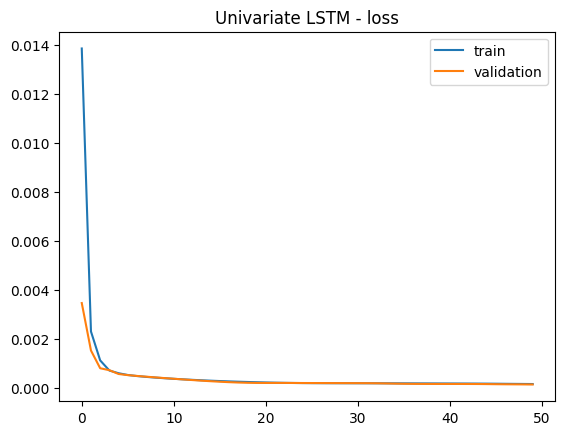

univariate LSTM test MAE: 43.5 MW   (persistence: 129.0)


In [12]:
plt.plot(hist.history["loss"], label="train"); plt.plot(hist.history["val_loss"], label="validation")
plt.title("Univariate LSTM - loss"); plt.legend(); plt.show()

pred_uni = sc_y.inverse_transform(uni.predict(X_te, verbose=0)).ravel()   # back to MW
y_true   = sc_y.inverse_transform(y_te.reshape(-1, 1)).ravel()
mae_uni  = mean_absolute_error(y_true, pred_uni)
print(f"univariate LSTM test MAE: {mae_uni:.1f} MW   (persistence: {baselines.iloc[2]:.1f})")

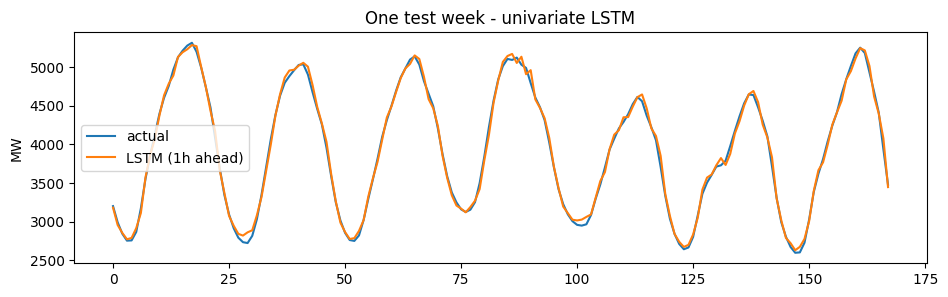

In [13]:
# look at a test week: the model vs reality
i0 = 24*7*26   # a week in mid-year
plt.figure(figsize=(11, 3))
plt.plot(y_true[i0:i0+24*7], label="actual"); plt.plot(pred_uni[i0:i0+24*7], label="LSTM (1h ahead)")
plt.title("One test week - univariate LSTM"); plt.ylabel("MW"); plt.legend(); plt.show()

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 17 — Forecasting electricity demand, Pt 2: add the weather, forecast 24 hours ahead, call the peak
- Multivariate: temperature, dew point, humidity, plus hour-of-day and day-of-week as sin/cos (the clock is a circle: hour 23 is next to hour 0). Demand goes LAST - split_sequences takes the target from the right, and demand's own history STAYS in X (the window method taught you that last hour is the best feature).
- Does the weather + clock help at ONE hour ahead? Here yes: ~44 -> ~34 MW. Say why it isn't more - the last hour already carries most of the weather's effect.
- 24 hours ahead is where it matters: past week -> next 24 hours, Dense(24). Plot MAE by horizon (~167 MW averaged over the day vs 227 seasonal-naive); the fair baseline a day ahead is seasonal-naive, not persistence.
- Peak-hour classification: top-10% hours, sigmoid head, majority baseline is 91.5% - so accuracy is useless, read precision/recall for the peaks (~0.91 / ~0.88).
- Close on reproducibility: the seed, and save -> load_model -> identical predictions. This is the notebook students copy for their projects.
-->


## Add the weather (multivariate)

The model gets to see temperature, dew point, humidity - and the **clock**, encoded as sine/cosine so hour 23 sits next to hour 0. Demand is the **last column** because `split_sequences` takes the target from the right - and demand's own past stays in the inputs, because *what demand did last hour* is the single most useful feature.

In [14]:
def add_clock(d):
    d = d.copy()
    d["hour_sin"] = np.sin(2*np.pi*d.index.hour/24);      d["hour_cos"] = np.cos(2*np.pi*d.index.hour/24)
    d["dow_sin"]  = np.sin(2*np.pi*d.index.dayofweek/7);  d["dow_cos"]  = np.cos(2*np.pi*d.index.dayofweek/7)
    return d

feats = ["BDL_tmpf", "BDL_dwpf", "BDL_relh", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "Demand"]   # Demand LAST
trm, tem = add_clock(train)[feats], add_clock(test)[feats]

sc_X = MinMaxScaler().fit(trm)                 # fit on TRAIN only
trm_s, tem_s = sc_X.transform(trm), sc_X.transform(tem)

def split_sequences(seqs, n_steps):
    X, y = [], []
    for i in range(len(seqs) - n_steps):
        X.append(seqs[i:i+n_steps, :]); y.append(seqs[i+n_steps, -1])   # inputs = EVERY column (demand's own past included); target = last col, NEXT step
    return np.array(X), np.array(y)

Xm_tr, ym_tr = split_sequences(trm_s, n_steps)
Xm_te, ym_te = split_sequences(tem_s, n_steps)
n_features = Xm_tr.shape[2]
print("multivariate train tensor:", Xm_tr.shape, "-> (samples, look-back, features)")

multivariate train tensor: (17496, 24, 8) -> (samples, look-back, features)


In [15]:
multi = Sequential([LSTM(32, input_shape=(n_steps, n_features)), Dense(1)])
multi.compile(optimizer="adam", loss="mse", metrics=["mae"])
hist_m = multi.fit(Xm_tr, ym_tr, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=1)

pred_multi = sc_y.inverse_transform(multi.predict(Xm_te, verbose=0)).ravel()   # Demand scaler = the last column's scaler
mae_multi  = mean_absolute_error(y_true, pred_multi)
pd.Series({"persistence": baselines.iloc[2], "univariate LSTM": mae_uni, "multivariate LSTM (+weather, +clock)": mae_multi},
          name="test MAE, 1 hour ahead (MW)").round(1)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 17:36 5s/step - loss: 0.2835 - mae: 0.4720

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.1287 - mae: 0.2914 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0866 - mae: 0.2291

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0750 - mae: 0.2151

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0634 - mae: 0.1955

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0553 - mae: 0.1804

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0496 - mae: 0.1688

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0458 - mae: 0.1607

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0425 - mae: 0.1544

 44/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0401 - mae: 0.1495

 49/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0374 - mae: 0.1438

 54/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0353 - mae: 0.1395

 59/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0334 - mae: 0.1353

 64/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0317 - mae: 0.1315

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0301 - mae: 0.1276

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0289 - mae: 0.1245

 78/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0275 - mae: 0.1211

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0264 - mae: 0.1182

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0252 - mae: 0.1153

 92/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0244 - mae: 0.1130

 97/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0235 - mae: 0.1106

102/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0226 - mae: 0.1082

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0220 - mae: 0.1062

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0212 - mae: 0.1043

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0205 - mae: 0.1023

121/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0199 - mae: 0.1005

126/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0193 - mae: 0.0986

131/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0187 - mae: 0.0970

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0182 - mae: 0.0953

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0178 - mae: 0.0939

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0173 - mae: 0.0923

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0168 - mae: 0.0908

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0165 - mae: 0.0897

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0161 - mae: 0.0883

164/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0157 - mae: 0.0869

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0153 - mae: 0.0857

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0150 - mae: 0.0845

177/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0147 - mae: 0.0835

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0144 - mae: 0.0825

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0141 - mae: 0.0814

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0138 - mae: 0.0804

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0135 - mae: 0.0793

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0133 - mae: 0.0783

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0130 - mae: 0.0773

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0127 - mae: 0.0763

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0125 - mae: 0.0754

219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0123 - mae: 0.0748 - val_loss: 0.0021 - val_mae: 0.0378


Epoch 2/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - loss: 0.0020 - mae: 0.0377

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0019 - mae: 0.0351  

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0020 - mae: 0.0363

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0020 - mae: 0.0360

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0019 - mae: 0.0356

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0020 - mae: 0.0354

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0019 - mae: 0.0350

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0019 - mae: 0.0347

 41/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0019 - mae: 0.0344

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018 - mae: 0.0342

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018 - mae: 0.0342

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018 - mae: 0.0342

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018 - mae: 0.0340

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018 - mae: 0.0338

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018 - mae: 0.0336

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018 - mae: 0.0335

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017 - mae: 0.0334

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017 - mae: 0.0331

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017 - mae: 0.0330

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017 - mae: 0.0329

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017 - mae: 0.0327

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017 - mae: 0.0324

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016 - mae: 0.0322

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016 - mae: 0.0321

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016 - mae: 0.0320

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016 - mae: 0.0318

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016 - mae: 0.0317

134/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0016 - mae: 0.0317

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0016 - mae: 0.0315

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0016 - mae: 0.0315

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0016 - mae: 0.0314

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0016 - mae: 0.0312

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - mae: 0.0311

164/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - mae: 0.0309

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - mae: 0.0308

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - mae: 0.0307

179/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - mae: 0.0306

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - mae: 0.0305

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - mae: 0.0304

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - mae: 0.0303

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - mae: 0.0302

202/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - mae: 0.0301

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - mae: 0.0300

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - mae: 0.0299

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0014 - mae: 0.0298

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0014 - mae: 0.0297 - val_loss: 0.0010 - val_mae: 0.0245


Epoch 3/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 7:55 2s/step - loss: 0.0012 - mae: 0.0261

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.8616e-04 - mae: 0.0249

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0011 - mae: 0.0259    

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0010 - mae: 0.0253

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0011 - mae: 0.0252

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0011 - mae: 0.0252

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0011 - mae: 0.0249

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0010 - mae: 0.0248

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0011 - mae: 0.0249

 45/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0010 - mae: 0.0247

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0010 - mae: 0.0247

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0010 - mae: 0.0247

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0010 - mae: 0.0245

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0010 - mae: 0.0244

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.9865e-04 - mae: 0.0243

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.9863e-04 - mae: 0.0242

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.9374e-04 - mae: 0.0242

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.9060e-04 - mae: 0.0242

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.8932e-04 - mae: 0.0241

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.8500e-04 - mae: 0.0241

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.7758e-04 - mae: 0.0240

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.6289e-04 - mae: 0.0238

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.6257e-04 - mae: 0.0238

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.5966e-04 - mae: 0.0238

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.6337e-04 - mae: 0.0238

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.6056e-04 - mae: 0.0238

130/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.6195e-04 - mae: 0.0238

135/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.5611e-04 - mae: 0.0237

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.5457e-04 - mae: 0.0237

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.5345e-04 - mae: 0.0237

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.5694e-04 - mae: 0.0237

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.4846e-04 - mae: 0.0236

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.4723e-04 - mae: 0.0235

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.4410e-04 - mae: 0.0235

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.4141e-04 - mae: 0.0234

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.3959e-04 - mae: 0.0234

179/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.3782e-04 - mae: 0.0234

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.3724e-04 - mae: 0.0234

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.3148e-04 - mae: 0.0233

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2958e-04 - mae: 0.0233

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2597e-04 - mae: 0.0232

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2286e-04 - mae: 0.0232

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2116e-04 - mae: 0.0232

214/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.1804e-04 - mae: 0.0232

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.1297e-04 - mae: 0.0231

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 9.1297e-04 - mae: 0.0231 - val_loss: 8.1446e-04 - val_mae: 0.0214


Epoch 4/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 8:07 2s/step - loss: 0.0010 - mae: 0.0233

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.0377e-04 - mae: 0.0224

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.5970e-04 - mae: 0.0232

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.3400e-04 - mae: 0.0225

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.5991e-04 - mae: 0.0227

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.4966e-04 - mae: 0.0225

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.3157e-04 - mae: 0.0222

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.1774e-04 - mae: 0.0221

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.2289e-04 - mae: 0.0221

 45/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.0813e-04 - mae: 0.0218

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.0337e-04 - mae: 0.0218

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.0043e-04 - mae: 0.0217

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.8855e-04 - mae: 0.0216

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.7875e-04 - mae: 0.0214

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.7364e-04 - mae: 0.0214

 74/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.6840e-04 - mae: 0.0213

 78/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.6779e-04 - mae: 0.0213

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.6247e-04 - mae: 0.0212

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.6242e-04 - mae: 0.0212

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.5978e-04 - mae: 0.0211

 98/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.5822e-04 - mae: 0.0211

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.4756e-04 - mae: 0.0210

108/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.4638e-04 - mae: 0.0210

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.4882e-04 - mae: 0.0210

117/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.5512e-04 - mae: 0.0211

121/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.5556e-04 - mae: 0.0211

126/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.5461e-04 - mae: 0.0211

131/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.5370e-04 - mae: 0.0211

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.5061e-04 - mae: 0.0211

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.5266e-04 - mae: 0.0211

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.5201e-04 - mae: 0.0211

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.5587e-04 - mae: 0.0211

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.5036e-04 - mae: 0.0210

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.5058e-04 - mae: 0.0210

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.4869e-04 - mae: 0.0210

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.4605e-04 - mae: 0.0209

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.4658e-04 - mae: 0.0209

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.4841e-04 - mae: 0.0210

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.4691e-04 - mae: 0.0210

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.4268e-04 - mae: 0.0209

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.4373e-04 - mae: 0.0209

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.4198e-04 - mae: 0.0209

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.4055e-04 - mae: 0.0209

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.4029e-04 - mae: 0.0209

214/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.3876e-04 - mae: 0.0209

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.3605e-04 - mae: 0.0208

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 7.3605e-04 - mae: 0.0208 - val_loss: 7.2751e-04 - val_mae: 0.0206


Epoch 5/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - loss: 8.9483e-04 - mae: 0.0223

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 6.8566e-04 - mae: 0.0209 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 7.2803e-04 - mae: 0.0216

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.0162e-04 - mae: 0.0211

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.1376e-04 - mae: 0.0210

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.2221e-04 - mae: 0.0210

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.0170e-04 - mae: 0.0206

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.8842e-04 - mae: 0.0204

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.9385e-04 - mae: 0.0204

 45/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.8239e-04 - mae: 0.0202

 49/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.7822e-04 - mae: 0.0202

 54/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.7240e-04 - mae: 0.0201

 58/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.6651e-04 - mae: 0.0200

 62/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.6023e-04 - mae: 0.0199

 67/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.5609e-04 - mae: 0.0198

 72/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.5009e-04 - mae: 0.0197

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.5150e-04 - mae: 0.0198

 82/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.4653e-04 - mae: 0.0197

 87/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.4885e-04 - mae: 0.0197

 92/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.4540e-04 - mae: 0.0197

 97/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.4776e-04 - mae: 0.0197

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.4233e-04 - mae: 0.0196

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.3849e-04 - mae: 0.0196

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.3901e-04 - mae: 0.0196

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.4003e-04 - mae: 0.0196

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.4709e-04 - mae: 0.0197

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.4733e-04 - mae: 0.0197

130/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.4865e-04 - mae: 0.0197

135/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.4394e-04 - mae: 0.0196

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.4364e-04 - mae: 0.0197

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.4500e-04 - mae: 0.0197

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.4818e-04 - mae: 0.0197

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.4336e-04 - mae: 0.0196

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.4408e-04 - mae: 0.0196

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.4269e-04 - mae: 0.0196

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.4059e-04 - mae: 0.0196

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.4137e-04 - mae: 0.0196

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.4306e-04 - mae: 0.0196

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.4180e-04 - mae: 0.0196

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.3835e-04 - mae: 0.0195

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.3944e-04 - mae: 0.0196

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.3834e-04 - mae: 0.0195

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.3660e-04 - mae: 0.0195

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.3592e-04 - mae: 0.0195

214/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.3604e-04 - mae: 0.0195

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.3449e-04 - mae: 0.0195

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 6.3449e-04 - mae: 0.0195 - val_loss: 6.6928e-04 - val_mae: 0.0201


Epoch 6/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 25s 117ms/step - loss: 8.0407e-04 - mae: 0.0213

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.8537e-04 - mae: 0.0192  

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.2156e-04 - mae: 0.0199

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5.9911e-04 - mae: 0.0195

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 6.1105e-04 - mae: 0.0194

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 6.1856e-04 - mae: 0.0195

 29/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 6.0859e-04 - mae: 0.0193

 34/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.9219e-04 - mae: 0.0190

 39/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.9637e-04 - mae: 0.0190

 43/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5.8931e-04 - mae: 0.0189

 48/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.8557e-04 - mae: 0.0188

 53/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.7960e-04 - mae: 0.0187

 57/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.7779e-04 - mae: 0.0187

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.7229e-04 - mae: 0.0186

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.6668e-04 - mae: 0.0185

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.6597e-04 - mae: 0.0185

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.6582e-04 - mae: 0.0185

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.6205e-04 - mae: 0.0185

 84/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.6057e-04 - mae: 0.0184

 89/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.6234e-04 - mae: 0.0184

 94/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.6134e-04 - mae: 0.0184

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.6177e-04 - mae: 0.0184

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.5785e-04 - mae: 0.0184

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.5883e-04 - mae: 0.0184

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.5978e-04 - mae: 0.0184

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.6695e-04 - mae: 0.0185

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.6758e-04 - mae: 0.0185

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.6830e-04 - mae: 0.0186

134/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.6489e-04 - mae: 0.0185

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.6438e-04 - mae: 0.0185

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.6707e-04 - mae: 0.0185

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.6937e-04 - mae: 0.0185

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.6414e-04 - mae: 0.0185

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.6282e-04 - mae: 0.0184

164/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.6360e-04 - mae: 0.0184

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.6247e-04 - mae: 0.0184

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.6269e-04 - mae: 0.0184

179/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.6304e-04 - mae: 0.0184

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.6326e-04 - mae: 0.0184

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.6025e-04 - mae: 0.0184

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.6064e-04 - mae: 0.0184

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.5975e-04 - mae: 0.0184

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.5858e-04 - mae: 0.0184

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.5874e-04 - mae: 0.0184

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.5789e-04 - mae: 0.0184

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.5747e-04 - mae: 0.0184

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5.5696e-04 - mae: 0.0184 - val_loss: 5.9507e-04 - val_mae: 0.0190


Epoch 7/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 7:50 2s/step - loss: 7.1642e-04 - mae: 0.0198

  7/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.0857e-04 - mae: 0.0179

 13/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.3636e-04 - mae: 0.0184

 18/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.3209e-04 - mae: 0.0181

 23/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.4941e-04 - mae: 0.0183

 28/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.4188e-04 - mae: 0.0182

 33/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.2413e-04 - mae: 0.0179

 38/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.2666e-04 - mae: 0.0179

 43/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.2209e-04 - mae: 0.0178

 48/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.1835e-04 - mae: 0.0177

 53/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.1380e-04 - mae: 0.0176

 58/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.1042e-04 - mae: 0.0176

 63/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.0544e-04 - mae: 0.0175

 68/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.0144e-04 - mae: 0.0174

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.0156e-04 - mae: 0.0175

 78/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.0037e-04 - mae: 0.0174

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.9812e-04 - mae: 0.0174

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.9750e-04 - mae: 0.0174

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.9983e-04 - mae: 0.0174

 98/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.0203e-04 - mae: 0.0175

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.9829e-04 - mae: 0.0174

108/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.9915e-04 - mae: 0.0174

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.9882e-04 - mae: 0.0174

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.0548e-04 - mae: 0.0175

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.0686e-04 - mae: 0.0175

128/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.0754e-04 - mae: 0.0176

134/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.0511e-04 - mae: 0.0175

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.0558e-04 - mae: 0.0175

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.0568e-04 - mae: 0.0175

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.0639e-04 - mae: 0.0175

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.0223e-04 - mae: 0.0175

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.0324e-04 - mae: 0.0175

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.0373e-04 - mae: 0.0175

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.0200e-04 - mae: 0.0174

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.0222e-04 - mae: 0.0175

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.0299e-04 - mae: 0.0175

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.0229e-04 - mae: 0.0175

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.0055e-04 - mae: 0.0174

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.0224e-04 - mae: 0.0175

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.0060e-04 - mae: 0.0174

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9930e-04 - mae: 0.0174

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9902e-04 - mae: 0.0174

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.0055e-04 - mae: 0.0175

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 4.9873e-04 - mae: 0.0174 - val_loss: 5.1208e-04 - val_mae: 0.0177


Epoch 8/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - loss: 6.4250e-04 - mae: 0.0184

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.6645e-04 - mae: 0.0171 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.0495e-04 - mae: 0.0180

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.9430e-04 - mae: 0.0176

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.0741e-04 - mae: 0.0178

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.9640e-04 - mae: 0.0175

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.8492e-04 - mae: 0.0173

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.7822e-04 - mae: 0.0172

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.8486e-04 - mae: 0.0173

 44/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.7608e-04 - mae: 0.0171

 49/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.7105e-04 - mae: 0.0170

 54/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6790e-04 - mae: 0.0169

 59/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6140e-04 - mae: 0.0168

 64/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5722e-04 - mae: 0.0167

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5687e-04 - mae: 0.0167

 74/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5561e-04 - mae: 0.0167

 79/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5578e-04 - mae: 0.0167

 84/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5275e-04 - mae: 0.0167

 89/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5319e-04 - mae: 0.0167

 94/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5362e-04 - mae: 0.0167

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5568e-04 - mae: 0.0167

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5400e-04 - mae: 0.0167

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5456e-04 - mae: 0.0167

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5455e-04 - mae: 0.0167

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6036e-04 - mae: 0.0168

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6149e-04 - mae: 0.0168

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6246e-04 - mae: 0.0168

134/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5992e-04 - mae: 0.0168

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.6085e-04 - mae: 0.0168

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.6264e-04 - mae: 0.0168

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.6404e-04 - mae: 0.0168

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5987e-04 - mae: 0.0168

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5855e-04 - mae: 0.0167

164/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5923e-04 - mae: 0.0167

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5845e-04 - mae: 0.0167

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5883e-04 - mae: 0.0167

179/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5932e-04 - mae: 0.0167

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5936e-04 - mae: 0.0167

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5711e-04 - mae: 0.0167

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5777e-04 - mae: 0.0167

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5720e-04 - mae: 0.0167

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5613e-04 - mae: 0.0167

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5608e-04 - mae: 0.0167

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5517e-04 - mae: 0.0167

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5596e-04 - mae: 0.0167

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 4.5557e-04 - mae: 0.0167 - val_loss: 4.5598e-04 - val_mae: 0.0166


Epoch 9/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 7:23 2s/step - loss: 6.0816e-04 - mae: 0.0180

  5/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.5832e-04 - mae: 0.0169

 10/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.7870e-04 - mae: 0.0175

 14/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.7644e-04 - mae: 0.0175

 19/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.6883e-04 - mae: 0.0172

 23/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.7833e-04 - mae: 0.0173

 27/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.6740e-04 - mae: 0.0172

 32/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.5389e-04 - mae: 0.0169

 37/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.5375e-04 - mae: 0.0169

 42/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.5069e-04 - mae: 0.0168

 47/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.4272e-04 - mae: 0.0165

 52/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.3883e-04 - mae: 0.0165

 57/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.3601e-04 - mae: 0.0164

 62/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.2801e-04 - mae: 0.0162

 67/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.2611e-04 - mae: 0.0162

 72/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.2397e-04 - mae: 0.0162

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.2308e-04 - mae: 0.0161

 82/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.1945e-04 - mae: 0.0161

 87/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.2026e-04 - mae: 0.0161

 92/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.2004e-04 - mae: 0.0161

 97/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.2469e-04 - mae: 0.0162

102/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.2238e-04 - mae: 0.0161

107/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.2307e-04 - mae: 0.0161

112/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.2182e-04 - mae: 0.0161

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.2478e-04 - mae: 0.0162

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.2699e-04 - mae: 0.0162

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.2789e-04 - mae: 0.0162

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.2816e-04 - mae: 0.0162

132/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.2712e-04 - mae: 0.0162

134/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.2653e-04 - mae: 0.0162

139/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.2772e-04 - mae: 0.0162

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.3006e-04 - mae: 0.0162

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2844e-04 - mae: 0.0162

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.3042e-04 - mae: 0.0162

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2730e-04 - mae: 0.0162

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2612e-04 - mae: 0.0162

164/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2662e-04 - mae: 0.0162

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2582e-04 - mae: 0.0161

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2606e-04 - mae: 0.0161

179/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2651e-04 - mae: 0.0162

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2651e-04 - mae: 0.0162

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2442e-04 - mae: 0.0161

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2532e-04 - mae: 0.0161

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2549e-04 - mae: 0.0161

202/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2428e-04 - mae: 0.0161

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2434e-04 - mae: 0.0161

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2331e-04 - mae: 0.0161

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.2343e-04 - mae: 0.0161

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 4.2306e-04 - mae: 0.0161 - val_loss: 4.4458e-04 - val_mae: 0.0164


Epoch 10/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - loss: 6.1567e-04 - mae: 0.0183

  5/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.5175e-04 - mae: 0.0167 

 10/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.6474e-04 - mae: 0.0171

 14/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.6112e-04 - mae: 0.0172

 19/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.5024e-04 - mae: 0.0168

 24/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.5403e-04 - mae: 0.0169

 28/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.4548e-04 - mae: 0.0168

 33/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.3061e-04 - mae: 0.0164

 38/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.3208e-04 - mae: 0.0164

 42/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.2915e-04 - mae: 0.0164

 45/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.2519e-04 - mae: 0.0162

 49/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.1927e-04 - mae: 0.0161

 54/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.1591e-04 - mae: 0.0160

 59/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.0974e-04 - mae: 0.0159

 63/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.0529e-04 - mae: 0.0158

 67/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.0380e-04 - mae: 0.0158

 72/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.0132e-04 - mae: 0.0157

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.9973e-04 - mae: 0.0157

 82/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.9577e-04 - mae: 0.0156

 87/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.9615e-04 - mae: 0.0156

 92/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.9619e-04 - mae: 0.0156

 97/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.0049e-04 - mae: 0.0157

102/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.9863e-04 - mae: 0.0157

107/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.9911e-04 - mae: 0.0157

112/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.9762e-04 - mae: 0.0157

117/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.9986e-04 - mae: 0.0157

122/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.0170e-04 - mae: 0.0157

127/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.0248e-04 - mae: 0.0157

132/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.0126e-04 - mae: 0.0157

137/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.0051e-04 - mae: 0.0157

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.0363e-04 - mae: 0.0158

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.0293e-04 - mae: 0.0157

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.0479e-04 - mae: 0.0158

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.0115e-04 - mae: 0.0157

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.0148e-04 - mae: 0.0157

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.0066e-04 - mae: 0.0157

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.9940e-04 - mae: 0.0157

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.9983e-04 - mae: 0.0156

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.0083e-04 - mae: 0.0157

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.0033e-04 - mae: 0.0157

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.9848e-04 - mae: 0.0156

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.9918e-04 - mae: 0.0157

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.0030e-04 - mae: 0.0157

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.9947e-04 - mae: 0.0157

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.9808e-04 - mae: 0.0156

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.9748e-04 - mae: 0.0156

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.9705e-04 - mae: 0.0156

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3.9652e-04 - mae: 0.0156 - val_loss: 4.5262e-04 - val_mae: 0.0165


Epoch 11/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - loss: 6.2763e-04 - mae: 0.0187

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.2747e-04 - mae: 0.0163 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.4269e-04 - mae: 0.0167

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.3396e-04 - mae: 0.0165

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.3732e-04 - mae: 0.0166

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.2066e-04 - mae: 0.0163

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.1078e-04 - mae: 0.0160

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.0314e-04 - mae: 0.0159

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.0867e-04 - mae: 0.0160

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.0089e-04 - mae: 0.0158

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.9462e-04 - mae: 0.0157

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.9157e-04 - mae: 0.0156

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8582e-04 - mae: 0.0154

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8215e-04 - mae: 0.0154

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7975e-04 - mae: 0.0153

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7759e-04 - mae: 0.0153

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7480e-04 - mae: 0.0152

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7347e-04 - mae: 0.0152

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7427e-04 - mae: 0.0152

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7519e-04 - mae: 0.0152

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7705e-04 - mae: 0.0153

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7509e-04 - mae: 0.0152

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7507e-04 - mae: 0.0152

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7446e-04 - mae: 0.0152

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7819e-04 - mae: 0.0153

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7834e-04 - mae: 0.0153

130/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7916e-04 - mae: 0.0153

135/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7697e-04 - mae: 0.0153

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7779e-04 - mae: 0.0153

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.8024e-04 - mae: 0.0153

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.8142e-04 - mae: 0.0153

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7788e-04 - mae: 0.0152

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7656e-04 - mae: 0.0152

164/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7664e-04 - mae: 0.0152

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7580e-04 - mae: 0.0152

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7566e-04 - mae: 0.0152

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7631e-04 - mae: 0.0152

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7666e-04 - mae: 0.0152

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7466e-04 - mae: 0.0152

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7602e-04 - mae: 0.0152

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7661e-04 - mae: 0.0152

202/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7509e-04 - mae: 0.0152

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7442e-04 - mae: 0.0152

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7356e-04 - mae: 0.0151

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7331e-04 - mae: 0.0151

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7230e-04 - mae: 0.0151

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3.7230e-04 - mae: 0.0151 - val_loss: 4.5294e-04 - val_mae: 0.0165


Epoch 12/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - loss: 6.2033e-04 - mae: 0.0187

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.0726e-04 - mae: 0.0160 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.1559e-04 - mae: 0.0162

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.0459e-04 - mae: 0.0159

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.0512e-04 - mae: 0.0159

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.9066e-04 - mae: 0.0157

 31/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8289e-04 - mae: 0.0155

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7543e-04 - mae: 0.0154

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8088e-04 - mae: 0.0154

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.7297e-04 - mae: 0.0152

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.6786e-04 - mae: 0.0151

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.6532e-04 - mae: 0.0151

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5944e-04 - mae: 0.0149

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5549e-04 - mae: 0.0148

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5306e-04 - mae: 0.0148

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5050e-04 - mae: 0.0147

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.4827e-04 - mae: 0.0147

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.4691e-04 - mae: 0.0146

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.4688e-04 - mae: 0.0146

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5017e-04 - mae: 0.0147

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5103e-04 - mae: 0.0147

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5084e-04 - mae: 0.0147

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5055e-04 - mae: 0.0147

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5218e-04 - mae: 0.0147

121/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5316e-04 - mae: 0.0148

126/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5403e-04 - mae: 0.0148

131/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5388e-04 - mae: 0.0148

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5319e-04 - mae: 0.0148

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5500e-04 - mae: 0.0148

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5532e-04 - mae: 0.0148

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5635e-04 - mae: 0.0148

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5277e-04 - mae: 0.0147

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5316e-04 - mae: 0.0147

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5315e-04 - mae: 0.0147

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5168e-04 - mae: 0.0147

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5245e-04 - mae: 0.0147

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5313e-04 - mae: 0.0147

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5248e-04 - mae: 0.0147

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5230e-04 - mae: 0.0147

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5412e-04 - mae: 0.0147

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5347e-04 - mae: 0.0147

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5202e-04 - mae: 0.0147

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5104e-04 - mae: 0.0147

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5036e-04 - mae: 0.0147

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 3.4960e-04 - mae: 0.0146 - val_loss: 4.4267e-04 - val_mae: 0.0163


Epoch 13/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - loss: 5.9834e-04 - mae: 0.0183

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.8478e-04 - mae: 0.0155 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.8970e-04 - mae: 0.0156

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.7540e-04 - mae: 0.0152

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.7420e-04 - mae: 0.0153

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.6098e-04 - mae: 0.0150

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.5454e-04 - mae: 0.0149

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.4803e-04 - mae: 0.0148

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5236e-04 - mae: 0.0149

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.4442e-04 - mae: 0.0146

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.4021e-04 - mae: 0.0146

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3737e-04 - mae: 0.0145

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3177e-04 - mae: 0.0143

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2835e-04 - mae: 0.0143

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2633e-04 - mae: 0.0142

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2467e-04 - mae: 0.0142

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2254e-04 - mae: 0.0141

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2125e-04 - mae: 0.0141

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2131e-04 - mae: 0.0141

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2399e-04 - mae: 0.0142

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2584e-04 - mae: 0.0142

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2494e-04 - mae: 0.0142

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2588e-04 - mae: 0.0142

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2547e-04 - mae: 0.0142

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3010e-04 - mae: 0.0143

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3073e-04 - mae: 0.0143

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3073e-04 - mae: 0.0143

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2969e-04 - mae: 0.0143

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2985e-04 - mae: 0.0143

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3342e-04 - mae: 0.0143

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3487e-04 - mae: 0.0143

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3270e-04 - mae: 0.0143

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3015e-04 - mae: 0.0142

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3075e-04 - mae: 0.0142

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2993e-04 - mae: 0.0142

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2961e-04 - mae: 0.0142

177/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3123e-04 - mae: 0.0142

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3152e-04 - mae: 0.0143

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3111e-04 - mae: 0.0142

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3196e-04 - mae: 0.0143

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3360e-04 - mae: 0.0143

202/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3237e-04 - mae: 0.0143

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3167e-04 - mae: 0.0143

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3050e-04 - mae: 0.0142

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2975e-04 - mae: 0.0142

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 3.2913e-04 - mae: 0.0142 - val_loss: 4.2313e-04 - val_mae: 0.0160


Epoch 14/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - loss: 5.6626e-04 - mae: 0.0178

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.6179e-04 - mae: 0.0150 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.6550e-04 - mae: 0.0151

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.4875e-04 - mae: 0.0146

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.4671e-04 - mae: 0.0146

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.3348e-04 - mae: 0.0144

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.2811e-04 - mae: 0.0143

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2291e-04 - mae: 0.0142

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2594e-04 - mae: 0.0143

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1851e-04 - mae: 0.0141

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1469e-04 - mae: 0.0140

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1148e-04 - mae: 0.0139

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0656e-04 - mae: 0.0138

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0365e-04 - mae: 0.0137

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0258e-04 - mae: 0.0137

 74/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0210e-04 - mae: 0.0137

 79/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0120e-04 - mae: 0.0137

 84/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9860e-04 - mae: 0.0136

 89/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9812e-04 - mae: 0.0136

 94/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0083e-04 - mae: 0.0136

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0269e-04 - mae: 0.0137

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0294e-04 - mae: 0.0137

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0424e-04 - mae: 0.0137

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0547e-04 - mae: 0.0137

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0949e-04 - mae: 0.0138

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1000e-04 - mae: 0.0138

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1060e-04 - mae: 0.0138

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.0924e-04 - mae: 0.0138

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.0937e-04 - mae: 0.0138

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1283e-04 - mae: 0.0139

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1439e-04 - mae: 0.0139

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1265e-04 - mae: 0.0138

157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.1089e-04 - mae: 0.0138

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.1103e-04 - mae: 0.0138

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.1012e-04 - mae: 0.0138

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.0907e-04 - mae: 0.0138

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.1013e-04 - mae: 0.0138

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.1227e-04 - mae: 0.0138

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.1203e-04 - mae: 0.0138

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.1335e-04 - mae: 0.0138

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.1449e-04 - mae: 0.0139

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.1485e-04 - mae: 0.0139

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.1412e-04 - mae: 0.0139

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.1350e-04 - mae: 0.0138

214/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.1195e-04 - mae: 0.0138

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.1121e-04 - mae: 0.0138

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3.1121e-04 - mae: 0.0138 - val_loss: 3.9854e-04 - val_mae: 0.0155


Epoch 15/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step - loss: 5.3175e-04 - mae: 0.0171

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.3990e-04 - mae: 0.0145 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.4325e-04 - mae: 0.0145

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.2589e-04 - mae: 0.0141

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.2347e-04 - mae: 0.0141

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.1225e-04 - mae: 0.0139

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.0428e-04 - mae: 0.0137

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.0354e-04 - mae: 0.0138

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.0498e-04 - mae: 0.0138

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9774e-04 - mae: 0.0136

 49/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.9384e-04 - mae: 0.0135

 54/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.9149e-04 - mae: 0.0134

 59/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8834e-04 - mae: 0.0133

 64/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8381e-04 - mae: 0.0132

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8266e-04 - mae: 0.0132

 74/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8236e-04 - mae: 0.0132

 79/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8158e-04 - mae: 0.0132

 84/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.7932e-04 - mae: 0.0131

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.7805e-04 - mae: 0.0131

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8103e-04 - mae: 0.0132

 98/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8275e-04 - mae: 0.0132

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8426e-04 - mae: 0.0132

108/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8574e-04 - mae: 0.0133

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8641e-04 - mae: 0.0133

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9198e-04 - mae: 0.0134

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9262e-04 - mae: 0.0134

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9300e-04 - mae: 0.0134

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.9191e-04 - mae: 0.0134

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.9203e-04 - mae: 0.0134

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.9505e-04 - mae: 0.0134

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.9658e-04 - mae: 0.0135

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.9515e-04 - mae: 0.0134

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.9304e-04 - mae: 0.0134

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.9328e-04 - mae: 0.0134

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.9243e-04 - mae: 0.0134

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.9208e-04 - mae: 0.0133

177/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.9415e-04 - mae: 0.0134

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.9516e-04 - mae: 0.0134

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.9514e-04 - mae: 0.0134

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.9619e-04 - mae: 0.0134

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.9898e-04 - mae: 0.0135

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.9850e-04 - mae: 0.0135

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.9734e-04 - mae: 0.0135

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.9633e-04 - mae: 0.0134

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.9574e-04 - mae: 0.0134

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2.9502e-04 - mae: 0.0134 - val_loss: 3.8156e-04 - val_mae: 0.0151


Epoch 16/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - loss: 5.1386e-04 - mae: 0.0168

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.2421e-04 - mae: 0.0141 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.2591e-04 - mae: 0.0141

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.0798e-04 - mae: 0.0137

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.0491e-04 - mae: 0.0137

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.9126e-04 - mae: 0.0134

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.8726e-04 - mae: 0.0133

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.8322e-04 - mae: 0.0133

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8524e-04 - mae: 0.0133

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.7927e-04 - mae: 0.0131

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.7596e-04 - mae: 0.0130

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.7292e-04 - mae: 0.0129

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6949e-04 - mae: 0.0128

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6714e-04 - mae: 0.0128

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6574e-04 - mae: 0.0128

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6569e-04 - mae: 0.0128

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6364e-04 - mae: 0.0127

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6292e-04 - mae: 0.0127

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6330e-04 - mae: 0.0127

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6660e-04 - mae: 0.0128

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6770e-04 - mae: 0.0128

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6888e-04 - mae: 0.0128

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.7007e-04 - mae: 0.0128

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.7261e-04 - mae: 0.0129

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.7678e-04 - mae: 0.0130

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.7732e-04 - mae: 0.0130

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.7766e-04 - mae: 0.0130

132/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.7704e-04 - mae: 0.0130

137/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.7647e-04 - mae: 0.0130

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.7785e-04 - mae: 0.0130

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.7889e-04 - mae: 0.0130

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.8013e-04 - mae: 0.0130

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.7754e-04 - mae: 0.0130

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.7760e-04 - mae: 0.0130

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.7709e-04 - mae: 0.0130

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.7654e-04 - mae: 0.0130

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.7642e-04 - mae: 0.0129

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.7831e-04 - mae: 0.0130

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.7953e-04 - mae: 0.0130

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.7955e-04 - mae: 0.0130

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.8050e-04 - mae: 0.0130

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.8323e-04 - mae: 0.0131

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.8257e-04 - mae: 0.0131

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.8164e-04 - mae: 0.0131

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.8136e-04 - mae: 0.0131

214/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.8005e-04 - mae: 0.0130

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.8004e-04 - mae: 0.0130

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 2.7965e-04 - mae: 0.0130 - val_loss: 3.7447e-04 - val_mae: 0.0150


Epoch 17/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 7:06 2s/step - loss: 5.1363e-04 - mae: 0.0169

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.1456e-04 - mae: 0.0138

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.1277e-04 - mae: 0.0137

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.9331e-04 - mae: 0.0133

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.8911e-04 - mae: 0.0132

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.7532e-04 - mae: 0.0129

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.7137e-04 - mae: 0.0129

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.6722e-04 - mae: 0.0128

 41/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.6881e-04 - mae: 0.0129

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6354e-04 - mae: 0.0127

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6052e-04 - mae: 0.0126

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5768e-04 - mae: 0.0125

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5496e-04 - mae: 0.0124

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5265e-04 - mae: 0.0124

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5102e-04 - mae: 0.0124

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5123e-04 - mae: 0.0123

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.4906e-04 - mae: 0.0123

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.4832e-04 - mae: 0.0123

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.4851e-04 - mae: 0.0123

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5157e-04 - mae: 0.0124

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5245e-04 - mae: 0.0124

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5455e-04 - mae: 0.0124

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5526e-04 - mae: 0.0124

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5637e-04 - mae: 0.0125

117/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.6012e-04 - mae: 0.0126

122/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.6276e-04 - mae: 0.0126

127/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.6268e-04 - mae: 0.0126

131/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.6333e-04 - mae: 0.0126

135/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6224e-04 - mae: 0.0126

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6294e-04 - mae: 0.0126

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6427e-04 - mae: 0.0126

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6535e-04 - mae: 0.0127

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6420e-04 - mae: 0.0126

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6249e-04 - mae: 0.0126

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6287e-04 - mae: 0.0126

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6211e-04 - mae: 0.0126

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6168e-04 - mae: 0.0126

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6344e-04 - mae: 0.0126

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6503e-04 - mae: 0.0126

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6459e-04 - mae: 0.0126

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6614e-04 - mae: 0.0127

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6780e-04 - mae: 0.0127

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6734e-04 - mae: 0.0127

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6639e-04 - mae: 0.0127

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6555e-04 - mae: 0.0126

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6513e-04 - mae: 0.0126

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 2.6465e-04 - mae: 0.0126 - val_loss: 3.6854e-04 - val_mae: 0.0149


Epoch 18/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - loss: 5.1270e-04 - mae: 0.0170

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.0538e-04 - mae: 0.0135 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.9945e-04 - mae: 0.0134

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.8125e-04 - mae: 0.0129

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.6979e-04 - mae: 0.0127

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.6252e-04 - mae: 0.0126

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.5371e-04 - mae: 0.0124

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.5330e-04 - mae: 0.0125

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.5384e-04 - mae: 0.0125

 45/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.4834e-04 - mae: 0.0123

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.4471e-04 - mae: 0.0122

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.4347e-04 - mae: 0.0121

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.4144e-04 - mae: 0.0121

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3867e-04 - mae: 0.0120

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3700e-04 - mae: 0.0120

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3667e-04 - mae: 0.0119

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3519e-04 - mae: 0.0119

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3437e-04 - mae: 0.0119

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3412e-04 - mae: 0.0119

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3658e-04 - mae: 0.0119

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3750e-04 - mae: 0.0120

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3919e-04 - mae: 0.0120

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.4037e-04 - mae: 0.0120

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.4471e-04 - mae: 0.0121

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.4873e-04 - mae: 0.0122

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.4908e-04 - mae: 0.0123

130/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.4910e-04 - mae: 0.0122

135/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4805e-04 - mae: 0.0122

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4855e-04 - mae: 0.0122

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4932e-04 - mae: 0.0122

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.5023e-04 - mae: 0.0122

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4838e-04 - mae: 0.0122

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4833e-04 - mae: 0.0122

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4743e-04 - mae: 0.0122

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4659e-04 - mae: 0.0121

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4735e-04 - mae: 0.0122

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4844e-04 - mae: 0.0122

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.4981e-04 - mae: 0.0122

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.4962e-04 - mae: 0.0122

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.5035e-04 - mae: 0.0122

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.5126e-04 - mae: 0.0123

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.5220e-04 - mae: 0.0123

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.5113e-04 - mae: 0.0123

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.5073e-04 - mae: 0.0122

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.5002e-04 - mae: 0.0122

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.4983e-04 - mae: 0.0122

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.4913e-04 - mae: 0.0122

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 2.4913e-04 - mae: 0.0122 - val_loss: 3.5435e-04 - val_mae: 0.0147


Epoch 19/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 7:00 2s/step - loss: 4.9093e-04 - mae: 0.0166

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.8984e-04 - mae: 0.0130

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.8128e-04 - mae: 0.0129

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.6054e-04 - mae: 0.0124

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.5142e-04 - mae: 0.0122

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.4488e-04 - mae: 0.0121

 29/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.3733e-04 - mae: 0.0119

 33/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.3593e-04 - mae: 0.0119

 38/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.3603e-04 - mae: 0.0119

 41/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.3387e-04 - mae: 0.0119

 45/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.3082e-04 - mae: 0.0118

 50/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.2800e-04 - mae: 0.0117

 54/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.2753e-04 - mae: 0.0117

 58/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 2.2677e-04 - mae: 0.0116

 63/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.2420e-04 - mae: 0.0116

 67/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.2330e-04 - mae: 0.0115

 72/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.2100e-04 - mae: 0.0115

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.2132e-04 - mae: 0.0115

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.1938e-04 - mae: 0.0114

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.1910e-04 - mae: 0.0114

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.1854e-04 - mae: 0.0114

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.2119e-04 - mae: 0.0115

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.2181e-04 - mae: 0.0115

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.2335e-04 - mae: 0.0115

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.2426e-04 - mae: 0.0116

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.2949e-04 - mae: 0.0117

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.3320e-04 - mae: 0.0118

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.3375e-04 - mae: 0.0118

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.3356e-04 - mae: 0.0118

134/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.3278e-04 - mae: 0.0118

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3293e-04 - mae: 0.0118

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3351e-04 - mae: 0.0118

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3425e-04 - mae: 0.0118

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3257e-04 - mae: 0.0117

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3160e-04 - mae: 0.0117

164/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3140e-04 - mae: 0.0117

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3090e-04 - mae: 0.0117

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3071e-04 - mae: 0.0117

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3208e-04 - mae: 0.0117

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3361e-04 - mae: 0.0118

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3327e-04 - mae: 0.0117

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3288e-04 - mae: 0.0117

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3418e-04 - mae: 0.0118

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3491e-04 - mae: 0.0118

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3447e-04 - mae: 0.0118

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3380e-04 - mae: 0.0118

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3339e-04 - mae: 0.0118

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3288e-04 - mae: 0.0117

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 2.3220e-04 - mae: 0.0117 - val_loss: 3.3349e-04 - val_mae: 0.0142


Epoch 20/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 7:24 2s/step - loss: 4.5589e-04 - mae: 0.0158

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.6731e-04 - mae: 0.0124

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.5843e-04 - mae: 0.0122

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.4011e-04 - mae: 0.0118

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.3494e-04 - mae: 0.0117

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.2275e-04 - mae: 0.0114

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1751e-04 - mae: 0.0113

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1295e-04 - mae: 0.0112

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.1383e-04 - mae: 0.0113

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.1130e-04 - mae: 0.0112

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.1081e-04 - mae: 0.0112

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0890e-04 - mae: 0.0111

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0854e-04 - mae: 0.0111

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0722e-04 - mae: 0.0111

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0474e-04 - mae: 0.0110

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0514e-04 - mae: 0.0110

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0385e-04 - mae: 0.0109

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0283e-04 - mae: 0.0109

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0285e-04 - mae: 0.0109

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0594e-04 - mae: 0.0110

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0616e-04 - mae: 0.0110

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0750e-04 - mae: 0.0111

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.1056e-04 - mae: 0.0111

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.1518e-04 - mae: 0.0112

121/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.1793e-04 - mae: 0.0113

126/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.1823e-04 - mae: 0.0113

131/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1824e-04 - mae: 0.0113

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1729e-04 - mae: 0.0113

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1756e-04 - mae: 0.0113

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1727e-04 - mae: 0.0113

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1731e-04 - mae: 0.0113

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1553e-04 - mae: 0.0112

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1536e-04 - mae: 0.0112

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1518e-04 - mae: 0.0112

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1437e-04 - mae: 0.0112

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1513e-04 - mae: 0.0112

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1646e-04 - mae: 0.0113

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1662e-04 - mae: 0.0113

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1675e-04 - mae: 0.0113

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1802e-04 - mae: 0.0113

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1762e-04 - mae: 0.0113

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1725e-04 - mae: 0.0113

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1679e-04 - mae: 0.0113

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.1627e-04 - mae: 0.0113

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 2.1582e-04 - mae: 0.0113 - val_loss: 3.1543e-04 - val_mae: 0.0138


Epoch 21/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step - loss: 4.3301e-04 - mae: 0.0151

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.4974e-04 - mae: 0.0118 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.3931e-04 - mae: 0.0117

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.2263e-04 - mae: 0.0113

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.1735e-04 - mae: 0.0112

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0601e-04 - mae: 0.0109

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0008e-04 - mae: 0.0108

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9534e-04 - mae: 0.0107

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9587e-04 - mae: 0.0107

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9405e-04 - mae: 0.0107

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9392e-04 - mae: 0.0106

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9376e-04 - mae: 0.0106

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9323e-04 - mae: 0.0106

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9257e-04 - mae: 0.0106

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9069e-04 - mae: 0.0106

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9041e-04 - mae: 0.0105

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8997e-04 - mae: 0.0105

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8932e-04 - mae: 0.0105

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8878e-04 - mae: 0.0105

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9241e-04 - mae: 0.0106

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9279e-04 - mae: 0.0106

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9372e-04 - mae: 0.0106

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9447e-04 - mae: 0.0107

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0057e-04 - mae: 0.0108

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0450e-04 - mae: 0.0109

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0442e-04 - mae: 0.0109

130/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0423e-04 - mae: 0.0109

135/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0355e-04 - mae: 0.0109

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0327e-04 - mae: 0.0109

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0300e-04 - mae: 0.0109

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0297e-04 - mae: 0.0109

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0130e-04 - mae: 0.0108

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0117e-04 - mae: 0.0108

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0065e-04 - mae: 0.0108

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0005e-04 - mae: 0.0108

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0024e-04 - mae: 0.0108

179/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0127e-04 - mae: 0.0108

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0208e-04 - mae: 0.0108

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0222e-04 - mae: 0.0108

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0280e-04 - mae: 0.0109

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0260e-04 - mae: 0.0109

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0274e-04 - mae: 0.0109

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0306e-04 - mae: 0.0109

214/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0200e-04 - mae: 0.0108

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0152e-04 - mae: 0.0108

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.0152e-04 - mae: 0.0108 - val_loss: 2.8953e-04 - val_mae: 0.0130


Epoch 22/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step - loss: 4.0168e-04 - mae: 0.0144

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.3392e-04 - mae: 0.0114 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.2250e-04 - mae: 0.0112

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0790e-04 - mae: 0.0109

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0246e-04 - mae: 0.0108

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9216e-04 - mae: 0.0105

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.8613e-04 - mae: 0.0103

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.8138e-04 - mae: 0.0102

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8149e-04 - mae: 0.0102

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8000e-04 - mae: 0.0102

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8093e-04 - mae: 0.0102

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7970e-04 - mae: 0.0102

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7980e-04 - mae: 0.0102

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7945e-04 - mae: 0.0102

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7756e-04 - mae: 0.0102

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7793e-04 - mae: 0.0102

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7784e-04 - mae: 0.0101

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7690e-04 - mae: 0.0101

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7756e-04 - mae: 0.0101

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8091e-04 - mae: 0.0102

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8111e-04 - mae: 0.0102

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8144e-04 - mae: 0.0103

112/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8546e-04 - mae: 0.0104

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9128e-04 - mae: 0.0105

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9202e-04 - mae: 0.0106

128/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9179e-04 - mae: 0.0106

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9037e-04 - mae: 0.0105

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9049e-04 - mae: 0.0105

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9061e-04 - mae: 0.0105

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9041e-04 - mae: 0.0105

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8912e-04 - mae: 0.0105

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8759e-04 - mae: 0.0104

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8811e-04 - mae: 0.0104

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8771e-04 - mae: 0.0104

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8724e-04 - mae: 0.0104

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8799e-04 - mae: 0.0104

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8899e-04 - mae: 0.0104

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8819e-04 - mae: 0.0104

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8899e-04 - mae: 0.0105

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8955e-04 - mae: 0.0105

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8970e-04 - mae: 0.0105

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8946e-04 - mae: 0.0105

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8913e-04 - mae: 0.0105

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8865e-04 - mae: 0.0105

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.8839e-04 - mae: 0.0105 - val_loss: 2.5212e-04 - val_mae: 0.0120


Epoch 23/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - loss: 3.5278e-04 - mae: 0.0133

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.1316e-04 - mae: 0.0108 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.0448e-04 - mae: 0.0107

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9319e-04 - mae: 0.0105

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.8875e-04 - mae: 0.0104

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.7985e-04 - mae: 0.0101

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.7426e-04 - mae: 0.0100

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6983e-04 - mae: 0.0099

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6965e-04 - mae: 0.0098

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6826e-04 - mae: 0.0098

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6919e-04 - mae: 0.0099

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6805e-04 - mae: 0.0098

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6835e-04 - mae: 0.0099

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6827e-04 - mae: 0.0099

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6679e-04 - mae: 0.0098

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6725e-04 - mae: 0.0098

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6754e-04 - mae: 0.0098

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6675e-04 - mae: 0.0098

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6759e-04 - mae: 0.0098

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7077e-04 - mae: 0.0099

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7092e-04 - mae: 0.0099

107/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7152e-04 - mae: 0.0100

112/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7449e-04 - mae: 0.0100

117/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7885e-04 - mae: 0.0102

122/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8022e-04 - mae: 0.0102

127/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8034e-04 - mae: 0.0102

132/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7952e-04 - mae: 0.0102

137/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7915e-04 - mae: 0.0102

142/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7898e-04 - mae: 0.0102

147/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7882e-04 - mae: 0.0101

152/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7798e-04 - mae: 0.0101

157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7663e-04 - mae: 0.0101

162/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7634e-04 - mae: 0.0101

167/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7640e-04 - mae: 0.0101

172/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7606e-04 - mae: 0.0101

177/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7669e-04 - mae: 0.0101

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7734e-04 - mae: 0.0101

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7650e-04 - mae: 0.0101

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7745e-04 - mae: 0.0101

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7777e-04 - mae: 0.0101

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7796e-04 - mae: 0.0101

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7811e-04 - mae: 0.0101

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7781e-04 - mae: 0.0101

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.7721e-04 - mae: 0.0101

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.7665e-04 - mae: 0.0101 - val_loss: 2.1550e-04 - val_mae: 0.0110


Epoch 24/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - loss: 3.0261e-04 - mae: 0.0122

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.9108e-04 - mae: 0.0102 

 10/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.9102e-04 - mae: 0.0103

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.8087e-04 - mae: 0.0101

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.7454e-04 - mae: 0.0099

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.7159e-04 - mae: 0.0099

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6397e-04 - mae: 0.0096

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.6085e-04 - mae: 0.0096

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.6022e-04 - mae: 0.0095

 45/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.5879e-04 - mae: 0.0095

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.5839e-04 - mae: 0.0095

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.5867e-04 - mae: 0.0095

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.5850e-04 - mae: 0.0096

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5866e-04 - mae: 0.0096

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5727e-04 - mae: 0.0095

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5746e-04 - mae: 0.0095

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5848e-04 - mae: 0.0095

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5797e-04 - mae: 0.0095

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.5814e-04 - mae: 0.0095

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6174e-04 - mae: 0.0096

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6193e-04 - mae: 0.0097

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6163e-04 - mae: 0.0097

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6257e-04 - mae: 0.0097

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6660e-04 - mae: 0.0098

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7010e-04 - mae: 0.0099

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6987e-04 - mae: 0.0099

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7001e-04 - mae: 0.0099

134/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6913e-04 - mae: 0.0099

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6931e-04 - mae: 0.0099

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6930e-04 - mae: 0.0098

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6893e-04 - mae: 0.0098

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6728e-04 - mae: 0.0098

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6635e-04 - mae: 0.0098

164/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6648e-04 - mae: 0.0098

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6616e-04 - mae: 0.0098

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6610e-04 - mae: 0.0097

179/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6649e-04 - mae: 0.0098

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6685e-04 - mae: 0.0098

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6684e-04 - mae: 0.0098

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6748e-04 - mae: 0.0098

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6711e-04 - mae: 0.0098

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6754e-04 - mae: 0.0098

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6795e-04 - mae: 0.0098

214/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6691e-04 - mae: 0.0098

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6617e-04 - mae: 0.0098

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.6617e-04 - mae: 0.0098 - val_loss: 1.8635e-04 - val_mae: 0.0102


Epoch 25/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - loss: 2.6229e-04 - mae: 0.0112

  5/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.6189e-04 - mae: 0.0095 

  9/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.7588e-04 - mae: 0.0098

 14/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.6847e-04 - mae: 0.0097

 19/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.6300e-04 - mae: 0.0095

 23/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.6337e-04 - mae: 0.0096

 27/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.5887e-04 - mae: 0.0094

 32/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.5340e-04 - mae: 0.0093

 37/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.5088e-04 - mae: 0.0093

 42/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.4973e-04 - mae: 0.0092

 47/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.4861e-04 - mae: 0.0092

 52/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.5041e-04 - mae: 0.0093

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4839e-04 - mae: 0.0092

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4923e-04 - mae: 0.0093

 64/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4917e-04 - mae: 0.0093

 67/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4945e-04 - mae: 0.0093

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4859e-04 - mae: 0.0093

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.4852e-04 - mae: 0.0093

 79/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5049e-04 - mae: 0.0093

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.4969e-04 - mae: 0.0093

 87/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.4888e-04 - mae: 0.0092

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5035e-04 - mae: 0.0093

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5306e-04 - mae: 0.0094

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5292e-04 - mae: 0.0094

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5268e-04 - mae: 0.0094

107/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5296e-04 - mae: 0.0094

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5501e-04 - mae: 0.0094

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5862e-04 - mae: 0.0095

121/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5990e-04 - mae: 0.0096

126/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.6023e-04 - mae: 0.0096

130/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.6037e-04 - mae: 0.0096

135/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5976e-04 - mae: 0.0096

140/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.5968e-04 - mae: 0.0096

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5977e-04 - mae: 0.0096

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5940e-04 - mae: 0.0095

152/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5844e-04 - mae: 0.0095

157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5707e-04 - mae: 0.0095

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5688e-04 - mae: 0.0095

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5711e-04 - mae: 0.0095

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5668e-04 - mae: 0.0095

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5658e-04 - mae: 0.0094

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5679e-04 - mae: 0.0095

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5737e-04 - mae: 0.0095

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5689e-04 - mae: 0.0094

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5686e-04 - mae: 0.0095

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5779e-04 - mae: 0.0095

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5759e-04 - mae: 0.0095

202/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5781e-04 - mae: 0.0095

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5796e-04 - mae: 0.0095

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5789e-04 - mae: 0.0095

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5716e-04 - mae: 0.0095

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5638e-04 - mae: 0.0095

219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1.5638e-04 - mae: 0.0095 - val_loss: 1.6417e-04 - val_mae: 0.0095


Epoch 26/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 5:32 2s/step - loss: 2.3140e-04 - mae: 0.0105

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.5459e-04 - mae: 0.0092

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.5747e-04 - mae: 0.0093

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.5383e-04 - mae: 0.0093

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.5331e-04 - mae: 0.0093

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.4845e-04 - mae: 0.0091

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.4445e-04 - mae: 0.0091

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.4159e-04 - mae: 0.0090

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4142e-04 - mae: 0.0090

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4015e-04 - mae: 0.0090

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4053e-04 - mae: 0.0090

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4012e-04 - mae: 0.0090

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4009e-04 - mae: 0.0090

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4036e-04 - mae: 0.0090

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.3960e-04 - mae: 0.0090

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.3908e-04 - mae: 0.0090

 78/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4075e-04 - mae: 0.0090

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4112e-04 - mae: 0.0090

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4041e-04 - mae: 0.0090

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4270e-04 - mae: 0.0090

 97/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4427e-04 - mae: 0.0091

102/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4406e-04 - mae: 0.0091

107/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4390e-04 - mae: 0.0091

112/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4581e-04 - mae: 0.0091

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4896e-04 - mae: 0.0092

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.5032e-04 - mae: 0.0093

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.5018e-04 - mae: 0.0093

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.5091e-04 - mae: 0.0093

132/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.5016e-04 - mae: 0.0093

137/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.5002e-04 - mae: 0.0093

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.5006e-04 - mae: 0.0093

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4996e-04 - mae: 0.0092

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4988e-04 - mae: 0.0092

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4887e-04 - mae: 0.0092

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4749e-04 - mae: 0.0092

162/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4754e-04 - mae: 0.0092

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4799e-04 - mae: 0.0092

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4726e-04 - mae: 0.0092

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4742e-04 - mae: 0.0092

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4775e-04 - mae: 0.0092

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4786e-04 - mae: 0.0092

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4736e-04 - mae: 0.0091

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4812e-04 - mae: 0.0092

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4841e-04 - mae: 0.0092

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4860e-04 - mae: 0.0092

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4873e-04 - mae: 0.0092

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4788e-04 - mae: 0.0092

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.4724e-04 - mae: 0.0092 - val_loss: 1.4777e-04 - val_mae: 0.0090


Epoch 27/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 7:53 2s/step - loss: 2.0683e-04 - mae: 0.0100

  7/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.4064e-04 - mae: 0.0089 

 13/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.4169e-04 - mae: 0.0089

 18/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.4227e-04 - mae: 0.0089

 24/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.4065e-04 - mae: 0.0089

 30/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3529e-04 - mae: 0.0087

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3286e-04 - mae: 0.0087

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3291e-04 - mae: 0.0087

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3183e-04 - mae: 0.0087

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3209e-04 - mae: 0.0087

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3069e-04 - mae: 0.0086

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3144e-04 - mae: 0.0087

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3173e-04 - mae: 0.0087

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3173e-04 - mae: 0.0087

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3214e-04 - mae: 0.0087

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.3341e-04 - mae: 0.0087

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.3301e-04 - mae: 0.0087

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.3393e-04 - mae: 0.0087

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.3620e-04 - mae: 0.0088

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.3586e-04 - mae: 0.0088

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.3619e-04 - mae: 0.0088

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.3530e-04 - mae: 0.0088

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.3590e-04 - mae: 0.0088

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.3876e-04 - mae: 0.0089

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.4135e-04 - mae: 0.0090

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4133e-04 - mae: 0.0090

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4198e-04 - mae: 0.0090

134/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.4146e-04 - mae: 0.0090

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.4181e-04 - mae: 0.0090

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.4188e-04 - mae: 0.0090

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.4147e-04 - mae: 0.0090

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.4022e-04 - mae: 0.0089

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3943e-04 - mae: 0.0089

164/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3984e-04 - mae: 0.0089

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3963e-04 - mae: 0.0089

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3950e-04 - mae: 0.0089

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3965e-04 - mae: 0.0089

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.4006e-04 - mae: 0.0089

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3939e-04 - mae: 0.0089

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.4021e-04 - mae: 0.0089

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.4049e-04 - mae: 0.0089

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.4083e-04 - mae: 0.0090

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.4068e-04 - mae: 0.0089

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.4044e-04 - mae: 0.0089

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3973e-04 - mae: 0.0089

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.3944e-04 - mae: 0.0089 - val_loss: 1.3674e-04 - val_mae: 0.0087


Epoch 28/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - loss: 1.8797e-04 - mae: 0.0096

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.2728e-04 - mae: 0.0083 

 12/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.3306e-04 - mae: 0.0086

 17/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.3496e-04 - mae: 0.0086

 22/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3424e-04 - mae: 0.0087

 27/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3132e-04 - mae: 0.0086

 32/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2684e-04 - mae: 0.0085

 37/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2565e-04 - mae: 0.0084

 42/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2515e-04 - mae: 0.0084

 47/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2426e-04 - mae: 0.0084

 52/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2563e-04 - mae: 0.0085

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2364e-04 - mae: 0.0084

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2439e-04 - mae: 0.0084

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2460e-04 - mae: 0.0084

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2436e-04 - mae: 0.0085

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2448e-04 - mae: 0.0084

 79/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2700e-04 - mae: 0.0085

 84/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2637e-04 - mae: 0.0085

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2593e-04 - mae: 0.0085

 92/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2804e-04 - mae: 0.0085

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2933e-04 - mae: 0.0086

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2939e-04 - mae: 0.0086

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2849e-04 - mae: 0.0085

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2898e-04 - mae: 0.0086

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.3152e-04 - mae: 0.0086

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.3403e-04 - mae: 0.0087

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.3398e-04 - mae: 0.0087

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.3507e-04 - mae: 0.0088

133/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.3418e-04 - mae: 0.0087

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3461e-04 - mae: 0.0087

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3474e-04 - mae: 0.0087

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3469e-04 - mae: 0.0087

152/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3411e-04 - mae: 0.0087

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3321e-04 - mae: 0.0087

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3291e-04 - mae: 0.0087

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3355e-04 - mae: 0.0087

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3292e-04 - mae: 0.0087

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3302e-04 - mae: 0.0087

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3332e-04 - mae: 0.0087

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3335e-04 - mae: 0.0087

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3321e-04 - mae: 0.0087

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3296e-04 - mae: 0.0087

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.3330e-04 - mae: 0.0087

194/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.3432e-04 - mae: 0.0087

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.3410e-04 - mae: 0.0087

202/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.3444e-04 - mae: 0.0087

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.3464e-04 - mae: 0.0087

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.3442e-04 - mae: 0.0087

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.3360e-04 - mae: 0.0087

219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 1.3318e-04 - mae: 0.0087 - val_loss: 1.2983e-04 - val_mae: 0.0085


Epoch 29/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 6:30 2s/step - loss: 1.7410e-04 - mae: 0.0093

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.1802e-04 - mae: 0.0080

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.2724e-04 - mae: 0.0084

 14/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1.2714e-04 - mae: 0.0084

 18/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.2665e-04 - mae: 0.0083

 22/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1.2782e-04 - mae: 0.0084

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.2504e-04 - mae: 0.0083

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.2141e-04 - mae: 0.0083

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.1974e-04 - mae: 0.0082

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.1999e-04 - mae: 0.0082

 45/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.1966e-04 - mae: 0.0082

 50/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.1895e-04 - mae: 0.0082

 56/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.1791e-04 - mae: 0.0082

 62/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.1867e-04 - mae: 0.0082

 67/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.1907e-04 - mae: 0.0083

 72/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1899e-04 - mae: 0.0082

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2010e-04 - mae: 0.0083

 82/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2072e-04 - mae: 0.0083

 87/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2036e-04 - mae: 0.0083

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2174e-04 - mae: 0.0083

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2374e-04 - mae: 0.0084

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2368e-04 - mae: 0.0084

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2302e-04 - mae: 0.0083

108/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2290e-04 - mae: 0.0083

112/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2437e-04 - mae: 0.0084

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2690e-04 - mae: 0.0085

121/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2779e-04 - mae: 0.0085

126/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2836e-04 - mae: 0.0085

131/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2917e-04 - mae: 0.0086

136/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2899e-04 - mae: 0.0085

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2901e-04 - mae: 0.0085

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2901e-04 - mae: 0.0085

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2880e-04 - mae: 0.0085

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2792e-04 - mae: 0.0085

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2772e-04 - mae: 0.0085

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2831e-04 - mae: 0.0085

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2783e-04 - mae: 0.0085

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2783e-04 - mae: 0.0085

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2811e-04 - mae: 0.0085

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2807e-04 - mae: 0.0085

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2809e-04 - mae: 0.0085

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2886e-04 - mae: 0.0085

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2878e-04 - mae: 0.0085

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2910e-04 - mae: 0.0086

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2961e-04 - mae: 0.0086

214/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2887e-04 - mae: 0.0085

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2808e-04 - mae: 0.0085

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.2808e-04 - mae: 0.0085 - val_loss: 1.2543e-04 - val_mae: 0.0083


Epoch 30/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - loss: 1.6381e-04 - mae: 0.0091

  7/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.1572e-04 - mae: 0.0080 

 12/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.1920e-04 - mae: 0.0082

 17/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.2213e-04 - mae: 0.0082

 22/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.2260e-04 - mae: 0.0083

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.2012e-04 - mae: 0.0082

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.1665e-04 - mae: 0.0081

 34/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.1499e-04 - mae: 0.0081

 38/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.1460e-04 - mae: 0.0081

 42/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.1486e-04 - mae: 0.0080

 47/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.1397e-04 - mae: 0.0081

 52/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1505e-04 - mae: 0.0081

 57/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1358e-04 - mae: 0.0080

 62/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1378e-04 - mae: 0.0081

 67/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1417e-04 - mae: 0.0081

 72/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1420e-04 - mae: 0.0081

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1529e-04 - mae: 0.0081

 82/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1608e-04 - mae: 0.0081

 87/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1570e-04 - mae: 0.0081

 92/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1747e-04 - mae: 0.0081

 97/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1886e-04 - mae: 0.0082

102/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1836e-04 - mae: 0.0082

107/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1826e-04 - mae: 0.0082

112/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1934e-04 - mae: 0.0082

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2169e-04 - mae: 0.0083

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2237e-04 - mae: 0.0083

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2284e-04 - mae: 0.0083

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2403e-04 - mae: 0.0084

132/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2390e-04 - mae: 0.0084

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2411e-04 - mae: 0.0084

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2394e-04 - mae: 0.0084

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2421e-04 - mae: 0.0084

152/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2394e-04 - mae: 0.0084

157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2324e-04 - mae: 0.0083

162/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2317e-04 - mae: 0.0084

167/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2379e-04 - mae: 0.0084

172/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.2354e-04 - mae: 0.0083

177/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.2371e-04 - mae: 0.0083

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.2398e-04 - mae: 0.0083

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.2334e-04 - mae: 0.0083

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.2393e-04 - mae: 0.0084

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2440e-04 - mae: 0.0084

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2434e-04 - mae: 0.0084

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2475e-04 - mae: 0.0084

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2503e-04 - mae: 0.0084

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2475e-04 - mae: 0.0084

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2446e-04 - mae: 0.0084

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2374e-04 - mae: 0.0084

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.2374e-04 - mae: 0.0084 - val_loss: 1.2240e-04 - val_mae: 0.0082


Epoch 31/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - loss: 1.5594e-04 - mae: 0.0090

  5/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.0355e-04 - mae: 0.0076 

  9/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.1528e-04 - mae: 0.0080

 13/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.1447e-04 - mae: 0.0080

 17/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.1737e-04 - mae: 0.0080

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.1791e-04 - mae: 0.0081

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.1753e-04 - mae: 0.0081

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.1256e-04 - mae: 0.0079

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.1139e-04 - mae: 0.0079

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.1117e-04 - mae: 0.0079

 45/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.1106e-04 - mae: 0.0079

 51/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.1052e-04 - mae: 0.0079

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0909e-04 - mae: 0.0079

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0965e-04 - mae: 0.0079

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0954e-04 - mae: 0.0079

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1030e-04 - mae: 0.0079

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1070e-04 - mae: 0.0079

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1255e-04 - mae: 0.0080

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1208e-04 - mae: 0.0079

 89/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1192e-04 - mae: 0.0079

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1303e-04 - mae: 0.0080

 97/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1458e-04 - mae: 0.0080

102/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1404e-04 - mae: 0.0080

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1359e-04 - mae: 0.0080

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1387e-04 - mae: 0.0080

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1593e-04 - mae: 0.0081

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1777e-04 - mae: 0.0081

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1848e-04 - mae: 0.0082

130/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1991e-04 - mae: 0.0082

135/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1966e-04 - mae: 0.0082

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1968e-04 - mae: 0.0082

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2000e-04 - mae: 0.0082

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1992e-04 - mae: 0.0082

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1930e-04 - mae: 0.0082

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1915e-04 - mae: 0.0082

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.2001e-04 - mae: 0.0082

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1950e-04 - mae: 0.0082

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1962e-04 - mae: 0.0082

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2007e-04 - mae: 0.0082

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1965e-04 - mae: 0.0082

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1998e-04 - mae: 0.0082

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2022e-04 - mae: 0.0082

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2062e-04 - mae: 0.0082

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2080e-04 - mae: 0.0083

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2058e-04 - mae: 0.0083

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2102e-04 - mae: 0.0083

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2058e-04 - mae: 0.0082

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.1988e-04 - mae: 0.0082 - val_loss: 1.2007e-04 - val_mae: 0.0081


Epoch 32/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 43s 201ms/step - loss: 1.4974e-04 - mae: 0.0089

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.0087e-04 - mae: 0.0074  

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.1168e-04 - mae: 0.0079

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.1248e-04 - mae: 0.0079

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.1392e-04 - mae: 0.0079

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.1237e-04 - mae: 0.0079

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.0887e-04 - mae: 0.0078

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0751e-04 - mae: 0.0078

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0813e-04 - mae: 0.0078

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0715e-04 - mae: 0.0078

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0701e-04 - mae: 0.0078

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0555e-04 - mae: 0.0077

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0603e-04 - mae: 0.0078

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0609e-04 - mae: 0.0078

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0580e-04 - mae: 0.0078

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0606e-04 - mae: 0.0078

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0746e-04 - mae: 0.0078

 82/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0849e-04 - mae: 0.0078

 87/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0808e-04 - mae: 0.0078

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0912e-04 - mae: 0.0078

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1070e-04 - mae: 0.0079

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.1047e-04 - mae: 0.0079

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0970e-04 - mae: 0.0079

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1058e-04 - mae: 0.0079

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1316e-04 - mae: 0.0080

121/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1411e-04 - mae: 0.0080

126/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.1479e-04 - mae: 0.0080

131/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1595e-04 - mae: 0.0081

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1602e-04 - mae: 0.0081

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1587e-04 - mae: 0.0081

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1622e-04 - mae: 0.0081

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1617e-04 - mae: 0.0081

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1577e-04 - mae: 0.0081

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1548e-04 - mae: 0.0081

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1632e-04 - mae: 0.0081

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1631e-04 - mae: 0.0081

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1603e-04 - mae: 0.0081

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1625e-04 - mae: 0.0081

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1639e-04 - mae: 0.0081

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1591e-04 - mae: 0.0081

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1662e-04 - mae: 0.0081

198/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1685e-04 - mae: 0.0081

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1716e-04 - mae: 0.0081

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1766e-04 - mae: 0.0081

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1704e-04 - mae: 0.0081

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.1637e-04 - mae: 0.0081 - val_loss: 1.1806e-04 - val_mae: 0.0081


Epoch 33/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 1.4469e-04 - mae: 0.0087

  7/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0323e-04 - mae: 0.0076  

 13/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0673e-04 - mae: 0.0077

 19/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0909e-04 - mae: 0.0078

 25/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1046e-04 - mae: 0.0078

 31/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0574e-04 - mae: 0.0077

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0441e-04 - mae: 0.0077

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0508e-04 - mae: 0.0077

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0407e-04 - mae: 0.0077

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0389e-04 - mae: 0.0077

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0239e-04 - mae: 0.0076

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0280e-04 - mae: 0.0076

 66/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0254e-04 - mae: 0.0076

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0340e-04 - mae: 0.0077

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0416e-04 - mae: 0.0077

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0561e-04 - mae: 0.0077

 89/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0502e-04 - mae: 0.0077

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0728e-04 - mae: 0.0078

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0703e-04 - mae: 0.0077

107/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0671e-04 - mae: 0.0077

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0778e-04 - mae: 0.0078

119/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1048e-04 - mae: 0.0079

125/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1101e-04 - mae: 0.0079

131/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1245e-04 - mae: 0.0079

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1256e-04 - mae: 0.0080

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1242e-04 - mae: 0.0079

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1280e-04 - mae: 0.0079

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1283e-04 - mae: 0.0080

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1242e-04 - mae: 0.0080

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1240e-04 - mae: 0.0080

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1326e-04 - mae: 0.0080

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1309e-04 - mae: 0.0080

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1284e-04 - mae: 0.0080

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1292e-04 - mae: 0.0080

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1327e-04 - mae: 0.0080

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1283e-04 - mae: 0.0080

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1285e-04 - mae: 0.0080

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1348e-04 - mae: 0.0080

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1369e-04 - mae: 0.0080

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1378e-04 - mae: 0.0080

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1393e-04 - mae: 0.0080

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1398e-04 - mae: 0.0080

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1378e-04 - mae: 0.0080

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1312e-04 - mae: 0.0080

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.1312e-04 - mae: 0.0080 - val_loss: 1.1616e-04 - val_mae: 0.0080


Epoch 34/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - loss: 1.4045e-04 - mae: 0.0086

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 9.3708e-05 - mae: 0.0071 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.0418e-04 - mae: 0.0076

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.0498e-04 - mae: 0.0076

 19/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.0580e-04 - mae: 0.0076

 24/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.0721e-04 - mae: 0.0077

 29/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.0350e-04 - mae: 0.0076

 34/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.0186e-04 - mae: 0.0076

 39/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.0083e-04 - mae: 0.0075

 44/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.0164e-04 - mae: 0.0076

 49/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0074e-04 - mae: 0.0075

 54/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0049e-04 - mae: 0.0075

 59/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0005e-04 - mae: 0.0075

 64/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.9823e-05 - mae: 0.0075

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.9581e-05 - mae: 0.0075

 74/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0048e-04 - mae: 0.0075

 79/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0262e-04 - mae: 0.0076

 84/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0254e-04 - mae: 0.0076

 89/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0208e-04 - mae: 0.0076

 94/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0399e-04 - mae: 0.0076

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0371e-04 - mae: 0.0076

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0360e-04 - mae: 0.0076

107/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0364e-04 - mae: 0.0076

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0399e-04 - mae: 0.0076

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0540e-04 - mae: 0.0077

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0693e-04 - mae: 0.0077

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0783e-04 - mae: 0.0078

130/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0934e-04 - mae: 0.0078

135/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0925e-04 - mae: 0.0078

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0940e-04 - mae: 0.0078

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0959e-04 - mae: 0.0078

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0969e-04 - mae: 0.0078

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0942e-04 - mae: 0.0078

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0936e-04 - mae: 0.0078

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1030e-04 - mae: 0.0079

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0987e-04 - mae: 0.0078

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0997e-04 - mae: 0.0078

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1027e-04 - mae: 0.0079

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0964e-04 - mae: 0.0078

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1002e-04 - mae: 0.0079

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1055e-04 - mae: 0.0079

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1077e-04 - mae: 0.0079

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1094e-04 - mae: 0.0079

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1094e-04 - mae: 0.0079

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1064e-04 - mae: 0.0079

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.1013e-04 - mae: 0.0079 - val_loss: 1.1429e-04 - val_mae: 0.0079


Epoch 35/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - loss: 1.3678e-04 - mae: 0.0085

  7/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.7110e-05 - mae: 0.0073  

 12/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.9343e-05 - mae: 0.0075

 17/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.0278e-04 - mae: 0.0075

 23/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0549e-04 - mae: 0.0076

 28/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0229e-04 - mae: 0.0076

 33/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.9753e-05 - mae: 0.0075

 38/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.8397e-05 - mae: 0.0074

 43/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.9522e-05 - mae: 0.0075

 48/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.8809e-05 - mae: 0.0075

 53/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.8000e-05 - mae: 0.0074

 58/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.7463e-05 - mae: 0.0074

 63/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.7452e-05 - mae: 0.0074

 68/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.6929e-05 - mae: 0.0074

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.7172e-05 - mae: 0.0074

 78/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.8566e-05 - mae: 0.0074

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0003e-04 - mae: 0.0075

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.9408e-05 - mae: 0.0074

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0006e-04 - mae: 0.0075

 98/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0112e-04 - mae: 0.0075

102/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0092e-04 - mae: 0.0075

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0053e-04 - mae: 0.0075

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0073e-04 - mae: 0.0075

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0227e-04 - mae: 0.0076

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0438e-04 - mae: 0.0076

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0454e-04 - mae: 0.0077

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0598e-04 - mae: 0.0077

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0599e-04 - mae: 0.0077

138/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0641e-04 - mae: 0.0077

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0654e-04 - mae: 0.0077

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0689e-04 - mae: 0.0077

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0664e-04 - mae: 0.0077

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0665e-04 - mae: 0.0077

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0757e-04 - mae: 0.0078

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0719e-04 - mae: 0.0077

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0722e-04 - mae: 0.0077

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0736e-04 - mae: 0.0078

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0713e-04 - mae: 0.0077

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0708e-04 - mae: 0.0077

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0744e-04 - mae: 0.0078

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0774e-04 - mae: 0.0078

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0794e-04 - mae: 0.0078

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0780e-04 - mae: 0.0078

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0830e-04 - mae: 0.0078

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0799e-04 - mae: 0.0078

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.0739e-04 - mae: 0.0078 - val_loss: 1.1243e-04 - val_mae: 0.0079


Epoch 36/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 8:10 2s/step - loss: 1.3351e-04 - mae: 0.0084

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.8186e-05 - mae: 0.0069

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.7846e-05 - mae: 0.0074

 14/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 9.9051e-05 - mae: 0.0074

 18/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 9.9406e-05 - mae: 0.0074

 22/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.0149e-04 - mae: 0.0075

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.0077e-04 - mae: 0.0075

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 9.7916e-05 - mae: 0.0074

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 9.6677e-05 - mae: 0.0074

 41/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.7454e-05 - mae: 0.0074

 46/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.6404e-05 - mae: 0.0074

 51/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.6260e-05 - mae: 0.0074

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.4654e-05 - mae: 0.0073

 62/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.4633e-05 - mae: 0.0073

 67/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.4923e-05 - mae: 0.0073

 72/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.5154e-05 - mae: 0.0073

 78/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.6114e-05 - mae: 0.0073

 84/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.7480e-05 - mae: 0.0074

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.7000e-05 - mae: 0.0073

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.8866e-05 - mae: 0.0074

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.8725e-05 - mae: 0.0074

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.8132e-05 - mae: 0.0074

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.8241e-05 - mae: 0.0074

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0009e-04 - mae: 0.0075

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0150e-04 - mae: 0.0075

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0233e-04 - mae: 0.0076

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0348e-04 - mae: 0.0076

134/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0371e-04 - mae: 0.0076

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0404e-04 - mae: 0.0076

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0438e-04 - mae: 0.0076

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0430e-04 - mae: 0.0076

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0413e-04 - mae: 0.0076

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0415e-04 - mae: 0.0076

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0509e-04 - mae: 0.0077

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0473e-04 - mae: 0.0076

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0476e-04 - mae: 0.0076

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0487e-04 - mae: 0.0077

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0462e-04 - mae: 0.0076

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0447e-04 - mae: 0.0076

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0499e-04 - mae: 0.0077

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0499e-04 - mae: 0.0077

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0533e-04 - mae: 0.0077

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0550e-04 - mae: 0.0077

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0575e-04 - mae: 0.0077

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0525e-04 - mae: 0.0077

219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.0488e-04 - mae: 0.0077 - val_loss: 1.1060e-04 - val_mae: 0.0078


Epoch 37/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 18s 85ms/step - loss: 1.3057e-04 - mae: 0.0083

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.5912e-05 - mae: 0.0068 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.5108e-05 - mae: 0.0073

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.6456e-05 - mae: 0.0073

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.7895e-05 - mae: 0.0073

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.9354e-05 - mae: 0.0074

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.5793e-05 - mae: 0.0073

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.5263e-05 - mae: 0.0073

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 9.4650e-05 - mae: 0.0073

 44/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.4710e-05 - mae: 0.0073

 48/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.4476e-05 - mae: 0.0073

 52/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.4387e-05 - mae: 0.0073

 57/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.2950e-05 - mae: 0.0072

 62/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.2491e-05 - mae: 0.0072

 68/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.2359e-05 - mae: 0.0072

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.2532e-05 - mae: 0.0072

 78/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.3907e-05 - mae: 0.0072

 82/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.5140e-05 - mae: 0.0073

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.5187e-05 - mae: 0.0073

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.5407e-05 - mae: 0.0073

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.6715e-05 - mae: 0.0073

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.6373e-05 - mae: 0.0073

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.5864e-05 - mae: 0.0073

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.6501e-05 - mae: 0.0073

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.8791e-05 - mae: 0.0074

122/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.9769e-05 - mae: 0.0075

127/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0105e-04 - mae: 0.0075

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0106e-04 - mae: 0.0075

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0168e-04 - mae: 0.0075

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0176e-04 - mae: 0.0075

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0204e-04 - mae: 0.0075

157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0189e-04 - mae: 0.0075

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0261e-04 - mae: 0.0076

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0272e-04 - mae: 0.0076

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0259e-04 - mae: 0.0076

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0266e-04 - mae: 0.0076

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0273e-04 - mae: 0.0076

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0225e-04 - mae: 0.0075

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0216e-04 - mae: 0.0075

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0266e-04 - mae: 0.0076

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0266e-04 - mae: 0.0076

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0299e-04 - mae: 0.0076

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0360e-04 - mae: 0.0076

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0327e-04 - mae: 0.0076

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.0283e-04 - mae: 0.0076

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.0262e-04 - mae: 0.0076 - val_loss: 1.0886e-04 - val_mae: 0.0078


Epoch 38/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 7:17 2s/step - loss: 1.2790e-04 - mae: 0.0082

  7/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.0038e-05 - mae: 0.0070

 12/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.1429e-05 - mae: 0.0071

 18/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.4219e-05 - mae: 0.0072

 24/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.6804e-05 - mae: 0.0073

 29/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.4046e-05 - mae: 0.0072

 34/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.3244e-05 - mae: 0.0072

 39/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.1924e-05 - mae: 0.0072

 44/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.2805e-05 - mae: 0.0072

 49/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.2116e-05 - mae: 0.0072

 54/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.1575e-05 - mae: 0.0072

 58/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.1135e-05 - mae: 0.0072

 63/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.0966e-05 - mae: 0.0071

 67/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.0831e-05 - mae: 0.0072

 71/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.1197e-05 - mae: 0.0072

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.1330e-05 - mae: 0.0071

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.3588e-05 - mae: 0.0072

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.3237e-05 - mae: 0.0072

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.3447e-05 - mae: 0.0072

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.4721e-05 - mae: 0.0073

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.4375e-05 - mae: 0.0072

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.3911e-05 - mae: 0.0072

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.4077e-05 - mae: 0.0072

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.5908e-05 - mae: 0.0073

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.7222e-05 - mae: 0.0074

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.8070e-05 - mae: 0.0074

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.9075e-05 - mae: 0.0074

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.8983e-05 - mae: 0.0074

137/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.9314e-05 - mae: 0.0074

142/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.9403e-05 - mae: 0.0074

147/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.9971e-05 - mae: 0.0075

152/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0005e-04 - mae: 0.0075

157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.9863e-05 - mae: 0.0075

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.9883e-05 - mae: 0.0075

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0084e-04 - mae: 0.0075

172/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0065e-04 - mae: 0.0075

177/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0066e-04 - mae: 0.0075

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0068e-04 - mae: 0.0075

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0003e-04 - mae: 0.0075

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0027e-04 - mae: 0.0075

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0072e-04 - mae: 0.0075

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0093e-04 - mae: 0.0075

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0083e-04 - mae: 0.0075

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0151e-04 - mae: 0.0075

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0121e-04 - mae: 0.0075

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0104e-04 - mae: 0.0075

219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 1.0058e-04 - mae: 0.0075 - val_loss: 1.0727e-04 - val_mae: 0.0077


Epoch 39/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - loss: 1.2549e-04 - mae: 0.0081

  7/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 8.8246e-05 - mae: 0.0070 

 12/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 8.9356e-05 - mae: 0.0071

 17/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 9.2233e-05 - mae: 0.0071

 23/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.5680e-05 - mae: 0.0073

 29/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.2184e-05 - mae: 0.0072

 35/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.1770e-05 - mae: 0.0072

 40/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.1015e-05 - mae: 0.0071

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.1161e-05 - mae: 0.0071

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.0747e-05 - mae: 0.0071

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.9781e-05 - mae: 0.0071

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.9240e-05 - mae: 0.0071

 64/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.8953e-05 - mae: 0.0071

 68/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.8702e-05 - mae: 0.0071

 72/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.9233e-05 - mae: 0.0071

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.9551e-05 - mae: 0.0071

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.1381e-05 - mae: 0.0071

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.1496e-05 - mae: 0.0071

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.1159e-05 - mae: 0.0071

 94/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.2570e-05 - mae: 0.0072

 98/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.2587e-05 - mae: 0.0072

102/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.2455e-05 - mae: 0.0071

107/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.2488e-05 - mae: 0.0072

112/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.3380e-05 - mae: 0.0072

117/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.5336e-05 - mae: 0.0073

122/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.5991e-05 - mae: 0.0073

127/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.7172e-05 - mae: 0.0073

132/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.7404e-05 - mae: 0.0074

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.7591e-05 - mae: 0.0074

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.7524e-05 - mae: 0.0074

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.7599e-05 - mae: 0.0074

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.7947e-05 - mae: 0.0074

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.8060e-05 - mae: 0.0074

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.7897e-05 - mae: 0.0074

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.7902e-05 - mae: 0.0074

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.8770e-05 - mae: 0.0074

167/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.8974e-05 - mae: 0.0074

172/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.8838e-05 - mae: 0.0074

177/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.8835e-05 - mae: 0.0074

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.8840e-05 - mae: 0.0074

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.8341e-05 - mae: 0.0074

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.8400e-05 - mae: 0.0074

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.8692e-05 - mae: 0.0074

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.8913e-05 - mae: 0.0074

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.8945e-05 - mae: 0.0074

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.9634e-05 - mae: 0.0075

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.9343e-05 - mae: 0.0074

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.9200e-05 - mae: 0.0074

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 9.8737e-05 - mae: 0.0074 - val_loss: 1.0588e-04 - val_mae: 0.0077


Epoch 40/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 24s 113ms/step - loss: 1.2335e-04 - mae: 0.0081

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.0831e-05 - mae: 0.0066  

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.8679e-05 - mae: 0.0070

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.0386e-05 - mae: 0.0070

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.1969e-05 - mae: 0.0071

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.3326e-05 - mae: 0.0072

 29/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 9.0508e-05 - mae: 0.0071

 33/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 9.0331e-05 - mae: 0.0071

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.9418e-05 - mae: 0.0071

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.9465e-05 - mae: 0.0071

 44/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.9495e-05 - mae: 0.0071

 48/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.9459e-05 - mae: 0.0071

 53/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.8477e-05 - mae: 0.0070

 58/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.7892e-05 - mae: 0.0070

 63/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.7738e-05 - mae: 0.0070

 68/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.7150e-05 - mae: 0.0070

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.7184e-05 - mae: 0.0070

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.8469e-05 - mae: 0.0070

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.0205e-05 - mae: 0.0071

 86/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.9916e-05 - mae: 0.0070

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.0156e-05 - mae: 0.0071

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.1241e-05 - mae: 0.0071

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.0834e-05 - mae: 0.0071

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.0871e-05 - mae: 0.0071

107/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.0958e-05 - mae: 0.0071

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.1320e-05 - mae: 0.0071

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.2659e-05 - mae: 0.0072

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.4279e-05 - mae: 0.0072

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.4326e-05 - mae: 0.0072

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.5532e-05 - mae: 0.0073

133/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.5512e-05 - mae: 0.0073

138/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.5842e-05 - mae: 0.0073

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.6403e-05 - mae: 0.0073

150/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.6405e-05 - mae: 0.0073

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.6414e-05 - mae: 0.0073

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.6427e-05 - mae: 0.0073

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.7374e-05 - mae: 0.0074

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.7009e-05 - mae: 0.0073

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.7048e-05 - mae: 0.0073

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.7057e-05 - mae: 0.0073

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.6962e-05 - mae: 0.0073

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.6496e-05 - mae: 0.0073

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.6707e-05 - mae: 0.0073

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.6992e-05 - mae: 0.0073

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.6986e-05 - mae: 0.0074

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.7299e-05 - mae: 0.0074

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.7720e-05 - mae: 0.0074

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.7672e-05 - mae: 0.0074

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.7529e-05 - mae: 0.0074

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 9.7070e-05 - mae: 0.0074 - val_loss: 1.0469e-04 - val_mae: 0.0076


Epoch 41/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step - loss: 1.2147e-04 - mae: 0.0081

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.9656e-05 - mae: 0.0066 

 12/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.5999e-05 - mae: 0.0069

 18/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.8329e-05 - mae: 0.0069

 24/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.1394e-05 - mae: 0.0071 

 30/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.8902e-05 - mae: 0.0070

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.8056e-05 - mae: 0.0070

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.8625e-05 - mae: 0.0070

 46/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.7614e-05 - mae: 0.0070

 51/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.7784e-05 - mae: 0.0070

 56/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.6055e-05 - mae: 0.0069

 61/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.6162e-05 - mae: 0.0070

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.6060e-05 - mae: 0.0069

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.5683e-05 - mae: 0.0069

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.5736e-05 - mae: 0.0069

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.7038e-05 - mae: 0.0070

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.8740e-05 - mae: 0.0070

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.8465e-05 - mae: 0.0070

 89/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.8222e-05 - mae: 0.0070

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.8725e-05 - mae: 0.0070

 98/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.9579e-05 - mae: 0.0070

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.9485e-05 - mae: 0.0070

107/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.9594e-05 - mae: 0.0070

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.9975e-05 - mae: 0.0071

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.2191e-05 - mae: 0.0072

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.2574e-05 - mae: 0.0072

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.3307e-05 - mae: 0.0072

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.4104e-05 - mae: 0.0072

132/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.4302e-05 - mae: 0.0072

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.4453e-05 - mae: 0.0072

139/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.4532e-05 - mae: 0.0072

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.4444e-05 - mae: 0.0072

147/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.4968e-05 - mae: 0.0073

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.4983e-05 - mae: 0.0073

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.4850e-05 - mae: 0.0073

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.4801e-05 - mae: 0.0073

162/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.5093e-05 - mae: 0.0073

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.5859e-05 - mae: 0.0073

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.5497e-05 - mae: 0.0073

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.5522e-05 - mae: 0.0073

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.5511e-05 - mae: 0.0073

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.5185e-05 - mae: 0.0073

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.5026e-05 - mae: 0.0073

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.5316e-05 - mae: 0.0073

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.5566e-05 - mae: 0.0073

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.5663e-05 - mae: 0.0073

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.5741e-05 - mae: 0.0073

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.5969e-05 - mae: 0.0073

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.6276e-05 - mae: 0.0073

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.5995e-05 - mae: 0.0073

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 9.5538e-05 - mae: 0.0073 - val_loss: 1.0367e-04 - val_mae: 0.0076


Epoch 42/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 17s 79ms/step - loss: 1.1984e-04 - mae: 0.0081

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.8701e-05 - mae: 0.0066 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.5745e-05 - mae: 0.0069

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.7034e-05 - mae: 0.0069

 19/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.7728e-05 - mae: 0.0069

 23/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 9.0767e-05 - mae: 0.0071

 27/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.9346e-05 - mae: 0.0070

 32/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.8027e-05 - mae: 0.0070

 36/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.6826e-05 - mae: 0.0070

 41/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.7295e-05 - mae: 0.0070

 46/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.6266e-05 - mae: 0.0069

 51/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.6475e-05 - mae: 0.0070

 55/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.5463e-05 - mae: 0.0069

 60/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.4995e-05 - mae: 0.0069

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.4779e-05 - mae: 0.0069

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.4377e-05 - mae: 0.0069

 74/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.5034e-05 - mae: 0.0069

 78/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.5828e-05 - mae: 0.0069

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.7272e-05 - mae: 0.0069

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.6966e-05 - mae: 0.0069

 92/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.7646e-05 - mae: 0.0070

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.8662e-05 - mae: 0.0070

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.8383e-05 - mae: 0.0070

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.8198e-05 - mae: 0.0070

107/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.8368e-05 - mae: 0.0070

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.8770e-05 - mae: 0.0070

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.0991e-05 - mae: 0.0071

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.1371e-05 - mae: 0.0071

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.2090e-05 - mae: 0.0071

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.2882e-05 - mae: 0.0072

132/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.2972e-05 - mae: 0.0072

137/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.2950e-05 - mae: 0.0072

141/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.2974e-05 - mae: 0.0072

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.3415e-05 - mae: 0.0072

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.3602e-05 - mae: 0.0072

155/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.3451e-05 - mae: 0.0072

159/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.3398e-05 - mae: 0.0072

162/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.3693e-05 - mae: 0.0072

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.4444e-05 - mae: 0.0072

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.4088e-05 - mae: 0.0072

174/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.4186e-05 - mae: 0.0072

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.4199e-05 - mae: 0.0072

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.4131e-05 - mae: 0.0072

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.3499e-05 - mae: 0.0072

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.3870e-05 - mae: 0.0072

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.4110e-05 - mae: 0.0072

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.4216e-05 - mae: 0.0072

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.4228e-05 - mae: 0.0073

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.4789e-05 - mae: 0.0073

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.4623e-05 - mae: 0.0073

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.4310e-05 - mae: 0.0072

219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 9.4104e-05 - mae: 0.0072 - val_loss: 1.0275e-04 - val_mae: 0.0076


Epoch 43/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - loss: 1.1842e-04 - mae: 0.0081

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 7.7932e-05 - mae: 0.0065 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.4592e-05 - mae: 0.0069

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.6036e-05 - mae: 0.0069

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.7688e-05 - mae: 0.0069

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.8335e-05 - mae: 0.0070

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.6553e-05 - mae: 0.0069

 36/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.5702e-05 - mae: 0.0069

 41/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.6065e-05 - mae: 0.0069

 45/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.5531e-05 - mae: 0.0069

 50/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.5324e-05 - mae: 0.0069

 55/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.4218e-05 - mae: 0.0069

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.3782e-05 - mae: 0.0068

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.3588e-05 - mae: 0.0068

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.3188e-05 - mae: 0.0068

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.3954e-05 - mae: 0.0068

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.6150e-05 - mae: 0.0069

 87/219 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.5648e-05 - mae: 0.0069

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.6329e-05 - mae: 0.0069

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.6984e-05 - mae: 0.0069

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.7002e-05 - mae: 0.0069

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.7679e-05 - mae: 0.0070

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.9910e-05 - mae: 0.0071

122/219 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.0759e-05 - mae: 0.0071

128/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.1663e-05 - mae: 0.0071

133/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.1516e-05 - mae: 0.0071

137/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.1702e-05 - mae: 0.0071

141/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.1720e-05 - mae: 0.0071

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2019e-05 - mae: 0.0071

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2231e-05 - mae: 0.0072

152/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2353e-05 - mae: 0.0072

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2211e-05 - mae: 0.0072

160/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2156e-05 - mae: 0.0072

164/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2899e-05 - mae: 0.0072

169/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2939e-05 - mae: 0.0072

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2746e-05 - mae: 0.0072

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2832e-05 - mae: 0.0072

183/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2563e-05 - mae: 0.0072

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2106e-05 - mae: 0.0071

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2501e-05 - mae: 0.0072

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2732e-05 - mae: 0.0072

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2845e-05 - mae: 0.0072

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.2905e-05 - mae: 0.0072

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.3564e-05 - mae: 0.0072

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.3292e-05 - mae: 0.0072

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.3114e-05 - mae: 0.0072

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 9.2740e-05 - mae: 0.0072 - val_loss: 1.0185e-04 - val_mae: 0.0076


Epoch 44/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 22s 102ms/step - loss: 1.1718e-04 - mae: 0.0081

  5/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 7.8161e-05 - mae: 0.0065  

  9/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.1745e-05 - mae: 0.0067

 13/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.3318e-05 - mae: 0.0068

 15/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 8.4673e-05 - mae: 0.0068

 18/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 8.4359e-05 - mae: 0.0068

 21/219 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 8.6583e-05 - mae: 0.0069

 24/219 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 8.7614e-05 - mae: 0.0070

 28/219 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 8.6276e-05 - mae: 0.0069

 32/219 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 8.5922e-05 - mae: 0.0069

 37/219 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 8.4421e-05 - mae: 0.0069

 41/219 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 8.4918e-05 - mae: 0.0069

 46/219 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 8.3831e-05 - mae: 0.0068

 51/219 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 8.4094e-05 - mae: 0.0068

 56/219 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 8.2355e-05 - mae: 0.0068

 60/219 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 8.2648e-05 - mae: 0.0068

 65/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.2479e-05 - mae: 0.0068

 70/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.2047e-05 - mae: 0.0068

 75/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.2269e-05 - mae: 0.0068

 80/219 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.4783e-05 - mae: 0.0068

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.4905e-05 - mae: 0.0068

 87/219 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.4551e-05 - mae: 0.0068

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.5297e-05 - mae: 0.0069

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.6295e-05 - mae: 0.0069

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.5919e-05 - mae: 0.0069

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.6076e-05 - mae: 0.0069

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.6051e-05 - mae: 0.0069

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.7735e-05 - mae: 0.0070

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.9656e-05 - mae: 0.0071

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.9929e-05 - mae: 0.0071

129/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.0602e-05 - mae: 0.0071

134/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.0626e-05 - mae: 0.0071

139/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.0741e-05 - mae: 0.0071

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.0669e-05 - mae: 0.0071

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.1013e-05 - mae: 0.0071

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.1033e-05 - mae: 0.0071

157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.0937e-05 - mae: 0.0071

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.0910e-05 - mae: 0.0071

165/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.1851e-05 - mae: 0.0071

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.1694e-05 - mae: 0.0071

172/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.1615e-05 - mae: 0.0071

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.1425e-05 - mae: 0.0071

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.1357e-05 - mae: 0.0071

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.1016e-05 - mae: 0.0071

190/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.0831e-05 - mae: 0.0071

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.1296e-05 - mae: 0.0071

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.1532e-05 - mae: 0.0071

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.1584e-05 - mae: 0.0071

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.1828e-05 - mae: 0.0071

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.1975e-05 - mae: 0.0071

218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9.1634e-05 - mae: 0.0071

219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 9.1429e-05 - mae: 0.0071 - val_loss: 1.0092e-04 - val_mae: 0.0076


Epoch 45/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 17s 78ms/step - loss: 1.1604e-04 - mae: 0.0080

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.6792e-05 - mae: 0.0065 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.2700e-05 - mae: 0.0068

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.3913e-05 - mae: 0.0068

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.5349e-05 - mae: 0.0068

 23/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.7319e-05 - mae: 0.0069

 27/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.5840e-05 - mae: 0.0069

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.4517e-05 - mae: 0.0069

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.4686e-05 - mae: 0.0069

 39/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.2760e-05 - mae: 0.0068

 44/219 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.3182e-05 - mae: 0.0068

 49/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.2892e-05 - mae: 0.0068

 54/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.2180e-05 - mae: 0.0068

 59/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.1625e-05 - mae: 0.0068

 64/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.1385e-05 - mae: 0.0067

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.0998e-05 - mae: 0.0067

 74/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.1656e-05 - mae: 0.0067

 78/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.2467e-05 - mae: 0.0067

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.3854e-05 - mae: 0.0068

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.3678e-05 - mae: 0.0068

 93/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.4319e-05 - mae: 0.0068

 97/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.5375e-05 - mae: 0.0069

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.5186e-05 - mae: 0.0069

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.5042e-05 - mae: 0.0069

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.5228e-05 - mae: 0.0069

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.7080e-05 - mae: 0.0069

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.8424e-05 - mae: 0.0070

125/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.9014e-05 - mae: 0.0070

131/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.9682e-05 - mae: 0.0071

137/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.9456e-05 - mae: 0.0070

142/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.9555e-05 - mae: 0.0070

147/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.9968e-05 - mae: 0.0071

152/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.9942e-05 - mae: 0.0071

157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.9742e-05 - mae: 0.0071

162/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.9889e-05 - mae: 0.0071

168/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.0462e-05 - mae: 0.0071

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.0207e-05 - mae: 0.0071

178/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.0259e-05 - mae: 0.0071

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.0136e-05 - mae: 0.0071

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.9540e-05 - mae: 0.0070

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.9762e-05 - mae: 0.0071

195/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.0034e-05 - mae: 0.0071

199/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.0011e-05 - mae: 0.0071

203/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.0302e-05 - mae: 0.0071

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.0719e-05 - mae: 0.0071

211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.0720e-05 - mae: 0.0071

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.0686e-05 - mae: 0.0071

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.0163e-05 - mae: 0.0071

219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 9.0163e-05 - mae: 0.0071 - val_loss: 9.9924e-05 - val_mae: 0.0075


Epoch 46/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - loss: 1.1499e-04 - mae: 0.0080

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 7.6343e-05 - mae: 0.0065 

 10/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.2056e-05 - mae: 0.0068

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.2738e-05 - mae: 0.0068

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.4450e-05 - mae: 0.0068

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.5769e-05 - mae: 0.0069

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.3473e-05 - mae: 0.0068

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.3777e-05 - mae: 0.0068

 40/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.2501e-05 - mae: 0.0068

 44/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.2146e-05 - mae: 0.0067

 47/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.1714e-05 - mae: 0.0067

 51/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.1991e-05 - mae: 0.0067

 55/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.0942e-05 - mae: 0.0067

 60/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.0594e-05 - mae: 0.0067

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.0478e-05 - mae: 0.0067

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.0025e-05 - mae: 0.0067

 72/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.0486e-05 - mae: 0.0067

 76/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.0806e-05 - mae: 0.0067

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.2940e-05 - mae: 0.0068

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.2781e-05 - mae: 0.0067

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.2894e-05 - mae: 0.0068

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.4383e-05 - mae: 0.0068

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.4226e-05 - mae: 0.0068

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.4280e-05 - mae: 0.0068

109/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.4221e-05 - mae: 0.0068

113/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.5628e-05 - mae: 0.0069

117/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.7397e-05 - mae: 0.0070

120/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.7596e-05 - mae: 0.0070

124/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.8102e-05 - mae: 0.0070

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.8684e-05 - mae: 0.0070

132/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.8567e-05 - mae: 0.0070

136/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.8599e-05 - mae: 0.0070

141/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.8420e-05 - mae: 0.0070

146/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.8749e-05 - mae: 0.0070

151/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.8837e-05 - mae: 0.0070

156/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.8636e-05 - mae: 0.0070

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.8535e-05 - mae: 0.0070

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.9415e-05 - mae: 0.0070

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.9038e-05 - mae: 0.0070

176/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.8968e-05 - mae: 0.0070

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.8910e-05 - mae: 0.0070

185/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.8521e-05 - mae: 0.0070

189/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.8407e-05 - mae: 0.0070

193/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.8807e-05 - mae: 0.0070

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.8951e-05 - mae: 0.0070

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.9109e-05 - mae: 0.0070

205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.9034e-05 - mae: 0.0070

209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.9757e-05 - mae: 0.0071

213/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.9483e-05 - mae: 0.0070

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.9324e-05 - mae: 0.0070

219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 8.8944e-05 - mae: 0.0070 - val_loss: 9.8895e-05 - val_mae: 0.0075


Epoch 47/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - loss: 1.1400e-04 - mae: 0.0080

  5/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 7.6961e-05 - mae: 0.0065 

 10/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.1249e-05 - mae: 0.0068

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.1868e-05 - mae: 0.0067

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.3605e-05 - mae: 0.0068

 24/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.4672e-05 - mae: 0.0068

 28/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.3265e-05 - mae: 0.0068

 33/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.2882e-05 - mae: 0.0068

 38/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.0886e-05 - mae: 0.0067

 42/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.1425e-05 - mae: 0.0067

 46/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.0703e-05 - mae: 0.0067

 50/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.1140e-05 - mae: 0.0067

 54/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.0229e-05 - mae: 0.0067

 58/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 7.9770e-05 - mae: 0.0067

 61/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 7.9586e-05 - mae: 0.0067

 65/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.9574e-05 - mae: 0.0066

 69/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.9117e-05 - mae: 0.0066

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.9126e-05 - mae: 0.0066

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.0531e-05 - mae: 0.0067

 81/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.2019e-05 - mae: 0.0067

 85/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.1880e-05 - mae: 0.0067

 90/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.2057e-05 - mae: 0.0067

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.3519e-05 - mae: 0.0068

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.3365e-05 - mae: 0.0068

105/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.3358e-05 - mae: 0.0068

110/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.3536e-05 - mae: 0.0068

114/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.5203e-05 - mae: 0.0069

118/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.6960e-05 - mae: 0.0069

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.6995e-05 - mae: 0.0070

128/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.7806e-05 - mae: 0.0070

133/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.7399e-05 - mae: 0.0070

137/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.7461e-05 - mae: 0.0070

141/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.7434e-05 - mae: 0.0070

145/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7644e-05 - mae: 0.0070

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7640e-05 - mae: 0.0070

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7645e-05 - mae: 0.0070

157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7507e-05 - mae: 0.0070

162/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7613e-05 - mae: 0.0070

167/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.8210e-05 - mae: 0.0070

172/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.8047e-05 - mae: 0.0070

177/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7934e-05 - mae: 0.0070

182/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7739e-05 - mae: 0.0070

187/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7168e-05 - mae: 0.0069

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7565e-05 - mae: 0.0070

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7786e-05 - mae: 0.0070

202/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7970e-05 - mae: 0.0070

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.8319e-05 - mae: 0.0070

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.8487e-05 - mae: 0.0070

217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.8156e-05 - mae: 0.0070

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 8.7774e-05 - mae: 0.0070 - val_loss: 9.7856e-05 - val_mae: 0.0075


Epoch 48/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 1.1306e-04 - mae: 0.0080

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 7.5565e-05 - mae: 0.0065 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.0405e-05 - mae: 0.0067

 15/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.1045e-05 - mae: 0.0067

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.2805e-05 - mae: 0.0067

 25/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.3900e-05 - mae: 0.0068

 29/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.1629e-05 - mae: 0.0067

 33/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.2052e-05 - mae: 0.0067

 37/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.0690e-05 - mae: 0.0067

 41/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.0956e-05 - mae: 0.0067

 45/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.0313e-05 - mae: 0.0067

 49/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.0065e-05 - mae: 0.0067

 53/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 7.9407e-05 - mae: 0.0066

 57/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 7.8763e-05 - mae: 0.0066

 62/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 7.8592e-05 - mae: 0.0066

 66/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 7.8384e-05 - mae: 0.0066

 70/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.8221e-05 - mae: 0.0066

 75/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.8588e-05 - mae: 0.0066

 79/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.0928e-05 - mae: 0.0067

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.1137e-05 - mae: 0.0067

 87/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.0907e-05 - mae: 0.0067

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.1775e-05 - mae: 0.0067

 95/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.2703e-05 - mae: 0.0068

 99/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.2381e-05 - mae: 0.0067

103/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.2566e-05 - mae: 0.0067

107/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.2813e-05 - mae: 0.0068

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.3363e-05 - mae: 0.0068

115/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.4639e-05 - mae: 0.0068

119/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.6353e-05 - mae: 0.0069

123/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.6225e-05 - mae: 0.0069

127/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.6960e-05 - mae: 0.0069

131/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.6867e-05 - mae: 0.0069

135/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.6667e-05 - mae: 0.0069

140/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.6521e-05 - mae: 0.0069

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.6897e-05 - mae: 0.0069

149/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.6635e-05 - mae: 0.0069

154/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.6370e-05 - mae: 0.0069

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.6282e-05 - mae: 0.0069

162/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.6549e-05 - mae: 0.0069

167/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7130e-05 - mae: 0.0069

172/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.6960e-05 - mae: 0.0069

177/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.6835e-05 - mae: 0.0069

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.6623e-05 - mae: 0.0069

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.6301e-05 - mae: 0.0069

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.6060e-05 - mae: 0.0069

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.6460e-05 - mae: 0.0069

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.6653e-05 - mae: 0.0069

200/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.6775e-05 - mae: 0.0069

204/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.6807e-05 - mae: 0.0069

208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7053e-05 - mae: 0.0069

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7367e-05 - mae: 0.0069

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.7126e-05 - mae: 0.0069

219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 8.6656e-05 - mae: 0.0069 - val_loss: 9.6834e-05 - val_mae: 0.0074


Epoch 49/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 24s 112ms/step - loss: 1.1218e-04 - mae: 0.0080

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.5218e-05 - mae: 0.0065  

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.9724e-05 - mae: 0.0067

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.0458e-05 - mae: 0.0067

 21/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.2091e-05 - mae: 0.0067

 26/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.2319e-05 - mae: 0.0067

 30/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.0970e-05 - mae: 0.0067

 34/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.1131e-05 - mae: 0.0067

 39/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.9243e-05 - mae: 0.0066

 44/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.9370e-05 - mae: 0.0066

 48/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.9699e-05 - mae: 0.0066

 52/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.9279e-05 - mae: 0.0066

 56/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.7615e-05 - mae: 0.0066

 60/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.7971e-05 - mae: 0.0066

 64/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.7842e-05 - mae: 0.0066

 68/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.7538e-05 - mae: 0.0066

 72/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.7933e-05 - mae: 0.0066

 77/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.8915e-05 - mae: 0.0066

 82/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.9976e-05 - mae: 0.0066

 87/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.0135e-05 - mae: 0.0066

 91/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.1019e-05 - mae: 0.0067

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.2011e-05 - mae: 0.0067

101/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.1894e-05 - mae: 0.0067

106/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.1690e-05 - mae: 0.0067

111/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.2640e-05 - mae: 0.0068

116/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.4875e-05 - mae: 0.0069

121/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.5579e-05 - mae: 0.0069

126/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.5641e-05 - mae: 0.0069

131/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.6008e-05 - mae: 0.0069

136/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5810e-05 - mae: 0.0069

140/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5623e-05 - mae: 0.0069

144/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5963e-05 - mae: 0.0069

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5744e-05 - mae: 0.0069

153/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5624e-05 - mae: 0.0069

158/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5281e-05 - mae: 0.0069

163/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5957e-05 - mae: 0.0069

167/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.6099e-05 - mae: 0.0069

171/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5794e-05 - mae: 0.0069

175/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5742e-05 - mae: 0.0069

180/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5539e-05 - mae: 0.0069

184/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5247e-05 - mae: 0.0068

188/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5012e-05 - mae: 0.0068

192/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5409e-05 - mae: 0.0069

197/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5615e-05 - mae: 0.0069

202/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5781e-05 - mae: 0.0069

207/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.6129e-05 - mae: 0.0069

212/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.6298e-05 - mae: 0.0069

216/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.6063e-05 - mae: 0.0069

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 8.5592e-05 - mae: 0.0069 - val_loss: 9.5847e-05 - val_mae: 0.0074


Epoch 50/50


  1/219 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - loss: 1.1134e-04 - mae: 0.0079

  6/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.4894e-05 - mae: 0.0065 

 11/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.9079e-05 - mae: 0.0067

 16/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.9695e-05 - mae: 0.0066

 20/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.1317e-05 - mae: 0.0067

 24/219 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.2128e-05 - mae: 0.0067

 28/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.0692e-05 - mae: 0.0067

 31/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.0306e-05 - mae: 0.0067

 35/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.0523e-05 - mae: 0.0067

 39/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 7.8473e-05 - mae: 0.0066

 44/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 7.8544e-05 - mae: 0.0066

 49/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 7.8441e-05 - mae: 0.0066

 54/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 7.7725e-05 - mae: 0.0065

 59/219 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 7.7221e-05 - mae: 0.0065

 63/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.7464e-05 - mae: 0.0065

 68/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.6779e-05 - mae: 0.0065

 73/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.6738e-05 - mae: 0.0065

 78/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.8276e-05 - mae: 0.0066

 83/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.9590e-05 - mae: 0.0066

 88/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.9517e-05 - mae: 0.0066

 92/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.0574e-05 - mae: 0.0067

 96/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.1262e-05 - mae: 0.0067

100/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.1036e-05 - mae: 0.0067

104/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.1260e-05 - mae: 0.0067

108/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.1246e-05 - mae: 0.0067

112/219 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.2243e-05 - mae: 0.0067

117/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.4404e-05 - mae: 0.0068

122/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.4955e-05 - mae: 0.0069

127/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.5362e-05 - mae: 0.0069

132/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.5022e-05 - mae: 0.0069

137/219 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.4798e-05 - mae: 0.0069

143/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.4819e-05 - mae: 0.0069

148/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.4820e-05 - mae: 0.0069

152/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.4795e-05 - mae: 0.0068

157/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.4510e-05 - mae: 0.0068

161/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.4392e-05 - mae: 0.0068

166/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5204e-05 - mae: 0.0069

170/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.4797e-05 - mae: 0.0068

173/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.4750e-05 - mae: 0.0068

177/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.4791e-05 - mae: 0.0068

181/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.4554e-05 - mae: 0.0068

186/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.4119e-05 - mae: 0.0068

191/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.4241e-05 - mae: 0.0068

196/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.4589e-05 - mae: 0.0068

201/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.4743e-05 - mae: 0.0068

206/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.4938e-05 - mae: 0.0069

210/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5242e-05 - mae: 0.0069

215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.5112e-05 - mae: 0.0069

219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 8.4579e-05 - mae: 0.0068 - val_loss: 9.4899e-05 - val_mae: 0.0074


Restoring model weights from the end of the best epoch: 50.


persistence                             129.0
univariate LSTM                          43.5
multivariate LSTM (+weather, +clock)     33.5
Name: test MAE, 1 hour ahead (MW), dtype: float64

## 24 hours ahead (multi-step)

One hour ahead is nearly free - the last hour already tells you almost everything. The dispatch desk needs **tomorrow**: from the past week, predict the next 24 hours at once (`Dense(24)`). Now the honest baseline is *same hour yesterday*, and the interesting picture is **error by horizon**.

In [16]:
def split_multistep(seqs, n_in, n_out):
    X, y = [], []
    for i in range(len(seqs) - n_in - n_out + 1):
        X.append(seqs[i:i+n_in, :]); y.append(seqs[i+n_in:i+n_in+n_out, -1])
    return np.array(X), np.array(y)

n_in, n_out = 24*7, 24                          # past week -> next day
Xs_tr, ys_tr = split_multistep(trm_s, n_in, n_out)
Xs_te, ys_te = split_multistep(tem_s, n_in, n_out)
print("multi-step tensors:", Xs_tr.shape, "->", ys_tr.shape)

step = Sequential([LSTM(64, input_shape=(n_in, n_features)), Dense(n_out)])
step.compile(optimizer="adam", loss="mse", metrics=["mae"])
hist_s = step.fit(Xs_tr, ys_tr, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=1)

multi-step tensors: (17329, 168, 8) -> (17329, 24)


C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 24:48 7s/step - loss: 0.1653 - mae: 0.3283

  2/217 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - loss: 0.1488 - mae: 0.3126

  3/217 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - loss: 0.1405 - mae: 0.3049

  4/217 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - loss: 0.1305 - mae: 0.2924

  5/217 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - loss: 0.1226 - mae: 0.2837

  6/217 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - loss: 0.1151 - mae: 0.2735

  7/217 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - loss: 0.1088 - mae: 0.2649

  8/217 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - loss: 0.1039 - mae: 0.2578

  9/217 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - loss: 0.0978 - mae: 0.2487

 10/217 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - loss: 0.0928 - mae: 0.2411

 11/217 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - loss: 0.0887 - mae: 0.2347

 12/217 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - loss: 0.0847 - mae: 0.2283

 13/217 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - loss: 0.0811 - mae: 0.2225

 14/217 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - loss: 0.0781 - mae: 0.2179

 15/217 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - loss: 0.0753 - mae: 0.2132

 16/217 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - loss: 0.0728 - mae: 0.2093

 17/217 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - loss: 0.0701 - mae: 0.2047

 18/217 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - loss: 0.0680 - mae: 0.2011

 19/217 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - loss: 0.0659 - mae: 0.1974

 20/217 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - loss: 0.0637 - mae: 0.1935

 21/217 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - loss: 0.0620 - mae: 0.1902

 22/217 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step - loss: 0.0603 - mae: 0.1873

 23/217 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - loss: 0.0587 - mae: 0.1842

 24/217 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - loss: 0.0570 - mae: 0.1809

 25/217 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step - loss: 0.0555 - mae: 0.1782

 26/217 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step - loss: 0.0543 - mae: 0.1759

 27/217 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step - loss: 0.0534 - mae: 0.1743

 28/217 ━━━━━━━━━━━━━━━━━━━━ 16s 87ms/step - loss: 0.0521 - mae: 0.1719

 29/217 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - loss: 0.0512 - mae: 0.1702

 30/217 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - loss: 0.0504 - mae: 0.1687

 31/217 ━━━━━━━━━━━━━━━━━━━━ 16s 89ms/step - loss: 0.0496 - mae: 0.1672

 32/217 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - loss: 0.0486 - mae: 0.1655

 33/217 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - loss: 0.0478 - mae: 0.1640

 34/217 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - loss: 0.0470 - mae: 0.1626

 35/217 ━━━━━━━━━━━━━━━━━━━━ 16s 88ms/step - loss: 0.0463 - mae: 0.1614

 36/217 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - loss: 0.0456 - mae: 0.1599

 37/217 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - loss: 0.0450 - mae: 0.1587

 38/217 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - loss: 0.0444 - mae: 0.1578

 39/217 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - loss: 0.0437 - mae: 0.1564

 40/217 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - loss: 0.0430 - mae: 0.1549

 41/217 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - loss: 0.0423 - mae: 0.1535

 42/217 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - loss: 0.0418 - mae: 0.1524

 43/217 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - loss: 0.0412 - mae: 0.1512

 44/217 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - loss: 0.0406 - mae: 0.1501

 45/217 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - loss: 0.0401 - mae: 0.1490

 46/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0397 - mae: 0.1481

 47/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0393 - mae: 0.1473

 48/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0388 - mae: 0.1464

 49/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0383 - mae: 0.1454

 50/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0379 - mae: 0.1444

 51/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0373 - mae: 0.1432

 52/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0370 - mae: 0.1424

 53/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0366 - mae: 0.1415

 54/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0362 - mae: 0.1406

 55/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0358 - mae: 0.1398

 56/217 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - loss: 0.0354 - mae: 0.1388

 57/217 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - loss: 0.0350 - mae: 0.1380

 58/217 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - loss: 0.0346 - mae: 0.1371

 59/217 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - loss: 0.0342 - mae: 0.1363

 60/217 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - loss: 0.0339 - mae: 0.1357

 61/217 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - loss: 0.0336 - mae: 0.1349

 62/217 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - loss: 0.0333 - mae: 0.1342

 63/217 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step - loss: 0.0329 - mae: 0.1334

 64/217 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step - loss: 0.0326 - mae: 0.1327

 65/217 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - loss: 0.0323 - mae: 0.1321

 66/217 ━━━━━━━━━━━━━━━━━━━━ 14s 93ms/step - loss: 0.0321 - mae: 0.1314

 67/217 ━━━━━━━━━━━━━━━━━━━━ 14s 93ms/step - loss: 0.0318 - mae: 0.1308

 68/217 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - loss: 0.0315 - mae: 0.1302

 69/217 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - loss: 0.0312 - mae: 0.1296

 70/217 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - loss: 0.0310 - mae: 0.1290

 71/217 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - loss: 0.0307 - mae: 0.1283

 72/217 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - loss: 0.0305 - mae: 0.1278

 73/217 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - loss: 0.0302 - mae: 0.1272

 74/217 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - loss: 0.0300 - mae: 0.1267

 75/217 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - loss: 0.0297 - mae: 0.1261

 76/217 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - loss: 0.0295 - mae: 0.1256

 77/217 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - loss: 0.0292 - mae: 0.1250

 78/217 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - loss: 0.0290 - mae: 0.1244

 79/217 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - loss: 0.0288 - mae: 0.1239

 80/217 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - loss: 0.0285 - mae: 0.1233

 81/217 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - loss: 0.0283 - mae: 0.1228

 82/217 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - loss: 0.0281 - mae: 0.1223

 83/217 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - loss: 0.0279 - mae: 0.1219

 84/217 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - loss: 0.0277 - mae: 0.1214

 85/217 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - loss: 0.0275 - mae: 0.1210

 86/217 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - loss: 0.0273 - mae: 0.1205

 87/217 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - loss: 0.0272 - mae: 0.1201

 88/217 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - loss: 0.0270 - mae: 0.1197

 89/217 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - loss: 0.0268 - mae: 0.1192

 90/217 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - loss: 0.0266 - mae: 0.1186

 91/217 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - loss: 0.0264 - mae: 0.1182

 92/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0263 - mae: 0.1178

 93/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0261 - mae: 0.1174

 94/217 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - loss: 0.0259 - mae: 0.1169

 95/217 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - loss: 0.0257 - mae: 0.1164

 96/217 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - loss: 0.0256 - mae: 0.1160

 97/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0254 - mae: 0.1156

 98/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0252 - mae: 0.1152

 99/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0251 - mae: 0.1148

100/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0249 - mae: 0.1143

101/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0247 - mae: 0.1139

102/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0246 - mae: 0.1135

103/217 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0244 - mae: 0.1131

104/217 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0243 - mae: 0.1127

105/217 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0241 - mae: 0.1123

106/217 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0240 - mae: 0.1119

107/217 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0238 - mae: 0.1115

108/217 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0237 - mae: 0.1111

109/217 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0236 - mae: 0.1108

110/217 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0234 - mae: 0.1104

111/217 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0233 - mae: 0.1101

112/217 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0232 - mae: 0.1098

113/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0230 - mae: 0.1094

114/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0229 - mae: 0.1091

115/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0228 - mae: 0.1088 

116/217 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0226 - mae: 0.1083

117/217 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - loss: 0.0225 - mae: 0.1080

118/217 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0224 - mae: 0.1077 

119/217 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0223 - mae: 0.1074

120/217 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0222 - mae: 0.1071

121/217 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0220 - mae: 0.1067

122/217 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0219 - mae: 0.1064

123/217 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0218 - mae: 0.1061

124/217 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0217 - mae: 0.1058

125/217 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0216 - mae: 0.1055

126/217 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0214 - mae: 0.1051

127/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0213 - mae: 0.1048

128/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0212 - mae: 0.1045

129/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0211 - mae: 0.1042

130/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0210 - mae: 0.1039

131/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0209 - mae: 0.1036

132/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0208 - mae: 0.1033

133/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0207 - mae: 0.1030

134/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0206 - mae: 0.1027

135/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0205 - mae: 0.1024

136/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0204 - mae: 0.1022

137/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0203 - mae: 0.1019

138/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0202 - mae: 0.1017

139/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0201 - mae: 0.1014

140/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0200 - mae: 0.1011

141/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0199 - mae: 0.1008

142/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0198 - mae: 0.1006

143/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0197 - mae: 0.1003

144/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0196 - mae: 0.1001

145/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0195 - mae: 0.0998

146/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0194 - mae: 0.0996

147/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0194 - mae: 0.0993

148/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0193 - mae: 0.0991

149/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0192 - mae: 0.0988

150/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0191 - mae: 0.0985

151/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0190 - mae: 0.0983

152/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0189 - mae: 0.0981

153/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0188 - mae: 0.0978

154/217 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0187 - mae: 0.0975 

155/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0187 - mae: 0.0973

156/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0186 - mae: 0.0971

157/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0185 - mae: 0.0968

158/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0184 - mae: 0.0967

159/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0183 - mae: 0.0965

160/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0183 - mae: 0.0963

161/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0182 - mae: 0.0960

162/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0181 - mae: 0.0958

163/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0181 - mae: 0.0956

164/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0180 - mae: 0.0954

165/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0179 - mae: 0.0952

166/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0178 - mae: 0.0949

167/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0178 - mae: 0.0947

168/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0177 - mae: 0.0945

169/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0176 - mae: 0.0943

170/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0175 - mae: 0.0941

171/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0175 - mae: 0.0939

172/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0174 - mae: 0.0937

173/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0174 - mae: 0.0936

174/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0173 - mae: 0.0934

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0172 - mae: 0.0932

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0172 - mae: 0.0930

177/217 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0171 - mae: 0.0928

178/217 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0170 - mae: 0.0926 

179/217 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0170 - mae: 0.0924

180/217 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0169 - mae: 0.0922

181/217 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0168 - mae: 0.0920

182/217 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0168 - mae: 0.0918

183/217 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0167 - mae: 0.0917

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0167 - mae: 0.0915

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0166 - mae: 0.0913

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0165 - mae: 0.0912

187/217 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0165 - mae: 0.0911

188/217 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0164 - mae: 0.0908

189/217 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0164 - mae: 0.0907

190/217 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0163 - mae: 0.0905

191/217 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0163 - mae: 0.0903

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0162 - mae: 0.0902

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0161 - mae: 0.0900

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0161 - mae: 0.0899

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0160 - mae: 0.0897

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0160 - mae: 0.0896

197/217 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0159 - mae: 0.0894

198/217 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0159 - mae: 0.0892

199/217 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0158 - mae: 0.0891

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0158 - mae: 0.0889

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0157 - mae: 0.0887

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0157 - mae: 0.0886

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0156 - mae: 0.0884

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0156 - mae: 0.0883

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0155 - mae: 0.0882

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0155 - mae: 0.0881

207/217 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0154 - mae: 0.0879

208/217 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0154 - mae: 0.0878

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0153 - mae: 0.0876

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0153 - mae: 0.0875

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0152 - mae: 0.0873

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0152 - mae: 0.0872

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0152 - mae: 0.0871

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0151 - mae: 0.0870

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0151 - mae: 0.0869

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0150 - mae: 0.0867

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0150 - mae: 0.0867

217/217 ━━━━━━━━━━━━━━━━━━━━ 31s 114ms/step - loss: 0.0150 - mae: 0.0867 - val_loss: 0.0060 - val_mae: 0.0595


Epoch 2/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 59:42 17s/step - loss: 0.0072 - mae: 0.0646

  2/217 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - loss: 0.0059 - mae: 0.0590 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - loss: 0.0057 - mae: 0.0591

  4/217 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - loss: 0.0059 - mae: 0.0602

  5/217 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - loss: 0.0057 - mae: 0.0595

  6/217 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step - loss: 0.0056 - mae: 0.0588

  7/217 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - loss: 0.0055 - mae: 0.0584

  8/217 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - loss: 0.0057 - mae: 0.0590

  9/217 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - loss: 0.0056 - mae: 0.0586

 10/217 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - loss: 0.0055 - mae: 0.0582

 11/217 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - loss: 0.0055 - mae: 0.0580

 12/217 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - loss: 0.0055 - mae: 0.0581

 13/217 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - loss: 0.0055 - mae: 0.0582

 14/217 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - loss: 0.0055 - mae: 0.0582

 15/217 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - loss: 0.0055 - mae: 0.0581

 16/217 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - loss: 0.0055 - mae: 0.0580

 17/217 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - loss: 0.0054 - mae: 0.0577

 18/217 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - loss: 0.0054 - mae: 0.0577

 19/217 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - loss: 0.0054 - mae: 0.0574

 20/217 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - loss: 0.0054 - mae: 0.0574

 21/217 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - loss: 0.0054 - mae: 0.0574

 22/217 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - loss: 0.0054 - mae: 0.0573

 23/217 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - loss: 0.0054 - mae: 0.0575

 24/217 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - loss: 0.0054 - mae: 0.0573

 25/217 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - loss: 0.0054 - mae: 0.0572

 26/217 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - loss: 0.0053 - mae: 0.0570

 27/217 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - loss: 0.0054 - mae: 0.0572

 28/217 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - loss: 0.0053 - mae: 0.0570

 29/217 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - loss: 0.0054 - mae: 0.0571

 30/217 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - loss: 0.0054 - mae: 0.0573

 31/217 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - loss: 0.0054 - mae: 0.0574

 32/217 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - loss: 0.0054 - mae: 0.0573

 33/217 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - loss: 0.0054 - mae: 0.0572

 34/217 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - loss: 0.0053 - mae: 0.0572

 35/217 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - loss: 0.0054 - mae: 0.0572

 36/217 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - loss: 0.0054 - mae: 0.0573

 37/217 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - loss: 0.0054 - mae: 0.0573

 38/217 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0054 - mae: 0.0575

 39/217 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - loss: 0.0054 - mae: 0.0575

 40/217 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - loss: 0.0054 - mae: 0.0574

 41/217 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - loss: 0.0054 - mae: 0.0574

 42/217 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - loss: 0.0054 - mae: 0.0574

 43/217 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - loss: 0.0054 - mae: 0.0573

 44/217 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - loss: 0.0054 - mae: 0.0572

 45/217 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - loss: 0.0053 - mae: 0.0571

 46/217 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - loss: 0.0053 - mae: 0.0571

 47/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0053 - mae: 0.0572

 48/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0053 - mae: 0.0571

 49/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0053 - mae: 0.0571

 50/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0053 - mae: 0.0570

 51/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0053 - mae: 0.0569

 52/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0053 - mae: 0.0569

 53/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0053 - mae: 0.0569

 54/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0053 - mae: 0.0569

 55/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0053 - mae: 0.0569

 56/217 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - loss: 0.0053 - mae: 0.0568

 57/217 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 0.0053 - mae: 0.0568

 58/217 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 0.0052 - mae: 0.0567

 59/217 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 0.0052 - mae: 0.0566

 60/217 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - loss: 0.0052 - mae: 0.0566

 61/217 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 0.0052 - mae: 0.0566

 62/217 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 0.0052 - mae: 0.0566

 63/217 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 0.0052 - mae: 0.0566

 64/217 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 0.0052 - mae: 0.0566

 65/217 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 0.0052 - mae: 0.0566

 66/217 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 0.0052 - mae: 0.0566

 67/217 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 0.0052 - mae: 0.0567

 68/217 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 0.0052 - mae: 0.0567

 69/217 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - loss: 0.0052 - mae: 0.0566

 70/217 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - loss: 0.0052 - mae: 0.0565

 71/217 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - loss: 0.0052 - mae: 0.0565

 72/217 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - loss: 0.0052 - mae: 0.0565

 73/217 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - loss: 0.0052 - mae: 0.0565

 74/217 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - loss: 0.0052 - mae: 0.0565

 75/217 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - loss: 0.0052 - mae: 0.0564

 76/217 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - loss: 0.0052 - mae: 0.0563

 77/217 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - loss: 0.0052 - mae: 0.0563

 78/217 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - loss: 0.0052 - mae: 0.0563

 79/217 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - loss: 0.0052 - mae: 0.0562

 80/217 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - loss: 0.0052 - mae: 0.0562

 81/217 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 0.0051 - mae: 0.0562

 82/217 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 0.0051 - mae: 0.0562

 83/217 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 0.0051 - mae: 0.0561

 84/217 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 0.0051 - mae: 0.0561

 85/217 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 0.0051 - mae: 0.0561

 86/217 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 0.0051 - mae: 0.0560

 87/217 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 0.0051 - mae: 0.0561

 88/217 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 0.0051 - mae: 0.0561

 89/217 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 0.0051 - mae: 0.0560

 90/217 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 0.0051 - mae: 0.0560

 91/217 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 0.0051 - mae: 0.0560

 92/217 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 0.0051 - mae: 0.0559

 93/217 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0051 - mae: 0.0559

 94/217 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0051 - mae: 0.0559

 95/217 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0051 - mae: 0.0558

 96/217 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0051 - mae: 0.0558

 97/217 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0051 - mae: 0.0558

 98/217 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0051 - mae: 0.0558

 99/217 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0051 - mae: 0.0558

100/217 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0051 - mae: 0.0557

101/217 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0051 - mae: 0.0556

102/217 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0051 - mae: 0.0556

103/217 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0051 - mae: 0.0556

104/217 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0051 - mae: 0.0556 

105/217 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0050 - mae: 0.0555

106/217 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0050 - mae: 0.0555

107/217 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0050 - mae: 0.0554

108/217 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0050 - mae: 0.0554

109/217 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0050 - mae: 0.0554

110/217 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0050 - mae: 0.0553

111/217 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0050 - mae: 0.0554

112/217 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0050 - mae: 0.0554

113/217 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0050 - mae: 0.0553

114/217 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0050 - mae: 0.0554

115/217 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0050 - mae: 0.0554

116/217 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0050 - mae: 0.0553

117/217 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0050 - mae: 0.0553

118/217 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0050 - mae: 0.0553

119/217 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0050 - mae: 0.0553

120/217 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0050 - mae: 0.0553

121/217 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0050 - mae: 0.0552

122/217 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0050 - mae: 0.0552

123/217 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0050 - mae: 0.0552

124/217 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0050 - mae: 0.0552

125/217 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 0.0050 - mae: 0.0552

126/217 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0050 - mae: 0.0551

127/217 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0050 - mae: 0.0550

128/217 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0050 - mae: 0.0550

129/217 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0050 - mae: 0.0550

130/217 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0050 - mae: 0.0550

131/217 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0050 - mae: 0.0550

132/217 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0049 - mae: 0.0549

133/217 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0049 - mae: 0.0549

134/217 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0049 - mae: 0.0549

135/217 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0049 - mae: 0.0549

136/217 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0049 - mae: 0.0549

137/217 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0049 - mae: 0.0549

138/217 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0049 - mae: 0.0548

139/217 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0049 - mae: 0.0548

140/217 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0049 - mae: 0.0548

141/217 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0049 - mae: 0.0548

142/217 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0049 - mae: 0.0548

143/217 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0049 - mae: 0.0547

144/217 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0049 - mae: 0.0547

145/217 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0049 - mae: 0.0547

146/217 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0049 - mae: 0.0547

147/217 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0049 - mae: 0.0547

148/217 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0049 - mae: 0.0547

149/217 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0049 - mae: 0.0546

150/217 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0049 - mae: 0.0546

151/217 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0049 - mae: 0.0546

152/217 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0049 - mae: 0.0546

153/217 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0049 - mae: 0.0545

154/217 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0049 - mae: 0.0545

155/217 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0049 - mae: 0.0545

156/217 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0049 - mae: 0.0544

157/217 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0049 - mae: 0.0544

158/217 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0049 - mae: 0.0544

159/217 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0049 - mae: 0.0544

160/217 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0049 - mae: 0.0544

161/217 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0048 - mae: 0.0544

162/217 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0048 - mae: 0.0544

163/217 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0048 - mae: 0.0544

164/217 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0048 - mae: 0.0543

165/217 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0048 - mae: 0.0543

166/217 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0048 - mae: 0.0543

167/217 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0048 - mae: 0.0542

168/217 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0048 - mae: 0.0542

169/217 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.0048 - mae: 0.0542

170/217 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.0048 - mae: 0.0542

171/217 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 0.0048 - mae: 0.0542

172/217 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0048 - mae: 0.0541

173/217 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0048 - mae: 0.0541

174/217 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0048 - mae: 0.0541

175/217 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0048 - mae: 0.0541

176/217 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0048 - mae: 0.0541

177/217 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0048 - mae: 0.0540

178/217 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0048 - mae: 0.0540

179/217 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0048 - mae: 0.0540

180/217 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0048 - mae: 0.0540

181/217 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0048 - mae: 0.0539

182/217 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0048 - mae: 0.0539

183/217 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0048 - mae: 0.0539

184/217 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0048 - mae: 0.0540

185/217 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0048 - mae: 0.0539

186/217 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0048 - mae: 0.0539

187/217 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0048 - mae: 0.0539

188/217 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0048 - mae: 0.0539

189/217 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0048 - mae: 0.0539

190/217 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0048 - mae: 0.0538

191/217 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0048 - mae: 0.0538

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0048 - mae: 0.0538

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0048 - mae: 0.0538

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0047 - mae: 0.0538

195/217 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0048 - mae: 0.0538

196/217 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0047 - mae: 0.0538

197/217 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0047 - mae: 0.0537

198/217 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0047 - mae: 0.0537

199/217 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0047 - mae: 0.0537

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 0.0047 - mae: 0.0536

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0047 - mae: 0.0536

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0047 - mae: 0.0536

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0047 - mae: 0.0536

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0047 - mae: 0.0536

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0047 - mae: 0.0536

206/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0047 - mae: 0.0536

207/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0047 - mae: 0.0536

208/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0047 - mae: 0.0536

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0047 - mae: 0.0535

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0047 - mae: 0.0535

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0047 - mae: 0.0535

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0047 - mae: 0.0535

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0047 - mae: 0.0535

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0047 - mae: 0.0535

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0047 - mae: 0.0535

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0047 - mae: 0.0535

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0047 - mae: 0.0535

217/217 ━━━━━━━━━━━━━━━━━━━━ 38s 98ms/step - loss: 0.0047 - mae: 0.0535 - val_loss: 0.0048 - val_mae: 0.0529


Epoch 3/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 28s 132ms/step - loss: 0.0055 - mae: 0.0557

  2/217 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - loss: 0.0046 - mae: 0.0513 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - loss: 0.0045 - mae: 0.0514

  4/217 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - loss: 0.0046 - mae: 0.0519

  5/217 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - loss: 0.0044 - mae: 0.0513

  6/217 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - loss: 0.0043 - mae: 0.0507

  7/217 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - loss: 0.0042 - mae: 0.0501

  8/217 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - loss: 0.0043 - mae: 0.0506

  9/217 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - loss: 0.0043 - mae: 0.0504

 10/217 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - loss: 0.0042 - mae: 0.0501

 11/217 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - loss: 0.0042 - mae: 0.0500

 12/217 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - loss: 0.0042 - mae: 0.0501

 13/217 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - loss: 0.0042 - mae: 0.0502

 14/217 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - loss: 0.0042 - mae: 0.0501

 15/217 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - loss: 0.0042 - mae: 0.0501

 16/217 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - loss: 0.0042 - mae: 0.0502

 17/217 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - loss: 0.0042 - mae: 0.0499

 18/217 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - loss: 0.0042 - mae: 0.0499

 19/217 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - loss: 0.0041 - mae: 0.0496

 20/217 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - loss: 0.0041 - mae: 0.0495

 21/217 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - loss: 0.0041 - mae: 0.0496

 22/217 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - loss: 0.0041 - mae: 0.0496

 23/217 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - loss: 0.0042 - mae: 0.0497

 24/217 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - loss: 0.0042 - mae: 0.0495

 25/217 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - loss: 0.0042 - mae: 0.0495

 26/217 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - loss: 0.0042 - mae: 0.0494

 27/217 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - loss: 0.0042 - mae: 0.0495

 28/217 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - loss: 0.0041 - mae: 0.0493

 29/217 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - loss: 0.0042 - mae: 0.0495

 30/217 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - loss: 0.0042 - mae: 0.0496

 31/217 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - loss: 0.0042 - mae: 0.0498

 32/217 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - loss: 0.0042 - mae: 0.0496

 33/217 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - loss: 0.0042 - mae: 0.0495

 34/217 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - loss: 0.0042 - mae: 0.0495

 35/217 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - loss: 0.0042 - mae: 0.0496

 36/217 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - loss: 0.0042 - mae: 0.0496

 37/217 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - loss: 0.0042 - mae: 0.0497

 38/217 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - loss: 0.0042 - mae: 0.0498

 39/217 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - loss: 0.0042 - mae: 0.0498

 40/217 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - loss: 0.0042 - mae: 0.0498

 41/217 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - loss: 0.0042 - mae: 0.0498

 42/217 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - loss: 0.0042 - mae: 0.0498

 43/217 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - loss: 0.0042 - mae: 0.0498

 44/217 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - loss: 0.0042 - mae: 0.0496

 45/217 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - loss: 0.0042 - mae: 0.0496

 46/217 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - loss: 0.0042 - mae: 0.0497

 47/217 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - loss: 0.0042 - mae: 0.0497

 48/217 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - loss: 0.0042 - mae: 0.0497

 49/217 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - loss: 0.0042 - mae: 0.0496

 50/217 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 0.0042 - mae: 0.0496

 51/217 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 0.0042 - mae: 0.0496

 52/217 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 0.0042 - mae: 0.0496

 53/217 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 0.0042 - mae: 0.0496

 54/217 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 0.0042 - mae: 0.0495

 55/217 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 0.0042 - mae: 0.0495

 56/217 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 0.0042 - mae: 0.0495

 57/217 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 0.0042 - mae: 0.0494

 58/217 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 0.0041 - mae: 0.0494

 59/217 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 0.0041 - mae: 0.0493

 60/217 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 0.0041 - mae: 0.0493

 61/217 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 0.0041 - mae: 0.0493

 62/217 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - loss: 0.0041 - mae: 0.0494

 63/217 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - loss: 0.0041 - mae: 0.0493

 64/217 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - loss: 0.0041 - mae: 0.0493

 65/217 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - loss: 0.0041 - mae: 0.0493

 66/217 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - loss: 0.0041 - mae: 0.0493

 67/217 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - loss: 0.0041 - mae: 0.0494

 68/217 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - loss: 0.0041 - mae: 0.0494

 69/217 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - loss: 0.0041 - mae: 0.0493

 70/217 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - loss: 0.0041 - mae: 0.0493

 71/217 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - loss: 0.0041 - mae: 0.0493

 72/217 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - loss: 0.0041 - mae: 0.0493

 73/217 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - loss: 0.0041 - mae: 0.0492

 74/217 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - loss: 0.0041 - mae: 0.0493

 75/217 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - loss: 0.0041 - mae: 0.0492

 76/217 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - loss: 0.0041 - mae: 0.0491

 77/217 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - loss: 0.0041 - mae: 0.0491

 78/217 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - loss: 0.0041 - mae: 0.0490

 79/217 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - loss: 0.0041 - mae: 0.0490

 80/217 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - loss: 0.0041 - mae: 0.0490

 81/217 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - loss: 0.0041 - mae: 0.0489

 82/217 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - loss: 0.0041 - mae: 0.0489

 83/217 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - loss: 0.0041 - mae: 0.0488

 84/217 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - loss: 0.0041 - mae: 0.0488

 85/217 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - loss: 0.0041 - mae: 0.0488

 86/217 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0041 - mae: 0.0488

 87/217 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0041 - mae: 0.0489

 88/217 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0041 - mae: 0.0489

 89/217 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0041 - mae: 0.0489

 90/217 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0041 - mae: 0.0488

 91/217 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0041 - mae: 0.0488

 92/217 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0041 - mae: 0.0488

 93/217 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0041 - mae: 0.0488

 94/217 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0041 - mae: 0.0487

 95/217 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0040 - mae: 0.0487

 96/217 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0040 - mae: 0.0487

 97/217 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0040 - mae: 0.0487

 98/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0041 - mae: 0.0487 

 99/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0040 - mae: 0.0487

100/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0040 - mae: 0.0486

101/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0040 - mae: 0.0485

102/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0040 - mae: 0.0486

103/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0040 - mae: 0.0485

104/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0040 - mae: 0.0485

105/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0040 - mae: 0.0485

106/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0040 - mae: 0.0484

107/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0040 - mae: 0.0484

108/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0040 - mae: 0.0483

109/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0040 - mae: 0.0483

110/217 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0040 - mae: 0.0483

111/217 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0040 - mae: 0.0483

112/217 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0040 - mae: 0.0483

113/217 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0040 - mae: 0.0483

114/217 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0040 - mae: 0.0483

115/217 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0040 - mae: 0.0484

116/217 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0040 - mae: 0.0483

117/217 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0040 - mae: 0.0483

118/217 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0040 - mae: 0.0483

119/217 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0040 - mae: 0.0484

120/217 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0040 - mae: 0.0483

121/217 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0040 - mae: 0.0483

122/217 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0040 - mae: 0.0483

123/217 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0040 - mae: 0.0483

124/217 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0040 - mae: 0.0483

125/217 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0040 - mae: 0.0483

126/217 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0040 - mae: 0.0482

127/217 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0040 - mae: 0.0482

128/217 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0040 - mae: 0.0482

129/217 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0040 - mae: 0.0482

130/217 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0040 - mae: 0.0482

131/217 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0040 - mae: 0.0481

132/217 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0040 - mae: 0.0481

133/217 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0040 - mae: 0.0481

134/217 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0040 - mae: 0.0481

135/217 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0040 - mae: 0.0481

136/217 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0040 - mae: 0.0481

137/217 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0040 - mae: 0.0481

138/217 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0040 - mae: 0.0481

139/217 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0040 - mae: 0.0480

140/217 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0040 - mae: 0.0480

141/217 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0040 - mae: 0.0480

142/217 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0040 - mae: 0.0480

143/217 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0040 - mae: 0.0480

144/217 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0040 - mae: 0.0480

145/217 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - loss: 0.0040 - mae: 0.0480

146/217 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0040 - mae: 0.0479

147/217 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0040 - mae: 0.0479

148/217 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0040 - mae: 0.0479

149/217 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0040 - mae: 0.0479

150/217 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0039 - mae: 0.0479

151/217 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0039 - mae: 0.0478

152/217 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0039 - mae: 0.0478

153/217 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0039 - mae: 0.0478

154/217 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0039 - mae: 0.0478

155/217 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0039 - mae: 0.0478

156/217 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0039 - mae: 0.0477

157/217 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 0.0039 - mae: 0.0477

158/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0039 - mae: 0.0477

159/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0039 - mae: 0.0477

160/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0039 - mae: 0.0477

161/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0039 - mae: 0.0477

162/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0039 - mae: 0.0477

163/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0039 - mae: 0.0477

164/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0039 - mae: 0.0477

165/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0039 - mae: 0.0476

166/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0039 - mae: 0.0476

167/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0039 - mae: 0.0476

168/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0039 - mae: 0.0476

169/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0039 - mae: 0.0476

170/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0039 - mae: 0.0476

171/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0039 - mae: 0.0476

172/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0039 - mae: 0.0475

173/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0039 - mae: 0.0475

174/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0039 - mae: 0.0475

175/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0039 - mae: 0.0475

176/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0039 - mae: 0.0475

177/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0039 - mae: 0.0475

178/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0039 - mae: 0.0474

179/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0039 - mae: 0.0474

180/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0039 - mae: 0.0474

181/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0039 - mae: 0.0474

182/217 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0039 - mae: 0.0474

183/217 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0039 - mae: 0.0474

184/217 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0039 - mae: 0.0474

185/217 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0039 - mae: 0.0474

186/217 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0039 - mae: 0.0474

187/217 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0039 - mae: 0.0474

188/217 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0039 - mae: 0.0473

189/217 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0039 - mae: 0.0473

190/217 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0039 - mae: 0.0473

191/217 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0039 - mae: 0.0473

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0039 - mae: 0.0473

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0039 - mae: 0.0473

194/217 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0039 - mae: 0.0473

195/217 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0039 - mae: 0.0473

196/217 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0039 - mae: 0.0473

197/217 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0039 - mae: 0.0473

198/217 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0039 - mae: 0.0472

199/217 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0038 - mae: 0.0472

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0038 - mae: 0.0472

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0038 - mae: 0.0472

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0038 - mae: 0.0472

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0038 - mae: 0.0472

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0038 - mae: 0.0472

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0038 - mae: 0.0472

206/217 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0038 - mae: 0.0472

207/217 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0038 - mae: 0.0472

208/217 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0038 - mae: 0.0472

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0038 - mae: 0.0471

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0038 - mae: 0.0471

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0038 - mae: 0.0471

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0038 - mae: 0.0471

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0038 - mae: 0.0471

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0038 - mae: 0.0471

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0038 - mae: 0.0471

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0038 - mae: 0.0471

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0038 - mae: 0.0471

217/217 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - loss: 0.0038 - mae: 0.0471 - val_loss: 0.0042 - val_mae: 0.0482


Epoch 4/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 30s 140ms/step - loss: 0.0047 - mae: 0.0508

  2/217 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - loss: 0.0039 - mae: 0.0465 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - loss: 0.0038 - mae: 0.0464

  4/217 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - loss: 0.0039 - mae: 0.0468

  5/217 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - loss: 0.0037 - mae: 0.0459

  6/217 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - loss: 0.0036 - mae: 0.0454

  7/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0035 - mae: 0.0448

  8/217 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - loss: 0.0036 - mae: 0.0452

  9/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0036 - mae: 0.0451

 10/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0035 - mae: 0.0447

 11/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0035 - mae: 0.0447

 12/217 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - loss: 0.0035 - mae: 0.0448

 13/217 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - loss: 0.0035 - mae: 0.0448

 14/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0035 - mae: 0.0448

 15/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0036 - mae: 0.0448

 16/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0036 - mae: 0.0449

 17/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0035 - mae: 0.0446

 18/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0035 - mae: 0.0446

 19/217 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - loss: 0.0035 - mae: 0.0443

 20/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0035 - mae: 0.0442

 21/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0035 - mae: 0.0443

 22/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0035 - mae: 0.0443

 23/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0035 - mae: 0.0444

 24/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0035 - mae: 0.0443

 25/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0035 - mae: 0.0443

 26/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0035 - mae: 0.0442

 27/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0035 - mae: 0.0443

 28/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0035 - mae: 0.0441

 29/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0035 - mae: 0.0443

 30/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0035 - mae: 0.0444

 31/217 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0036 - mae: 0.0445

 32/217 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - loss: 0.0035 - mae: 0.0444

 33/217 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0035 - mae: 0.0443

 34/217 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0035 - mae: 0.0443

 35/217 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0035 - mae: 0.0443

 36/217 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0035 - mae: 0.0444

 37/217 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0035 - mae: 0.0445

 38/217 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0036 - mae: 0.0446

 39/217 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0036 - mae: 0.0446

 40/217 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0036 - mae: 0.0446

 41/217 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0036 - mae: 0.0446

 42/217 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0036 - mae: 0.0446

 43/217 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0036 - mae: 0.0447

 44/217 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0036 - mae: 0.0445

 45/217 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0035 - mae: 0.0445

 46/217 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0036 - mae: 0.0446

 47/217 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0036 - mae: 0.0447

 48/217 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0036 - mae: 0.0446

 49/217 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0035 - mae: 0.0446

 50/217 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0035 - mae: 0.0446

 51/217 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0035 - mae: 0.0445

 52/217 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0035 - mae: 0.0445

 53/217 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0035 - mae: 0.0445

 54/217 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0035 - mae: 0.0444

 55/217 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - loss: 0.0035 - mae: 0.0445

 56/217 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 0.0035 - mae: 0.0445

 57/217 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 0.0035 - mae: 0.0444

 58/217 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 0.0035 - mae: 0.0444

 59/217 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 0.0035 - mae: 0.0443

 60/217 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 0.0035 - mae: 0.0444

 61/217 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 0.0035 - mae: 0.0443

 62/217 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 0.0035 - mae: 0.0444

 63/217 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 0.0035 - mae: 0.0444

 64/217 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 0.0035 - mae: 0.0443

 65/217 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 0.0035 - mae: 0.0444

 66/217 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - loss: 0.0035 - mae: 0.0444

 67/217 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - loss: 0.0035 - mae: 0.0444

 68/217 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - loss: 0.0035 - mae: 0.0444

 69/217 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - loss: 0.0035 - mae: 0.0444

 70/217 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - loss: 0.0035 - mae: 0.0444

 71/217 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - loss: 0.0035 - mae: 0.0444

 72/217 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - loss: 0.0035 - mae: 0.0443

 73/217 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - loss: 0.0035 - mae: 0.0443

 74/217 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - loss: 0.0035 - mae: 0.0444

 75/217 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - loss: 0.0035 - mae: 0.0443

 76/217 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - loss: 0.0035 - mae: 0.0442

 77/217 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 0.0035 - mae: 0.0442

 78/217 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 0.0035 - mae: 0.0441

 79/217 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 0.0035 - mae: 0.0441

 80/217 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 0.0035 - mae: 0.0441

 81/217 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 0.0035 - mae: 0.0441

 82/217 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 0.0035 - mae: 0.0441

 83/217 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 0.0035 - mae: 0.0440

 84/217 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 0.0034 - mae: 0.0440

 85/217 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 0.0034 - mae: 0.0440

 86/217 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 0.0035 - mae: 0.0440

 87/217 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 0.0035 - mae: 0.0441

 88/217 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 0.0035 - mae: 0.0441

 89/217 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 0.0035 - mae: 0.0441

 90/217 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - loss: 0.0035 - mae: 0.0440 

 91/217 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - loss: 0.0035 - mae: 0.0441

 92/217 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - loss: 0.0035 - mae: 0.0440

 93/217 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - loss: 0.0035 - mae: 0.0440

 94/217 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - loss: 0.0035 - mae: 0.0440

 95/217 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - loss: 0.0034 - mae: 0.0439

 96/217 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - loss: 0.0034 - mae: 0.0439

 97/217 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 0.0034 - mae: 0.0439

 98/217 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 0.0035 - mae: 0.0439

 99/217 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 0.0034 - mae: 0.0439

100/217 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 0.0034 - mae: 0.0439

101/217 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 0.0034 - mae: 0.0438

102/217 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 0.0034 - mae: 0.0438

103/217 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - loss: 0.0034 - mae: 0.0438

104/217 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 0.0034 - mae: 0.0438

105/217 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 0.0034 - mae: 0.0438

106/217 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 0.0034 - mae: 0.0437

107/217 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.0034 - mae: 0.0437

108/217 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.0034 - mae: 0.0436

109/217 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.0034 - mae: 0.0436

110/217 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.0034 - mae: 0.0436

111/217 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.0034 - mae: 0.0436

112/217 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.0034 - mae: 0.0436

113/217 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.0034 - mae: 0.0436

114/217 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.0034 - mae: 0.0437

115/217 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 0.0034 - mae: 0.0437

116/217 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0034 - mae: 0.0437

117/217 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0034 - mae: 0.0436

118/217 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0034 - mae: 0.0437

119/217 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0034 - mae: 0.0437

120/217 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0034 - mae: 0.0437

121/217 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0034 - mae: 0.0437

122/217 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0034 - mae: 0.0437

123/217 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0034 - mae: 0.0437

124/217 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0034 - mae: 0.0437

125/217 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0034 - mae: 0.0437

126/217 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0034 - mae: 0.0437

127/217 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0034 - mae: 0.0436

128/217 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0034 - mae: 0.0436

129/217 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0034 - mae: 0.0436

130/217 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0034 - mae: 0.0436

131/217 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0034 - mae: 0.0436

132/217 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0034 - mae: 0.0436

133/217 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0034 - mae: 0.0436

134/217 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0034 - mae: 0.0436

135/217 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0034 - mae: 0.0436

136/217 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0034 - mae: 0.0436

137/217 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0034 - mae: 0.0436

138/217 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0034 - mae: 0.0436

139/217 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0034 - mae: 0.0436

140/217 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0034 - mae: 0.0435

141/217 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0034 - mae: 0.0435

142/217 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0034 - mae: 0.0435

143/217 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0034 - mae: 0.0435

144/217 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0034 - mae: 0.0435

145/217 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0034 - mae: 0.0435

146/217 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0034 - mae: 0.0435

147/217 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0034 - mae: 0.0435

148/217 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0034 - mae: 0.0435

149/217 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0034 - mae: 0.0435

150/217 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0034 - mae: 0.0435

151/217 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0034 - mae: 0.0434

152/217 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0034 - mae: 0.0434

153/217 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0034 - mae: 0.0434

154/217 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0034 - mae: 0.0434

155/217 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0034 - mae: 0.0434

156/217 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0034 - mae: 0.0434

157/217 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0034 - mae: 0.0433

158/217 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0034 - mae: 0.0434

159/217 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0034 - mae: 0.0434

160/217 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0034 - mae: 0.0434

161/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0034 - mae: 0.0433

162/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0034 - mae: 0.0433

163/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0034 - mae: 0.0433

164/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0034 - mae: 0.0433

165/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0034 - mae: 0.0433

166/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0034 - mae: 0.0433

167/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0034 - mae: 0.0433

168/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0034 - mae: 0.0433

169/217 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0034 - mae: 0.0433

170/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0034 - mae: 0.0433

171/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0034 - mae: 0.0433

172/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0034 - mae: 0.0432

173/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0034 - mae: 0.0432

174/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0034 - mae: 0.0432

175/217 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0034 - mae: 0.0432

176/217 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0034 - mae: 0.0432

177/217 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0034 - mae: 0.0432

178/217 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0034 - mae: 0.0432

179/217 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0033 - mae: 0.0432

180/217 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0033 - mae: 0.0432

181/217 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0033 - mae: 0.0431

182/217 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0033 - mae: 0.0431

183/217 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0033 - mae: 0.0431

184/217 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0033 - mae: 0.0432

185/217 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0033 - mae: 0.0431

186/217 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0033 - mae: 0.0431

187/217 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0033 - mae: 0.0432

188/217 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0033 - mae: 0.0431

189/217 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0033 - mae: 0.0431

190/217 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0033 - mae: 0.0431

191/217 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0033 - mae: 0.0431

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0033 - mae: 0.0431

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0033 - mae: 0.0431

194/217 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0033 - mae: 0.0431

195/217 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0033 - mae: 0.0431

196/217 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0033 - mae: 0.0431

197/217 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0033 - mae: 0.0431

198/217 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0033 - mae: 0.0431

199/217 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0033 - mae: 0.0431

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0033 - mae: 0.0430

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0033 - mae: 0.0430

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0033 - mae: 0.0430

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0033 - mae: 0.0430

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0033 - mae: 0.0430

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0033 - mae: 0.0430

206/217 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0033 - mae: 0.0430

207/217 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0033 - mae: 0.0430

208/217 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0033 - mae: 0.0430

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0033 - mae: 0.0430

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0033 - mae: 0.0430

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0033 - mae: 0.0430

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0033 - mae: 0.0430

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0033 - mae: 0.0430

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0033 - mae: 0.0430

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0033 - mae: 0.0430

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0033 - mae: 0.0430

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0033 - mae: 0.0430

217/217 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - loss: 0.0033 - mae: 0.0430 - val_loss: 0.0037 - val_mae: 0.0452


Epoch 5/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 29s 138ms/step - loss: 0.0042 - mae: 0.0475

  2/217 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - loss: 0.0035 - mae: 0.0433 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - loss: 0.0034 - mae: 0.0430

  4/217 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - loss: 0.0035 - mae: 0.0437

  5/217 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - loss: 0.0033 - mae: 0.0427

  6/217 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - loss: 0.0032 - mae: 0.0422

  7/217 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - loss: 0.0031 - mae: 0.0416

  8/217 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - loss: 0.0032 - mae: 0.0419

  9/217 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - loss: 0.0032 - mae: 0.0417

 10/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0031 - mae: 0.0413

 11/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0031 - mae: 0.0414

 12/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0031 - mae: 0.0415

 13/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0031 - mae: 0.0415

 14/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0031 - mae: 0.0415

 15/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0031 - mae: 0.0414

 16/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0031 - mae: 0.0416

 17/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0031 - mae: 0.0413

 18/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0031 - mae: 0.0413

 19/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0031 - mae: 0.0410

 20/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0031 - mae: 0.0409

 21/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0031 - mae: 0.0410

 22/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0031 - mae: 0.0410

 23/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0031 - mae: 0.0412

 24/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0031 - mae: 0.0411

 25/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0031 - mae: 0.0411

 26/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0031 - mae: 0.0411

 27/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0031 - mae: 0.0412

 28/217 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - loss: 0.0031 - mae: 0.0410

 29/217 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - loss: 0.0031 - mae: 0.0411

 30/217 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - loss: 0.0031 - mae: 0.0413

 31/217 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - loss: 0.0031 - mae: 0.0414

 32/217 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - loss: 0.0031 - mae: 0.0412

 33/217 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - loss: 0.0031 - mae: 0.0412

 34/217 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - loss: 0.0031 - mae: 0.0412

 35/217 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - loss: 0.0031 - mae: 0.0411

 36/217 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - loss: 0.0031 - mae: 0.0412

 37/217 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - loss: 0.0031 - mae: 0.0413

 38/217 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - loss: 0.0031 - mae: 0.0415

 39/217 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - loss: 0.0031 - mae: 0.0414

 40/217 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - loss: 0.0031 - mae: 0.0414

 41/217 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - loss: 0.0031 - mae: 0.0414

 42/217 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - loss: 0.0031 - mae: 0.0414

 43/217 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - loss: 0.0031 - mae: 0.0414

 44/217 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - loss: 0.0031 - mae: 0.0413

 45/217 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 0.0031 - mae: 0.0413

 46/217 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0031 - mae: 0.0414

 47/217 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0031 - mae: 0.0415

 48/217 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0031 - mae: 0.0414

 49/217 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - loss: 0.0031 - mae: 0.0414

 50/217 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0031 - mae: 0.0415

 51/217 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.0031 - mae: 0.0414

 52/217 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - loss: 0.0031 - mae: 0.0414

 53/217 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - loss: 0.0031 - mae: 0.0414

 54/217 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - loss: 0.0031 - mae: 0.0413

 55/217 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - loss: 0.0031 - mae: 0.0414

 56/217 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - loss: 0.0031 - mae: 0.0414

 57/217 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - loss: 0.0031 - mae: 0.0413

 58/217 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - loss: 0.0031 - mae: 0.0413

 59/217 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - loss: 0.0031 - mae: 0.0412

 60/217 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - loss: 0.0031 - mae: 0.0412

 61/217 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - loss: 0.0031 - mae: 0.0412

 62/217 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - loss: 0.0031 - mae: 0.0413

 63/217 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - loss: 0.0031 - mae: 0.0412

 64/217 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - loss: 0.0031 - mae: 0.0412

 65/217 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - loss: 0.0031 - mae: 0.0412

 66/217 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - loss: 0.0031 - mae: 0.0412

 67/217 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - loss: 0.0031 - mae: 0.0413

 68/217 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - loss: 0.0031 - mae: 0.0413

 69/217 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - loss: 0.0031 - mae: 0.0413

 70/217 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - loss: 0.0031 - mae: 0.0413

 71/217 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - loss: 0.0031 - mae: 0.0413

 72/217 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - loss: 0.0031 - mae: 0.0413

 73/217 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - loss: 0.0031 - mae: 0.0412

 74/217 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - loss: 0.0031 - mae: 0.0413

 75/217 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - loss: 0.0031 - mae: 0.0412

 76/217 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - loss: 0.0031 - mae: 0.0412

 77/217 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - loss: 0.0031 - mae: 0.0412

 78/217 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - loss: 0.0031 - mae: 0.0412

 79/217 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - loss: 0.0031 - mae: 0.0411

 80/217 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - loss: 0.0031 - mae: 0.0411

 81/217 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - loss: 0.0031 - mae: 0.0411

 82/217 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - loss: 0.0031 - mae: 0.0411

 83/217 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - loss: 0.0031 - mae: 0.0410

 84/217 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - loss: 0.0031 - mae: 0.0410

 85/217 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 0.0031 - mae: 0.0410

 86/217 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 0.0031 - mae: 0.0411

 87/217 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 0.0031 - mae: 0.0411

 88/217 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 0.0031 - mae: 0.0412

 89/217 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 0.0031 - mae: 0.0411

 90/217 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 0.0031 - mae: 0.0411

 91/217 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 0.0031 - mae: 0.0411

 92/217 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 0.0031 - mae: 0.0411

 93/217 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 0.0031 - mae: 0.0411

 94/217 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0031 - mae: 0.0410

 95/217 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0031 - mae: 0.0410

 96/217 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0031 - mae: 0.0410

 97/217 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - loss: 0.0031 - mae: 0.0410

 98/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0031 - mae: 0.0410 

 99/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0031 - mae: 0.0410

100/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0031 - mae: 0.0410

101/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0030 - mae: 0.0409

102/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0030 - mae: 0.0409

103/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0030 - mae: 0.0409

104/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0030 - mae: 0.0409

105/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0030 - mae: 0.0409

106/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0030 - mae: 0.0408

107/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0030 - mae: 0.0408

108/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0030 - mae: 0.0407

109/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0030 - mae: 0.0408

110/217 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0030 - mae: 0.0407

111/217 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0030 - mae: 0.0408

112/217 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0030 - mae: 0.0407

113/217 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0030 - mae: 0.0407

114/217 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0030 - mae: 0.0408

115/217 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0030 - mae: 0.0408

116/217 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0030 - mae: 0.0408

117/217 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0030 - mae: 0.0408

118/217 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0030 - mae: 0.0408

119/217 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0031 - mae: 0.0409

120/217 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0030 - mae: 0.0408

121/217 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0030 - mae: 0.0408

122/217 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0030 - mae: 0.0408

123/217 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0030 - mae: 0.0408

124/217 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0031 - mae: 0.0409

125/217 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0030 - mae: 0.0409

126/217 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0030 - mae: 0.0408

127/217 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0030 - mae: 0.0408

128/217 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0030 - mae: 0.0408

129/217 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0030 - mae: 0.0408

130/217 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0030 - mae: 0.0408

131/217 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0030 - mae: 0.0408

132/217 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0030 - mae: 0.0408

133/217 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0030 - mae: 0.0408

134/217 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 0.0030 - mae: 0.0408

135/217 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0030 - mae: 0.0408

136/217 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0030 - mae: 0.0408

137/217 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0030 - mae: 0.0408

138/217 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0030 - mae: 0.0408

139/217 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0030 - mae: 0.0408

140/217 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0030 - mae: 0.0407

141/217 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0030 - mae: 0.0407

142/217 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0030 - mae: 0.0408

143/217 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0030 - mae: 0.0408

144/217 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0030 - mae: 0.0408

145/217 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0030 - mae: 0.0408

146/217 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0030 - mae: 0.0407

147/217 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0030 - mae: 0.0408

148/217 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0030 - mae: 0.0407

149/217 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0030 - mae: 0.0407

150/217 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0030 - mae: 0.0407

151/217 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0030 - mae: 0.0407

152/217 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0030 - mae: 0.0407

153/217 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0030 - mae: 0.0407

154/217 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0030 - mae: 0.0407

155/217 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0030 - mae: 0.0407

156/217 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0030 - mae: 0.0406

157/217 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0030 - mae: 0.0406

158/217 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 0.0030 - mae: 0.0406

159/217 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0030 - mae: 0.0406

160/217 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0030 - mae: 0.0406

161/217 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0030 - mae: 0.0406

162/217 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0030 - mae: 0.0406

163/217 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0030 - mae: 0.0406

164/217 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0030 - mae: 0.0406

165/217 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0030 - mae: 0.0406

166/217 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0030 - mae: 0.0406

167/217 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0030 - mae: 0.0406

168/217 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0030 - mae: 0.0406

169/217 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0030 - mae: 0.0406

170/217 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0030 - mae: 0.0406

171/217 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0030 - mae: 0.0406

172/217 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0030 - mae: 0.0405

173/217 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0030 - mae: 0.0405

174/217 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0030 - mae: 0.0405

175/217 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0030 - mae: 0.0405

176/217 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0030 - mae: 0.0405

177/217 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0030 - mae: 0.0405

178/217 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0030 - mae: 0.0405

179/217 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0030 - mae: 0.0405

180/217 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0030 - mae: 0.0405

181/217 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0030 - mae: 0.0405

182/217 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0030 - mae: 0.0405

183/217 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0030 - mae: 0.0405

184/217 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0030 - mae: 0.0405

185/217 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0030 - mae: 0.0405

186/217 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0030 - mae: 0.0405

187/217 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0030 - mae: 0.0405

188/217 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0030 - mae: 0.0405

189/217 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0030 - mae: 0.0405

190/217 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0030 - mae: 0.0405

191/217 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0030 - mae: 0.0404

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0030 - mae: 0.0405

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0030 - mae: 0.0404

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0030 - mae: 0.0404

195/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0030 - mae: 0.0405

196/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0030 - mae: 0.0405

197/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0030 - mae: 0.0404

198/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0030 - mae: 0.0404

199/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0030 - mae: 0.0404

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0030 - mae: 0.0404

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0030 - mae: 0.0404

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0030 - mae: 0.0404

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0030 - mae: 0.0404

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0030 - mae: 0.0404

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0030 - mae: 0.0404

206/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0030 - mae: 0.0404

207/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0030 - mae: 0.0404

208/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0030 - mae: 0.0404

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0030 - mae: 0.0404

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0030 - mae: 0.0404

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0030 - mae: 0.0404

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0030 - mae: 0.0403

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0030 - mae: 0.0403

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0030 - mae: 0.0403

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0030 - mae: 0.0404

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0030 - mae: 0.0404

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0030 - mae: 0.0404

217/217 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - loss: 0.0030 - mae: 0.0404 - val_loss: 0.0034 - val_mae: 0.0425


Epoch 6/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 32s 152ms/step - loss: 0.0038 - mae: 0.0447

  2/217 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - loss: 0.0032 - mae: 0.0411 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - loss: 0.0031 - mae: 0.0407

  4/217 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - loss: 0.0032 - mae: 0.0415

  5/217 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - loss: 0.0030 - mae: 0.0405

  6/217 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - loss: 0.0030 - mae: 0.0400

  7/217 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - loss: 0.0029 - mae: 0.0394

  8/217 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - loss: 0.0029 - mae: 0.0396

  9/217 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - loss: 0.0029 - mae: 0.0393

 10/217 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - loss: 0.0028 - mae: 0.0390

 11/217 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - loss: 0.0028 - mae: 0.0391

 12/217 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - loss: 0.0028 - mae: 0.0392

 13/217 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - loss: 0.0028 - mae: 0.0392

 14/217 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - loss: 0.0028 - mae: 0.0392

 15/217 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - loss: 0.0028 - mae: 0.0391

 16/217 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - loss: 0.0028 - mae: 0.0393

 17/217 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - loss: 0.0028 - mae: 0.0390

 18/217 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - loss: 0.0028 - mae: 0.0391

 19/217 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - loss: 0.0028 - mae: 0.0388

 20/217 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - loss: 0.0028 - mae: 0.0387

 21/217 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - loss: 0.0028 - mae: 0.0388

 22/217 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - loss: 0.0028 - mae: 0.0388

 23/217 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - loss: 0.0028 - mae: 0.0390

 24/217 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - loss: 0.0028 - mae: 0.0388

 25/217 ━━━━━━━━━━━━━━━━━━━━ 16s 85ms/step - loss: 0.0028 - mae: 0.0389

 26/217 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step - loss: 0.0028 - mae: 0.0389

 27/217 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - loss: 0.0028 - mae: 0.0391

 28/217 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - loss: 0.0028 - mae: 0.0389

 29/217 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - loss: 0.0028 - mae: 0.0390

 30/217 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - loss: 0.0029 - mae: 0.0392

 31/217 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - loss: 0.0029 - mae: 0.0392

 32/217 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - loss: 0.0028 - mae: 0.0391

 33/217 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step - loss: 0.0028 - mae: 0.0391

 34/217 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step - loss: 0.0028 - mae: 0.0391

 35/217 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - loss: 0.0028 - mae: 0.0390

 36/217 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - loss: 0.0028 - mae: 0.0391

 37/217 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - loss: 0.0028 - mae: 0.0392

 38/217 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - loss: 0.0029 - mae: 0.0393

 39/217 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - loss: 0.0029 - mae: 0.0393

 40/217 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - loss: 0.0029 - mae: 0.0393

 41/217 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - loss: 0.0029 - mae: 0.0393

 42/217 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - loss: 0.0029 - mae: 0.0393

 43/217 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - loss: 0.0029 - mae: 0.0393

 44/217 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - loss: 0.0029 - mae: 0.0392

 45/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0028 - mae: 0.0392

 46/217 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - loss: 0.0029 - mae: 0.0393

 47/217 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - loss: 0.0029 - mae: 0.0394

 48/217 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - loss: 0.0029 - mae: 0.0394

 49/217 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - loss: 0.0029 - mae: 0.0393

 50/217 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - loss: 0.0029 - mae: 0.0394

 51/217 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - loss: 0.0029 - mae: 0.0394

 52/217 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - loss: 0.0029 - mae: 0.0394

 53/217 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - loss: 0.0029 - mae: 0.0394

 54/217 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - loss: 0.0028 - mae: 0.0393

 55/217 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - loss: 0.0028 - mae: 0.0394

 56/217 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - loss: 0.0028 - mae: 0.0393

 57/217 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - loss: 0.0028 - mae: 0.0393

 58/217 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - loss: 0.0028 - mae: 0.0393

 59/217 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - loss: 0.0028 - mae: 0.0392

 60/217 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - loss: 0.0028 - mae: 0.0392

 61/217 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - loss: 0.0028 - mae: 0.0392

 62/217 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - loss: 0.0028 - mae: 0.0393

 63/217 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - loss: 0.0028 - mae: 0.0392

 64/217 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - loss: 0.0028 - mae: 0.0391

 65/217 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - loss: 0.0028 - mae: 0.0392

 66/217 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - loss: 0.0028 - mae: 0.0392

 67/217 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - loss: 0.0028 - mae: 0.0393

 68/217 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - loss: 0.0028 - mae: 0.0393

 69/217 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - loss: 0.0028 - mae: 0.0393

 70/217 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - loss: 0.0028 - mae: 0.0393

 71/217 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - loss: 0.0028 - mae: 0.0393

 72/217 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - loss: 0.0028 - mae: 0.0393

 73/217 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 0.0028 - mae: 0.0393

 74/217 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 0.0028 - mae: 0.0394

 75/217 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 0.0028 - mae: 0.0393

 76/217 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 0.0028 - mae: 0.0393

 77/217 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 0.0028 - mae: 0.0393

 78/217 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 0.0028 - mae: 0.0392

 79/217 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 0.0028 - mae: 0.0392

 80/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0028 - mae: 0.0392

 81/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0028 - mae: 0.0392

 82/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0028 - mae: 0.0392

 83/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0028 - mae: 0.0391

 84/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0028 - mae: 0.0391

 85/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0028 - mae: 0.0391

 86/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0028 - mae: 0.0392

 87/217 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - loss: 0.0028 - mae: 0.0392

 88/217 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - loss: 0.0028 - mae: 0.0392

 89/217 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - loss: 0.0028 - mae: 0.0392

 90/217 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - loss: 0.0028 - mae: 0.0392

 91/217 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - loss: 0.0028 - mae: 0.0392

 92/217 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - loss: 0.0028 - mae: 0.0392

 93/217 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - loss: 0.0028 - mae: 0.0392

 94/217 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - loss: 0.0028 - mae: 0.0391

 95/217 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - loss: 0.0028 - mae: 0.0391

 96/217 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - loss: 0.0028 - mae: 0.0391 

 97/217 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0028 - mae: 0.0391

 98/217 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0028 - mae: 0.0391

 99/217 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0028 - mae: 0.0391

100/217 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0028 - mae: 0.0391

101/217 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0028 - mae: 0.0390

102/217 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0028 - mae: 0.0391

103/217 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0028 - mae: 0.0391

104/217 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0028 - mae: 0.0391

105/217 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0028 - mae: 0.0390

106/217 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - loss: 0.0028 - mae: 0.0390

107/217 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - loss: 0.0028 - mae: 0.0390

108/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0028 - mae: 0.0389

109/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0028 - mae: 0.0389

110/217 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - loss: 0.0028 - mae: 0.0389

111/217 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - loss: 0.0028 - mae: 0.0389

112/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0028 - mae: 0.0389

113/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0028 - mae: 0.0389

114/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0028 - mae: 0.0390

115/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0028 - mae: 0.0390

116/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0028 - mae: 0.0389 

117/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0028 - mae: 0.0389

118/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0028 - mae: 0.0390

119/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0028 - mae: 0.0390

120/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0028 - mae: 0.0390

121/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0028 - mae: 0.0390

122/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0028 - mae: 0.0390

123/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0028 - mae: 0.0390

124/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0028 - mae: 0.0390

125/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0028 - mae: 0.0390

126/217 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0028 - mae: 0.0390

127/217 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0028 - mae: 0.0389

128/217 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0028 - mae: 0.0389

129/217 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0028 - mae: 0.0390

130/217 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0028 - mae: 0.0390

131/217 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0028 - mae: 0.0390

132/217 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0028 - mae: 0.0390

133/217 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0028 - mae: 0.0390

134/217 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0028 - mae: 0.0389

135/217 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0028 - mae: 0.0390

136/217 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0028 - mae: 0.0390

137/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0028 - mae: 0.0390

138/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0028 - mae: 0.0390

139/217 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - loss: 0.0028 - mae: 0.0390

140/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0028 - mae: 0.0390

141/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0028 - mae: 0.0389

142/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0028 - mae: 0.0390

143/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0028 - mae: 0.0390

144/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0028 - mae: 0.0390

145/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0028 - mae: 0.0390

146/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0028 - mae: 0.0390

147/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0028 - mae: 0.0390

148/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0028 - mae: 0.0390

149/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0028 - mae: 0.0390

150/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0028 - mae: 0.0390

151/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0028 - mae: 0.0389

152/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0028 - mae: 0.0390

153/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0028 - mae: 0.0389

154/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0028 - mae: 0.0389

155/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0028 - mae: 0.0389

156/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0028 - mae: 0.0389

157/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0028 - mae: 0.0389

158/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0028 - mae: 0.0389

159/217 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0028 - mae: 0.0389

160/217 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0028 - mae: 0.0389

161/217 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0028 - mae: 0.0389

162/217 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0028 - mae: 0.0389

163/217 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0028 - mae: 0.0389

164/217 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0028 - mae: 0.0389

165/217 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0028 - mae: 0.0389

166/217 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0028 - mae: 0.0389

167/217 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0028 - mae: 0.0388

168/217 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0028 - mae: 0.0389

169/217 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0028 - mae: 0.0388

170/217 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0028 - mae: 0.0388

171/217 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0028 - mae: 0.0388

172/217 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0028 - mae: 0.0388

173/217 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0028 - mae: 0.0388

174/217 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0028 - mae: 0.0388

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0028 - mae: 0.0388

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.0028 - mae: 0.0388

177/217 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.0028 - mae: 0.0388

178/217 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0028 - mae: 0.0388

179/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0028 - mae: 0.0388

180/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0028 - mae: 0.0388

181/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0028 - mae: 0.0388

182/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0028 - mae: 0.0388

183/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0028 - mae: 0.0388

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0028 - mae: 0.0388

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0028 - mae: 0.0388

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0028 - mae: 0.0388

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0028 - mae: 0.0388

188/217 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0028 - mae: 0.0388

189/217 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0028 - mae: 0.0388

190/217 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0028 - mae: 0.0388

191/217 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0028 - mae: 0.0388

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0028 - mae: 0.0388

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0028 - mae: 0.0388

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0028 - mae: 0.0388

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0028 - mae: 0.0388

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0028 - mae: 0.0388

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0028 - mae: 0.0388

198/217 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0028 - mae: 0.0388

199/217 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0028 - mae: 0.0387

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0028 - mae: 0.0387

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0028 - mae: 0.0387

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0028 - mae: 0.0387

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0028 - mae: 0.0387

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0028 - mae: 0.0387

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0028 - mae: 0.0387

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0028 - mae: 0.0387

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0028 - mae: 0.0387

208/217 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0028 - mae: 0.0387

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0028 - mae: 0.0387

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0028 - mae: 0.0387

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0028 - mae: 0.0387

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0027 - mae: 0.0387

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0028 - mae: 0.0387

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0028 - mae: 0.0387

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0028 - mae: 0.0387

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0028 - mae: 0.0387

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0028 - mae: 0.0387

217/217 ━━━━━━━━━━━━━━━━━━━━ 25s 115ms/step - loss: 0.0028 - mae: 0.0387 - val_loss: 0.0032 - val_mae: 0.0410


Epoch 7/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 48s 222ms/step - loss: 0.0035 - mae: 0.0431

  2/217 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - loss: 0.0030 - mae: 0.0399 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - loss: 0.0029 - mae: 0.0397

  4/217 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - loss: 0.0030 - mae: 0.0404

  5/217 ━━━━━━━━━━━━━━━━━━━━ 21s 101ms/step - loss: 0.0028 - mae: 0.0393

  6/217 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - loss: 0.0028 - mae: 0.0387

  7/217 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - loss: 0.0027 - mae: 0.0382

  8/217 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - loss: 0.0027 - mae: 0.0383

  9/217 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - loss: 0.0027 - mae: 0.0380

 10/217 ━━━━━━━━━━━━━━━━━━━━ 22s 107ms/step - loss: 0.0026 - mae: 0.0377

 11/217 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - loss: 0.0026 - mae: 0.0378

 12/217 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - loss: 0.0026 - mae: 0.0378

 13/217 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - loss: 0.0027 - mae: 0.0379

 14/217 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - loss: 0.0027 - mae: 0.0380

 15/217 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - loss: 0.0027 - mae: 0.0378

 16/217 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - loss: 0.0027 - mae: 0.0380

 17/217 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - loss: 0.0026 - mae: 0.0378

 18/217 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - loss: 0.0027 - mae: 0.0378

 19/217 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - loss: 0.0026 - mae: 0.0375

 20/217 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - loss: 0.0026 - mae: 0.0374

 21/217 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - loss: 0.0026 - mae: 0.0375

 22/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0026 - mae: 0.0376

 23/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0027 - mae: 0.0378

 24/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0026 - mae: 0.0376

 25/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0027 - mae: 0.0377

 26/217 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - loss: 0.0027 - mae: 0.0377

 27/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0027 - mae: 0.0379

 28/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0027 - mae: 0.0377

 29/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0027 - mae: 0.0379

 30/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0027 - mae: 0.0380

 31/217 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step - loss: 0.0027 - mae: 0.0381

 32/217 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - loss: 0.0027 - mae: 0.0380

 33/217 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - loss: 0.0027 - mae: 0.0379

 34/217 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - loss: 0.0027 - mae: 0.0379

 35/217 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - loss: 0.0027 - mae: 0.0379

 36/217 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - loss: 0.0027 - mae: 0.0380

 37/217 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - loss: 0.0027 - mae: 0.0380

 38/217 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - loss: 0.0027 - mae: 0.0382

 39/217 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - loss: 0.0027 - mae: 0.0381

 40/217 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - loss: 0.0027 - mae: 0.0381

 41/217 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - loss: 0.0027 - mae: 0.0382

 42/217 ━━━━━━━━━━━━━━━━━━━━ 18s 108ms/step - loss: 0.0027 - mae: 0.0381

 43/217 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - loss: 0.0027 - mae: 0.0382

 44/217 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - loss: 0.0027 - mae: 0.0380

 45/217 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - loss: 0.0027 - mae: 0.0380

 46/217 ━━━━━━━━━━━━━━━━━━━━ 18s 108ms/step - loss: 0.0027 - mae: 0.0381

 47/217 ━━━━━━━━━━━━━━━━━━━━ 18s 108ms/step - loss: 0.0027 - mae: 0.0382

 48/217 ━━━━━━━━━━━━━━━━━━━━ 18s 108ms/step - loss: 0.0027 - mae: 0.0382

 49/217 ━━━━━━━━━━━━━━━━━━━━ 18s 108ms/step - loss: 0.0027 - mae: 0.0382

 50/217 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - loss: 0.0027 - mae: 0.0382

 51/217 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - loss: 0.0027 - mae: 0.0382

 52/217 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - loss: 0.0027 - mae: 0.0382

 53/217 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - loss: 0.0027 - mae: 0.0382

 54/217 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - loss: 0.0027 - mae: 0.0382

 55/217 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - loss: 0.0027 - mae: 0.0382

 56/217 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - loss: 0.0027 - mae: 0.0382

 57/217 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - loss: 0.0027 - mae: 0.0382

 58/217 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - loss: 0.0027 - mae: 0.0381

 59/217 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - loss: 0.0027 - mae: 0.0380

 60/217 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - loss: 0.0027 - mae: 0.0381

 61/217 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - loss: 0.0027 - mae: 0.0380

 62/217 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - loss: 0.0027 - mae: 0.0381

 63/217 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - loss: 0.0027 - mae: 0.0380

 64/217 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - loss: 0.0027 - mae: 0.0380

 65/217 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - loss: 0.0027 - mae: 0.0380

 66/217 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - loss: 0.0027 - mae: 0.0380

 67/217 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - loss: 0.0027 - mae: 0.0381

 68/217 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - loss: 0.0027 - mae: 0.0381

 69/217 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - loss: 0.0027 - mae: 0.0381

 70/217 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - loss: 0.0027 - mae: 0.0382

 71/217 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - loss: 0.0027 - mae: 0.0381

 72/217 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - loss: 0.0027 - mae: 0.0381

 73/217 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - loss: 0.0027 - mae: 0.0381

 74/217 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - loss: 0.0027 - mae: 0.0382

 75/217 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - loss: 0.0027 - mae: 0.0381

 76/217 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - loss: 0.0027 - mae: 0.0381

 77/217 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - loss: 0.0027 - mae: 0.0381

 78/217 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - loss: 0.0027 - mae: 0.0381

 79/217 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - loss: 0.0027 - mae: 0.0381

 80/217 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - loss: 0.0027 - mae: 0.0381

 81/217 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - loss: 0.0027 - mae: 0.0381

 82/217 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - loss: 0.0027 - mae: 0.0380

 83/217 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - loss: 0.0027 - mae: 0.0380

 84/217 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - loss: 0.0027 - mae: 0.0380

 85/217 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - loss: 0.0027 - mae: 0.0380

 86/217 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - loss: 0.0027 - mae: 0.0380

 87/217 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - loss: 0.0027 - mae: 0.0380

 88/217 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - loss: 0.0027 - mae: 0.0381

 89/217 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - loss: 0.0027 - mae: 0.0380

 90/217 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - loss: 0.0027 - mae: 0.0381

 91/217 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - loss: 0.0027 - mae: 0.0381

 92/217 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - loss: 0.0027 - mae: 0.0381

 93/217 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - loss: 0.0027 - mae: 0.0381

 94/217 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - loss: 0.0027 - mae: 0.0380

 95/217 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - loss: 0.0027 - mae: 0.0380

 96/217 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - loss: 0.0027 - mae: 0.0379

 97/217 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - loss: 0.0027 - mae: 0.0380

 98/217 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - loss: 0.0027 - mae: 0.0380

 99/217 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - loss: 0.0027 - mae: 0.0380

100/217 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - loss: 0.0027 - mae: 0.0379

101/217 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - loss: 0.0027 - mae: 0.0379

102/217 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - loss: 0.0027 - mae: 0.0379

103/217 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - loss: 0.0027 - mae: 0.0379

104/217 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - loss: 0.0027 - mae: 0.0379

105/217 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - loss: 0.0027 - mae: 0.0379

106/217 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - loss: 0.0027 - mae: 0.0379

107/217 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - loss: 0.0027 - mae: 0.0379

108/217 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - loss: 0.0026 - mae: 0.0378

109/217 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - loss: 0.0026 - mae: 0.0378

110/217 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - loss: 0.0026 - mae: 0.0378

111/217 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - loss: 0.0026 - mae: 0.0378

112/217 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - loss: 0.0026 - mae: 0.0378

113/217 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - loss: 0.0026 - mae: 0.0378

114/217 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - loss: 0.0027 - mae: 0.0379

115/217 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - loss: 0.0027 - mae: 0.0379

116/217 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - loss: 0.0027 - mae: 0.0379

117/217 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - loss: 0.0027 - mae: 0.0379

118/217 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - loss: 0.0027 - mae: 0.0379

119/217 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 0.0027 - mae: 0.0380

120/217 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 0.0027 - mae: 0.0379

121/217 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 0.0027 - mae: 0.0379

122/217 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 0.0027 - mae: 0.0379

123/217 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 0.0027 - mae: 0.0379

124/217 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 0.0027 - mae: 0.0380

125/217 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0027 - mae: 0.0379 

126/217 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0027 - mae: 0.0379

127/217 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0027 - mae: 0.0379

128/217 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0027 - mae: 0.0379

129/217 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0027 - mae: 0.0379

130/217 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0027 - mae: 0.0379

131/217 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0027 - mae: 0.0379

132/217 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0027 - mae: 0.0379

133/217 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0027 - mae: 0.0379

134/217 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - loss: 0.0027 - mae: 0.0379

135/217 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - loss: 0.0027 - mae: 0.0379

136/217 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - loss: 0.0027 - mae: 0.0380

137/217 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - loss: 0.0027 - mae: 0.0380

138/217 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - loss: 0.0027 - mae: 0.0379

139/217 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - loss: 0.0027 - mae: 0.0379

140/217 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - loss: 0.0027 - mae: 0.0379

141/217 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - loss: 0.0027 - mae: 0.0379

142/217 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - loss: 0.0027 - mae: 0.0379

143/217 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - loss: 0.0027 - mae: 0.0379

144/217 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - loss: 0.0027 - mae: 0.0379

145/217 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - loss: 0.0027 - mae: 0.0380

146/217 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - loss: 0.0027 - mae: 0.0379

147/217 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - loss: 0.0027 - mae: 0.0379

148/217 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - loss: 0.0027 - mae: 0.0379

149/217 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - loss: 0.0027 - mae: 0.0379

150/217 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - loss: 0.0027 - mae: 0.0379

151/217 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - loss: 0.0027 - mae: 0.0379

152/217 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - loss: 0.0027 - mae: 0.0379

153/217 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - loss: 0.0027 - mae: 0.0379

154/217 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - loss: 0.0027 - mae: 0.0379

155/217 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0027 - mae: 0.0379

156/217 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0027 - mae: 0.0378

157/217 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0027 - mae: 0.0378

158/217 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0027 - mae: 0.0379

159/217 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0027 - mae: 0.0379

160/217 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0027 - mae: 0.0378

161/217 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - loss: 0.0027 - mae: 0.0378

162/217 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0027 - mae: 0.0378

163/217 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0027 - mae: 0.0378

164/217 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0027 - mae: 0.0378

165/217 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0027 - mae: 0.0378

166/217 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0027 - mae: 0.0378

167/217 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0027 - mae: 0.0378

168/217 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 0.0027 - mae: 0.0378

169/217 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 0.0027 - mae: 0.0378

170/217 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 0.0027 - mae: 0.0378

171/217 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 0.0027 - mae: 0.0378

172/217 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0027 - mae: 0.0378

173/217 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0027 - mae: 0.0378

174/217 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0027 - mae: 0.0378

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0027 - mae: 0.0378

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0026 - mae: 0.0378

177/217 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0027 - mae: 0.0378

178/217 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0027 - mae: 0.0378

179/217 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0026 - mae: 0.0378

180/217 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0026 - mae: 0.0378

181/217 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0026 - mae: 0.0378

182/217 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0026 - mae: 0.0378

183/217 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0026 - mae: 0.0378

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0026 - mae: 0.0378

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0026 - mae: 0.0378

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0026 - mae: 0.0378

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0027 - mae: 0.0378

188/217 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0026 - mae: 0.0378

189/217 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0026 - mae: 0.0378

190/217 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0026 - mae: 0.0378

191/217 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0026 - mae: 0.0378

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0026 - mae: 0.0378

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0026 - mae: 0.0378

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0026 - mae: 0.0378

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0026 - mae: 0.0378

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0026 - mae: 0.0378

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0026 - mae: 0.0378

198/217 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0026 - mae: 0.0378

199/217 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0026 - mae: 0.0378

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0026 - mae: 0.0377

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0026 - mae: 0.0377

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0026 - mae: 0.0377

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0026 - mae: 0.0377

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0026 - mae: 0.0377

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0026 - mae: 0.0378

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0026 - mae: 0.0378

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0026 - mae: 0.0378

208/217 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0026 - mae: 0.0377

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0026 - mae: 0.0377

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0026 - mae: 0.0377

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0026 - mae: 0.0377

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0026 - mae: 0.0377

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0026 - mae: 0.0377

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0026 - mae: 0.0377

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0026 - mae: 0.0377

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0026 - mae: 0.0377

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0026 - mae: 0.0377

217/217 ━━━━━━━━━━━━━━━━━━━━ 27s 122ms/step - loss: 0.0026 - mae: 0.0377 - val_loss: 0.0031 - val_mae: 0.0404


Epoch 8/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 52s 245ms/step - loss: 0.0033 - mae: 0.0423

  2/217 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - loss: 0.0029 - mae: 0.0392 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - loss: 0.0028 - mae: 0.0390

  4/217 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - loss: 0.0029 - mae: 0.0396

  5/217 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - loss: 0.0027 - mae: 0.0385

  6/217 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - loss: 0.0027 - mae: 0.0380

  7/217 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - loss: 0.0026 - mae: 0.0375

  8/217 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - loss: 0.0026 - mae: 0.0375

  9/217 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - loss: 0.0026 - mae: 0.0373

 10/217 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - loss: 0.0025 - mae: 0.0369

 11/217 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - loss: 0.0025 - mae: 0.0371

 12/217 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - loss: 0.0025 - mae: 0.0371

 13/217 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - loss: 0.0026 - mae: 0.0371

 14/217 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - loss: 0.0026 - mae: 0.0372

 15/217 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - loss: 0.0026 - mae: 0.0370

 16/217 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - loss: 0.0026 - mae: 0.0372

 17/217 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - loss: 0.0025 - mae: 0.0370

 18/217 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - loss: 0.0026 - mae: 0.0370

 19/217 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - loss: 0.0025 - mae: 0.0367

 20/217 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - loss: 0.0025 - mae: 0.0367

 21/217 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - loss: 0.0025 - mae: 0.0367

 22/217 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - loss: 0.0025 - mae: 0.0368

 23/217 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - loss: 0.0026 - mae: 0.0370

 24/217 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - loss: 0.0026 - mae: 0.0369

 25/217 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - loss: 0.0026 - mae: 0.0370

 26/217 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - loss: 0.0026 - mae: 0.0370

 27/217 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step - loss: 0.0026 - mae: 0.0372

 28/217 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 0.0026 - mae: 0.0370

 29/217 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 0.0026 - mae: 0.0372

 30/217 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 0.0026 - mae: 0.0373

 31/217 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 0.0026 - mae: 0.0374

 32/217 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 0.0026 - mae: 0.0373

 33/217 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 0.0026 - mae: 0.0373

 34/217 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 0.0026 - mae: 0.0373

 35/217 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 0.0026 - mae: 0.0372

 36/217 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 0.0026 - mae: 0.0373

 37/217 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 0.0026 - mae: 0.0373

 38/217 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 0.0026 - mae: 0.0375

 39/217 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - loss: 0.0026 - mae: 0.0374

 40/217 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - loss: 0.0026 - mae: 0.0374

 41/217 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - loss: 0.0026 - mae: 0.0375

 42/217 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - loss: 0.0026 - mae: 0.0374

 43/217 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - loss: 0.0026 - mae: 0.0374

 44/217 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - loss: 0.0026 - mae: 0.0373

 45/217 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - loss: 0.0026 - mae: 0.0373

 46/217 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - loss: 0.0026 - mae: 0.0374

 47/217 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - loss: 0.0026 - mae: 0.0375

 48/217 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - loss: 0.0026 - mae: 0.0375

 49/217 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step - loss: 0.0026 - mae: 0.0374

 50/217 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step - loss: 0.0026 - mae: 0.0375

 51/217 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step - loss: 0.0026 - mae: 0.0375

 52/217 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - loss: 0.0026 - mae: 0.0375

 53/217 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - loss: 0.0026 - mae: 0.0375

 54/217 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - loss: 0.0026 - mae: 0.0374

 55/217 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - loss: 0.0026 - mae: 0.0375

 56/217 ━━━━━━━━━━━━━━━━━━━━ 14s 93ms/step - loss: 0.0026 - mae: 0.0375

 57/217 ━━━━━━━━━━━━━━━━━━━━ 14s 93ms/step - loss: 0.0026 - mae: 0.0374

 58/217 ━━━━━━━━━━━━━━━━━━━━ 14s 94ms/step - loss: 0.0026 - mae: 0.0374

 59/217 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - loss: 0.0026 - mae: 0.0373

 60/217 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - loss: 0.0026 - mae: 0.0373

 61/217 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - loss: 0.0026 - mae: 0.0373

 62/217 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 0.0026 - mae: 0.0373

 63/217 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - loss: 0.0026 - mae: 0.0373

 64/217 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - loss: 0.0026 - mae: 0.0372

 65/217 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - loss: 0.0026 - mae: 0.0373

 66/217 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - loss: 0.0026 - mae: 0.0373

 67/217 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - loss: 0.0026 - mae: 0.0374

 68/217 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - loss: 0.0026 - mae: 0.0373

 69/217 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - loss: 0.0026 - mae: 0.0373

 70/217 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - loss: 0.0026 - mae: 0.0374

 71/217 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - loss: 0.0026 - mae: 0.0374

 72/217 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - loss: 0.0026 - mae: 0.0374

 73/217 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 0.0026 - mae: 0.0373

 74/217 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 0.0026 - mae: 0.0374

 75/217 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - loss: 0.0026 - mae: 0.0374

 76/217 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 0.0026 - mae: 0.0374

 77/217 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 0.0026 - mae: 0.0374

 78/217 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 0.0026 - mae: 0.0373

 79/217 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - loss: 0.0026 - mae: 0.0373

 80/217 ━━━━━━━━━━━━━━━━━━━━ 13s 102ms/step - loss: 0.0026 - mae: 0.0373

 81/217 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - loss: 0.0026 - mae: 0.0373

 82/217 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - loss: 0.0026 - mae: 0.0373

 83/217 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - loss: 0.0026 - mae: 0.0372

 84/217 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - loss: 0.0026 - mae: 0.0372

 85/217 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - loss: 0.0026 - mae: 0.0372

 86/217 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - loss: 0.0026 - mae: 0.0373

 87/217 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - loss: 0.0026 - mae: 0.0373

 88/217 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - loss: 0.0026 - mae: 0.0373

 89/217 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - loss: 0.0026 - mae: 0.0373

 90/217 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - loss: 0.0026 - mae: 0.0373

 91/217 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - loss: 0.0026 - mae: 0.0373

 92/217 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - loss: 0.0026 - mae: 0.0373

 93/217 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - loss: 0.0026 - mae: 0.0373

 94/217 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - loss: 0.0026 - mae: 0.0372

 95/217 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - loss: 0.0026 - mae: 0.0372

 96/217 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - loss: 0.0026 - mae: 0.0372

 97/217 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - loss: 0.0026 - mae: 0.0372

 98/217 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - loss: 0.0026 - mae: 0.0372

 99/217 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - loss: 0.0026 - mae: 0.0372

100/217 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - loss: 0.0026 - mae: 0.0372

101/217 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - loss: 0.0026 - mae: 0.0371

102/217 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - loss: 0.0026 - mae: 0.0372

103/217 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - loss: 0.0026 - mae: 0.0372

104/217 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - loss: 0.0026 - mae: 0.0372

105/217 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - loss: 0.0026 - mae: 0.0371

106/217 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - loss: 0.0026 - mae: 0.0371

107/217 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - loss: 0.0026 - mae: 0.0371

108/217 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - loss: 0.0026 - mae: 0.0371

109/217 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - loss: 0.0025 - mae: 0.0371

110/217 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - loss: 0.0025 - mae: 0.0370

111/217 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - loss: 0.0026 - mae: 0.0371

112/217 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - loss: 0.0026 - mae: 0.0371

113/217 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - loss: 0.0026 - mae: 0.0371

114/217 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - loss: 0.0026 - mae: 0.0371

115/217 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.0026 - mae: 0.0372

116/217 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.0026 - mae: 0.0371

117/217 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.0026 - mae: 0.0371

118/217 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.0026 - mae: 0.0372

119/217 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.0026 - mae: 0.0372

120/217 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.0026 - mae: 0.0372

121/217 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 0.0026 - mae: 0.0372

122/217 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - loss: 0.0026 - mae: 0.0372 

123/217 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0026 - mae: 0.0372

124/217 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0026 - mae: 0.0372

125/217 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0026 - mae: 0.0372

126/217 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0026 - mae: 0.0372

127/217 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0026 - mae: 0.0371

128/217 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0026 - mae: 0.0371

129/217 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - loss: 0.0026 - mae: 0.0372

130/217 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0026 - mae: 0.0372

131/217 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0026 - mae: 0.0372

132/217 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0026 - mae: 0.0372

133/217 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0026 - mae: 0.0372

134/217 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0026 - mae: 0.0372

135/217 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0026 - mae: 0.0372

136/217 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0026 - mae: 0.0372

137/217 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0026 - mae: 0.0372

138/217 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0026 - mae: 0.0372

139/217 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0026 - mae: 0.0372

140/217 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0026 - mae: 0.0372

141/217 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0026 - mae: 0.0372

142/217 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0026 - mae: 0.0372

143/217 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0026 - mae: 0.0372

144/217 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0026 - mae: 0.0372

145/217 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.0026 - mae: 0.0373

146/217 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.0026 - mae: 0.0372

147/217 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.0026 - mae: 0.0372

148/217 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.0026 - mae: 0.0372

149/217 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.0026 - mae: 0.0372

150/217 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 0.0026 - mae: 0.0372

151/217 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 0.0026 - mae: 0.0372

152/217 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 0.0026 - mae: 0.0372

153/217 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 0.0026 - mae: 0.0372

154/217 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 0.0026 - mae: 0.0372

155/217 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 0.0026 - mae: 0.0372

156/217 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 0.0026 - mae: 0.0371

157/217 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 0.0026 - mae: 0.0371

158/217 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 0.0026 - mae: 0.0372

159/217 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.0026 - mae: 0.0372

160/217 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.0026 - mae: 0.0371

161/217 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.0026 - mae: 0.0371

162/217 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.0026 - mae: 0.0371

163/217 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.0026 - mae: 0.0371

164/217 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.0026 - mae: 0.0371

165/217 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.0026 - mae: 0.0371

166/217 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.0026 - mae: 0.0371

167/217 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.0026 - mae: 0.0371

168/217 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 0.0026 - mae: 0.0371

169/217 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - loss: 0.0026 - mae: 0.0371

170/217 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0026 - mae: 0.0371

171/217 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0026 - mae: 0.0371

172/217 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0026 - mae: 0.0371

173/217 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0026 - mae: 0.0371

174/217 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0026 - mae: 0.0371

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0026 - mae: 0.0371

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0026 - mae: 0.0371

177/217 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0026 - mae: 0.0371

178/217 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0026 - mae: 0.0371

179/217 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0026 - mae: 0.0371

180/217 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.0026 - mae: 0.0371

181/217 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.0026 - mae: 0.0370

182/217 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0026 - mae: 0.0370

183/217 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0026 - mae: 0.0371

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0026 - mae: 0.0371

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0026 - mae: 0.0371

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0026 - mae: 0.0371

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0026 - mae: 0.0371

188/217 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0026 - mae: 0.0371

189/217 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0026 - mae: 0.0371

190/217 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0026 - mae: 0.0371

191/217 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0026 - mae: 0.0371

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0026 - mae: 0.0371

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0026 - mae: 0.0371

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0026 - mae: 0.0371

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0026 - mae: 0.0371

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0026 - mae: 0.0371

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0026 - mae: 0.0371

198/217 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0026 - mae: 0.0371

199/217 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0026 - mae: 0.0371

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0025 - mae: 0.0370

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0026 - mae: 0.0371

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0026 - mae: 0.0371

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0025 - mae: 0.0370

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0025 - mae: 0.0370

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0026 - mae: 0.0371

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0026 - mae: 0.0371

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0026 - mae: 0.0371

208/217 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0026 - mae: 0.0371

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0025 - mae: 0.0370

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0025 - mae: 0.0370

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0025 - mae: 0.0370

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0025 - mae: 0.0370

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0025 - mae: 0.0370

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0025 - mae: 0.0370

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0025 - mae: 0.0370

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0025 - mae: 0.0370

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0025 - mae: 0.0370

217/217 ━━━━━━━━━━━━━━━━━━━━ 27s 123ms/step - loss: 0.0025 - mae: 0.0370 - val_loss: 0.0031 - val_mae: 0.0401


Epoch 9/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 52s 241ms/step - loss: 0.0033 - mae: 0.0419

  2/217 ━━━━━━━━━━━━━━━━━━━━ 26s 122ms/step - loss: 0.0028 - mae: 0.0389

  3/217 ━━━━━━━━━━━━━━━━━━━━ 26s 122ms/step - loss: 0.0028 - mae: 0.0386

  4/217 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step - loss: 0.0029 - mae: 0.0391

  5/217 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step - loss: 0.0027 - mae: 0.0381

  6/217 ━━━━━━━━━━━━━━━━━━━━ 22s 105ms/step - loss: 0.0026 - mae: 0.0376

  7/217 ━━━━━━━━━━━━━━━━━━━━ 21s 103ms/step - loss: 0.0026 - mae: 0.0371

  8/217 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - loss: 0.0025 - mae: 0.0371

  9/217 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - loss: 0.0025 - mae: 0.0368

 10/217 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - loss: 0.0025 - mae: 0.0365

 11/217 ━━━━━━━━━━━━━━━━━━━━ 21s 103ms/step - loss: 0.0025 - mae: 0.0366

 12/217 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 0.0025 - mae: 0.0366

 13/217 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 0.0025 - mae: 0.0366

 14/217 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 0.0025 - mae: 0.0367

 15/217 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - loss: 0.0025 - mae: 0.0365

 16/217 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - loss: 0.0025 - mae: 0.0367

 17/217 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - loss: 0.0025 - mae: 0.0365

 18/217 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - loss: 0.0025 - mae: 0.0365

 19/217 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - loss: 0.0025 - mae: 0.0362

 20/217 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - loss: 0.0024 - mae: 0.0361

 21/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0025 - mae: 0.0362

 22/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0025 - mae: 0.0363

 23/217 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - loss: 0.0025 - mae: 0.0365

 24/217 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - loss: 0.0025 - mae: 0.0363

 25/217 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - loss: 0.0025 - mae: 0.0365

 26/217 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - loss: 0.0025 - mae: 0.0365

 27/217 ━━━━━━━━━━━━━━━━━━━━ 19s 105ms/step - loss: 0.0025 - mae: 0.0366

 28/217 ━━━━━━━━━━━━━━━━━━━━ 19s 104ms/step - loss: 0.0025 - mae: 0.0365

 29/217 ━━━━━━━━━━━━━━━━━━━━ 19s 104ms/step - loss: 0.0025 - mae: 0.0367

 30/217 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - loss: 0.0026 - mae: 0.0368

 31/217 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - loss: 0.0026 - mae: 0.0369

 32/217 ━━━━━━━━━━━━━━━━━━━━ 19s 104ms/step - loss: 0.0025 - mae: 0.0368

 33/217 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - loss: 0.0025 - mae: 0.0368

 34/217 ━━━━━━━━━━━━━━━━━━━━ 18s 104ms/step - loss: 0.0025 - mae: 0.0368

 35/217 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - loss: 0.0025 - mae: 0.0367

 36/217 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - loss: 0.0025 - mae: 0.0368

 37/217 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - loss: 0.0025 - mae: 0.0368

 38/217 ━━━━━━━━━━━━━━━━━━━━ 18s 102ms/step - loss: 0.0026 - mae: 0.0370

 39/217 ━━━━━━━━━━━━━━━━━━━━ 18s 102ms/step - loss: 0.0026 - mae: 0.0369

 40/217 ━━━━━━━━━━━━━━━━━━━━ 18s 102ms/step - loss: 0.0026 - mae: 0.0369

 41/217 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - loss: 0.0026 - mae: 0.0369

 42/217 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - loss: 0.0026 - mae: 0.0369

 43/217 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - loss: 0.0026 - mae: 0.0369

 44/217 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - loss: 0.0026 - mae: 0.0368

 45/217 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - loss: 0.0025 - mae: 0.0368

 46/217 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - loss: 0.0026 - mae: 0.0369

 47/217 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - loss: 0.0026 - mae: 0.0369

 48/217 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - loss: 0.0026 - mae: 0.0369

 49/217 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - loss: 0.0025 - mae: 0.0369

 50/217 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - loss: 0.0026 - mae: 0.0370

 51/217 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - loss: 0.0026 - mae: 0.0370

 52/217 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - loss: 0.0026 - mae: 0.0370

 53/217 ━━━━━━━━━━━━━━━━━━━━ 17s 105ms/step - loss: 0.0026 - mae: 0.0370

 54/217 ━━━━━━━━━━━━━━━━━━━━ 17s 105ms/step - loss: 0.0025 - mae: 0.0369

 55/217 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - loss: 0.0025 - mae: 0.0370

 56/217 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - loss: 0.0025 - mae: 0.0369

 57/217 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - loss: 0.0025 - mae: 0.0369

 58/217 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - loss: 0.0025 - mae: 0.0369

 59/217 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - loss: 0.0025 - mae: 0.0368

 60/217 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - loss: 0.0025 - mae: 0.0368

 61/217 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - loss: 0.0025 - mae: 0.0368

 62/217 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - loss: 0.0025 - mae: 0.0368

 63/217 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - loss: 0.0025 - mae: 0.0367

 64/217 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - loss: 0.0025 - mae: 0.0367

 65/217 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - loss: 0.0025 - mae: 0.0367

 66/217 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - loss: 0.0025 - mae: 0.0367

 67/217 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - loss: 0.0025 - mae: 0.0368

 68/217 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - loss: 0.0025 - mae: 0.0368

 69/217 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - loss: 0.0025 - mae: 0.0368

 70/217 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - loss: 0.0025 - mae: 0.0368

 71/217 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - loss: 0.0025 - mae: 0.0368

 72/217 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - loss: 0.0025 - mae: 0.0368

 73/217 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - loss: 0.0025 - mae: 0.0368

 74/217 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - loss: 0.0025 - mae: 0.0369

 75/217 ━━━━━━━━━━━━━━━━━━━━ 15s 106ms/step - loss: 0.0025 - mae: 0.0368

 76/217 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - loss: 0.0025 - mae: 0.0368

 77/217 ━━━━━━━━━━━━━━━━━━━━ 14s 105ms/step - loss: 0.0025 - mae: 0.0368

 78/217 ━━━━━━━━━━━━━━━━━━━━ 14s 105ms/step - loss: 0.0025 - mae: 0.0368

 79/217 ━━━━━━━━━━━━━━━━━━━━ 14s 105ms/step - loss: 0.0025 - mae: 0.0368

 80/217 ━━━━━━━━━━━━━━━━━━━━ 14s 105ms/step - loss: 0.0025 - mae: 0.0368

 81/217 ━━━━━━━━━━━━━━━━━━━━ 14s 105ms/step - loss: 0.0025 - mae: 0.0367

 82/217 ━━━━━━━━━━━━━━━━━━━━ 14s 105ms/step - loss: 0.0025 - mae: 0.0367

 83/217 ━━━━━━━━━━━━━━━━━━━━ 14s 105ms/step - loss: 0.0025 - mae: 0.0367

 84/217 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - loss: 0.0025 - mae: 0.0366

 85/217 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - loss: 0.0025 - mae: 0.0366

 86/217 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - loss: 0.0025 - mae: 0.0367

 87/217 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - loss: 0.0025 - mae: 0.0367

 88/217 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - loss: 0.0025 - mae: 0.0367

 89/217 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - loss: 0.0025 - mae: 0.0367

 90/217 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - loss: 0.0025 - mae: 0.0367

 91/217 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - loss: 0.0025 - mae: 0.0368

 92/217 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step - loss: 0.0025 - mae: 0.0367

 93/217 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step - loss: 0.0025 - mae: 0.0367

 94/217 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step - loss: 0.0025 - mae: 0.0367

 95/217 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step - loss: 0.0025 - mae: 0.0366

 96/217 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step - loss: 0.0025 - mae: 0.0366

 97/217 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step - loss: 0.0025 - mae: 0.0366

 98/217 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step - loss: 0.0025 - mae: 0.0367

 99/217 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step - loss: 0.0025 - mae: 0.0366

100/217 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 0.0025 - mae: 0.0366

101/217 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 0.0025 - mae: 0.0366

102/217 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 0.0025 - mae: 0.0366

103/217 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 0.0025 - mae: 0.0366

104/217 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 0.0025 - mae: 0.0366

105/217 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 0.0025 - mae: 0.0366

106/217 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 0.0025 - mae: 0.0366

107/217 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 0.0025 - mae: 0.0365

108/217 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 0.0025 - mae: 0.0365

109/217 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - loss: 0.0025 - mae: 0.0365

110/217 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - loss: 0.0025 - mae: 0.0365

111/217 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - loss: 0.0025 - mae: 0.0365

112/217 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - loss: 0.0025 - mae: 0.0365

113/217 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 0.0025 - mae: 0.0365

114/217 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 0.0025 - mae: 0.0366

115/217 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 0.0025 - mae: 0.0366

116/217 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 0.0025 - mae: 0.0366

117/217 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 0.0025 - mae: 0.0366

118/217 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - loss: 0.0025 - mae: 0.0366 

119/217 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - loss: 0.0025 - mae: 0.0367

120/217 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - loss: 0.0025 - mae: 0.0366

121/217 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - loss: 0.0025 - mae: 0.0366

122/217 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - loss: 0.0025 - mae: 0.0366

123/217 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0025 - mae: 0.0366 

124/217 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0025 - mae: 0.0367

125/217 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0025 - mae: 0.0366

126/217 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0025 - mae: 0.0366

127/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0025 - mae: 0.0366

128/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0025 - mae: 0.0366

129/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0025 - mae: 0.0366

130/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0025 - mae: 0.0366

131/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0025 - mae: 0.0366

132/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0025 - mae: 0.0366

133/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0025 - mae: 0.0366

134/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0025 - mae: 0.0366

135/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0025 - mae: 0.0366

136/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0025 - mae: 0.0367

137/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0025 - mae: 0.0367

138/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0025 - mae: 0.0366

139/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0025 - mae: 0.0366

140/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0025 - mae: 0.0366

141/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0025 - mae: 0.0366

142/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0025 - mae: 0.0367

143/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0025 - mae: 0.0367

144/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0025 - mae: 0.0367

145/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0025 - mae: 0.0367

146/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0025 - mae: 0.0367 

147/217 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0025 - mae: 0.0367

148/217 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0025 - mae: 0.0367

149/217 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0025 - mae: 0.0367

150/217 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0025 - mae: 0.0367

151/217 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0025 - mae: 0.0366

152/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0025 - mae: 0.0367

153/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0025 - mae: 0.0366

154/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0025 - mae: 0.0366

155/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0025 - mae: 0.0366

156/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0025 - mae: 0.0366

157/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0025 - mae: 0.0366

158/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0025 - mae: 0.0366

159/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0025 - mae: 0.0366

160/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0025 - mae: 0.0366

161/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0025 - mae: 0.0366

162/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0025 - mae: 0.0366

163/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0025 - mae: 0.0366

164/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0025 - mae: 0.0366

165/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0025 - mae: 0.0366

166/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0025 - mae: 0.0366

167/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0025 - mae: 0.0365

168/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0025 - mae: 0.0366

169/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0025 - mae: 0.0365

170/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0025 - mae: 0.0365

171/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0025 - mae: 0.0365

172/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0025 - mae: 0.0365

173/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0025 - mae: 0.0365

174/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0025 - mae: 0.0365

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0025 - mae: 0.0365

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0025 - mae: 0.0365

177/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0025 - mae: 0.0365

178/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0025 - mae: 0.0365

179/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0025 - mae: 0.0365

180/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0025 - mae: 0.0365

181/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0025 - mae: 0.0365

182/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0025 - mae: 0.0365

183/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0025 - mae: 0.0365

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0025 - mae: 0.0365

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0025 - mae: 0.0365

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.0025 - mae: 0.0365

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0025 - mae: 0.0366

188/217 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0025 - mae: 0.0365

189/217 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0025 - mae: 0.0365

190/217 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0025 - mae: 0.0365

191/217 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0025 - mae: 0.0365

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0025 - mae: 0.0365

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0025 - mae: 0.0365

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0025 - mae: 0.0365

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0025 - mae: 0.0365

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0025 - mae: 0.0365

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0025 - mae: 0.0365

198/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0025 - mae: 0.0365

199/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0025 - mae: 0.0365

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0025 - mae: 0.0365

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0025 - mae: 0.0365

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0025 - mae: 0.0365

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0025 - mae: 0.0365

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0025 - mae: 0.0365

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0025 - mae: 0.0365

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0025 - mae: 0.0365

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0025 - mae: 0.0365

208/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0025 - mae: 0.0365

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0025 - mae: 0.0365

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0025 - mae: 0.0365

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0025 - mae: 0.0365

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0025 - mae: 0.0365

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0025 - mae: 0.0365

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0025 - mae: 0.0365

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0025 - mae: 0.0365

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0025 - mae: 0.0365

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0025 - mae: 0.0365

217/217 ━━━━━━━━━━━━━━━━━━━━ 25s 114ms/step - loss: 0.0025 - mae: 0.0365 - val_loss: 0.0030 - val_mae: 0.0397


Epoch 10/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 59:31 17s/step - loss: 0.0032 - mae: 0.0416

  2/217 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - loss: 0.0028 - mae: 0.0386 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - loss: 0.0028 - mae: 0.0385

  4/217 ━━━━━━━━━━━━━━━━━━━━ 19s 94ms/step - loss: 0.0028 - mae: 0.0389

  5/217 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - loss: 0.0027 - mae: 0.0378

  6/217 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - loss: 0.0026 - mae: 0.0373

  7/217 ━━━━━━━━━━━━━━━━━━━━ 19s 94ms/step - loss: 0.0025 - mae: 0.0369

  8/217 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - loss: 0.0025 - mae: 0.0368

  9/217 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - loss: 0.0025 - mae: 0.0365

 10/217 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - loss: 0.0024 - mae: 0.0362

 11/217 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - loss: 0.0024 - mae: 0.0363

 12/217 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - loss: 0.0024 - mae: 0.0362

 13/217 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - loss: 0.0024 - mae: 0.0363

 14/217 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - loss: 0.0025 - mae: 0.0363

 15/217 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - loss: 0.0024 - mae: 0.0361

 16/217 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - loss: 0.0025 - mae: 0.0363

 17/217 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - loss: 0.0024 - mae: 0.0361

 18/217 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - loss: 0.0024 - mae: 0.0361

 19/217 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - loss: 0.0024 - mae: 0.0358

 20/217 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - loss: 0.0024 - mae: 0.0357

 21/217 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - loss: 0.0024 - mae: 0.0358

 22/217 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - loss: 0.0024 - mae: 0.0359

 23/217 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - loss: 0.0025 - mae: 0.0361

 24/217 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - loss: 0.0024 - mae: 0.0360

 25/217 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - loss: 0.0024 - mae: 0.0361

 26/217 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - loss: 0.0025 - mae: 0.0361

 27/217 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - loss: 0.0025 - mae: 0.0362

 28/217 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - loss: 0.0025 - mae: 0.0361

 29/217 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - loss: 0.0025 - mae: 0.0363

 30/217 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - loss: 0.0025 - mae: 0.0364

 31/217 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - loss: 0.0025 - mae: 0.0365

 32/217 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - loss: 0.0025 - mae: 0.0364

 33/217 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - loss: 0.0025 - mae: 0.0364

 34/217 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - loss: 0.0025 - mae: 0.0364

 35/217 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - loss: 0.0025 - mae: 0.0363

 36/217 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - loss: 0.0025 - mae: 0.0364

 37/217 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - loss: 0.0025 - mae: 0.0364

 38/217 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - loss: 0.0025 - mae: 0.0365

 39/217 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - loss: 0.0025 - mae: 0.0365

 40/217 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - loss: 0.0025 - mae: 0.0365

 41/217 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - loss: 0.0025 - mae: 0.0365

 42/217 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - loss: 0.0025 - mae: 0.0365

 43/217 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - loss: 0.0025 - mae: 0.0365

 44/217 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - loss: 0.0025 - mae: 0.0364

 45/217 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - loss: 0.0025 - mae: 0.0364

 46/217 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - loss: 0.0025 - mae: 0.0364

 47/217 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - loss: 0.0025 - mae: 0.0365

 48/217 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - loss: 0.0025 - mae: 0.0365

 49/217 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - loss: 0.0025 - mae: 0.0365

 50/217 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - loss: 0.0025 - mae: 0.0366

 51/217 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - loss: 0.0025 - mae: 0.0365

 52/217 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - loss: 0.0025 - mae: 0.0365

 53/217 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - loss: 0.0025 - mae: 0.0366

 54/217 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - loss: 0.0025 - mae: 0.0365

 55/217 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - loss: 0.0025 - mae: 0.0365

 56/217 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - loss: 0.0025 - mae: 0.0365

 57/217 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - loss: 0.0025 - mae: 0.0365

 58/217 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - loss: 0.0025 - mae: 0.0364

 59/217 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - loss: 0.0025 - mae: 0.0363

 60/217 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - loss: 0.0025 - mae: 0.0363

 61/217 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - loss: 0.0025 - mae: 0.0363

 62/217 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - loss: 0.0025 - mae: 0.0364

 63/217 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - loss: 0.0025 - mae: 0.0363

 64/217 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - loss: 0.0025 - mae: 0.0362

 65/217 ━━━━━━━━━━━━━━━━━━━━ 16s 111ms/step - loss: 0.0025 - mae: 0.0363

 66/217 ━━━━━━━━━━━━━━━━━━━━ 16s 111ms/step - loss: 0.0025 - mae: 0.0363

 67/217 ━━━━━━━━━━━━━━━━━━━━ 16s 111ms/step - loss: 0.0025 - mae: 0.0364

 68/217 ━━━━━━━━━━━━━━━━━━━━ 16s 111ms/step - loss: 0.0025 - mae: 0.0363

 69/217 ━━━━━━━━━━━━━━━━━━━━ 16s 110ms/step - loss: 0.0025 - mae: 0.0363

 70/217 ━━━━━━━━━━━━━━━━━━━━ 16s 110ms/step - loss: 0.0025 - mae: 0.0364

 71/217 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - loss: 0.0025 - mae: 0.0364

 72/217 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - loss: 0.0025 - mae: 0.0364

 73/217 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - loss: 0.0025 - mae: 0.0363

 74/217 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - loss: 0.0025 - mae: 0.0364

 75/217 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - loss: 0.0025 - mae: 0.0363

 76/217 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - loss: 0.0025 - mae: 0.0363

 77/217 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - loss: 0.0025 - mae: 0.0364

 78/217 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - loss: 0.0025 - mae: 0.0363

 79/217 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - loss: 0.0025 - mae: 0.0363

 80/217 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - loss: 0.0025 - mae: 0.0363

 81/217 ━━━━━━━━━━━━━━━━━━━━ 14s 108ms/step - loss: 0.0025 - mae: 0.0363

 82/217 ━━━━━━━━━━━━━━━━━━━━ 14s 108ms/step - loss: 0.0025 - mae: 0.0363

 83/217 ━━━━━━━━━━━━━━━━━━━━ 14s 108ms/step - loss: 0.0024 - mae: 0.0362

 84/217 ━━━━━━━━━━━━━━━━━━━━ 14s 108ms/step - loss: 0.0024 - mae: 0.0362

 85/217 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - loss: 0.0024 - mae: 0.0362

 86/217 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - loss: 0.0024 - mae: 0.0362

 87/217 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - loss: 0.0024 - mae: 0.0362

 88/217 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - loss: 0.0025 - mae: 0.0363

 89/217 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - loss: 0.0024 - mae: 0.0362

 90/217 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - loss: 0.0024 - mae: 0.0362

 91/217 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0025 - mae: 0.0363

 92/217 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0025 - mae: 0.0363

 93/217 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0025 - mae: 0.0362

 94/217 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0024 - mae: 0.0362

 95/217 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0024 - mae: 0.0361

 96/217 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0024 - mae: 0.0361

 97/217 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0024 - mae: 0.0361

 98/217 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0024 - mae: 0.0362

 99/217 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0024 - mae: 0.0362

100/217 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - loss: 0.0024 - mae: 0.0361

101/217 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - loss: 0.0024 - mae: 0.0361

102/217 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - loss: 0.0024 - mae: 0.0361

103/217 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - loss: 0.0024 - mae: 0.0361

104/217 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - loss: 0.0024 - mae: 0.0361

105/217 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 0.0024 - mae: 0.0361

106/217 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 0.0024 - mae: 0.0361

107/217 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 0.0024 - mae: 0.0361

108/217 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - loss: 0.0024 - mae: 0.0360

109/217 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - loss: 0.0024 - mae: 0.0360

110/217 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - loss: 0.0024 - mae: 0.0360

111/217 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - loss: 0.0024 - mae: 0.0360

112/217 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - loss: 0.0024 - mae: 0.0360

113/217 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - loss: 0.0024 - mae: 0.0360

114/217 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - loss: 0.0024 - mae: 0.0361

115/217 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - loss: 0.0024 - mae: 0.0361

116/217 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - loss: 0.0024 - mae: 0.0361

117/217 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - loss: 0.0024 - mae: 0.0361

118/217 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - loss: 0.0024 - mae: 0.0361

119/217 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - loss: 0.0025 - mae: 0.0362

120/217 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0024 - mae: 0.0361

121/217 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0024 - mae: 0.0361

122/217 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0024 - mae: 0.0361

123/217 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0024 - mae: 0.0362

124/217 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0024 - mae: 0.0362

125/217 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0024 - mae: 0.0362

126/217 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0024 - mae: 0.0361

127/217 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0024 - mae: 0.0361

128/217 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - loss: 0.0024 - mae: 0.0361

129/217 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.0024 - mae: 0.0361 

130/217 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.0024 - mae: 0.0361

131/217 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.0024 - mae: 0.0361

132/217 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.0024 - mae: 0.0361

133/217 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.0024 - mae: 0.0361

134/217 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.0024 - mae: 0.0361

135/217 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.0024 - mae: 0.0361

136/217 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.0025 - mae: 0.0362

137/217 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - loss: 0.0025 - mae: 0.0362

138/217 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - loss: 0.0024 - mae: 0.0362

139/217 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - loss: 0.0024 - mae: 0.0362

140/217 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - loss: 0.0024 - mae: 0.0361

141/217 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - loss: 0.0024 - mae: 0.0361

142/217 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - loss: 0.0025 - mae: 0.0362

143/217 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - loss: 0.0025 - mae: 0.0362

144/217 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - loss: 0.0025 - mae: 0.0362

145/217 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.0025 - mae: 0.0362

146/217 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.0025 - mae: 0.0362

147/217 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.0025 - mae: 0.0362

148/217 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.0025 - mae: 0.0362

149/217 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.0025 - mae: 0.0362

150/217 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - loss: 0.0025 - mae: 0.0362

151/217 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - loss: 0.0025 - mae: 0.0362

152/217 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - loss: 0.0025 - mae: 0.0362

153/217 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0025 - mae: 0.0362

154/217 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0024 - mae: 0.0361

155/217 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0024 - mae: 0.0361

156/217 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0024 - mae: 0.0361

157/217 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0024 - mae: 0.0361

158/217 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0024 - mae: 0.0361

159/217 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - loss: 0.0024 - mae: 0.0361

160/217 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - loss: 0.0024 - mae: 0.0361

161/217 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - loss: 0.0024 - mae: 0.0361

162/217 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0024 - mae: 0.0361

163/217 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0024 - mae: 0.0361

164/217 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0024 - mae: 0.0361

165/217 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0024 - mae: 0.0361

166/217 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0024 - mae: 0.0361

167/217 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0024 - mae: 0.0361

168/217 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0024 - mae: 0.0361

169/217 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - loss: 0.0024 - mae: 0.0361

170/217 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - loss: 0.0024 - mae: 0.0361

171/217 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - loss: 0.0024 - mae: 0.0360

172/217 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - loss: 0.0024 - mae: 0.0360

173/217 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - loss: 0.0024 - mae: 0.0360

174/217 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - loss: 0.0024 - mae: 0.0360

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - loss: 0.0024 - mae: 0.0360

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - loss: 0.0024 - mae: 0.0360

177/217 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - loss: 0.0024 - mae: 0.0360

178/217 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - loss: 0.0024 - mae: 0.0360

179/217 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - loss: 0.0024 - mae: 0.0360

180/217 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0024 - mae: 0.0360

181/217 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0024 - mae: 0.0360

182/217 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0024 - mae: 0.0360

183/217 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0024 - mae: 0.0360

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0024 - mae: 0.0360

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0024 - mae: 0.0360

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0024 - mae: 0.0361

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0024 - mae: 0.0361

188/217 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0024 - mae: 0.0361

189/217 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0024 - mae: 0.0361

190/217 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0024 - mae: 0.0361

191/217 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0024 - mae: 0.0360

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0024 - mae: 0.0360

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0024 - mae: 0.0360

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0024 - mae: 0.0361

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0024 - mae: 0.0361

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0024 - mae: 0.0361

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0024 - mae: 0.0361

198/217 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0024 - mae: 0.0361

199/217 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - loss: 0.0024 - mae: 0.0360

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - loss: 0.0024 - mae: 0.0360

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - loss: 0.0024 - mae: 0.0360

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - loss: 0.0024 - mae: 0.0360

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - loss: 0.0024 - mae: 0.0360

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - loss: 0.0024 - mae: 0.0360

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - loss: 0.0024 - mae: 0.0360

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - loss: 0.0024 - mae: 0.0361

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - loss: 0.0024 - mae: 0.0361

208/217 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.0024 - mae: 0.0360

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0024 - mae: 0.0360

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0024 - mae: 0.0360

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0024 - mae: 0.0360

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0024 - mae: 0.0360

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0024 - mae: 0.0360

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0024 - mae: 0.0360

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0024 - mae: 0.0360

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0024 - mae: 0.0360

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0024 - mae: 0.0360

217/217 ━━━━━━━━━━━━━━━━━━━━ 49s 152ms/step - loss: 0.0024 - mae: 0.0360 - val_loss: 0.0030 - val_mae: 0.0394


Epoch 11/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 1:06 307ms/step - loss: 0.0031 - mae: 0.0411

  2/217 ━━━━━━━━━━━━━━━━━━━━ 22s 102ms/step - loss: 0.0027 - mae: 0.0383 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - loss: 0.0027 - mae: 0.0383

  4/217 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - loss: 0.0028 - mae: 0.0385

  5/217 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - loss: 0.0026 - mae: 0.0375

  6/217 ━━━━━━━━━━━━━━━━━━━━ 25s 122ms/step - loss: 0.0026 - mae: 0.0370

  7/217 ━━━━━━━━━━━━━━━━━━━━ 26s 128ms/step - loss: 0.0025 - mae: 0.0366

  8/217 ━━━━━━━━━━━━━━━━━━━━ 27s 129ms/step - loss: 0.0025 - mae: 0.0364

  9/217 ━━━━━━━━━━━━━━━━━━━━ 27s 131ms/step - loss: 0.0024 - mae: 0.0362

 10/217 ━━━━━━━━━━━━━━━━━━━━ 27s 135ms/step - loss: 0.0024 - mae: 0.0358

 11/217 ━━━━━━━━━━━━━━━━━━━━ 28s 136ms/step - loss: 0.0024 - mae: 0.0359

 12/217 ━━━━━━━━━━━━━━━━━━━━ 27s 136ms/step - loss: 0.0024 - mae: 0.0359

 13/217 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - loss: 0.0024 - mae: 0.0359

 14/217 ━━━━━━━━━━━━━━━━━━━━ 28s 142ms/step - loss: 0.0024 - mae: 0.0360

 15/217 ━━━━━━━━━━━━━━━━━━━━ 28s 142ms/step - loss: 0.0024 - mae: 0.0358

 16/217 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - loss: 0.0024 - mae: 0.0359

 17/217 ━━━━━━━━━━━━━━━━━━━━ 30s 150ms/step - loss: 0.0024 - mae: 0.0357

 18/217 ━━━━━━━━━━━━━━━━━━━━ 29s 151ms/step - loss: 0.0024 - mae: 0.0357

 19/217 ━━━━━━━━━━━━━━━━━━━━ 29s 151ms/step - loss: 0.0024 - mae: 0.0355

 20/217 ━━━━━━━━━━━━━━━━━━━━ 29s 150ms/step - loss: 0.0023 - mae: 0.0354

 21/217 ━━━━━━━━━━━━━━━━━━━━ 30s 154ms/step - loss: 0.0024 - mae: 0.0354

 22/217 ━━━━━━━━━━━━━━━━━━━━ 31s 163ms/step - loss: 0.0024 - mae: 0.0355

 23/217 ━━━━━━━━━━━━━━━━━━━━ 32s 165ms/step - loss: 0.0024 - mae: 0.0357

 24/217 ━━━━━━━━━━━━━━━━━━━━ 31s 163ms/step - loss: 0.0024 - mae: 0.0356

 25/217 ━━━━━━━━━━━━━━━━━━━━ 31s 162ms/step - loss: 0.0024 - mae: 0.0357

 26/217 ━━━━━━━━━━━━━━━━━━━━ 30s 161ms/step - loss: 0.0024 - mae: 0.0357

 27/217 ━━━━━━━━━━━━━━━━━━━━ 30s 159ms/step - loss: 0.0024 - mae: 0.0358

 28/217 ━━━━━━━━━━━━━━━━━━━━ 29s 158ms/step - loss: 0.0024 - mae: 0.0357

 29/217 ━━━━━━━━━━━━━━━━━━━━ 29s 156ms/step - loss: 0.0024 - mae: 0.0359

 30/217 ━━━━━━━━━━━━━━━━━━━━ 28s 154ms/step - loss: 0.0025 - mae: 0.0360

 31/217 ━━━━━━━━━━━━━━━━━━━━ 28s 153ms/step - loss: 0.0025 - mae: 0.0361

 32/217 ━━━━━━━━━━━━━━━━━━━━ 28s 151ms/step - loss: 0.0024 - mae: 0.0360

 33/217 ━━━━━━━━━━━━━━━━━━━━ 28s 157ms/step - loss: 0.0024 - mae: 0.0360

 34/217 ━━━━━━━━━━━━━━━━━━━━ 28s 158ms/step - loss: 0.0024 - mae: 0.0360

 35/217 ━━━━━━━━━━━━━━━━━━━━ 28s 156ms/step - loss: 0.0024 - mae: 0.0359

 36/217 ━━━━━━━━━━━━━━━━━━━━ 27s 155ms/step - loss: 0.0024 - mae: 0.0360

 37/217 ━━━━━━━━━━━━━━━━━━━━ 27s 153ms/step - loss: 0.0024 - mae: 0.0359

 38/217 ━━━━━━━━━━━━━━━━━━━━ 27s 152ms/step - loss: 0.0024 - mae: 0.0361

 39/217 ━━━━━━━━━━━━━━━━━━━━ 26s 151ms/step - loss: 0.0024 - mae: 0.0361

 40/217 ━━━━━━━━━━━━━━━━━━━━ 26s 150ms/step - loss: 0.0024 - mae: 0.0361

 41/217 ━━━━━━━━━━━━━━━━━━━━ 26s 149ms/step - loss: 0.0025 - mae: 0.0361

 42/217 ━━━━━━━━━━━━━━━━━━━━ 25s 148ms/step - loss: 0.0025 - mae: 0.0361

 43/217 ━━━━━━━━━━━━━━━━━━━━ 25s 147ms/step - loss: 0.0025 - mae: 0.0361

 44/217 ━━━━━━━━━━━━━━━━━━━━ 25s 145ms/step - loss: 0.0024 - mae: 0.0360

 45/217 ━━━━━━━━━━━━━━━━━━━━ 25s 146ms/step - loss: 0.0024 - mae: 0.0360

 46/217 ━━━━━━━━━━━━━━━━━━━━ 24s 146ms/step - loss: 0.0024 - mae: 0.0360

 47/217 ━━━━━━━━━━━━━━━━━━━━ 24s 145ms/step - loss: 0.0025 - mae: 0.0361

 48/217 ━━━━━━━━━━━━━━━━━━━━ 24s 144ms/step - loss: 0.0024 - mae: 0.0361

 49/217 ━━━━━━━━━━━━━━━━━━━━ 24s 144ms/step - loss: 0.0024 - mae: 0.0361

 50/217 ━━━━━━━━━━━━━━━━━━━━ 24s 144ms/step - loss: 0.0025 - mae: 0.0361

 51/217 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step - loss: 0.0024 - mae: 0.0361

 52/217 ━━━━━━━━━━━━━━━━━━━━ 23s 142ms/step - loss: 0.0024 - mae: 0.0361

 53/217 ━━━━━━━━━━━━━━━━━━━━ 23s 141ms/step - loss: 0.0024 - mae: 0.0362

 54/217 ━━━━━━━━━━━━━━━━━━━━ 23s 142ms/step - loss: 0.0024 - mae: 0.0360

 55/217 ━━━━━━━━━━━━━━━━━━━━ 22s 141ms/step - loss: 0.0024 - mae: 0.0361

 56/217 ━━━━━━━━━━━━━━━━━━━━ 22s 141ms/step - loss: 0.0024 - mae: 0.0361

 57/217 ━━━━━━━━━━━━━━━━━━━━ 22s 141ms/step - loss: 0.0024 - mae: 0.0361

 58/217 ━━━━━━━━━━━━━━━━━━━━ 22s 141ms/step - loss: 0.0024 - mae: 0.0360

 59/217 ━━━━━━━━━━━━━━━━━━━━ 22s 141ms/step - loss: 0.0024 - mae: 0.0359

 60/217 ━━━━━━━━━━━━━━━━━━━━ 22s 142ms/step - loss: 0.0024 - mae: 0.0359

 61/217 ━━━━━━━━━━━━━━━━━━━━ 22s 142ms/step - loss: 0.0024 - mae: 0.0359

 62/217 ━━━━━━━━━━━━━━━━━━━━ 22s 142ms/step - loss: 0.0024 - mae: 0.0359

 63/217 ━━━━━━━━━━━━━━━━━━━━ 21s 143ms/step - loss: 0.0024 - mae: 0.0359

 64/217 ━━━━━━━━━━━━━━━━━━━━ 21s 142ms/step - loss: 0.0024 - mae: 0.0358

 65/217 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - loss: 0.0024 - mae: 0.0359

 66/217 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - loss: 0.0024 - mae: 0.0359

 67/217 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - loss: 0.0024 - mae: 0.0359

 68/217 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - loss: 0.0024 - mae: 0.0359

 69/217 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - loss: 0.0024 - mae: 0.0359

 70/217 ━━━━━━━━━━━━━━━━━━━━ 20s 139ms/step - loss: 0.0024 - mae: 0.0359

 71/217 ━━━━━━━━━━━━━━━━━━━━ 20s 139ms/step - loss: 0.0024 - mae: 0.0359

 72/217 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - loss: 0.0024 - mae: 0.0359

 73/217 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step - loss: 0.0024 - mae: 0.0359

 74/217 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step - loss: 0.0024 - mae: 0.0360

 75/217 ━━━━━━━━━━━━━━━━━━━━ 19s 137ms/step - loss: 0.0024 - mae: 0.0359

 76/217 ━━━━━━━━━━━━━━━━━━━━ 19s 137ms/step - loss: 0.0024 - mae: 0.0359

 77/217 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step - loss: 0.0024 - mae: 0.0360

 78/217 ━━━━━━━━━━━━━━━━━━━━ 18s 136ms/step - loss: 0.0024 - mae: 0.0359

 79/217 ━━━━━━━━━━━━━━━━━━━━ 18s 136ms/step - loss: 0.0024 - mae: 0.0359

 80/217 ━━━━━━━━━━━━━━━━━━━━ 18s 136ms/step - loss: 0.0024 - mae: 0.0359

 81/217 ━━━━━━━━━━━━━━━━━━━━ 18s 136ms/step - loss: 0.0024 - mae: 0.0359

 82/217 ━━━━━━━━━━━━━━━━━━━━ 18s 135ms/step - loss: 0.0024 - mae: 0.0359

 83/217 ━━━━━━━━━━━━━━━━━━━━ 18s 135ms/step - loss: 0.0024 - mae: 0.0358

 84/217 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - loss: 0.0024 - mae: 0.0358

 85/217 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - loss: 0.0024 - mae: 0.0357

 86/217 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - loss: 0.0024 - mae: 0.0358

 87/217 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - loss: 0.0024 - mae: 0.0358

 88/217 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - loss: 0.0024 - mae: 0.0358

 89/217 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - loss: 0.0024 - mae: 0.0358

 90/217 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - loss: 0.0024 - mae: 0.0358

 91/217 ━━━━━━━━━━━━━━━━━━━━ 16s 134ms/step - loss: 0.0024 - mae: 0.0359

 92/217 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - loss: 0.0024 - mae: 0.0358

 93/217 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - loss: 0.0024 - mae: 0.0358

 94/217 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - loss: 0.0024 - mae: 0.0358

 95/217 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - loss: 0.0024 - mae: 0.0357

 96/217 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - loss: 0.0024 - mae: 0.0357

 97/217 ━━━━━━━━━━━━━━━━━━━━ 15s 133ms/step - loss: 0.0024 - mae: 0.0357

 98/217 ━━━━━━━━━━━━━━━━━━━━ 15s 133ms/step - loss: 0.0024 - mae: 0.0358

 99/217 ━━━━━━━━━━━━━━━━━━━━ 15s 133ms/step - loss: 0.0024 - mae: 0.0357

100/217 ━━━━━━━━━━━━━━━━━━━━ 15s 132ms/step - loss: 0.0024 - mae: 0.0357

101/217 ━━━━━━━━━━━━━━━━━━━━ 15s 132ms/step - loss: 0.0024 - mae: 0.0357

102/217 ━━━━━━━━━━━━━━━━━━━━ 15s 132ms/step - loss: 0.0024 - mae: 0.0357

103/217 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - loss: 0.0024 - mae: 0.0357

104/217 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - loss: 0.0024 - mae: 0.0357

105/217 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - loss: 0.0024 - mae: 0.0357

106/217 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - loss: 0.0024 - mae: 0.0357

107/217 ━━━━━━━━━━━━━━━━━━━━ 14s 130ms/step - loss: 0.0024 - mae: 0.0356

108/217 ━━━━━━━━━━━━━━━━━━━━ 14s 130ms/step - loss: 0.0024 - mae: 0.0356

109/217 ━━━━━━━━━━━━━━━━━━━━ 14s 130ms/step - loss: 0.0024 - mae: 0.0356

110/217 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step - loss: 0.0024 - mae: 0.0356

111/217 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step - loss: 0.0024 - mae: 0.0356

112/217 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step - loss: 0.0024 - mae: 0.0356

113/217 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - loss: 0.0024 - mae: 0.0356

114/217 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - loss: 0.0024 - mae: 0.0357

115/217 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - loss: 0.0024 - mae: 0.0357

116/217 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - loss: 0.0024 - mae: 0.0357

117/217 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - loss: 0.0024 - mae: 0.0357

118/217 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - loss: 0.0024 - mae: 0.0357

119/217 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - loss: 0.0024 - mae: 0.0357

120/217 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - loss: 0.0024 - mae: 0.0357

121/217 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - loss: 0.0024 - mae: 0.0357

122/217 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 0.0024 - mae: 0.0357

123/217 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 0.0024 - mae: 0.0357

124/217 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 0.0024 - mae: 0.0357

125/217 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 0.0024 - mae: 0.0357

126/217 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 0.0024 - mae: 0.0357

127/217 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - loss: 0.0024 - mae: 0.0357

128/217 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - loss: 0.0024 - mae: 0.0356

129/217 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - loss: 0.0024 - mae: 0.0357

130/217 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - loss: 0.0024 - mae: 0.0357

131/217 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - loss: 0.0024 - mae: 0.0357

132/217 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - loss: 0.0024 - mae: 0.0357

133/217 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - loss: 0.0024 - mae: 0.0357

134/217 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - loss: 0.0024 - mae: 0.0357

135/217 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - loss: 0.0024 - mae: 0.0357

136/217 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - loss: 0.0024 - mae: 0.0358

137/217 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - loss: 0.0024 - mae: 0.0357 

138/217 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - loss: 0.0024 - mae: 0.0357

139/217 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - loss: 0.0024 - mae: 0.0357

140/217 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - loss: 0.0024 - mae: 0.0357

141/217 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - loss: 0.0024 - mae: 0.0357

142/217 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - loss: 0.0024 - mae: 0.0357

143/217 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - loss: 0.0024 - mae: 0.0357

144/217 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - loss: 0.0024 - mae: 0.0358

145/217 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - loss: 0.0024 - mae: 0.0358

146/217 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - loss: 0.0024 - mae: 0.0358

147/217 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - loss: 0.0024 - mae: 0.0358

148/217 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - loss: 0.0024 - mae: 0.0358

149/217 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - loss: 0.0024 - mae: 0.0358

150/217 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - loss: 0.0024 - mae: 0.0357

151/217 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - loss: 0.0024 - mae: 0.0357

152/217 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - loss: 0.0024 - mae: 0.0357

153/217 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - loss: 0.0024 - mae: 0.0357

154/217 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - loss: 0.0024 - mae: 0.0357

155/217 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - loss: 0.0024 - mae: 0.0357

156/217 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - loss: 0.0024 - mae: 0.0357

157/217 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - loss: 0.0024 - mae: 0.0357

158/217 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - loss: 0.0024 - mae: 0.0357

159/217 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - loss: 0.0024 - mae: 0.0357

160/217 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - loss: 0.0024 - mae: 0.0357

161/217 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - loss: 0.0024 - mae: 0.0357

162/217 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - loss: 0.0024 - mae: 0.0357

163/217 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - loss: 0.0024 - mae: 0.0357

164/217 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.0024 - mae: 0.0357

165/217 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.0024 - mae: 0.0356

166/217 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.0024 - mae: 0.0357

167/217 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.0024 - mae: 0.0356

168/217 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 0.0024 - mae: 0.0356

169/217 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 0.0024 - mae: 0.0356

170/217 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 0.0024 - mae: 0.0356

171/217 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 0.0024 - mae: 0.0356

172/217 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 0.0024 - mae: 0.0356

173/217 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 0.0024 - mae: 0.0356

174/217 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 0.0024 - mae: 0.0356

175/217 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - loss: 0.0024 - mae: 0.0356

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0024 - mae: 0.0356

177/217 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0024 - mae: 0.0356

178/217 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0024 - mae: 0.0356

179/217 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0024 - mae: 0.0356

180/217 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0024 - mae: 0.0356

181/217 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0024 - mae: 0.0356

182/217 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0024 - mae: 0.0356

183/217 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0024 - mae: 0.0356

184/217 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0024 - mae: 0.0356

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.0024 - mae: 0.0356

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.0024 - mae: 0.0356

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.0024 - mae: 0.0356

188/217 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.0024 - mae: 0.0356

189/217 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.0024 - mae: 0.0356

190/217 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.0024 - mae: 0.0356

191/217 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.0024 - mae: 0.0356

192/217 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - loss: 0.0024 - mae: 0.0356

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0024 - mae: 0.0356

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0024 - mae: 0.0356

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0024 - mae: 0.0356

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0024 - mae: 0.0356

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0024 - mae: 0.0356

198/217 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0024 - mae: 0.0356

199/217 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - loss: 0.0024 - mae: 0.0356

200/217 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - loss: 0.0024 - mae: 0.0356

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 0.0024 - mae: 0.0356

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 0.0024 - mae: 0.0356

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 0.0024 - mae: 0.0356

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 0.0024 - mae: 0.0356

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 0.0024 - mae: 0.0356

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 0.0024 - mae: 0.0356

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 0.0024 - mae: 0.0356

208/217 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 0.0024 - mae: 0.0356

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0024 - mae: 0.0356

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0024 - mae: 0.0356

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0024 - mae: 0.0356

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0024 - mae: 0.0356

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0024 - mae: 0.0356

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0024 - mae: 0.0356

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0024 - mae: 0.0356

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0024 - mae: 0.0356

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0024 - mae: 0.0356

217/217 ━━━━━━━━━━━━━━━━━━━━ 29s 131ms/step - loss: 0.0024 - mae: 0.0356 - val_loss: 0.0029 - val_mae: 0.0391


Epoch 12/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 42s 195ms/step - loss: 0.0030 - mae: 0.0404

  2/217 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - loss: 0.0027 - mae: 0.0379 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - loss: 0.0027 - mae: 0.0380

  4/217 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - loss: 0.0027 - mae: 0.0382

  5/217 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - loss: 0.0026 - mae: 0.0371

  6/217 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - loss: 0.0025 - mae: 0.0366

  7/217 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - loss: 0.0024 - mae: 0.0362 

  8/217 ━━━━━━━━━━━━━━━━━━━━ 21s 101ms/step - loss: 0.0024 - mae: 0.0360

  9/217 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - loss: 0.0024 - mae: 0.0358

 10/217 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - loss: 0.0023 - mae: 0.0354

 11/217 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - loss: 0.0023 - mae: 0.0356 

 12/217 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - loss: 0.0023 - mae: 0.0355

 13/217 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - loss: 0.0023 - mae: 0.0355

 14/217 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - loss: 0.0024 - mae: 0.0356

 15/217 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - loss: 0.0023 - mae: 0.0354

 16/217 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - loss: 0.0024 - mae: 0.0356

 17/217 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - loss: 0.0023 - mae: 0.0353

 18/217 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - loss: 0.0023 - mae: 0.0353

 19/217 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - loss: 0.0023 - mae: 0.0351

 20/217 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - loss: 0.0023 - mae: 0.0350

 21/217 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - loss: 0.0023 - mae: 0.0351

 22/217 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - loss: 0.0023 - mae: 0.0351

 23/217 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - loss: 0.0024 - mae: 0.0354

 24/217 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.0023 - mae: 0.0353 

 25/217 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - loss: 0.0024 - mae: 0.0353

 26/217 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - loss: 0.0024 - mae: 0.0353

 27/217 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - loss: 0.0024 - mae: 0.0355

 28/217 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - loss: 0.0024 - mae: 0.0354

 29/217 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - loss: 0.0024 - mae: 0.0355

 30/217 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - loss: 0.0024 - mae: 0.0357

 31/217 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - loss: 0.0024 - mae: 0.0357

 32/217 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - loss: 0.0024 - mae: 0.0356

 33/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0024 - mae: 0.0356

 34/217 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - loss: 0.0024 - mae: 0.0356

 35/217 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - loss: 0.0024 - mae: 0.0355

 36/217 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - loss: 0.0024 - mae: 0.0356

 37/217 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - loss: 0.0024 - mae: 0.0356

 38/217 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - loss: 0.0024 - mae: 0.0357

 39/217 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - loss: 0.0024 - mae: 0.0357

 40/217 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - loss: 0.0024 - mae: 0.0357

 41/217 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - loss: 0.0024 - mae: 0.0357

 42/217 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - loss: 0.0024 - mae: 0.0357

 43/217 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - loss: 0.0024 - mae: 0.0357

 44/217 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - loss: 0.0024 - mae: 0.0356

 45/217 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - loss: 0.0024 - mae: 0.0356

 46/217 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - loss: 0.0024 - mae: 0.0356

 47/217 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - loss: 0.0024 - mae: 0.0357

 48/217 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - loss: 0.0024 - mae: 0.0357

 49/217 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - loss: 0.0024 - mae: 0.0357

 50/217 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - loss: 0.0024 - mae: 0.0358

 51/217 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - loss: 0.0024 - mae: 0.0357

 52/217 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - loss: 0.0024 - mae: 0.0357

 53/217 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - loss: 0.0024 - mae: 0.0358

 54/217 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - loss: 0.0024 - mae: 0.0357

 55/217 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - loss: 0.0024 - mae: 0.0357

 56/217 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - loss: 0.0024 - mae: 0.0357

 57/217 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - loss: 0.0024 - mae: 0.0357

 58/217 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - loss: 0.0024 - mae: 0.0356

 59/217 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - loss: 0.0024 - mae: 0.0355

 60/217 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - loss: 0.0024 - mae: 0.0355

 61/217 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - loss: 0.0024 - mae: 0.0355

 62/217 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - loss: 0.0024 - mae: 0.0356

 63/217 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - loss: 0.0024 - mae: 0.0355

 64/217 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - loss: 0.0024 - mae: 0.0355

 65/217 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - loss: 0.0024 - mae: 0.0355

 66/217 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - loss: 0.0024 - mae: 0.0355

 67/217 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - loss: 0.0024 - mae: 0.0355

 68/217 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - loss: 0.0024 - mae: 0.0355

 69/217 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - loss: 0.0024 - mae: 0.0355

 70/217 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - loss: 0.0024 - mae: 0.0356

 71/217 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - loss: 0.0024 - mae: 0.0356

 72/217 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - loss: 0.0024 - mae: 0.0356

 73/217 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - loss: 0.0024 - mae: 0.0355

 74/217 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - loss: 0.0024 - mae: 0.0356

 75/217 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - loss: 0.0024 - mae: 0.0355

 76/217 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - loss: 0.0024 - mae: 0.0356

 77/217 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - loss: 0.0024 - mae: 0.0356

 78/217 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - loss: 0.0024 - mae: 0.0355

 79/217 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - loss: 0.0024 - mae: 0.0355

 80/217 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - loss: 0.0024 - mae: 0.0355

 81/217 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - loss: 0.0024 - mae: 0.0355

 82/217 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - loss: 0.0024 - mae: 0.0355

 83/217 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - loss: 0.0023 - mae: 0.0354

 84/217 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - loss: 0.0023 - mae: 0.0354

 85/217 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - loss: 0.0023 - mae: 0.0354

 86/217 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - loss: 0.0023 - mae: 0.0354

 87/217 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - loss: 0.0023 - mae: 0.0354

 88/217 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - loss: 0.0024 - mae: 0.0355

 89/217 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - loss: 0.0023 - mae: 0.0354

 90/217 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - loss: 0.0023 - mae: 0.0354

 91/217 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - loss: 0.0024 - mae: 0.0355

 92/217 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - loss: 0.0024 - mae: 0.0355

 93/217 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - loss: 0.0024 - mae: 0.0354

 94/217 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - loss: 0.0023 - mae: 0.0354

 95/217 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0023 - mae: 0.0353

 96/217 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0023 - mae: 0.0353

 97/217 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0023 - mae: 0.0353

 98/217 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0023 - mae: 0.0354

 99/217 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0023 - mae: 0.0354

100/217 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0023 - mae: 0.0353

101/217 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0023 - mae: 0.0353

102/217 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0023 - mae: 0.0353

103/217 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0023 - mae: 0.0353

104/217 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0023 - mae: 0.0353

105/217 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0023 - mae: 0.0353

106/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0023 - mae: 0.0353

107/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0023 - mae: 0.0353

108/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0023 - mae: 0.0352

109/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0023 - mae: 0.0352

110/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0023 - mae: 0.0352

111/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0023 - mae: 0.0352

112/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0023 - mae: 0.0352

113/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0023 - mae: 0.0352

114/217 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0023 - mae: 0.0353

115/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0023 - mae: 0.0353 

116/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0023 - mae: 0.0353

117/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0023 - mae: 0.0353

118/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0023 - mae: 0.0353

119/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0023 - mae: 0.0353

120/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0023 - mae: 0.0353

121/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0023 - mae: 0.0353

122/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0023 - mae: 0.0353

123/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0023 - mae: 0.0353

124/217 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0023 - mae: 0.0353

125/217 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0023 - mae: 0.0353

126/217 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0023 - mae: 0.0353

127/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0023 - mae: 0.0353

128/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0023 - mae: 0.0352

129/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0023 - mae: 0.0353

130/217 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - loss: 0.0023 - mae: 0.0353

131/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0023 - mae: 0.0353

132/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0023 - mae: 0.0353

133/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0023 - mae: 0.0353

134/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0023 - mae: 0.0353

135/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0023 - mae: 0.0353

136/217 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0023 - mae: 0.0353

137/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0023 - mae: 0.0353

138/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0023 - mae: 0.0353

139/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0023 - mae: 0.0353

140/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0023 - mae: 0.0353

141/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0023 - mae: 0.0353

142/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0023 - mae: 0.0353

143/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0023 - mae: 0.0353

144/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0023 - mae: 0.0354

145/217 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - loss: 0.0024 - mae: 0.0354

146/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0023 - mae: 0.0354

147/217 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0024 - mae: 0.0354

148/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0023 - mae: 0.0354

149/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0023 - mae: 0.0354

150/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0023 - mae: 0.0353

151/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0023 - mae: 0.0353

152/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0023 - mae: 0.0353

153/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0023 - mae: 0.0353

154/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0023 - mae: 0.0353

155/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0023 - mae: 0.0353

156/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0023 - mae: 0.0353

157/217 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0023 - mae: 0.0353

158/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0023 - mae: 0.0353

159/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0023 - mae: 0.0353

160/217 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0023 - mae: 0.0353

161/217 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0023 - mae: 0.0353

162/217 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0023 - mae: 0.0353

163/217 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0023 - mae: 0.0353

164/217 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0023 - mae: 0.0353

165/217 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0023 - mae: 0.0352

166/217 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0023 - mae: 0.0353

167/217 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0023 - mae: 0.0352

168/217 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0023 - mae: 0.0352

169/217 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0023 - mae: 0.0352

170/217 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0023 - mae: 0.0352

171/217 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0023 - mae: 0.0352

172/217 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0023 - mae: 0.0352

173/217 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0023 - mae: 0.0352

174/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0023 - mae: 0.0352

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0023 - mae: 0.0352

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0023 - mae: 0.0352

177/217 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0023 - mae: 0.0352

178/217 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0023 - mae: 0.0352

179/217 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0023 - mae: 0.0352

180/217 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0023 - mae: 0.0352

181/217 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0023 - mae: 0.0352

182/217 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0023 - mae: 0.0352

183/217 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0023 - mae: 0.0352

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0023 - mae: 0.0352

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0023 - mae: 0.0352

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0023 - mae: 0.0352

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0023 - mae: 0.0352

188/217 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0023 - mae: 0.0352

189/217 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0023 - mae: 0.0352

190/217 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0023 - mae: 0.0352

191/217 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0023 - mae: 0.0352

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0023 - mae: 0.0352

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0023 - mae: 0.0352

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0023 - mae: 0.0352

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0023 - mae: 0.0352

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0023 - mae: 0.0352

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0023 - mae: 0.0352

198/217 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.0023 - mae: 0.0352

199/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0023 - mae: 0.0352

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0023 - mae: 0.0352

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0023 - mae: 0.0352

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0023 - mae: 0.0352

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0023 - mae: 0.0352

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0023 - mae: 0.0352

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0023 - mae: 0.0352

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0023 - mae: 0.0352

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0023 - mae: 0.0352

208/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0023 - mae: 0.0352

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0023 - mae: 0.0352

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0023 - mae: 0.0352

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0023 - mae: 0.0352

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0023 - mae: 0.0352

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0023 - mae: 0.0352

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0023 - mae: 0.0352

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0023 - mae: 0.0352

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0023 - mae: 0.0352

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0023 - mae: 0.0352

217/217 ━━━━━━━━━━━━━━━━━━━━ 26s 118ms/step - loss: 0.0023 - mae: 0.0352 - val_loss: 0.0029 - val_mae: 0.0388


Epoch 13/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 54s 252ms/step - loss: 0.0029 - mae: 0.0397

  2/217 ━━━━━━━━━━━━━━━━━━━━ 24s 114ms/step - loss: 0.0026 - mae: 0.0374

  3/217 ━━━━━━━━━━━━━━━━━━━━ 24s 115ms/step - loss: 0.0026 - mae: 0.0377

  4/217 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - loss: 0.0027 - mae: 0.0378

  5/217 ━━━━━━━━━━━━━━━━━━━━ 23s 111ms/step - loss: 0.0025 - mae: 0.0367

  6/217 ━━━━━━━━━━━━━━━━━━━━ 22s 107ms/step - loss: 0.0025 - mae: 0.0363

  7/217 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 0.0024 - mae: 0.0358

  8/217 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - loss: 0.0023 - mae: 0.0357

  9/217 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - loss: 0.0023 - mae: 0.0354

 10/217 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 0.0023 - mae: 0.0351

 11/217 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - loss: 0.0023 - mae: 0.0352

 12/217 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - loss: 0.0023 - mae: 0.0352

 13/217 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 0.0023 - mae: 0.0351

 14/217 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - loss: 0.0023 - mae: 0.0352

 15/217 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 0.0023 - mae: 0.0350

 16/217 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 0.0023 - mae: 0.0352

 17/217 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 0.0023 - mae: 0.0350

 18/217 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - loss: 0.0023 - mae: 0.0350

 19/217 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - loss: 0.0023 - mae: 0.0347

 20/217 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - loss: 0.0023 - mae: 0.0347

 21/217 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - loss: 0.0023 - mae: 0.0348

 22/217 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - loss: 0.0023 - mae: 0.0348

 23/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0023 - mae: 0.0350

 24/217 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - loss: 0.0023 - mae: 0.0349

 25/217 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - loss: 0.0023 - mae: 0.0350

 26/217 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - loss: 0.0023 - mae: 0.0350

 27/217 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - loss: 0.0023 - mae: 0.0351

 28/217 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - loss: 0.0023 - mae: 0.0350

 29/217 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - loss: 0.0023 - mae: 0.0352

 30/217 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - loss: 0.0024 - mae: 0.0353

 31/217 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - loss: 0.0024 - mae: 0.0354

 32/217 ━━━━━━━━━━━━━━━━━━━━ 21s 115ms/step - loss: 0.0023 - mae: 0.0353

 33/217 ━━━━━━━━━━━━━━━━━━━━ 21s 115ms/step - loss: 0.0023 - mae: 0.0352

 34/217 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - loss: 0.0023 - mae: 0.0353

 35/217 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - loss: 0.0023 - mae: 0.0352

 36/217 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - loss: 0.0023 - mae: 0.0352

 37/217 ━━━━━━━━━━━━━━━━━━━━ 21s 117ms/step - loss: 0.0023 - mae: 0.0352

 38/217 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - loss: 0.0023 - mae: 0.0353

 39/217 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - loss: 0.0023 - mae: 0.0353

 40/217 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - loss: 0.0023 - mae: 0.0353

 41/217 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - loss: 0.0024 - mae: 0.0354

 42/217 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - loss: 0.0024 - mae: 0.0354

 43/217 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - loss: 0.0024 - mae: 0.0353

 44/217 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - loss: 0.0023 - mae: 0.0352

 45/217 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - loss: 0.0023 - mae: 0.0352

 46/217 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - loss: 0.0023 - mae: 0.0353

 47/217 ━━━━━━━━━━━━━━━━━━━━ 19s 117ms/step - loss: 0.0024 - mae: 0.0353

 48/217 ━━━━━━━━━━━━━━━━━━━━ 19s 118ms/step - loss: 0.0024 - mae: 0.0353

 49/217 ━━━━━━━━━━━━━━━━━━━━ 19s 118ms/step - loss: 0.0023 - mae: 0.0353

 50/217 ━━━━━━━━━━━━━━━━━━━━ 19s 118ms/step - loss: 0.0024 - mae: 0.0354

 51/217 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - loss: 0.0023 - mae: 0.0353

 52/217 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - loss: 0.0023 - mae: 0.0354

 53/217 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - loss: 0.0024 - mae: 0.0354

 54/217 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - loss: 0.0023 - mae: 0.0353

 55/217 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - loss: 0.0023 - mae: 0.0353

 56/217 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - loss: 0.0023 - mae: 0.0353

 57/217 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - loss: 0.0023 - mae: 0.0353

 58/217 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - loss: 0.0023 - mae: 0.0353

 59/217 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - loss: 0.0023 - mae: 0.0352

 60/217 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - loss: 0.0023 - mae: 0.0352

 61/217 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - loss: 0.0023 - mae: 0.0352

 62/217 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - loss: 0.0023 - mae: 0.0352

 63/217 ━━━━━━━━━━━━━━━━━━━━ 18s 122ms/step - loss: 0.0023 - mae: 0.0351

 64/217 ━━━━━━━━━━━━━━━━━━━━ 18s 122ms/step - loss: 0.0023 - mae: 0.0351

 65/217 ━━━━━━━━━━━━━━━━━━━━ 18s 122ms/step - loss: 0.0023 - mae: 0.0351

 66/217 ━━━━━━━━━━━━━━━━━━━━ 18s 122ms/step - loss: 0.0023 - mae: 0.0351

 67/217 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - loss: 0.0023 - mae: 0.0352

 68/217 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - loss: 0.0023 - mae: 0.0352

 69/217 ━━━━━━━━━━━━━━━━━━━━ 17s 121ms/step - loss: 0.0023 - mae: 0.0352

 70/217 ━━━━━━━━━━━━━━━━━━━━ 17s 121ms/step - loss: 0.0023 - mae: 0.0352

 71/217 ━━━━━━━━━━━━━━━━━━━━ 17s 121ms/step - loss: 0.0023 - mae: 0.0352

 72/217 ━━━━━━━━━━━━━━━━━━━━ 17s 120ms/step - loss: 0.0023 - mae: 0.0352

 73/217 ━━━━━━━━━━━━━━━━━━━━ 17s 120ms/step - loss: 0.0023 - mae: 0.0352

 74/217 ━━━━━━━━━━━━━━━━━━━━ 17s 120ms/step - loss: 0.0023 - mae: 0.0353

 75/217 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - loss: 0.0023 - mae: 0.0352

 76/217 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - loss: 0.0023 - mae: 0.0352

 77/217 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - loss: 0.0023 - mae: 0.0352

 78/217 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - loss: 0.0023 - mae: 0.0352

 79/217 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - loss: 0.0023 - mae: 0.0352

 80/217 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - loss: 0.0023 - mae: 0.0352

 81/217 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - loss: 0.0023 - mae: 0.0351

 82/217 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - loss: 0.0023 - mae: 0.0351

 83/217 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - loss: 0.0023 - mae: 0.0351

 84/217 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - loss: 0.0023 - mae: 0.0350

 85/217 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - loss: 0.0023 - mae: 0.0350

 86/217 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - loss: 0.0023 - mae: 0.0351

 87/217 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - loss: 0.0023 - mae: 0.0351

 88/217 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - loss: 0.0023 - mae: 0.0351

 89/217 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - loss: 0.0023 - mae: 0.0351

 90/217 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - loss: 0.0023 - mae: 0.0351

 91/217 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - loss: 0.0023 - mae: 0.0351

 92/217 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - loss: 0.0023 - mae: 0.0351

 93/217 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - loss: 0.0023 - mae: 0.0351

 94/217 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - loss: 0.0023 - mae: 0.0350

 95/217 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - loss: 0.0023 - mae: 0.0350

 96/217 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - loss: 0.0023 - mae: 0.0349

 97/217 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - loss: 0.0023 - mae: 0.0350

 98/217 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - loss: 0.0023 - mae: 0.0350

 99/217 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - loss: 0.0023 - mae: 0.0350

100/217 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - loss: 0.0023 - mae: 0.0350

101/217 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - loss: 0.0023 - mae: 0.0349

102/217 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - loss: 0.0023 - mae: 0.0349

103/217 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - loss: 0.0023 - mae: 0.0349

104/217 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - loss: 0.0023 - mae: 0.0350

105/217 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - loss: 0.0023 - mae: 0.0349

106/217 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - loss: 0.0023 - mae: 0.0349

107/217 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - loss: 0.0023 - mae: 0.0349

108/217 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - loss: 0.0023 - mae: 0.0349

109/217 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - loss: 0.0023 - mae: 0.0348

110/217 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - loss: 0.0023 - mae: 0.0348

111/217 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0023 - mae: 0.0349

112/217 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0023 - mae: 0.0349

113/217 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0023 - mae: 0.0349

114/217 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0023 - mae: 0.0349

115/217 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0023 - mae: 0.0349

116/217 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0023 - mae: 0.0349

117/217 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0023 - mae: 0.0349

118/217 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0023 - mae: 0.0349

119/217 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - loss: 0.0023 - mae: 0.0350

120/217 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - loss: 0.0023 - mae: 0.0349

121/217 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - loss: 0.0023 - mae: 0.0349

122/217 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - loss: 0.0023 - mae: 0.0349

123/217 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - loss: 0.0023 - mae: 0.0349

124/217 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - loss: 0.0023 - mae: 0.0350

125/217 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - loss: 0.0023 - mae: 0.0349

126/217 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - loss: 0.0023 - mae: 0.0349

127/217 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - loss: 0.0023 - mae: 0.0349

128/217 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.0023 - mae: 0.0349

129/217 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.0023 - mae: 0.0349

130/217 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.0023 - mae: 0.0349

131/217 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.0023 - mae: 0.0349

132/217 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.0023 - mae: 0.0349

133/217 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.0023 - mae: 0.0349

134/217 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - loss: 0.0023 - mae: 0.0349

135/217 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - loss: 0.0023 - mae: 0.0349

136/217 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - loss: 0.0023 - mae: 0.0350 

137/217 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - loss: 0.0023 - mae: 0.0350

138/217 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - loss: 0.0023 - mae: 0.0349

139/217 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - loss: 0.0023 - mae: 0.0349

140/217 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - loss: 0.0023 - mae: 0.0349

141/217 ━━━━━━━━━━━━━━━━━━━━ 9s 121ms/step - loss: 0.0023 - mae: 0.0349

142/217 ━━━━━━━━━━━━━━━━━━━━ 9s 121ms/step - loss: 0.0023 - mae: 0.0350

143/217 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0023 - mae: 0.0350

144/217 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0023 - mae: 0.0350

145/217 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0023 - mae: 0.0350

146/217 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0023 - mae: 0.0350

147/217 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0023 - mae: 0.0350

148/217 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0023 - mae: 0.0350

149/217 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0023 - mae: 0.0350

150/217 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0023 - mae: 0.0350

151/217 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 0.0023 - mae: 0.0349

152/217 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 0.0023 - mae: 0.0350

153/217 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 0.0023 - mae: 0.0349

154/217 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 0.0023 - mae: 0.0349

155/217 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 0.0023 - mae: 0.0349

156/217 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 0.0023 - mae: 0.0349

157/217 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 0.0023 - mae: 0.0349

158/217 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 0.0023 - mae: 0.0349

159/217 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 0.0023 - mae: 0.0349

160/217 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - loss: 0.0023 - mae: 0.0349

161/217 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - loss: 0.0023 - mae: 0.0349

162/217 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - loss: 0.0023 - mae: 0.0349

163/217 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - loss: 0.0023 - mae: 0.0349

164/217 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - loss: 0.0023 - mae: 0.0349

165/217 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - loss: 0.0023 - mae: 0.0349

166/217 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - loss: 0.0023 - mae: 0.0349

167/217 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - loss: 0.0023 - mae: 0.0349

168/217 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - loss: 0.0023 - mae: 0.0349

169/217 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - loss: 0.0023 - mae: 0.0349

170/217 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - loss: 0.0023 - mae: 0.0348

171/217 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - loss: 0.0023 - mae: 0.0348

172/217 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - loss: 0.0023 - mae: 0.0348

173/217 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - loss: 0.0023 - mae: 0.0348

174/217 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - loss: 0.0023 - mae: 0.0348

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - loss: 0.0023 - mae: 0.0348

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - loss: 0.0023 - mae: 0.0348

177/217 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - loss: 0.0023 - mae: 0.0348

178/217 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.0023 - mae: 0.0348

179/217 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.0023 - mae: 0.0348

180/217 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.0023 - mae: 0.0348

181/217 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.0023 - mae: 0.0348

182/217 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.0023 - mae: 0.0348

183/217 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.0023 - mae: 0.0348

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.0023 - mae: 0.0348

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.0023 - mae: 0.0348

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.0023 - mae: 0.0349

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0023 - mae: 0.0349

188/217 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0023 - mae: 0.0349

189/217 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0023 - mae: 0.0349

190/217 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0023 - mae: 0.0348

191/217 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0023 - mae: 0.0348

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0023 - mae: 0.0348

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0023 - mae: 0.0348

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0023 - mae: 0.0349

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0023 - mae: 0.0349

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0023 - mae: 0.0349

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0023 - mae: 0.0349

198/217 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0023 - mae: 0.0349

199/217 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0023 - mae: 0.0348

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0023 - mae: 0.0348

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0023 - mae: 0.0348

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0023 - mae: 0.0348

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0023 - mae: 0.0348

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0023 - mae: 0.0348

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0023 - mae: 0.0348

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0023 - mae: 0.0349

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0023 - mae: 0.0348

208/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0023 - mae: 0.0348

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0023 - mae: 0.0348

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0023 - mae: 0.0348

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0023 - mae: 0.0348

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0023 - mae: 0.0348

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0023 - mae: 0.0348

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0023 - mae: 0.0348

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0023 - mae: 0.0348

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0023 - mae: 0.0348

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0023 - mae: 0.0348

217/217 ━━━━━━━━━━━━━━━━━━━━ 28s 128ms/step - loss: 0.0023 - mae: 0.0348 - val_loss: 0.0028 - val_mae: 0.0385


Epoch 14/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 44s 208ms/step - loss: 0.0028 - mae: 0.0390

  2/217 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - loss: 0.0025 - mae: 0.0368 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - loss: 0.0026 - mae: 0.0373

  4/217 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - loss: 0.0026 - mae: 0.0373

  5/217 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - loss: 0.0025 - mae: 0.0363

  6/217 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - loss: 0.0024 - mae: 0.0358

  7/217 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - loss: 0.0023 - mae: 0.0354

  8/217 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - loss: 0.0023 - mae: 0.0352

  9/217 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - loss: 0.0023 - mae: 0.0350

 10/217 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - loss: 0.0022 - mae: 0.0346

 11/217 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - loss: 0.0022 - mae: 0.0348

 12/217 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - loss: 0.0022 - mae: 0.0348

 13/217 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - loss: 0.0022 - mae: 0.0347

 14/217 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - loss: 0.0023 - mae: 0.0348

 15/217 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.0022 - mae: 0.0346

 16/217 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.0023 - mae: 0.0348

 17/217 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.0022 - mae: 0.0346

 18/217 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.0022 - mae: 0.0346

 19/217 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.0022 - mae: 0.0344

 20/217 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.0022 - mae: 0.0343

 21/217 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - loss: 0.0022 - mae: 0.0344

 22/217 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.0022 - mae: 0.0344

 23/217 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.0023 - mae: 0.0347

 24/217 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.0023 - mae: 0.0346

 25/217 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.0023 - mae: 0.0347

 26/217 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - loss: 0.0023 - mae: 0.0347

 27/217 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - loss: 0.0023 - mae: 0.0348

 28/217 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - loss: 0.0023 - mae: 0.0347

 29/217 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - loss: 0.0023 - mae: 0.0348

 30/217 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - loss: 0.0023 - mae: 0.0350

 31/217 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - loss: 0.0023 - mae: 0.0350

 32/217 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - loss: 0.0023 - mae: 0.0349

 33/217 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - loss: 0.0023 - mae: 0.0349

 34/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0023 - mae: 0.0349

 35/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0023 - mae: 0.0349

 36/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0023 - mae: 0.0349

 37/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0023 - mae: 0.0349

 38/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0023 - mae: 0.0350

 39/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0023 - mae: 0.0350

 40/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0023 - mae: 0.0350

 41/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0023 - mae: 0.0351

 42/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0023 - mae: 0.0350

 43/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0023 - mae: 0.0350

 44/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0023 - mae: 0.0349

 45/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0023 - mae: 0.0349

 46/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0023 - mae: 0.0350

 47/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0023 - mae: 0.0350

 48/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0023 - mae: 0.0350

 49/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0023 - mae: 0.0350

 50/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0023 - mae: 0.0351

 51/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0023 - mae: 0.0350

 52/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0023 - mae: 0.0350

 53/217 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 0.0023 - mae: 0.0351

 54/217 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - loss: 0.0023 - mae: 0.0350

 55/217 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - loss: 0.0023 - mae: 0.0350

 56/217 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - loss: 0.0023 - mae: 0.0350

 57/217 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 0.0023 - mae: 0.0350

 58/217 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 0.0023 - mae: 0.0349

 59/217 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 0.0023 - mae: 0.0349

 60/217 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 0.0023 - mae: 0.0349

 61/217 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 0.0023 - mae: 0.0349

 62/217 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 0.0023 - mae: 0.0349

 63/217 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 0.0023 - mae: 0.0348

 64/217 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 0.0023 - mae: 0.0348

 65/217 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - loss: 0.0023 - mae: 0.0348

 66/217 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - loss: 0.0023 - mae: 0.0348

 67/217 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - loss: 0.0023 - mae: 0.0349

 68/217 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - loss: 0.0023 - mae: 0.0348 

 69/217 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - loss: 0.0023 - mae: 0.0349

 70/217 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - loss: 0.0023 - mae: 0.0349

 71/217 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - loss: 0.0023 - mae: 0.0349

 72/217 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - loss: 0.0023 - mae: 0.0349

 73/217 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - loss: 0.0023 - mae: 0.0349

 74/217 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - loss: 0.0023 - mae: 0.0349

 75/217 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - loss: 0.0023 - mae: 0.0349

 76/217 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - loss: 0.0023 - mae: 0.0349

 77/217 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - loss: 0.0023 - mae: 0.0349

 78/217 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - loss: 0.0023 - mae: 0.0349

 79/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0023 - mae: 0.0349

 80/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0023 - mae: 0.0348

 81/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0023 - mae: 0.0348

 82/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0023 - mae: 0.0348

 83/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0023 - mae: 0.0348

 84/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0023 - mae: 0.0347

 85/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0023 - mae: 0.0347

 86/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0023 - mae: 0.0347

 87/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0023 - mae: 0.0348

 88/217 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - loss: 0.0023 - mae: 0.0348

 89/217 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - loss: 0.0023 - mae: 0.0347

 90/217 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - loss: 0.0023 - mae: 0.0348

 91/217 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - loss: 0.0023 - mae: 0.0348

 92/217 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - loss: 0.0023 - mae: 0.0348

 93/217 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - loss: 0.0023 - mae: 0.0348

 94/217 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - loss: 0.0023 - mae: 0.0347

 95/217 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - loss: 0.0022 - mae: 0.0347

 96/217 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - loss: 0.0022 - mae: 0.0346

 97/217 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - loss: 0.0022 - mae: 0.0346

 98/217 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - loss: 0.0023 - mae: 0.0347

 99/217 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 0.0023 - mae: 0.0347

100/217 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 0.0022 - mae: 0.0346

101/217 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 0.0022 - mae: 0.0346

102/217 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 0.0022 - mae: 0.0346

103/217 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 0.0022 - mae: 0.0346

104/217 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 0.0022 - mae: 0.0346

105/217 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 0.0022 - mae: 0.0346

106/217 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 0.0022 - mae: 0.0346

107/217 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 0.0022 - mae: 0.0346

108/217 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 0.0022 - mae: 0.0345

109/217 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0022 - mae: 0.0345

110/217 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0022 - mae: 0.0345

111/217 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0022 - mae: 0.0345

112/217 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0022 - mae: 0.0345

113/217 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0022 - mae: 0.0345

114/217 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0022 - mae: 0.0346

115/217 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0022 - mae: 0.0346

116/217 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0022 - mae: 0.0346

117/217 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0022 - mae: 0.0346

118/217 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0022 - mae: 0.0346

119/217 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0023 - mae: 0.0346 

120/217 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0022 - mae: 0.0346

121/217 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0022 - mae: 0.0346

122/217 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0022 - mae: 0.0346

123/217 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0022 - mae: 0.0346

124/217 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0022 - mae: 0.0346

125/217 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0022 - mae: 0.0346

126/217 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0022 - mae: 0.0346

127/217 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0022 - mae: 0.0345

128/217 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - loss: 0.0022 - mae: 0.0345

129/217 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0022 - mae: 0.0345

130/217 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - loss: 0.0022 - mae: 0.0346

131/217 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 0.0022 - mae: 0.0345

132/217 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 0.0022 - mae: 0.0345

133/217 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 0.0022 - mae: 0.0345

134/217 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 0.0022 - mae: 0.0345

135/217 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 0.0022 - mae: 0.0346

136/217 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 0.0022 - mae: 0.0346

137/217 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - loss: 0.0022 - mae: 0.0346

138/217 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - loss: 0.0022 - mae: 0.0346

139/217 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - loss: 0.0022 - mae: 0.0346

140/217 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - loss: 0.0022 - mae: 0.0346

141/217 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - loss: 0.0022 - mae: 0.0345

142/217 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0022 - mae: 0.0346

143/217 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0023 - mae: 0.0346

144/217 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0023 - mae: 0.0346

145/217 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0023 - mae: 0.0346

146/217 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0023 - mae: 0.0346

147/217 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0023 - mae: 0.0346

148/217 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0023 - mae: 0.0346

149/217 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0023 - mae: 0.0346

150/217 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0023 - mae: 0.0346

151/217 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0022 - mae: 0.0346

152/217 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0023 - mae: 0.0346

153/217 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0023 - mae: 0.0346

154/217 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0022 - mae: 0.0346

155/217 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0022 - mae: 0.0346

156/217 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0022 - mae: 0.0345

157/217 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0022 - mae: 0.0345

158/217 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0022 - mae: 0.0346

159/217 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0022 - mae: 0.0346

160/217 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0022 - mae: 0.0345

161/217 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0022 - mae: 0.0345

162/217 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0022 - mae: 0.0345

163/217 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - loss: 0.0022 - mae: 0.0346

164/217 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.0022 - mae: 0.0345

165/217 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.0022 - mae: 0.0345

166/217 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.0022 - mae: 0.0345

167/217 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.0022 - mae: 0.0345

168/217 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.0022 - mae: 0.0345

169/217 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.0022 - mae: 0.0345

170/217 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.0022 - mae: 0.0345

171/217 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.0022 - mae: 0.0345

172/217 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.0022 - mae: 0.0345

173/217 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.0022 - mae: 0.0345

174/217 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0022 - mae: 0.0345

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0022 - mae: 0.0345

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0022 - mae: 0.0345

177/217 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.0022 - mae: 0.0345

178/217 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0022 - mae: 0.0345

179/217 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0022 - mae: 0.0345

180/217 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0022 - mae: 0.0345

181/217 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0022 - mae: 0.0345

182/217 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0022 - mae: 0.0345

183/217 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0022 - mae: 0.0345

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0022 - mae: 0.0345

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0022 - mae: 0.0345

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0022 - mae: 0.0345

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0022 - mae: 0.0345

188/217 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0022 - mae: 0.0345

189/217 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0022 - mae: 0.0345

190/217 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0022 - mae: 0.0345

191/217 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0022 - mae: 0.0345

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0022 - mae: 0.0345

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0022 - mae: 0.0345

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0022 - mae: 0.0345

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0022 - mae: 0.0345

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0022 - mae: 0.0345

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0022 - mae: 0.0345

198/217 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - loss: 0.0022 - mae: 0.0345

199/217 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - loss: 0.0022 - mae: 0.0345

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - loss: 0.0022 - mae: 0.0345

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - loss: 0.0022 - mae: 0.0345

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0022 - mae: 0.0345

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0022 - mae: 0.0345

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0022 - mae: 0.0345

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0022 - mae: 0.0345

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0022 - mae: 0.0345

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - loss: 0.0022 - mae: 0.0345

208/217 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0022 - mae: 0.0345

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0022 - mae: 0.0345

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0022 - mae: 0.0344

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0022 - mae: 0.0345

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0022 - mae: 0.0344

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0022 - mae: 0.0344

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0022 - mae: 0.0344

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0022 - mae: 0.0345

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0022 - mae: 0.0345

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0022 - mae: 0.0345

217/217 ━━━━━━━━━━━━━━━━━━━━ 26s 121ms/step - loss: 0.0022 - mae: 0.0345 - val_loss: 0.0028 - val_mae: 0.0382


Epoch 15/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 49s 227ms/step - loss: 0.0027 - mae: 0.0382

  2/217 ━━━━━━━━━━━━━━━━━━━━ 24s 113ms/step - loss: 0.0024 - mae: 0.0362

  3/217 ━━━━━━━━━━━━━━━━━━━━ 23s 112ms/step - loss: 0.0025 - mae: 0.0368

  4/217 ━━━━━━━━━━━━━━━━━━━━ 23s 108ms/step - loss: 0.0026 - mae: 0.0369

  5/217 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - loss: 0.0024 - mae: 0.0359

  6/217 ━━━━━━━━━━━━━━━━━━━━ 24s 118ms/step - loss: 0.0023 - mae: 0.0354

  7/217 ━━━━━━━━━━━━━━━━━━━━ 24s 118ms/step - loss: 0.0023 - mae: 0.0350

  8/217 ━━━━━━━━━━━━━━━━━━━━ 24s 117ms/step - loss: 0.0022 - mae: 0.0348

  9/217 ━━━━━━━━━━━━━━━━━━━━ 24s 117ms/step - loss: 0.0022 - mae: 0.0345

 10/217 ━━━━━━━━━━━━━━━━━━━━ 24s 117ms/step - loss: 0.0022 - mae: 0.0342

 11/217 ━━━━━━━━━━━━━━━━━━━━ 23s 115ms/step - loss: 0.0022 - mae: 0.0344

 12/217 ━━━━━━━━━━━━━━━━━━━━ 23s 116ms/step - loss: 0.0022 - mae: 0.0343

 13/217 ━━━━━━━━━━━━━━━━━━━━ 23s 115ms/step - loss: 0.0022 - mae: 0.0343

 14/217 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - loss: 0.0022 - mae: 0.0344

 15/217 ━━━━━━━━━━━━━━━━━━━━ 23s 115ms/step - loss: 0.0022 - mae: 0.0342

 16/217 ━━━━━━━━━━━━━━━━━━━━ 23s 115ms/step - loss: 0.0022 - mae: 0.0344

 17/217 ━━━━━━━━━━━━━━━━━━━━ 23s 116ms/step - loss: 0.0022 - mae: 0.0341

 18/217 ━━━━━━━━━━━━━━━━━━━━ 23s 116ms/step - loss: 0.0022 - mae: 0.0342

 19/217 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - loss: 0.0022 - mae: 0.0340

 20/217 ━━━━━━━━━━━━━━━━━━━━ 22s 115ms/step - loss: 0.0022 - mae: 0.0340

 21/217 ━━━━━━━━━━━━━━━━━━━━ 22s 115ms/step - loss: 0.0022 - mae: 0.0341

 22/217 ━━━━━━━━━━━━━━━━━━━━ 22s 114ms/step - loss: 0.0022 - mae: 0.0341

 23/217 ━━━━━━━━━━━━━━━━━━━━ 22s 114ms/step - loss: 0.0022 - mae: 0.0343

 24/217 ━━━━━━━━━━━━━━━━━━━━ 22s 114ms/step - loss: 0.0022 - mae: 0.0343

 25/217 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - loss: 0.0022 - mae: 0.0343

 26/217 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - loss: 0.0022 - mae: 0.0343

 27/217 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - loss: 0.0022 - mae: 0.0345

 28/217 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - loss: 0.0022 - mae: 0.0343

 29/217 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - loss: 0.0022 - mae: 0.0345

 30/217 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - loss: 0.0023 - mae: 0.0346

 31/217 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - loss: 0.0023 - mae: 0.0347

 32/217 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - loss: 0.0022 - mae: 0.0346

 33/217 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - loss: 0.0022 - mae: 0.0346

 34/217 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - loss: 0.0022 - mae: 0.0346

 35/217 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - loss: 0.0022 - mae: 0.0345

 36/217 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - loss: 0.0022 - mae: 0.0346

 37/217 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - loss: 0.0022 - mae: 0.0345

 38/217 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - loss: 0.0023 - mae: 0.0347

 39/217 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 0.0023 - mae: 0.0346

 40/217 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 0.0023 - mae: 0.0347

 41/217 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 0.0023 - mae: 0.0347

 42/217 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 0.0023 - mae: 0.0347

 43/217 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 0.0023 - mae: 0.0347

 44/217 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step - loss: 0.0023 - mae: 0.0346

 45/217 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step - loss: 0.0023 - mae: 0.0346

 46/217 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step - loss: 0.0023 - mae: 0.0346

 47/217 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 0.0023 - mae: 0.0347

 48/217 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step - loss: 0.0023 - mae: 0.0347

 49/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0023 - mae: 0.0346

 50/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0023 - mae: 0.0347

 51/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0023 - mae: 0.0347

 52/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0023 - mae: 0.0347

 53/217 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - loss: 0.0023 - mae: 0.0348

 54/217 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - loss: 0.0023 - mae: 0.0347

 55/217 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - loss: 0.0023 - mae: 0.0347

 56/217 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - loss: 0.0023 - mae: 0.0347

 57/217 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - loss: 0.0023 - mae: 0.0347

 58/217 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - loss: 0.0022 - mae: 0.0346

 59/217 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - loss: 0.0022 - mae: 0.0346

 60/217 ━━━━━━━━━━━━━━━━━━━━ 18s 115ms/step - loss: 0.0022 - mae: 0.0346

 61/217 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - loss: 0.0022 - mae: 0.0345

 62/217 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - loss: 0.0022 - mae: 0.0346

 63/217 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - loss: 0.0022 - mae: 0.0345

 64/217 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - loss: 0.0022 - mae: 0.0345

 65/217 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - loss: 0.0022 - mae: 0.0345

 66/217 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - loss: 0.0022 - mae: 0.0345

 67/217 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - loss: 0.0022 - mae: 0.0345

 68/217 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - loss: 0.0022 - mae: 0.0345

 69/217 ━━━━━━━━━━━━━━━━━━━━ 17s 116ms/step - loss: 0.0022 - mae: 0.0345

 70/217 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - loss: 0.0022 - mae: 0.0346

 71/217 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - loss: 0.0022 - mae: 0.0346

 72/217 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - loss: 0.0022 - mae: 0.0346

 73/217 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - loss: 0.0022 - mae: 0.0346

 74/217 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - loss: 0.0022 - mae: 0.0346

 75/217 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - loss: 0.0022 - mae: 0.0346

 76/217 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - loss: 0.0022 - mae: 0.0346

 77/217 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - loss: 0.0022 - mae: 0.0346

 78/217 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - loss: 0.0022 - mae: 0.0346

 79/217 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0022 - mae: 0.0345

 80/217 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0022 - mae: 0.0345

 81/217 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0022 - mae: 0.0345

 82/217 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0022 - mae: 0.0345

 83/217 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0022 - mae: 0.0344

 84/217 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0022 - mae: 0.0344

 85/217 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0022 - mae: 0.0344

 86/217 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0022 - mae: 0.0344

 87/217 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0022 - mae: 0.0344

 88/217 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0022 - mae: 0.0345

 89/217 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0022 - mae: 0.0344

 90/217 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0022 - mae: 0.0344

 91/217 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0022 - mae: 0.0345

 92/217 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0022 - mae: 0.0345

 93/217 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0022 - mae: 0.0344

 94/217 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0022 - mae: 0.0344

 95/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0022 - mae: 0.0343

 96/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0022 - mae: 0.0343

 97/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0022 - mae: 0.0343

 98/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0022 - mae: 0.0344

 99/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0022 - mae: 0.0343

100/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0022 - mae: 0.0343

101/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0022 - mae: 0.0343

102/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0022 - mae: 0.0343

103/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0022 - mae: 0.0343

104/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0022 - mae: 0.0343

105/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0022 - mae: 0.0343

106/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0022 - mae: 0.0343

107/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0022 - mae: 0.0343

108/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0022 - mae: 0.0342

109/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0022 - mae: 0.0342

110/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0022 - mae: 0.0342

111/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0022 - mae: 0.0342

112/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0022 - mae: 0.0342

113/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0022 - mae: 0.0342

114/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0022 - mae: 0.0343

115/217 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - loss: 0.0022 - mae: 0.0343

116/217 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - loss: 0.0022 - mae: 0.0342

117/217 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - loss: 0.0022 - mae: 0.0342

118/217 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - loss: 0.0022 - mae: 0.0343

119/217 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - loss: 0.0022 - mae: 0.0343

120/217 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - loss: 0.0022 - mae: 0.0342

121/217 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - loss: 0.0022 - mae: 0.0342

122/217 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - loss: 0.0022 - mae: 0.0342

123/217 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - loss: 0.0022 - mae: 0.0342

124/217 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0022 - mae: 0.0343

125/217 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0022 - mae: 0.0342

126/217 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0022 - mae: 0.0342

127/217 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0022 - mae: 0.0342

128/217 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0022 - mae: 0.0342

129/217 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0022 - mae: 0.0342

130/217 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0022 - mae: 0.0342

131/217 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0022 - mae: 0.0342

132/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0022 - mae: 0.0342 

133/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0022 - mae: 0.0342

134/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0022 - mae: 0.0342

135/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0022 - mae: 0.0342

136/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0022 - mae: 0.0342

137/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0022 - mae: 0.0342

138/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0022 - mae: 0.0342

139/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0022 - mae: 0.0342

140/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0022 - mae: 0.0342

141/217 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0022 - mae: 0.0342

142/217 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0022 - mae: 0.0342

143/217 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0022 - mae: 0.0342

144/217 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0022 - mae: 0.0343

145/217 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0022 - mae: 0.0343

146/217 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0022 - mae: 0.0343

147/217 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0022 - mae: 0.0343

148/217 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0022 - mae: 0.0343

149/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0022 - mae: 0.0343

150/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0022 - mae: 0.0342

151/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0022 - mae: 0.0342

152/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0022 - mae: 0.0342

153/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0022 - mae: 0.0342

154/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0022 - mae: 0.0342

155/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0022 - mae: 0.0342

156/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0022 - mae: 0.0342

157/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0022 - mae: 0.0342

158/217 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0022 - mae: 0.0342

159/217 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0022 - mae: 0.0342

160/217 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0022 - mae: 0.0342

161/217 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0022 - mae: 0.0342

162/217 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0022 - mae: 0.0342

163/217 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0022 - mae: 0.0342

164/217 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0022 - mae: 0.0342

165/217 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0022 - mae: 0.0342

166/217 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 0.0022 - mae: 0.0342

167/217 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 0.0022 - mae: 0.0342

168/217 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 0.0022 - mae: 0.0342

169/217 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 0.0022 - mae: 0.0341

170/217 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 0.0022 - mae: 0.0341

171/217 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 0.0022 - mae: 0.0341

172/217 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 0.0022 - mae: 0.0341

173/217 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 0.0022 - mae: 0.0341

174/217 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0022 - mae: 0.0341

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0022 - mae: 0.0341

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0022 - mae: 0.0341

177/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0022 - mae: 0.0341

178/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0022 - mae: 0.0342

179/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0022 - mae: 0.0341

180/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0022 - mae: 0.0341

181/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0022 - mae: 0.0341

182/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0022 - mae: 0.0341

183/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0022 - mae: 0.0341

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0022 - mae: 0.0341

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0022 - mae: 0.0341

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0022 - mae: 0.0342

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0022 - mae: 0.0342

188/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0022 - mae: 0.0342

189/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0022 - mae: 0.0342

190/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0022 - mae: 0.0342

191/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0022 - mae: 0.0341

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0022 - mae: 0.0341

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0022 - mae: 0.0341

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0022 - mae: 0.0342

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0022 - mae: 0.0342

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0022 - mae: 0.0342

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0022 - mae: 0.0342

198/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0022 - mae: 0.0342

199/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0022 - mae: 0.0341

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0022 - mae: 0.0341

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0022 - mae: 0.0341

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0022 - mae: 0.0341

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0022 - mae: 0.0341

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0022 - mae: 0.0341

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0022 - mae: 0.0341

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 0.0022 - mae: 0.0342

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 0.0022 - mae: 0.0341

208/217 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 0.0022 - mae: 0.0341

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0022 - mae: 0.0341

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0022 - mae: 0.0341

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0022 - mae: 0.0341

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0022 - mae: 0.0341

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0022 - mae: 0.0341

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0022 - mae: 0.0341

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0022 - mae: 0.0341

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0022 - mae: 0.0341

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0022 - mae: 0.0341

217/217 ━━━━━━━━━━━━━━━━━━━━ 28s 130ms/step - loss: 0.0022 - mae: 0.0341 - val_loss: 0.0028 - val_mae: 0.0380


Epoch 16/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 53s 248ms/step - loss: 0.0025 - mae: 0.0372

  2/217 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - loss: 0.0023 - mae: 0.0356 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - loss: 0.0024 - mae: 0.0363

  4/217 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - loss: 0.0025 - mae: 0.0364

  5/217 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - loss: 0.0023 - mae: 0.0354

  6/217 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - loss: 0.0023 - mae: 0.0349

  7/217 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 0.0022 - mae: 0.0346

  8/217 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - loss: 0.0022 - mae: 0.0344

  9/217 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - loss: 0.0021 - mae: 0.0340

 10/217 ━━━━━━━━━━━━━━━━━━━━ 22s 107ms/step - loss: 0.0021 - mae: 0.0338

 11/217 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - loss: 0.0021 - mae: 0.0340

 12/217 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - loss: 0.0021 - mae: 0.0339

 13/217 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - loss: 0.0021 - mae: 0.0339

 14/217 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - loss: 0.0021 - mae: 0.0340

 15/217 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - loss: 0.0021 - mae: 0.0338

 16/217 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - loss: 0.0021 - mae: 0.0339

 17/217 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - loss: 0.0021 - mae: 0.0337

 18/217 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - loss: 0.0021 - mae: 0.0337

 19/217 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - loss: 0.0021 - mae: 0.0336

 20/217 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - loss: 0.0021 - mae: 0.0336

 21/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0021 - mae: 0.0337

 22/217 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - loss: 0.0021 - mae: 0.0337

 23/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0022 - mae: 0.0339

 24/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0022 - mae: 0.0339

 25/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0022 - mae: 0.0340

 26/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0022 - mae: 0.0340

 27/217 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - loss: 0.0022 - mae: 0.0341

 28/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0022 - mae: 0.0340

 29/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0022 - mae: 0.0342

 30/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0022 - mae: 0.0343

 31/217 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - loss: 0.0022 - mae: 0.0344

 32/217 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - loss: 0.0022 - mae: 0.0343

 33/217 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - loss: 0.0022 - mae: 0.0342

 34/217 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - loss: 0.0022 - mae: 0.0343

 35/217 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - loss: 0.0022 - mae: 0.0342

 36/217 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - loss: 0.0022 - mae: 0.0342

 37/217 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - loss: 0.0022 - mae: 0.0342

 38/217 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - loss: 0.0022 - mae: 0.0343

 39/217 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - loss: 0.0022 - mae: 0.0343

 40/217 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - loss: 0.0022 - mae: 0.0343

 41/217 ━━━━━━━━━━━━━━━━━━━━ 18s 108ms/step - loss: 0.0022 - mae: 0.0344

 42/217 ━━━━━━━━━━━━━━━━━━━━ 18s 108ms/step - loss: 0.0022 - mae: 0.0344

 43/217 ━━━━━━━━━━━━━━━━━━━━ 18s 108ms/step - loss: 0.0022 - mae: 0.0344

 44/217 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - loss: 0.0022 - mae: 0.0343

 45/217 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - loss: 0.0022 - mae: 0.0343

 46/217 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - loss: 0.0022 - mae: 0.0343

 47/217 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - loss: 0.0022 - mae: 0.0344

 48/217 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - loss: 0.0022 - mae: 0.0343

 49/217 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - loss: 0.0022 - mae: 0.0343

 50/217 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - loss: 0.0022 - mae: 0.0344

 51/217 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - loss: 0.0022 - mae: 0.0344

 52/217 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - loss: 0.0022 - mae: 0.0344

 53/217 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - loss: 0.0022 - mae: 0.0344

 54/217 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - loss: 0.0022 - mae: 0.0343

 55/217 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - loss: 0.0022 - mae: 0.0344

 56/217 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - loss: 0.0022 - mae: 0.0344

 57/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0022 - mae: 0.0344

 58/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0022 - mae: 0.0343

 59/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0022 - mae: 0.0342

 60/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0022 - mae: 0.0342

 61/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0022 - mae: 0.0342

 62/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0022 - mae: 0.0343

 63/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0022 - mae: 0.0342

 64/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0022 - mae: 0.0342

 65/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0022 - mae: 0.0342

 66/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0022 - mae: 0.0342

 67/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0022 - mae: 0.0342

 68/217 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - loss: 0.0022 - mae: 0.0342

 69/217 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - loss: 0.0022 - mae: 0.0342

 70/217 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - loss: 0.0022 - mae: 0.0343

 71/217 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - loss: 0.0022 - mae: 0.0343

 72/217 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - loss: 0.0022 - mae: 0.0343

 73/217 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - loss: 0.0022 - mae: 0.0343

 74/217 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - loss: 0.0022 - mae: 0.0343

 75/217 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - loss: 0.0022 - mae: 0.0343

 76/217 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - loss: 0.0022 - mae: 0.0342

 77/217 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - loss: 0.0022 - mae: 0.0343

 78/217 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0022 - mae: 0.0342

 79/217 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0022 - mae: 0.0342

 80/217 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0022 - mae: 0.0342

 81/217 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0022 - mae: 0.0342

 82/217 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0022 - mae: 0.0342

 83/217 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0022 - mae: 0.0341

 84/217 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0022 - mae: 0.0341

 85/217 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0022 - mae: 0.0341

 86/217 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0022 - mae: 0.0341

 87/217 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0022 - mae: 0.0341

 88/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0022 - mae: 0.0341

 89/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0022 - mae: 0.0341

 90/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0022 - mae: 0.0341

 91/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0022 - mae: 0.0341

 92/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0022 - mae: 0.0341

 93/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0022 - mae: 0.0341

 94/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0022 - mae: 0.0340

 95/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0022 - mae: 0.0340

 96/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0022 - mae: 0.0339

 97/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0022 - mae: 0.0340

 98/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0022 - mae: 0.0340

 99/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0022 - mae: 0.0340

100/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0022 - mae: 0.0340

101/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0022 - mae: 0.0339

102/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0022 - mae: 0.0339

103/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0022 - mae: 0.0340

104/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0022 - mae: 0.0340

105/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0022 - mae: 0.0340

106/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0022 - mae: 0.0340

107/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0022 - mae: 0.0339

108/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0021 - mae: 0.0339

109/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0021 - mae: 0.0339

110/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0021 - mae: 0.0338

111/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0021 - mae: 0.0339

112/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0021 - mae: 0.0339

113/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0021 - mae: 0.0339

114/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0022 - mae: 0.0339

115/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0022 - mae: 0.0339

116/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0022 - mae: 0.0339

117/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0022 - mae: 0.0339

118/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0022 - mae: 0.0339

119/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0022 - mae: 0.0339

120/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0022 - mae: 0.0339

121/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0022 - mae: 0.0339

122/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0021 - mae: 0.0338

123/217 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 0.0022 - mae: 0.0339

124/217 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 0.0022 - mae: 0.0339

125/217 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 0.0022 - mae: 0.0339

126/217 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 0.0021 - mae: 0.0338

127/217 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 0.0021 - mae: 0.0338

128/217 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0021 - mae: 0.0338

129/217 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0021 - mae: 0.0338

130/217 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0021 - mae: 0.0338

131/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0021 - mae: 0.0338 

132/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0021 - mae: 0.0338

133/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0021 - mae: 0.0338

134/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0021 - mae: 0.0338

135/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0021 - mae: 0.0338

136/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0022 - mae: 0.0339

137/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0022 - mae: 0.0339

138/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0022 - mae: 0.0339

139/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0021 - mae: 0.0339

140/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0021 - mae: 0.0338

141/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0021 - mae: 0.0338

142/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0022 - mae: 0.0339

143/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0022 - mae: 0.0339

144/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0022 - mae: 0.0339

145/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0022 - mae: 0.0339

146/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0022 - mae: 0.0339

147/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0022 - mae: 0.0339

148/217 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0022 - mae: 0.0339

149/217 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0022 - mae: 0.0339

150/217 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0022 - mae: 0.0339

151/217 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0022 - mae: 0.0339

152/217 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0022 - mae: 0.0339

153/217 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0022 - mae: 0.0339

154/217 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0022 - mae: 0.0339

155/217 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0022 - mae: 0.0339

156/217 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - loss: 0.0022 - mae: 0.0338

157/217 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - loss: 0.0021 - mae: 0.0338

158/217 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - loss: 0.0022 - mae: 0.0339

159/217 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - loss: 0.0021 - mae: 0.0338

160/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0021 - mae: 0.0338

161/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0021 - mae: 0.0338

162/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0021 - mae: 0.0338

163/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0022 - mae: 0.0338

164/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0021 - mae: 0.0338

165/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0021 - mae: 0.0338

166/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0021 - mae: 0.0338

167/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0021 - mae: 0.0338

168/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0021 - mae: 0.0338

169/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0021 - mae: 0.0338

170/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0021 - mae: 0.0338

171/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0021 - mae: 0.0338

172/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0021 - mae: 0.0338

173/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0021 - mae: 0.0338

174/217 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0021 - mae: 0.0338

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0021 - mae: 0.0338

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0021 - mae: 0.0338

177/217 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0021 - mae: 0.0338

178/217 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0021 - mae: 0.0338

179/217 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0021 - mae: 0.0338

180/217 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0021 - mae: 0.0338

181/217 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0021 - mae: 0.0338

182/217 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0021 - mae: 0.0338

183/217 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0021 - mae: 0.0338

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0021 - mae: 0.0338

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0021 - mae: 0.0338

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0021 - mae: 0.0338

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0021 - mae: 0.0338

188/217 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0021 - mae: 0.0338

189/217 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0021 - mae: 0.0338

190/217 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0021 - mae: 0.0338

191/217 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - loss: 0.0021 - mae: 0.0338

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - loss: 0.0021 - mae: 0.0338

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - loss: 0.0021 - mae: 0.0338

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0021 - mae: 0.0338

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0021 - mae: 0.0338

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0021 - mae: 0.0338

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0021 - mae: 0.0338

198/217 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0021 - mae: 0.0338

199/217 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0021 - mae: 0.0338

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0021 - mae: 0.0338

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0021 - mae: 0.0338

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0021 - mae: 0.0338

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0021 - mae: 0.0338

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0021 - mae: 0.0337

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0021 - mae: 0.0338

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0021 - mae: 0.0338

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0021 - mae: 0.0338

208/217 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0021 - mae: 0.0338

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0021 - mae: 0.0338

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0337

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0338

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0337

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0337

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0337

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0338

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0338

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0338

217/217 ━━━━━━━━━━━━━━━━━━━━ 27s 124ms/step - loss: 0.0021 - mae: 0.0338 - val_loss: 0.0028 - val_mae: 0.0379


Epoch 17/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 38s 180ms/step - loss: 0.0024 - mae: 0.0359

  2/217 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - loss: 0.0022 - mae: 0.0348

  3/217 ━━━━━━━━━━━━━━━━━━━━ 22s 107ms/step - loss: 0.0023 - mae: 0.0357

  4/217 ━━━━━━━━━━━━━━━━━━━━ 23s 112ms/step - loss: 0.0024 - mae: 0.0358

  5/217 ━━━━━━━━━━━━━━━━━━━━ 24s 117ms/step - loss: 0.0023 - mae: 0.0349

  6/217 ━━━━━━━━━━━━━━━━━━━━ 26s 124ms/step - loss: 0.0022 - mae: 0.0344

  7/217 ━━━━━━━━━━━━━━━━━━━━ 25s 124ms/step - loss: 0.0022 - mae: 0.0341

  8/217 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - loss: 0.0021 - mae: 0.0339

  9/217 ━━━━━━━━━━━━━━━━━━━━ 25s 121ms/step - loss: 0.0021 - mae: 0.0335

 10/217 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - loss: 0.0020 - mae: 0.0333

 11/217 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - loss: 0.0021 - mae: 0.0335

 12/217 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - loss: 0.0021 - mae: 0.0334

 13/217 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - loss: 0.0020 - mae: 0.0333

 14/217 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - loss: 0.0021 - mae: 0.0335

 15/217 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - loss: 0.0021 - mae: 0.0333

 16/217 ━━━━━━━━━━━━━━━━━━━━ 25s 124ms/step - loss: 0.0021 - mae: 0.0334

 17/217 ━━━━━━━━━━━━━━━━━━━━ 24s 125ms/step - loss: 0.0020 - mae: 0.0332

 18/217 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - loss: 0.0021 - mae: 0.0333

 19/217 ━━━━━━━━━━━━━━━━━━━━ 24s 125ms/step - loss: 0.0020 - mae: 0.0331

 20/217 ━━━━━━━━━━━━━━━━━━━━ 24s 126ms/step - loss: 0.0021 - mae: 0.0332

 21/217 ━━━━━━━━━━━━━━━━━━━━ 24s 126ms/step - loss: 0.0021 - mae: 0.0333

 22/217 ━━━━━━━━━━━━━━━━━━━━ 24s 126ms/step - loss: 0.0021 - mae: 0.0333

 23/217 ━━━━━━━━━━━━━━━━━━━━ 24s 125ms/step - loss: 0.0021 - mae: 0.0336

 24/217 ━━━━━━━━━━━━━━━━━━━━ 24s 125ms/step - loss: 0.0021 - mae: 0.0335

 25/217 ━━━━━━━━━━━━━━━━━━━━ 24s 125ms/step - loss: 0.0021 - mae: 0.0336

 26/217 ━━━━━━━━━━━━━━━━━━━━ 23s 124ms/step - loss: 0.0021 - mae: 0.0337

 27/217 ━━━━━━━━━━━━━━━━━━━━ 23s 124ms/step - loss: 0.0021 - mae: 0.0338

 28/217 ━━━━━━━━━━━━━━━━━━━━ 23s 123ms/step - loss: 0.0021 - mae: 0.0337

 29/217 ━━━━━━━━━━━━━━━━━━━━ 23s 123ms/step - loss: 0.0022 - mae: 0.0338

 30/217 ━━━━━━━━━━━━━━━━━━━━ 22s 123ms/step - loss: 0.0022 - mae: 0.0340

 31/217 ━━━━━━━━━━━━━━━━━━━━ 22s 122ms/step - loss: 0.0022 - mae: 0.0340

 32/217 ━━━━━━━━━━━━━━━━━━━━ 22s 121ms/step - loss: 0.0022 - mae: 0.0339

 33/217 ━━━━━━━━━━━━━━━━━━━━ 22s 122ms/step - loss: 0.0022 - mae: 0.0339

 34/217 ━━━━━━━━━━━━━━━━━━━━ 22s 122ms/step - loss: 0.0022 - mae: 0.0340

 35/217 ━━━━━━━━━━━━━━━━━━━━ 22s 122ms/step - loss: 0.0021 - mae: 0.0339

 36/217 ━━━━━━━━━━━━━━━━━━━━ 21s 121ms/step - loss: 0.0022 - mae: 0.0339

 37/217 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - loss: 0.0021 - mae: 0.0339

 38/217 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - loss: 0.0022 - mae: 0.0340

 39/217 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - loss: 0.0022 - mae: 0.0340

 40/217 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - loss: 0.0022 - mae: 0.0340

 41/217 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - loss: 0.0022 - mae: 0.0341

 42/217 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - loss: 0.0022 - mae: 0.0341

 43/217 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - loss: 0.0022 - mae: 0.0341

 44/217 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - loss: 0.0022 - mae: 0.0340

 45/217 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - loss: 0.0022 - mae: 0.0340

 46/217 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - loss: 0.0022 - mae: 0.0340

 47/217 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - loss: 0.0022 - mae: 0.0341

 48/217 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - loss: 0.0022 - mae: 0.0340

 49/217 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - loss: 0.0022 - mae: 0.0340

 50/217 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - loss: 0.0022 - mae: 0.0341

 51/217 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - loss: 0.0022 - mae: 0.0341

 52/217 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - loss: 0.0022 - mae: 0.0341

 53/217 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - loss: 0.0022 - mae: 0.0341

 54/217 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - loss: 0.0022 - mae: 0.0340

 55/217 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - loss: 0.0022 - mae: 0.0341

 56/217 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - loss: 0.0022 - mae: 0.0341

 57/217 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - loss: 0.0022 - mae: 0.0341

 58/217 ━━━━━━━━━━━━━━━━━━━━ 18s 119ms/step - loss: 0.0022 - mae: 0.0340

 59/217 ━━━━━━━━━━━━━━━━━━━━ 18s 119ms/step - loss: 0.0022 - mae: 0.0339

 60/217 ━━━━━━━━━━━━━━━━━━━━ 18s 118ms/step - loss: 0.0022 - mae: 0.0339

 61/217 ━━━━━━━━━━━━━━━━━━━━ 18s 118ms/step - loss: 0.0022 - mae: 0.0339

 62/217 ━━━━━━━━━━━━━━━━━━━━ 18s 118ms/step - loss: 0.0022 - mae: 0.0340

 63/217 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - loss: 0.0022 - mae: 0.0339

 64/217 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step - loss: 0.0021 - mae: 0.0339

 65/217 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step - loss: 0.0021 - mae: 0.0339

 66/217 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step - loss: 0.0021 - mae: 0.0339

 67/217 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step - loss: 0.0021 - mae: 0.0339

 68/217 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step - loss: 0.0021 - mae: 0.0339

 69/217 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step - loss: 0.0021 - mae: 0.0339

 70/217 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step - loss: 0.0022 - mae: 0.0340

 71/217 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step - loss: 0.0022 - mae: 0.0339

 72/217 ━━━━━━━━━━━━━━━━━━━━ 16s 117ms/step - loss: 0.0022 - mae: 0.0339

 73/217 ━━━━━━━━━━━━━━━━━━━━ 16s 117ms/step - loss: 0.0022 - mae: 0.0339

 74/217 ━━━━━━━━━━━━━━━━━━━━ 16s 117ms/step - loss: 0.0022 - mae: 0.0340

 75/217 ━━━━━━━━━━━━━━━━━━━━ 16s 117ms/step - loss: 0.0022 - mae: 0.0339

 76/217 ━━━━━━━━━━━━━━━━━━━━ 16s 117ms/step - loss: 0.0021 - mae: 0.0339

 77/217 ━━━━━━━━━━━━━━━━━━━━ 16s 116ms/step - loss: 0.0022 - mae: 0.0339

 78/217 ━━━━━━━━━━━━━━━━━━━━ 16s 116ms/step - loss: 0.0021 - mae: 0.0339

 79/217 ━━━━━━━━━━━━━━━━━━━━ 16s 116ms/step - loss: 0.0021 - mae: 0.0339

 80/217 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0021 - mae: 0.0339

 81/217 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0021 - mae: 0.0338

 82/217 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0021 - mae: 0.0338

 83/217 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0021 - mae: 0.0338

 84/217 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0021 - mae: 0.0337

 85/217 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0021 - mae: 0.0337

 86/217 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0021 - mae: 0.0337

 87/217 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0021 - mae: 0.0337

 88/217 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0021 - mae: 0.0338

 89/217 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0021 - mae: 0.0337

 90/217 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0021 - mae: 0.0337

 91/217 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0021 - mae: 0.0338

 92/217 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0021 - mae: 0.0338

 93/217 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0021 - mae: 0.0337

 94/217 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0021 - mae: 0.0337

 95/217 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0021 - mae: 0.0336

 96/217 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - loss: 0.0021 - mae: 0.0336

 97/217 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - loss: 0.0021 - mae: 0.0336

 98/217 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - loss: 0.0021 - mae: 0.0337

 99/217 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - loss: 0.0021 - mae: 0.0337

100/217 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - loss: 0.0021 - mae: 0.0336

101/217 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - loss: 0.0021 - mae: 0.0336

102/217 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - loss: 0.0021 - mae: 0.0336

103/217 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - loss: 0.0021 - mae: 0.0336

104/217 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - loss: 0.0021 - mae: 0.0336

105/217 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - loss: 0.0021 - mae: 0.0336

106/217 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - loss: 0.0021 - mae: 0.0336

107/217 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - loss: 0.0021 - mae: 0.0336

108/217 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - loss: 0.0021 - mae: 0.0335

109/217 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - loss: 0.0021 - mae: 0.0335

110/217 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - loss: 0.0021 - mae: 0.0335

111/217 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - loss: 0.0021 - mae: 0.0335

112/217 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - loss: 0.0021 - mae: 0.0335

113/217 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 0.0021 - mae: 0.0335

114/217 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - loss: 0.0021 - mae: 0.0336

115/217 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - loss: 0.0021 - mae: 0.0335

116/217 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - loss: 0.0021 - mae: 0.0335

117/217 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - loss: 0.0021 - mae: 0.0335

118/217 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - loss: 0.0021 - mae: 0.0335

119/217 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - loss: 0.0021 - mae: 0.0336

120/217 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - loss: 0.0021 - mae: 0.0335

121/217 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0021 - mae: 0.0335

122/217 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0021 - mae: 0.0335

123/217 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0021 - mae: 0.0335

124/217 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0021 - mae: 0.0335

125/217 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0021 - mae: 0.0335

126/217 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0021 - mae: 0.0335

127/217 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0021 - mae: 0.0335

128/217 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0021 - mae: 0.0334

129/217 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0021 - mae: 0.0334

130/217 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - loss: 0.0021 - mae: 0.0335 

131/217 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - loss: 0.0021 - mae: 0.0334

132/217 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - loss: 0.0021 - mae: 0.0334

133/217 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - loss: 0.0021 - mae: 0.0334

134/217 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - loss: 0.0021 - mae: 0.0334

135/217 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - loss: 0.0021 - mae: 0.0335

136/217 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - loss: 0.0021 - mae: 0.0335

137/217 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - loss: 0.0021 - mae: 0.0335

138/217 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - loss: 0.0021 - mae: 0.0335

139/217 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - loss: 0.0021 - mae: 0.0335

140/217 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - loss: 0.0021 - mae: 0.0335

141/217 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - loss: 0.0021 - mae: 0.0334

142/217 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - loss: 0.0021 - mae: 0.0335

143/217 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - loss: 0.0021 - mae: 0.0335

144/217 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - loss: 0.0021 - mae: 0.0335

145/217 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - loss: 0.0021 - mae: 0.0335

146/217 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - loss: 0.0021 - mae: 0.0335

147/217 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.0021 - mae: 0.0335

148/217 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.0021 - mae: 0.0335

149/217 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.0021 - mae: 0.0335

150/217 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.0021 - mae: 0.0335

151/217 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.0021 - mae: 0.0335

152/217 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.0021 - mae: 0.0335

153/217 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.0021 - mae: 0.0335

154/217 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.0021 - mae: 0.0335

155/217 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 0.0021 - mae: 0.0335

156/217 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 0.0021 - mae: 0.0335

157/217 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 0.0021 - mae: 0.0335

158/217 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 0.0021 - mae: 0.0335

159/217 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - loss: 0.0021 - mae: 0.0335

160/217 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 0.0021 - mae: 0.0335

161/217 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 0.0021 - mae: 0.0334

162/217 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - loss: 0.0021 - mae: 0.0335

163/217 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - loss: 0.0021 - mae: 0.0335

164/217 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 0.0021 - mae: 0.0334

165/217 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 0.0021 - mae: 0.0334

166/217 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 0.0021 - mae: 0.0334

167/217 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 0.0021 - mae: 0.0334

168/217 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 0.0021 - mae: 0.0334

169/217 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 0.0021 - mae: 0.0334

170/217 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 0.0021 - mae: 0.0334

171/217 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 0.0021 - mae: 0.0334

172/217 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 0.0021 - mae: 0.0334

173/217 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - loss: 0.0021 - mae: 0.0334

174/217 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - loss: 0.0021 - mae: 0.0334

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - loss: 0.0021 - mae: 0.0334

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - loss: 0.0021 - mae: 0.0334

177/217 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - loss: 0.0021 - mae: 0.0334

178/217 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - loss: 0.0021 - mae: 0.0334

179/217 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 0.0021 - mae: 0.0334

180/217 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 0.0021 - mae: 0.0334

181/217 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 0.0021 - mae: 0.0334

182/217 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0021 - mae: 0.0334

183/217 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0021 - mae: 0.0334

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0021 - mae: 0.0334

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0021 - mae: 0.0334

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0021 - mae: 0.0335

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0021 - mae: 0.0335

188/217 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0021 - mae: 0.0334

189/217 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0021 - mae: 0.0334

190/217 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0021 - mae: 0.0334

191/217 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0021 - mae: 0.0334

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.0021 - mae: 0.0334

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.0021 - mae: 0.0334

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.0021 - mae: 0.0335

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.0021 - mae: 0.0334

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.0021 - mae: 0.0334

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.0021 - mae: 0.0334

198/217 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.0021 - mae: 0.0334

199/217 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.0021 - mae: 0.0334

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.0021 - mae: 0.0334

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.0021 - mae: 0.0334

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.0021 - mae: 0.0334

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.0021 - mae: 0.0334

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.0021 - mae: 0.0334

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.0021 - mae: 0.0334

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.0021 - mae: 0.0334

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.0021 - mae: 0.0334

208/217 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.0021 - mae: 0.0334

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0334

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0334

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0334

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0334

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0334

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0334

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0334

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0334

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0021 - mae: 0.0334

217/217 ━━━━━━━━━━━━━━━━━━━━ 27s 125ms/step - loss: 0.0021 - mae: 0.0334 - val_loss: 0.0028 - val_mae: 0.0380


Epoch 18/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 50s 234ms/step - loss: 0.0022 - mae: 0.0346

  2/217 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - loss: 0.0021 - mae: 0.0339 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - loss: 0.0023 - mae: 0.0351

  4/217 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step - loss: 0.0023 - mae: 0.0353

  5/217 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step - loss: 0.0022 - mae: 0.0344

  6/217 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - loss: 0.0021 - mae: 0.0339

  7/217 ━━━━━━━━━━━━━━━━━━━━ 22s 107ms/step - loss: 0.0021 - mae: 0.0337

  8/217 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - loss: 0.0020 - mae: 0.0334

  9/217 ━━━━━━━━━━━━━━━━━━━━ 23s 112ms/step - loss: 0.0020 - mae: 0.0330

 10/217 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - loss: 0.0020 - mae: 0.0328

 11/217 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - loss: 0.0020 - mae: 0.0330

 12/217 ━━━━━━━━━━━━━━━━━━━━ 23s 116ms/step - loss: 0.0020 - mae: 0.0329

 13/217 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - loss: 0.0020 - mae: 0.0329

 14/217 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - loss: 0.0020 - mae: 0.0329

 15/217 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - loss: 0.0020 - mae: 0.0328

 16/217 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - loss: 0.0020 - mae: 0.0329

 17/217 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - loss: 0.0020 - mae: 0.0327

 18/217 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - loss: 0.0020 - mae: 0.0327

 19/217 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - loss: 0.0020 - mae: 0.0326

 20/217 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - loss: 0.0020 - mae: 0.0327

 21/217 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - loss: 0.0020 - mae: 0.0328

 22/217 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - loss: 0.0020 - mae: 0.0328

 23/217 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - loss: 0.0021 - mae: 0.0331

 24/217 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - loss: 0.0020 - mae: 0.0330

 25/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0021 - mae: 0.0331

 26/217 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - loss: 0.0021 - mae: 0.0332

 27/217 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - loss: 0.0021 - mae: 0.0334

 28/217 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - loss: 0.0021 - mae: 0.0332

 29/217 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - loss: 0.0021 - mae: 0.0334

 30/217 ━━━━━━━━━━━━━━━━━━━━ 19s 105ms/step - loss: 0.0021 - mae: 0.0336

 31/217 ━━━━━━━━━━━━━━━━━━━━ 19s 105ms/step - loss: 0.0021 - mae: 0.0336

 32/217 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - loss: 0.0021 - mae: 0.0335

 33/217 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - loss: 0.0021 - mae: 0.0335

 34/217 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - loss: 0.0021 - mae: 0.0336

 35/217 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - loss: 0.0021 - mae: 0.0335

 36/217 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - loss: 0.0021 - mae: 0.0335

 37/217 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - loss: 0.0021 - mae: 0.0335

 38/217 ━━━━━━━━━━━━━━━━━━━━ 18s 106ms/step - loss: 0.0021 - mae: 0.0337

 39/217 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - loss: 0.0021 - mae: 0.0336

 40/217 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - loss: 0.0021 - mae: 0.0337

 41/217 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - loss: 0.0021 - mae: 0.0337

 42/217 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - loss: 0.0021 - mae: 0.0337

 43/217 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 0.0021 - mae: 0.0337

 44/217 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 0.0021 - mae: 0.0336

 45/217 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 0.0021 - mae: 0.0336

 46/217 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 0.0021 - mae: 0.0337

 47/217 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - loss: 0.0021 - mae: 0.0337

 48/217 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - loss: 0.0021 - mae: 0.0337

 49/217 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - loss: 0.0021 - mae: 0.0337

 50/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0021 - mae: 0.0338

 51/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0021 - mae: 0.0337

 52/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0021 - mae: 0.0338

 53/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0021 - mae: 0.0338

 54/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0021 - mae: 0.0337

 55/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0021 - mae: 0.0337

 56/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0021 - mae: 0.0337

 57/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0021 - mae: 0.0337

 58/217 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - loss: 0.0021 - mae: 0.0337

 59/217 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - loss: 0.0021 - mae: 0.0336

 60/217 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - loss: 0.0021 - mae: 0.0336

 61/217 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - loss: 0.0021 - mae: 0.0336

 62/217 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - loss: 0.0021 - mae: 0.0337

 63/217 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - loss: 0.0021 - mae: 0.0336

 64/217 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - loss: 0.0021 - mae: 0.0336

 65/217 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - loss: 0.0021 - mae: 0.0336

 66/217 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - loss: 0.0021 - mae: 0.0335

 67/217 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - loss: 0.0021 - mae: 0.0336

 68/217 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - loss: 0.0021 - mae: 0.0336

 69/217 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - loss: 0.0021 - mae: 0.0336

 70/217 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0021 - mae: 0.0336

 71/217 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0021 - mae: 0.0336

 72/217 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0021 - mae: 0.0336

 73/217 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0021 - mae: 0.0336

 74/217 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0021 - mae: 0.0336

 75/217 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0021 - mae: 0.0336

 76/217 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - loss: 0.0021 - mae: 0.0336

 77/217 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - loss: 0.0021 - mae: 0.0336

 78/217 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - loss: 0.0021 - mae: 0.0336

 79/217 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0021 - mae: 0.0335

 80/217 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - loss: 0.0021 - mae: 0.0335

 81/217 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - loss: 0.0021 - mae: 0.0335

 82/217 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - loss: 0.0021 - mae: 0.0335

 83/217 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - loss: 0.0021 - mae: 0.0334

 84/217 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0021 - mae: 0.0334

 85/217 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0021 - mae: 0.0334

 86/217 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0021 - mae: 0.0334

 87/217 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - loss: 0.0021 - mae: 0.0334

 88/217 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0021 - mae: 0.0334

 89/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0021 - mae: 0.0334

 90/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0021 - mae: 0.0334

 91/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0021 - mae: 0.0334

 92/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0021 - mae: 0.0334

 93/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0021 - mae: 0.0334

 94/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0021 - mae: 0.0333

 95/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0021 - mae: 0.0333

 96/217 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - loss: 0.0021 - mae: 0.0332

 97/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0021 - mae: 0.0332

 98/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0021 - mae: 0.0333

 99/217 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - loss: 0.0021 - mae: 0.0333

100/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0021 - mae: 0.0333

101/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0021 - mae: 0.0332

102/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0021 - mae: 0.0332

103/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0021 - mae: 0.0332

104/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0021 - mae: 0.0333

105/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0021 - mae: 0.0332

106/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0021 - mae: 0.0332

107/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0021 - mae: 0.0332

108/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0021 - mae: 0.0332

109/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0020 - mae: 0.0332

110/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0020 - mae: 0.0331

111/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0020 - mae: 0.0332

112/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0021 - mae: 0.0332

113/217 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - loss: 0.0020 - mae: 0.0332

114/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0021 - mae: 0.0332

115/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0021 - mae: 0.0332

116/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0021 - mae: 0.0332

117/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0021 - mae: 0.0332

118/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0021 - mae: 0.0332

119/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0021 - mae: 0.0332

120/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0021 - mae: 0.0332

121/217 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0021 - mae: 0.0331

122/217 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 0.0020 - mae: 0.0331

123/217 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0020 - mae: 0.0331

124/217 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0021 - mae: 0.0332

125/217 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0020 - mae: 0.0331

126/217 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0020 - mae: 0.0331

127/217 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0020 - mae: 0.0331

128/217 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0020 - mae: 0.0330

129/217 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 0.0020 - mae: 0.0331

130/217 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 0.0020 - mae: 0.0331

131/217 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - loss: 0.0020 - mae: 0.0331 

132/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0020 - mae: 0.0331

133/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0020 - mae: 0.0331

134/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0020 - mae: 0.0331

135/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0020 - mae: 0.0331

136/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0021 - mae: 0.0331

137/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0020 - mae: 0.0331

138/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0020 - mae: 0.0331

139/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0020 - mae: 0.0331

140/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0020 - mae: 0.0331

141/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0020 - mae: 0.0331

142/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0021 - mae: 0.0331

143/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0021 - mae: 0.0331

144/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0021 - mae: 0.0331

145/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0021 - mae: 0.0332

146/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0021 - mae: 0.0331

147/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0021 - mae: 0.0331

148/217 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0021 - mae: 0.0331

149/217 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0021 - mae: 0.0331

150/217 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0021 - mae: 0.0331

151/217 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0021 - mae: 0.0331

152/217 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0021 - mae: 0.0331

153/217 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0021 - mae: 0.0331

154/217 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - loss: 0.0021 - mae: 0.0331

155/217 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0021 - mae: 0.0331

156/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0021 - mae: 0.0331

157/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0021 - mae: 0.0331

158/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0021 - mae: 0.0331

159/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0021 - mae: 0.0331

160/217 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - loss: 0.0020 - mae: 0.0331

161/217 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - loss: 0.0020 - mae: 0.0331

162/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0020 - mae: 0.0331

163/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0021 - mae: 0.0331

164/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0020 - mae: 0.0331

165/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0020 - mae: 0.0331

166/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0020 - mae: 0.0331

167/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0020 - mae: 0.0331

168/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0020 - mae: 0.0331

169/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0020 - mae: 0.0331

170/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0020 - mae: 0.0331

171/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0020 - mae: 0.0330

172/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0020 - mae: 0.0330

173/217 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0020 - mae: 0.0330

174/217 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - loss: 0.0020 - mae: 0.0331

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - loss: 0.0020 - mae: 0.0331

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0020 - mae: 0.0330

177/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0020 - mae: 0.0331

178/217 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0020 - mae: 0.0331

179/217 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0020 - mae: 0.0331

180/217 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0020 - mae: 0.0331

181/217 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0020 - mae: 0.0331

182/217 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0020 - mae: 0.0331

183/217 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0020 - mae: 0.0331

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.0020 - mae: 0.0331

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.0020 - mae: 0.0331

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 0.0020 - mae: 0.0331

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 0.0021 - mae: 0.0331

188/217 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 0.0020 - mae: 0.0331

189/217 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 0.0021 - mae: 0.0331

190/217 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - loss: 0.0020 - mae: 0.0331

191/217 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - loss: 0.0020 - mae: 0.0331

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0020 - mae: 0.0331

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0020 - mae: 0.0331

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0021 - mae: 0.0331

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0020 - mae: 0.0331

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0020 - mae: 0.0331

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0020 - mae: 0.0331

198/217 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0020 - mae: 0.0331

199/217 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - loss: 0.0020 - mae: 0.0331

200/217 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - loss: 0.0020 - mae: 0.0331

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 0.0020 - mae: 0.0331

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - loss: 0.0020 - mae: 0.0331

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - loss: 0.0020 - mae: 0.0330

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - loss: 0.0020 - mae: 0.0330

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - loss: 0.0020 - mae: 0.0331

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - loss: 0.0020 - mae: 0.0331

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - loss: 0.0020 - mae: 0.0331

208/217 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - loss: 0.0020 - mae: 0.0331

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0020 - mae: 0.0331

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0020 - mae: 0.0331

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0020 - mae: 0.0331

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0020 - mae: 0.0330

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0020 - mae: 0.0330

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0020 - mae: 0.0330

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0020 - mae: 0.0331

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0020 - mae: 0.0331

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0020 - mae: 0.0331

217/217 ━━━━━━━━━━━━━━━━━━━━ 30s 136ms/step - loss: 0.0020 - mae: 0.0331 - val_loss: 0.0028 - val_mae: 0.0383


Epoch 19/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 45s 210ms/step - loss: 0.0021 - mae: 0.0339

  2/217 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - loss: 0.0021 - mae: 0.0336 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - loss: 0.0022 - mae: 0.0347

  4/217 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - loss: 0.0023 - mae: 0.0349

  5/217 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - loss: 0.0021 - mae: 0.0341

  6/217 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - loss: 0.0021 - mae: 0.0336

  7/217 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - loss: 0.0020 - mae: 0.0334

  8/217 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - loss: 0.0020 - mae: 0.0331

  9/217 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - loss: 0.0020 - mae: 0.0327

 10/217 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - loss: 0.0019 - mae: 0.0326

 11/217 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - loss: 0.0020 - mae: 0.0328

 12/217 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - loss: 0.0020 - mae: 0.0326

 13/217 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - loss: 0.0019 - mae: 0.0325

 14/217 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - loss: 0.0020 - mae: 0.0326

 15/217 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - loss: 0.0019 - mae: 0.0325

 16/217 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - loss: 0.0020 - mae: 0.0326

 17/217 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - loss: 0.0019 - mae: 0.0323

 18/217 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - loss: 0.0019 - mae: 0.0324

 19/217 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - loss: 0.0019 - mae: 0.0322

 20/217 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - loss: 0.0019 - mae: 0.0323

 21/217 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - loss: 0.0020 - mae: 0.0324

 22/217 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - loss: 0.0020 - mae: 0.0325

 23/217 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - loss: 0.0020 - mae: 0.0327

 24/217 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - loss: 0.0020 - mae: 0.0327

 25/217 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - loss: 0.0020 - mae: 0.0328

 26/217 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - loss: 0.0020 - mae: 0.0329

 27/217 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - loss: 0.0020 - mae: 0.0330

 28/217 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - loss: 0.0020 - mae: 0.0329

 29/217 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - loss: 0.0020 - mae: 0.0331

 30/217 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - loss: 0.0021 - mae: 0.0332

 31/217 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - loss: 0.0021 - mae: 0.0333

 32/217 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - loss: 0.0021 - mae: 0.0332

 33/217 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - loss: 0.0020 - mae: 0.0331

 34/217 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - loss: 0.0021 - mae: 0.0332

 35/217 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - loss: 0.0020 - mae: 0.0331

 36/217 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - loss: 0.0021 - mae: 0.0332

 37/217 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - loss: 0.0020 - mae: 0.0331

 38/217 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - loss: 0.0021 - mae: 0.0333

 39/217 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - loss: 0.0021 - mae: 0.0333

 40/217 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - loss: 0.0021 - mae: 0.0333

 41/217 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - loss: 0.0021 - mae: 0.0334

 42/217 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - loss: 0.0021 - mae: 0.0334

 43/217 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - loss: 0.0021 - mae: 0.0334

 44/217 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - loss: 0.0021 - mae: 0.0333

 45/217 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - loss: 0.0021 - mae: 0.0333

 46/217 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - loss: 0.0021 - mae: 0.0333

 47/217 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - loss: 0.0021 - mae: 0.0334

 48/217 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - loss: 0.0021 - mae: 0.0333

 49/217 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - loss: 0.0021 - mae: 0.0333

 50/217 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - loss: 0.0021 - mae: 0.0334

 51/217 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - loss: 0.0021 - mae: 0.0334

 52/217 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - loss: 0.0021 - mae: 0.0334

 53/217 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - loss: 0.0021 - mae: 0.0335

 54/217 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - loss: 0.0021 - mae: 0.0334

 55/217 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - loss: 0.0021 - mae: 0.0334

 56/217 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - loss: 0.0021 - mae: 0.0334

 57/217 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - loss: 0.0021 - mae: 0.0334

 58/217 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - loss: 0.0021 - mae: 0.0333

 59/217 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - loss: 0.0021 - mae: 0.0332

 60/217 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - loss: 0.0021 - mae: 0.0332

 61/217 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - loss: 0.0021 - mae: 0.0333

 62/217 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - loss: 0.0021 - mae: 0.0333

 63/217 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - loss: 0.0021 - mae: 0.0333

 64/217 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - loss: 0.0021 - mae: 0.0332

 65/217 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - loss: 0.0021 - mae: 0.0333

 66/217 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - loss: 0.0021 - mae: 0.0332

 67/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0021 - mae: 0.0332

 68/217 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - loss: 0.0021 - mae: 0.0332

 69/217 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0021 - mae: 0.0332

 70/217 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - loss: 0.0021 - mae: 0.0333

 71/217 ━━━━━━━━━━━━━━━━━━━━ 16s 116ms/step - loss: 0.0021 - mae: 0.0333

 72/217 ━━━━━━━━━━━━━━━━━━━━ 16s 116ms/step - loss: 0.0021 - mae: 0.0333

 73/217 ━━━━━━━━━━━━━━━━━━━━ 16s 117ms/step - loss: 0.0021 - mae: 0.0332

 74/217 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - loss: 0.0021 - mae: 0.0333

 75/217 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - loss: 0.0021 - mae: 0.0332

 76/217 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - loss: 0.0021 - mae: 0.0332

 77/217 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - loss: 0.0021 - mae: 0.0332

 78/217 ━━━━━━━━━━━━━━━━━━━━ 16s 121ms/step - loss: 0.0021 - mae: 0.0332

 79/217 ━━━━━━━━━━━━━━━━━━━━ 16s 121ms/step - loss: 0.0020 - mae: 0.0332

 80/217 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - loss: 0.0020 - mae: 0.0332

 81/217 ━━━━━━━━━━━━━━━━━━━━ 16s 123ms/step - loss: 0.0020 - mae: 0.0331

 82/217 ━━━━━━━━━━━━━━━━━━━━ 16s 123ms/step - loss: 0.0020 - mae: 0.0331

 83/217 ━━━━━━━━━━━━━━━━━━━━ 16s 124ms/step - loss: 0.0020 - mae: 0.0331

 84/217 ━━━━━━━━━━━━━━━━━━━━ 16s 124ms/step - loss: 0.0020 - mae: 0.0330

 85/217 ━━━━━━━━━━━━━━━━━━━━ 16s 124ms/step - loss: 0.0020 - mae: 0.0330

 86/217 ━━━━━━━━━━━━━━━━━━━━ 16s 124ms/step - loss: 0.0020 - mae: 0.0330

 87/217 ━━━━━━━━━━━━━━━━━━━━ 16s 124ms/step - loss: 0.0020 - mae: 0.0330

 88/217 ━━━━━━━━━━━━━━━━━━━━ 15s 124ms/step - loss: 0.0020 - mae: 0.0330

 89/217 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step - loss: 0.0020 - mae: 0.0330

 90/217 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step - loss: 0.0020 - mae: 0.0330

 91/217 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step - loss: 0.0020 - mae: 0.0331

 92/217 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - loss: 0.0020 - mae: 0.0330

 93/217 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - loss: 0.0020 - mae: 0.0330

 94/217 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - loss: 0.0020 - mae: 0.0329

 95/217 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - loss: 0.0020 - mae: 0.0329

 96/217 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - loss: 0.0020 - mae: 0.0329

 97/217 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - loss: 0.0020 - mae: 0.0329

 98/217 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - loss: 0.0020 - mae: 0.0329

 99/217 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step - loss: 0.0020 - mae: 0.0329

100/217 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step - loss: 0.0020 - mae: 0.0329

101/217 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step - loss: 0.0020 - mae: 0.0329

102/217 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step - loss: 0.0020 - mae: 0.0329

103/217 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - loss: 0.0020 - mae: 0.0329

104/217 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - loss: 0.0020 - mae: 0.0329

105/217 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - loss: 0.0020 - mae: 0.0329

106/217 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - loss: 0.0020 - mae: 0.0329

107/217 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - loss: 0.0020 - mae: 0.0329

108/217 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - loss: 0.0020 - mae: 0.0328

109/217 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - loss: 0.0020 - mae: 0.0328

110/217 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - loss: 0.0020 - mae: 0.0328

111/217 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0020 - mae: 0.0328

112/217 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0020 - mae: 0.0328

113/217 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.0020 - mae: 0.0328

114/217 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - loss: 0.0020 - mae: 0.0328

115/217 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - loss: 0.0020 - mae: 0.0328

116/217 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - loss: 0.0020 - mae: 0.0328

117/217 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - loss: 0.0020 - mae: 0.0328

118/217 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - loss: 0.0020 - mae: 0.0328

119/217 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - loss: 0.0020 - mae: 0.0328

120/217 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - loss: 0.0020 - mae: 0.0328

121/217 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - loss: 0.0020 - mae: 0.0328

122/217 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - loss: 0.0020 - mae: 0.0327

123/217 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - loss: 0.0020 - mae: 0.0328

124/217 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - loss: 0.0020 - mae: 0.0328

125/217 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - loss: 0.0020 - mae: 0.0328

126/217 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - loss: 0.0020 - mae: 0.0327

127/217 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - loss: 0.0020 - mae: 0.0327

128/217 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - loss: 0.0020 - mae: 0.0327

129/217 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.0020 - mae: 0.0327

130/217 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.0020 - mae: 0.0327

131/217 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.0020 - mae: 0.0327

132/217 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.0020 - mae: 0.0327

133/217 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.0020 - mae: 0.0327

134/217 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.0020 - mae: 0.0327

135/217 ━━━━━━━━━━━━━━━━━━━━ 9s 121ms/step - loss: 0.0020 - mae: 0.0327 

136/217 ━━━━━━━━━━━━━━━━━━━━ 9s 121ms/step - loss: 0.0020 - mae: 0.0327

137/217 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - loss: 0.0020 - mae: 0.0327

138/217 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - loss: 0.0020 - mae: 0.0327

139/217 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - loss: 0.0020 - mae: 0.0327

140/217 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - loss: 0.0020 - mae: 0.0327

141/217 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - loss: 0.0020 - mae: 0.0327

142/217 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 0.0020 - mae: 0.0327

143/217 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 0.0020 - mae: 0.0327

144/217 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0020 - mae: 0.0328

145/217 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0020 - mae: 0.0328

146/217 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0020 - mae: 0.0328

147/217 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0020 - mae: 0.0328

148/217 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0020 - mae: 0.0328

149/217 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0020 - mae: 0.0328

150/217 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0020 - mae: 0.0328

151/217 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 0.0020 - mae: 0.0327

152/217 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 0.0020 - mae: 0.0328

153/217 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - loss: 0.0020 - mae: 0.0328

154/217 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - loss: 0.0020 - mae: 0.0328

155/217 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - loss: 0.0020 - mae: 0.0328

156/217 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - loss: 0.0020 - mae: 0.0327

157/217 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - loss: 0.0020 - mae: 0.0327

158/217 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - loss: 0.0020 - mae: 0.0328

159/217 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: 0.0020 - mae: 0.0327

160/217 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: 0.0020 - mae: 0.0327

161/217 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: 0.0020 - mae: 0.0327

162/217 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: 0.0020 - mae: 0.0327

163/217 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: 0.0020 - mae: 0.0328

164/217 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: 0.0020 - mae: 0.0327

165/217 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - loss: 0.0020 - mae: 0.0327

166/217 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - loss: 0.0020 - mae: 0.0327

167/217 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - loss: 0.0020 - mae: 0.0327

168/217 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - loss: 0.0020 - mae: 0.0327

169/217 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - loss: 0.0020 - mae: 0.0327

170/217 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - loss: 0.0020 - mae: 0.0327

171/217 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - loss: 0.0020 - mae: 0.0327

172/217 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - loss: 0.0020 - mae: 0.0327

173/217 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 0.0020 - mae: 0.0327

174/217 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 0.0020 - mae: 0.0327

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0020 - mae: 0.0327

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0020 - mae: 0.0327

177/217 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0020 - mae: 0.0327

178/217 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0020 - mae: 0.0327

179/217 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0020 - mae: 0.0327

180/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0020 - mae: 0.0327

181/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0020 - mae: 0.0327

182/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0020 - mae: 0.0327

183/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0020 - mae: 0.0327

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0020 - mae: 0.0328

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0020 - mae: 0.0328

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0020 - mae: 0.0328

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0020 - mae: 0.0328

188/217 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0020 - mae: 0.0328

189/217 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0020 - mae: 0.0328

190/217 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0020 - mae: 0.0328

191/217 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.0020 - mae: 0.0328

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.0020 - mae: 0.0328

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.0020 - mae: 0.0328

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.0020 - mae: 0.0328

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.0020 - mae: 0.0328

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.0020 - mae: 0.0328

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.0020 - mae: 0.0328

198/217 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.0020 - mae: 0.0328

199/217 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - loss: 0.0020 - mae: 0.0327

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.0020 - mae: 0.0327

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.0020 - mae: 0.0327

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.0020 - mae: 0.0327

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.0020 - mae: 0.0327

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.0020 - mae: 0.0327

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.0020 - mae: 0.0327

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.0020 - mae: 0.0328

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.0020 - mae: 0.0327

208/217 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.0020 - mae: 0.0327

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0020 - mae: 0.0327

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0020 - mae: 0.0327

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0020 - mae: 0.0327

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0020 - mae: 0.0327

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0020 - mae: 0.0327

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0020 - mae: 0.0327

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0020 - mae: 0.0327

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0020 - mae: 0.0327

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0020 - mae: 0.0327

217/217 ━━━━━━━━━━━━━━━━━━━━ 27s 123ms/step - loss: 0.0020 - mae: 0.0327 - val_loss: 0.0029 - val_mae: 0.0385


Epoch 20/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 38s 180ms/step - loss: 0.0020 - mae: 0.0335

  2/217 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - loss: 0.0020 - mae: 0.0334 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - loss: 0.0022 - mae: 0.0346

  4/217 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - loss: 0.0022 - mae: 0.0346

  5/217 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - loss: 0.0021 - mae: 0.0338

  6/217 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - loss: 0.0020 - mae: 0.0333

  7/217 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - loss: 0.0020 - mae: 0.0332

  8/217 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - loss: 0.0020 - mae: 0.0329

  9/217 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - loss: 0.0019 - mae: 0.0325

 10/217 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - loss: 0.0019 - mae: 0.0324

 11/217 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - loss: 0.0019 - mae: 0.0325

 12/217 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - loss: 0.0019 - mae: 0.0324

 13/217 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - loss: 0.0019 - mae: 0.0322 

 14/217 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - loss: 0.0019 - mae: 0.0323

 15/217 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - loss: 0.0019 - mae: 0.0322

 16/217 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - loss: 0.0019 - mae: 0.0323

 17/217 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.0019 - mae: 0.0320

 18/217 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - loss: 0.0019 - mae: 0.0320

 19/217 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - loss: 0.0019 - mae: 0.0319

 20/217 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - loss: 0.0019 - mae: 0.0320

 21/217 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - loss: 0.0019 - mae: 0.0321

 22/217 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.0019 - mae: 0.0321 

 23/217 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.0020 - mae: 0.0324

 24/217 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - loss: 0.0019 - mae: 0.0323

 25/217 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.0020 - mae: 0.0325 

 26/217 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - loss: 0.0020 - mae: 0.0326

 27/217 ━━━━━━━━━━━━━━━━━━━━ 18s 100ms/step - loss: 0.0020 - mae: 0.0327

 28/217 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - loss: 0.0020 - mae: 0.0326 

 29/217 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - loss: 0.0020 - mae: 0.0327

 30/217 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - loss: 0.0020 - mae: 0.0329

 31/217 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - loss: 0.0020 - mae: 0.0329

 32/217 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - loss: 0.0020 - mae: 0.0328

 33/217 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - loss: 0.0020 - mae: 0.0328

 34/217 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - loss: 0.0020 - mae: 0.0329

 35/217 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - loss: 0.0020 - mae: 0.0328

 36/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0020 - mae: 0.0329

 37/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0020 - mae: 0.0328

 38/217 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - loss: 0.0020 - mae: 0.0330

 39/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0020 - mae: 0.0329

 40/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0020 - mae: 0.0330

 41/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0020 - mae: 0.0330

 42/217 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0020 - mae: 0.0330

 43/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0020 - mae: 0.0330

 44/217 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - loss: 0.0020 - mae: 0.0329

 45/217 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - loss: 0.0020 - mae: 0.0329

 46/217 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - loss: 0.0020 - mae: 0.0330

 47/217 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - loss: 0.0020 - mae: 0.0330

 48/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0020 - mae: 0.0330

 49/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0020 - mae: 0.0330

 50/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0020 - mae: 0.0331

 51/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0020 - mae: 0.0330

 52/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0020 - mae: 0.0331

 53/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0020 - mae: 0.0331

 54/217 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 0.0020 - mae: 0.0330

 55/217 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 0.0020 - mae: 0.0331

 56/217 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 0.0020 - mae: 0.0331

 57/217 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 0.0020 - mae: 0.0330

 58/217 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - loss: 0.0020 - mae: 0.0330

 59/217 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - loss: 0.0020 - mae: 0.0329

 60/217 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - loss: 0.0020 - mae: 0.0329

 61/217 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - loss: 0.0020 - mae: 0.0329

 62/217 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - loss: 0.0020 - mae: 0.0330

 63/217 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - loss: 0.0020 - mae: 0.0329

 64/217 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - loss: 0.0020 - mae: 0.0329

 65/217 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - loss: 0.0020 - mae: 0.0329

 66/217 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - loss: 0.0020 - mae: 0.0329

 67/217 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - loss: 0.0020 - mae: 0.0329

 68/217 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - loss: 0.0020 - mae: 0.0329

 69/217 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - loss: 0.0020 - mae: 0.0329

 70/217 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - loss: 0.0020 - mae: 0.0329

 71/217 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - loss: 0.0020 - mae: 0.0329

 72/217 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - loss: 0.0020 - mae: 0.0329

 73/217 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - loss: 0.0020 - mae: 0.0329

 74/217 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - loss: 0.0020 - mae: 0.0329

 75/217 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - loss: 0.0020 - mae: 0.0329

 76/217 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - loss: 0.0020 - mae: 0.0329

 77/217 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - loss: 0.0020 - mae: 0.0329

 78/217 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - loss: 0.0020 - mae: 0.0328

 79/217 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - loss: 0.0020 - mae: 0.0328

 80/217 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - loss: 0.0020 - mae: 0.0328

 81/217 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - loss: 0.0020 - mae: 0.0328

 82/217 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - loss: 0.0020 - mae: 0.0328

 83/217 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - loss: 0.0020 - mae: 0.0327

 84/217 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - loss: 0.0020 - mae: 0.0327

 85/217 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - loss: 0.0020 - mae: 0.0327

 86/217 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - loss: 0.0020 - mae: 0.0327

 87/217 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - loss: 0.0020 - mae: 0.0327

 88/217 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - loss: 0.0020 - mae: 0.0327

 89/217 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - loss: 0.0020 - mae: 0.0326

 90/217 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - loss: 0.0020 - mae: 0.0327

 91/217 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - loss: 0.0020 - mae: 0.0327

 92/217 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - loss: 0.0020 - mae: 0.0327

 93/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0020 - mae: 0.0327

 94/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0020 - mae: 0.0326

 95/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0020 - mae: 0.0326

 96/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0020 - mae: 0.0325

 97/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0020 - mae: 0.0325

 98/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0020 - mae: 0.0326

 99/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0020 - mae: 0.0326

100/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0020 - mae: 0.0325

101/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0020 - mae: 0.0325

102/217 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0020 - mae: 0.0325

103/217 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0020 - mae: 0.0325

104/217 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0020 - mae: 0.0325

105/217 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0020 - mae: 0.0325

106/217 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0020 - mae: 0.0325

107/217 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0020 - mae: 0.0325

108/217 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0020 - mae: 0.0325

109/217 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0020 - mae: 0.0325

110/217 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0020 - mae: 0.0324

111/217 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0020 - mae: 0.0324

112/217 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0020 - mae: 0.0325

113/217 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0020 - mae: 0.0324 

114/217 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0020 - mae: 0.0325

115/217 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0020 - mae: 0.0325

116/217 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0020 - mae: 0.0325

117/217 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0020 - mae: 0.0324

118/217 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0020 - mae: 0.0325

119/217 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0020 - mae: 0.0325

120/217 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0020 - mae: 0.0324

121/217 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0020 - mae: 0.0324

122/217 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0019 - mae: 0.0324

123/217 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0020 - mae: 0.0324

124/217 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0020 - mae: 0.0324

125/217 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0020 - mae: 0.0324

126/217 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0019 - mae: 0.0324

127/217 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0019 - mae: 0.0324

128/217 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0019 - mae: 0.0323

129/217 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0019 - mae: 0.0323

130/217 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0019 - mae: 0.0323

131/217 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0019 - mae: 0.0323

132/217 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0019 - mae: 0.0323

133/217 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0019 - mae: 0.0323

134/217 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0019 - mae: 0.0323

135/217 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0019 - mae: 0.0324

136/217 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0019 - mae: 0.0324

137/217 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0019 - mae: 0.0324

138/217 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0019 - mae: 0.0324

139/217 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0019 - mae: 0.0324

140/217 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0019 - mae: 0.0324

141/217 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0019 - mae: 0.0324

142/217 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0020 - mae: 0.0324

143/217 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0020 - mae: 0.0324

144/217 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.0020 - mae: 0.0324

145/217 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0020 - mae: 0.0324

146/217 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0020 - mae: 0.0324

147/217 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0020 - mae: 0.0324

148/217 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0020 - mae: 0.0324

149/217 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0020 - mae: 0.0324

150/217 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0020 - mae: 0.0324

151/217 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0020 - mae: 0.0324

152/217 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0020 - mae: 0.0324

153/217 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0020 - mae: 0.0324

154/217 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0020 - mae: 0.0324

155/217 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0020 - mae: 0.0324

156/217 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0020 - mae: 0.0324

157/217 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0020 - mae: 0.0324

158/217 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0020 - mae: 0.0324

159/217 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0020 - mae: 0.0324

160/217 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0020 - mae: 0.0324

161/217 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0020 - mae: 0.0324

162/217 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0020 - mae: 0.0324

163/217 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0020 - mae: 0.0325

164/217 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0020 - mae: 0.0324

165/217 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0020 - mae: 0.0324

166/217 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0020 - mae: 0.0324

167/217 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0020 - mae: 0.0324

168/217 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0020 - mae: 0.0324

169/217 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0020 - mae: 0.0324

170/217 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0020 - mae: 0.0324

171/217 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0020 - mae: 0.0324

172/217 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0019 - mae: 0.0324

173/217 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0020 - mae: 0.0324

174/217 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0020 - mae: 0.0324

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0020 - mae: 0.0324

176/217 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0020 - mae: 0.0324

177/217 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0020 - mae: 0.0324

178/217 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0020 - mae: 0.0325

179/217 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0020 - mae: 0.0324

180/217 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0020 - mae: 0.0324

181/217 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0020 - mae: 0.0324

182/217 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0020 - mae: 0.0324

183/217 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0020 - mae: 0.0325

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0020 - mae: 0.0325

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0020 - mae: 0.0325

186/217 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0020 - mae: 0.0325

187/217 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0020 - mae: 0.0325

188/217 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0020 - mae: 0.0325

189/217 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0020 - mae: 0.0325

190/217 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0020 - mae: 0.0325

191/217 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0020 - mae: 0.0325

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0020 - mae: 0.0325

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0020 - mae: 0.0325

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0020 - mae: 0.0325

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0020 - mae: 0.0325

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0020 - mae: 0.0325

197/217 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0020 - mae: 0.0325

198/217 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0020 - mae: 0.0325

199/217 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0020 - mae: 0.0324

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0020 - mae: 0.0324

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0020 - mae: 0.0324

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0020 - mae: 0.0324

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0019 - mae: 0.0324

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0019 - mae: 0.0324

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0020 - mae: 0.0324

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0020 - mae: 0.0325

207/217 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0020 - mae: 0.0324

208/217 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0020 - mae: 0.0324

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0020 - mae: 0.0324

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0019 - mae: 0.0324

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0020 - mae: 0.0324

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0019 - mae: 0.0324

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0019 - mae: 0.0324

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0019 - mae: 0.0324

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0020 - mae: 0.0324

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0020 - mae: 0.0325

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0020 - mae: 0.0325

217/217 ━━━━━━━━━━━━━━━━━━━━ 24s 111ms/step - loss: 0.0020 - mae: 0.0325 - val_loss: 0.0030 - val_mae: 0.0389


Epoch 21/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 1:17 361ms/step - loss: 0.0020 - mae: 0.0331

  2/217 ━━━━━━━━━━━━━━━━━━━━ 39s 182ms/step - loss: 0.0020 - mae: 0.0332 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 29s 136ms/step - loss: 0.0022 - mae: 0.0345

  4/217 ━━━━━━━━━━━━━━━━━━━━ 27s 129ms/step - loss: 0.0022 - mae: 0.0344

  5/217 ━━━━━━━━━━━━━━━━━━━━ 31s 149ms/step - loss: 0.0021 - mae: 0.0336

  6/217 ━━━━━━━━━━━━━━━━━━━━ 29s 140ms/step - loss: 0.0020 - mae: 0.0331

  7/217 ━━━━━━━━━━━━━━━━━━━━ 29s 139ms/step - loss: 0.0020 - mae: 0.0329

  8/217 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - loss: 0.0019 - mae: 0.0326

  9/217 ━━━━━━━━━━━━━━━━━━━━ 28s 137ms/step - loss: 0.0019 - mae: 0.0322

 10/217 ━━━━━━━━━━━━━━━━━━━━ 28s 135ms/step - loss: 0.0019 - mae: 0.0322

 11/217 ━━━━━━━━━━━━━━━━━━━━ 27s 132ms/step - loss: 0.0019 - mae: 0.0323

 12/217 ━━━━━━━━━━━━━━━━━━━━ 26s 128ms/step - loss: 0.0019 - mae: 0.0321

 13/217 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - loss: 0.0019 - mae: 0.0320

 14/217 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - loss: 0.0019 - mae: 0.0320

 15/217 ━━━━━━━━━━━━━━━━━━━━ 25s 126ms/step - loss: 0.0019 - mae: 0.0319

 16/217 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - loss: 0.0019 - mae: 0.0320

 17/217 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - loss: 0.0018 - mae: 0.0318

 18/217 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - loss: 0.0018 - mae: 0.0317

 19/217 ━━━━━━━━━━━━━━━━━━━━ 23s 121ms/step - loss: 0.0018 - mae: 0.0316

 20/217 ━━━━━━━━━━━━━━━━━━━━ 23s 121ms/step - loss: 0.0018 - mae: 0.0317

 21/217 ━━━━━━━━━━━━━━━━━━━━ 23s 120ms/step - loss: 0.0019 - mae: 0.0318

 22/217 ━━━━━━━━━━━━━━━━━━━━ 23s 121ms/step - loss: 0.0019 - mae: 0.0318

 23/217 ━━━━━━━━━━━━━━━━━━━━ 23s 119ms/step - loss: 0.0019 - mae: 0.0321

 24/217 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - loss: 0.0019 - mae: 0.0320

 25/217 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - loss: 0.0019 - mae: 0.0322

 26/217 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - loss: 0.0019 - mae: 0.0324

 27/217 ━━━━━━━━━━━━━━━━━━━━ 22s 118ms/step - loss: 0.0020 - mae: 0.0325

 28/217 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - loss: 0.0019 - mae: 0.0323

 29/217 ━━━━━━━━━━━━━━━━━━━━ 22s 121ms/step - loss: 0.0020 - mae: 0.0325

 30/217 ━━━━━━━━━━━━━━━━━━━━ 22s 121ms/step - loss: 0.0020 - mae: 0.0326

 31/217 ━━━━━━━━━━━━━━━━━━━━ 22s 121ms/step - loss: 0.0020 - mae: 0.0326

 32/217 ━━━━━━━━━━━━━━━━━━━━ 22s 120ms/step - loss: 0.0020 - mae: 0.0325

 33/217 ━━━━━━━━━━━━━━━━━━━━ 22s 121ms/step - loss: 0.0020 - mae: 0.0325

 34/217 ━━━━━━━━━━━━━━━━━━━━ 22s 121ms/step - loss: 0.0020 - mae: 0.0326

 35/217 ━━━━━━━━━━━━━━━━━━━━ 21s 121ms/step - loss: 0.0020 - mae: 0.0325

 36/217 ━━━━━━━━━━━━━━━━━━━━ 21s 121ms/step - loss: 0.0020 - mae: 0.0326

 37/217 ━━━━━━━━━━━━━━━━━━━━ 21s 121ms/step - loss: 0.0020 - mae: 0.0326

 38/217 ━━━━━━━━━━━━━━━━━━━━ 21s 122ms/step - loss: 0.0020 - mae: 0.0327

 39/217 ━━━━━━━━━━━━━━━━━━━━ 21s 123ms/step - loss: 0.0020 - mae: 0.0327

 40/217 ━━━━━━━━━━━━━━━━━━━━ 21s 123ms/step - loss: 0.0020 - mae: 0.0327

 41/217 ━━━━━━━━━━━━━━━━━━━━ 22s 126ms/step - loss: 0.0020 - mae: 0.0328

 42/217 ━━━━━━━━━━━━━━━━━━━━ 22s 127ms/step - loss: 0.0020 - mae: 0.0328

 43/217 ━━━━━━━━━━━━━━━━━━━━ 21s 126ms/step - loss: 0.0020 - mae: 0.0328

 44/217 ━━━━━━━━━━━━━━━━━━━━ 21s 126ms/step - loss: 0.0020 - mae: 0.0327

 45/217 ━━━━━━━━━━━━━━━━━━━━ 22s 128ms/step - loss: 0.0020 - mae: 0.0327

 46/217 ━━━━━━━━━━━━━━━━━━━━ 21s 127ms/step - loss: 0.0020 - mae: 0.0327

 47/217 ━━━━━━━━━━━━━━━━━━━━ 21s 127ms/step - loss: 0.0020 - mae: 0.0328

 48/217 ━━━━━━━━━━━━━━━━━━━━ 21s 127ms/step - loss: 0.0020 - mae: 0.0327

 49/217 ━━━━━━━━━━━━━━━━━━━━ 21s 126ms/step - loss: 0.0020 - mae: 0.0327

 50/217 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - loss: 0.0020 - mae: 0.0328

 51/217 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - loss: 0.0020 - mae: 0.0328

 52/217 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step - loss: 0.0020 - mae: 0.0328

 53/217 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step - loss: 0.0020 - mae: 0.0329

 54/217 ━━━━━━━━━━━━━━━━━━━━ 20s 123ms/step - loss: 0.0020 - mae: 0.0328

 55/217 ━━━━━━━━━━━━━━━━━━━━ 19s 123ms/step - loss: 0.0020 - mae: 0.0328

 56/217 ━━━━━━━━━━━━━━━━━━━━ 19s 122ms/step - loss: 0.0020 - mae: 0.0328

 57/217 ━━━━━━━━━━━━━━━━━━━━ 19s 122ms/step - loss: 0.0020 - mae: 0.0328

 58/217 ━━━━━━━━━━━━━━━━━━━━ 19s 122ms/step - loss: 0.0020 - mae: 0.0327

 59/217 ━━━━━━━━━━━━━━━━━━━━ 19s 122ms/step - loss: 0.0020 - mae: 0.0327

 60/217 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - loss: 0.0020 - mae: 0.0327

 61/217 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - loss: 0.0020 - mae: 0.0327

 62/217 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - loss: 0.0020 - mae: 0.0328

 63/217 ━━━━━━━━━━━━━━━━━━━━ 18s 120ms/step - loss: 0.0020 - mae: 0.0327

 64/217 ━━━━━━━━━━━━━━━━━━━━ 18s 120ms/step - loss: 0.0020 - mae: 0.0326

 65/217 ━━━━━━━━━━━━━━━━━━━━ 18s 120ms/step - loss: 0.0020 - mae: 0.0327

 66/217 ━━━━━━━━━━━━━━━━━━━━ 18s 119ms/step - loss: 0.0020 - mae: 0.0326

 67/217 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - loss: 0.0020 - mae: 0.0326

 68/217 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - loss: 0.0020 - mae: 0.0326

 69/217 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - loss: 0.0020 - mae: 0.0326

 70/217 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - loss: 0.0020 - mae: 0.0327

 71/217 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - loss: 0.0020 - mae: 0.0327

 72/217 ━━━━━━━━━━━━━━━━━━━━ 17s 120ms/step - loss: 0.0020 - mae: 0.0327

 73/217 ━━━━━━━━━━━━━━━━━━━━ 17s 120ms/step - loss: 0.0020 - mae: 0.0326

 74/217 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - loss: 0.0020 - mae: 0.0327

 75/217 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - loss: 0.0020 - mae: 0.0326

 76/217 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - loss: 0.0020 - mae: 0.0326

 77/217 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - loss: 0.0020 - mae: 0.0326

 78/217 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - loss: 0.0020 - mae: 0.0326

 79/217 ━━━━━━━━━━━━━━━━━━━━ 16s 118ms/step - loss: 0.0020 - mae: 0.0326

 80/217 ━━━━━━━━━━━━━━━━━━━━ 16s 118ms/step - loss: 0.0020 - mae: 0.0326

 81/217 ━━━━━━━━━━━━━━━━━━━━ 16s 118ms/step - loss: 0.0020 - mae: 0.0325

 82/217 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - loss: 0.0020 - mae: 0.0326

 83/217 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - loss: 0.0020 - mae: 0.0325

 84/217 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - loss: 0.0020 - mae: 0.0325

 85/217 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - loss: 0.0019 - mae: 0.0324

 86/217 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - loss: 0.0019 - mae: 0.0324

 87/217 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - loss: 0.0019 - mae: 0.0324

 88/217 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - loss: 0.0019 - mae: 0.0324

 89/217 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - loss: 0.0019 - mae: 0.0324

 90/217 ━━━━━━━━━━━━━━━━━━━━ 14s 118ms/step - loss: 0.0019 - mae: 0.0324

 91/217 ━━━━━━━━━━━━━━━━━━━━ 14s 117ms/step - loss: 0.0019 - mae: 0.0325

 92/217 ━━━━━━━━━━━━━━━━━━━━ 14s 117ms/step - loss: 0.0019 - mae: 0.0324

 93/217 ━━━━━━━━━━━━━━━━━━━━ 14s 117ms/step - loss: 0.0019 - mae: 0.0324

 94/217 ━━━━━━━━━━━━━━━━━━━━ 14s 117ms/step - loss: 0.0019 - mae: 0.0323

 95/217 ━━━━━━━━━━━━━━━━━━━━ 14s 117ms/step - loss: 0.0019 - mae: 0.0323

 96/217 ━━━━━━━━━━━━━━━━━━━━ 14s 117ms/step - loss: 0.0019 - mae: 0.0323

 97/217 ━━━━━━━━━━━━━━━━━━━━ 14s 117ms/step - loss: 0.0019 - mae: 0.0323

 98/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0019 - mae: 0.0323

 99/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0019 - mae: 0.0323

100/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0019 - mae: 0.0323

101/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0019 - mae: 0.0323

102/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0019 - mae: 0.0323

103/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0019 - mae: 0.0323

104/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0019 - mae: 0.0323

105/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0019 - mae: 0.0323

106/217 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - loss: 0.0019 - mae: 0.0323

107/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0019 - mae: 0.0323

108/217 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - loss: 0.0019 - mae: 0.0322

109/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0019 - mae: 0.0322

110/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0019 - mae: 0.0322

111/217 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - loss: 0.0019 - mae: 0.0322

112/217 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - loss: 0.0019 - mae: 0.0322

113/217 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - loss: 0.0019 - mae: 0.0322

114/217 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - loss: 0.0019 - mae: 0.0322

115/217 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - loss: 0.0019 - mae: 0.0322

116/217 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - loss: 0.0019 - mae: 0.0322

117/217 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - loss: 0.0019 - mae: 0.0322

118/217 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - loss: 0.0019 - mae: 0.0322

119/217 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - loss: 0.0019 - mae: 0.0322

120/217 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - loss: 0.0019 - mae: 0.0322

121/217 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - loss: 0.0019 - mae: 0.0321

122/217 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - loss: 0.0019 - mae: 0.0321

123/217 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - loss: 0.0019 - mae: 0.0321

124/217 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - loss: 0.0019 - mae: 0.0322

125/217 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0019 - mae: 0.0321

126/217 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - loss: 0.0019 - mae: 0.0321

127/217 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0019 - mae: 0.0321

128/217 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0019 - mae: 0.0321

129/217 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0019 - mae: 0.0321

130/217 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0019 - mae: 0.0321

131/217 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0019 - mae: 0.0321

132/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0019 - mae: 0.0321 

133/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0019 - mae: 0.0321

134/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0019 - mae: 0.0321

135/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0019 - mae: 0.0321

136/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0019 - mae: 0.0321

137/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0019 - mae: 0.0321

138/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0019 - mae: 0.0321

139/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0019 - mae: 0.0321

140/217 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0019 - mae: 0.0321

141/217 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0019 - mae: 0.0321

142/217 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0019 - mae: 0.0321

143/217 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0019 - mae: 0.0321

144/217 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0019 - mae: 0.0322

145/217 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0019 - mae: 0.0322

146/217 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0019 - mae: 0.0321

147/217 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0019 - mae: 0.0322

148/217 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 0.0019 - mae: 0.0322

149/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0019 - mae: 0.0322

150/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0019 - mae: 0.0322

151/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0019 - mae: 0.0322

152/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0019 - mae: 0.0322

153/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0019 - mae: 0.0322

154/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0019 - mae: 0.0322

155/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0019 - mae: 0.0322

156/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0019 - mae: 0.0322

157/217 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - loss: 0.0019 - mae: 0.0322

158/217 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0019 - mae: 0.0322

159/217 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0019 - mae: 0.0322

160/217 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0019 - mae: 0.0322

161/217 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0019 - mae: 0.0322

162/217 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0019 - mae: 0.0322

163/217 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0019 - mae: 0.0322

164/217 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0019 - mae: 0.0322

165/217 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 0.0019 - mae: 0.0322

166/217 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 0.0019 - mae: 0.0322

167/217 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 0.0019 - mae: 0.0322

168/217 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0019 - mae: 0.0322

169/217 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0019 - mae: 0.0322

170/217 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0019 - mae: 0.0322

171/217 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0019 - mae: 0.0322

172/217 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0019 - mae: 0.0322

173/217 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0019 - mae: 0.0322

174/217 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0019 - mae: 0.0322

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0019 - mae: 0.0322

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0019 - mae: 0.0322

177/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0019 - mae: 0.0322

178/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0019 - mae: 0.0322

179/217 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0019 - mae: 0.0322

180/217 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0019 - mae: 0.0322

181/217 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0019 - mae: 0.0322

182/217 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0019 - mae: 0.0322

183/217 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0019 - mae: 0.0322

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0019 - mae: 0.0322

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0019 - mae: 0.0322

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0019 - mae: 0.0322

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0019 - mae: 0.0323

188/217 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0019 - mae: 0.0322

189/217 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0019 - mae: 0.0322

190/217 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0019 - mae: 0.0322

191/217 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0019 - mae: 0.0322

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0019 - mae: 0.0322

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0019 - mae: 0.0322

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0019 - mae: 0.0323

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0019 - mae: 0.0323

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0019 - mae: 0.0322

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0019 - mae: 0.0322

198/217 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - loss: 0.0019 - mae: 0.0322

199/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0019 - mae: 0.0322

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0322

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0322

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0322

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0322

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0322

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0322

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0322

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0322

208/217 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 0.0019 - mae: 0.0322

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0019 - mae: 0.0322

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0019 - mae: 0.0322

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0019 - mae: 0.0322

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0019 - mae: 0.0322

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0019 - mae: 0.0322

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0019 - mae: 0.0322

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0019 - mae: 0.0322

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0019 - mae: 0.0323

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0019 - mae: 0.0322

217/217 ━━━━━━━━━━━━━━━━━━━━ 28s 130ms/step - loss: 0.0019 - mae: 0.0322 - val_loss: 0.0030 - val_mae: 0.0394


Epoch 22/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 1:12 338ms/step - loss: 0.0020 - mae: 0.0331

  2/217 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - loss: 0.0020 - mae: 0.0334 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 27s 127ms/step - loss: 0.0022 - mae: 0.0346

  4/217 ━━━━━━━━━━━━━━━━━━━━ 24s 114ms/step - loss: 0.0022 - mae: 0.0344

  5/217 ━━━━━━━━━━━━━━━━━━━━ 26s 123ms/step - loss: 0.0021 - mae: 0.0335

  6/217 ━━━━━━━━━━━━━━━━━━━━ 27s 129ms/step - loss: 0.0020 - mae: 0.0330

  7/217 ━━━━━━━━━━━━━━━━━━━━ 26s 127ms/step - loss: 0.0020 - mae: 0.0329

  8/217 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - loss: 0.0019 - mae: 0.0325

  9/217 ━━━━━━━━━━━━━━━━━━━━ 25s 121ms/step - loss: 0.0019 - mae: 0.0321

 10/217 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - loss: 0.0019 - mae: 0.0321

 11/217 ━━━━━━━━━━━━━━━━━━━━ 24s 120ms/step - loss: 0.0019 - mae: 0.0322

 12/217 ━━━━━━━━━━━━━━━━━━━━ 24s 117ms/step - loss: 0.0019 - mae: 0.0321

 13/217 ━━━━━━━━━━━━━━━━━━━━ 23s 117ms/step - loss: 0.0018 - mae: 0.0319

 14/217 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - loss: 0.0019 - mae: 0.0319

 15/217 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - loss: 0.0018 - mae: 0.0318

 16/217 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - loss: 0.0019 - mae: 0.0319

 17/217 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - loss: 0.0018 - mae: 0.0317

 18/217 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - loss: 0.0018 - mae: 0.0316

 19/217 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - loss: 0.0018 - mae: 0.0315

 20/217 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - loss: 0.0018 - mae: 0.0315

 21/217 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - loss: 0.0018 - mae: 0.0317

 22/217 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - loss: 0.0019 - mae: 0.0317

 23/217 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - loss: 0.0019 - mae: 0.0319

 24/217 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - loss: 0.0019 - mae: 0.0318

 25/217 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - loss: 0.0019 - mae: 0.0320

 26/217 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - loss: 0.0019 - mae: 0.0322

 27/217 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - loss: 0.0019 - mae: 0.0322

 28/217 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - loss: 0.0019 - mae: 0.0321

 29/217 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - loss: 0.0019 - mae: 0.0322

 30/217 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - loss: 0.0019 - mae: 0.0323

 31/217 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - loss: 0.0019 - mae: 0.0324

 32/217 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - loss: 0.0019 - mae: 0.0322

 33/217 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - loss: 0.0019 - mae: 0.0322

 34/217 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - loss: 0.0019 - mae: 0.0323

 35/217 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - loss: 0.0019 - mae: 0.0323

 36/217 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - loss: 0.0019 - mae: 0.0324

 37/217 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - loss: 0.0019 - mae: 0.0324

 38/217 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - loss: 0.0019 - mae: 0.0325

 39/217 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 0.0019 - mae: 0.0324

 40/217 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 0.0019 - mae: 0.0325

 41/217 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - loss: 0.0020 - mae: 0.0325

 42/217 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - loss: 0.0020 - mae: 0.0326

 43/217 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 0.0020 - mae: 0.0326

 44/217 ━━━━━━━━━━━━━━━━━━━━ 19s 111ms/step - loss: 0.0020 - mae: 0.0325

 45/217 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step - loss: 0.0019 - mae: 0.0324

 46/217 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - loss: 0.0020 - mae: 0.0325

 47/217 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step - loss: 0.0020 - mae: 0.0325

 48/217 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step - loss: 0.0020 - mae: 0.0325

 49/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0020 - mae: 0.0325

 50/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0020 - mae: 0.0326

 51/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0020 - mae: 0.0325

 52/217 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - loss: 0.0020 - mae: 0.0326

 53/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0020 - mae: 0.0326

 54/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0020 - mae: 0.0325

 55/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0020 - mae: 0.0326

 56/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0020 - mae: 0.0326

 57/217 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 0.0020 - mae: 0.0325

 58/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0019 - mae: 0.0325

 59/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0019 - mae: 0.0324

 60/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0019 - mae: 0.0324

 61/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0019 - mae: 0.0324

 62/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0019 - mae: 0.0325

 63/217 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - loss: 0.0019 - mae: 0.0325

 64/217 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - loss: 0.0019 - mae: 0.0324

 65/217 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - loss: 0.0019 - mae: 0.0324

 66/217 ━━━━━━━━━━━━━━━━━━━━ 16s 112ms/step - loss: 0.0019 - mae: 0.0324

 67/217 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0019 - mae: 0.0324

 68/217 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0019 - mae: 0.0324

 69/217 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0019 - mae: 0.0324

 70/217 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0019 - mae: 0.0324

 71/217 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0019 - mae: 0.0324

 72/217 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0019 - mae: 0.0324

 73/217 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0019 - mae: 0.0324

 74/217 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - loss: 0.0019 - mae: 0.0324

 75/217 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - loss: 0.0019 - mae: 0.0324

 76/217 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - loss: 0.0019 - mae: 0.0323

 77/217 ━━━━━━━━━━━━━━━━━━━━ 15s 112ms/step - loss: 0.0019 - mae: 0.0324

 78/217 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - loss: 0.0019 - mae: 0.0323

 79/217 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - loss: 0.0019 - mae: 0.0323

 80/217 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - loss: 0.0019 - mae: 0.0323

 81/217 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - loss: 0.0019 - mae: 0.0323

 82/217 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - loss: 0.0019 - mae: 0.0323

 83/217 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - loss: 0.0019 - mae: 0.0322

 84/217 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - loss: 0.0019 - mae: 0.0322

 85/217 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - loss: 0.0019 - mae: 0.0322

 86/217 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - loss: 0.0019 - mae: 0.0322

 87/217 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - loss: 0.0019 - mae: 0.0322

 88/217 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - loss: 0.0019 - mae: 0.0322

 89/217 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - loss: 0.0019 - mae: 0.0321

 90/217 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - loss: 0.0019 - mae: 0.0322

 91/217 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - loss: 0.0019 - mae: 0.0322

 92/217 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0019 - mae: 0.0321

 93/217 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0019 - mae: 0.0321

 94/217 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0019 - mae: 0.0321

 95/217 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - loss: 0.0019 - mae: 0.0320

 96/217 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - loss: 0.0019 - mae: 0.0320

 97/217 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - loss: 0.0019 - mae: 0.0320

 98/217 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0019 - mae: 0.0321

 99/217 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - loss: 0.0019 - mae: 0.0321

100/217 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - loss: 0.0019 - mae: 0.0320

101/217 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - loss: 0.0019 - mae: 0.0320

102/217 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - loss: 0.0019 - mae: 0.0320

103/217 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - loss: 0.0019 - mae: 0.0320

104/217 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 0.0019 - mae: 0.0320

105/217 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 0.0019 - mae: 0.0320

106/217 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 0.0019 - mae: 0.0320

107/217 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 0.0019 - mae: 0.0320

108/217 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 0.0019 - mae: 0.0320

109/217 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - loss: 0.0019 - mae: 0.0319

110/217 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - loss: 0.0019 - mae: 0.0319

111/217 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - loss: 0.0019 - mae: 0.0319

112/217 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 0.0019 - mae: 0.0320

113/217 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 0.0019 - mae: 0.0319

114/217 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 0.0019 - mae: 0.0320

115/217 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 0.0019 - mae: 0.0320

116/217 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 0.0019 - mae: 0.0320

117/217 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 0.0019 - mae: 0.0320

118/217 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 0.0019 - mae: 0.0320

119/217 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 0.0019 - mae: 0.0320

120/217 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 0.0019 - mae: 0.0319

121/217 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0019 - mae: 0.0319

122/217 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0019 - mae: 0.0319

123/217 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0019 - mae: 0.0319

124/217 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0019 - mae: 0.0319

125/217 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0019 - mae: 0.0319

126/217 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0019 - mae: 0.0319

127/217 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0019 - mae: 0.0319

128/217 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0019 - mae: 0.0318

129/217 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0019 - mae: 0.0319

130/217 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - loss: 0.0019 - mae: 0.0318 

131/217 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - loss: 0.0019 - mae: 0.0318

132/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0019 - mae: 0.0318

133/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0019 - mae: 0.0318

134/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0019 - mae: 0.0318

135/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0019 - mae: 0.0319

136/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0019 - mae: 0.0319

137/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0019 - mae: 0.0319

138/217 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0019 - mae: 0.0319

139/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0019 - mae: 0.0319

140/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0019 - mae: 0.0319

141/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0019 - mae: 0.0319

142/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0019 - mae: 0.0319

143/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0019 - mae: 0.0319

144/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0019 - mae: 0.0319

145/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0019 - mae: 0.0319

146/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0019 - mae: 0.0319

147/217 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - loss: 0.0019 - mae: 0.0319

148/217 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0019 - mae: 0.0319

149/217 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0019 - mae: 0.0319

150/217 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0019 - mae: 0.0319

151/217 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0019 - mae: 0.0319

152/217 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0019 - mae: 0.0319

153/217 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0019 - mae: 0.0319

154/217 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0019 - mae: 0.0319

155/217 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0019 - mae: 0.0319

156/217 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - loss: 0.0019 - mae: 0.0319

157/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0019 - mae: 0.0319

158/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0019 - mae: 0.0320

159/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0019 - mae: 0.0320

160/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0019 - mae: 0.0319

161/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0019 - mae: 0.0319

162/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0019 - mae: 0.0320

163/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0019 - mae: 0.0320

164/217 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 0.0019 - mae: 0.0320

165/217 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - loss: 0.0019 - mae: 0.0320

166/217 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0019 - mae: 0.0320

167/217 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0019 - mae: 0.0320

168/217 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0019 - mae: 0.0320

169/217 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0019 - mae: 0.0320

170/217 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0019 - mae: 0.0319

171/217 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0019 - mae: 0.0319

172/217 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0019 - mae: 0.0319

173/217 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 0.0019 - mae: 0.0319

174/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0019 - mae: 0.0319

175/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0019 - mae: 0.0320

176/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0019 - mae: 0.0319

177/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0019 - mae: 0.0320

178/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0019 - mae: 0.0320

179/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0019 - mae: 0.0320

180/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0019 - mae: 0.0320

181/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0019 - mae: 0.0320

182/217 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.0019 - mae: 0.0320

183/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0019 - mae: 0.0320

184/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0019 - mae: 0.0320

185/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0019 - mae: 0.0320

186/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0019 - mae: 0.0320

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0019 - mae: 0.0320

188/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0019 - mae: 0.0320

189/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0019 - mae: 0.0320

190/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0019 - mae: 0.0320

191/217 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0019 - mae: 0.0320

192/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0019 - mae: 0.0320

193/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0019 - mae: 0.0320

194/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0019 - mae: 0.0320

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0019 - mae: 0.0320

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0019 - mae: 0.0320

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0019 - mae: 0.0320

198/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0019 - mae: 0.0320

199/217 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0019 - mae: 0.0319

200/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0319

201/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0319

202/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0319

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0319

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0319

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0320

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0320

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0320

208/217 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0019 - mae: 0.0320

209/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0019 - mae: 0.0319

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0019 - mae: 0.0319

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0019 - mae: 0.0320

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0019 - mae: 0.0319

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0019 - mae: 0.0319

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0019 - mae: 0.0319

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0019 - mae: 0.0320

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0019 - mae: 0.0320

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.0019 - mae: 0.0320

217/217 ━━━━━━━━━━━━━━━━━━━━ 28s 128ms/step - loss: 0.0019 - mae: 0.0320 - val_loss: 0.0031 - val_mae: 0.0394


Epoch 23/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 1:04 301ms/step - loss: 0.0019 - mae: 0.0321

  2/217 ━━━━━━━━━━━━━━━━━━━━ 31s 147ms/step - loss: 0.0019 - mae: 0.0327 

  3/217 ━━━━━━━━━━━━━━━━━━━━ 25s 121ms/step - loss: 0.0021 - mae: 0.0341

  4/217 ━━━━━━━━━━━━━━━━━━━━ 24s 114ms/step - loss: 0.0021 - mae: 0.0339

  5/217 ━━━━━━━━━━━━━━━━━━━━ 23s 112ms/step - loss: 0.0020 - mae: 0.0330

  6/217 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - loss: 0.0019 - mae: 0.0325

  7/217 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - loss: 0.0019 - mae: 0.0323

  8/217 ━━━━━━━━━━━━━━━━━━━━ 23s 111ms/step - loss: 0.0018 - mae: 0.0320

  9/217 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - loss: 0.0018 - mae: 0.0316

 10/217 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - loss: 0.0018 - mae: 0.0316

 11/217 ━━━━━━━━━━━━━━━━━━━━ 23s 112ms/step - loss: 0.0018 - mae: 0.0318

 12/217 ━━━━━━━━━━━━━━━━━━━━ 23s 112ms/step - loss: 0.0018 - mae: 0.0316

 13/217 ━━━━━━━━━━━━━━━━━━━━ 23s 116ms/step - loss: 0.0018 - mae: 0.0314

 14/217 ━━━━━━━━━━━━━━━━━━━━ 23s 118ms/step - loss: 0.0018 - mae: 0.0314

 15/217 ━━━━━━━━━━━━━━━━━━━━ 23s 116ms/step - loss: 0.0018 - mae: 0.0313

 16/217 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - loss: 0.0018 - mae: 0.0314

 17/217 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - loss: 0.0018 - mae: 0.0312

 18/217 ━━━━━━━━━━━━━━━━━━━━ 24s 122ms/step - loss: 0.0018 - mae: 0.0312

 19/217 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - loss: 0.0017 - mae: 0.0311

 20/217 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - loss: 0.0018 - mae: 0.0311

 21/217 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - loss: 0.0018 - mae: 0.0312

 22/217 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - loss: 0.0018 - mae: 0.0312

 23/217 ━━━━━━━━━━━━━━━━━━━━ 23s 124ms/step - loss: 0.0018 - mae: 0.0314

 24/217 ━━━━━━━━━━━━━━━━━━━━ 23s 124ms/step - loss: 0.0018 - mae: 0.0313

 25/217 ━━━━━━━━━━━━━━━━━━━━ 23s 123ms/step - loss: 0.0018 - mae: 0.0315

 26/217 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - loss: 0.0018 - mae: 0.0317

 27/217 ━━━━━━━━━━━━━━━━━━━━ 23s 123ms/step - loss: 0.0019 - mae: 0.0318

 28/217 ━━━━━━━━━━━━━━━━━━━━ 23s 123ms/step - loss: 0.0018 - mae: 0.0317

 29/217 ━━━━━━━━━━━━━━━━━━━━ 23s 123ms/step - loss: 0.0019 - mae: 0.0319

 30/217 ━━━━━━━━━━━━━━━━━━━━ 23s 123ms/step - loss: 0.0019 - mae: 0.0319

 31/217 ━━━━━━━━━━━━━━━━━━━━ 22s 123ms/step - loss: 0.0019 - mae: 0.0320

 32/217 ━━━━━━━━━━━━━━━━━━━━ 22s 122ms/step - loss: 0.0019 - mae: 0.0319

 33/217 ━━━━━━━━━━━━━━━━━━━━ 22s 122ms/step - loss: 0.0019 - mae: 0.0319

 34/217 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - loss: 0.0019 - mae: 0.0320

 35/217 ━━━━━━━━━━━━━━━━━━━━ 22s 124ms/step - loss: 0.0019 - mae: 0.0320

 36/217 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - loss: 0.0019 - mae: 0.0320

 37/217 ━━━━━━━━━━━━━━━━━━━━ 22s 125ms/step - loss: 0.0019 - mae: 0.0321

 38/217 ━━━━━━━━━━━━━━━━━━━━ 22s 124ms/step - loss: 0.0019 - mae: 0.0322

 39/217 ━━━━━━━━━━━━━━━━━━━━ 21s 123ms/step - loss: 0.0019 - mae: 0.0321

 40/217 ━━━━━━━━━━━━━━━━━━━━ 21s 122ms/step - loss: 0.0019 - mae: 0.0322

 41/217 ━━━━━━━━━━━━━━━━━━━━ 21s 122ms/step - loss: 0.0019 - mae: 0.0322

 42/217 ━━━━━━━━━━━━━━━━━━━━ 21s 121ms/step - loss: 0.0019 - mae: 0.0322

 43/217 ━━━━━━━━━━━━━━━━━━━━ 21s 121ms/step - loss: 0.0019 - mae: 0.0322

 44/217 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - loss: 0.0019 - mae: 0.0321

 45/217 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - loss: 0.0019 - mae: 0.0321

 46/217 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - loss: 0.0019 - mae: 0.0321

 47/217 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - loss: 0.0019 - mae: 0.0322

 48/217 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - loss: 0.0019 - mae: 0.0321

 49/217 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - loss: 0.0019 - mae: 0.0321

 50/217 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - loss: 0.0019 - mae: 0.0322

 51/217 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - loss: 0.0019 - mae: 0.0322

 52/217 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - loss: 0.0019 - mae: 0.0322

 53/217 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - loss: 0.0019 - mae: 0.0323

 54/217 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - loss: 0.0019 - mae: 0.0322

 55/217 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - loss: 0.0019 - mae: 0.0322

 56/217 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - loss: 0.0019 - mae: 0.0322

 57/217 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - loss: 0.0019 - mae: 0.0322

 58/217 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - loss: 0.0019 - mae: 0.0321

 59/217 ━━━━━━━━━━━━━━━━━━━━ 18s 120ms/step - loss: 0.0019 - mae: 0.0321

 60/217 ━━━━━━━━━━━━━━━━━━━━ 18s 120ms/step - loss: 0.0019 - mae: 0.0321

 61/217 ━━━━━━━━━━━━━━━━━━━━ 18s 120ms/step - loss: 0.0019 - mae: 0.0321

 62/217 ━━━━━━━━━━━━━━━━━━━━ 18s 122ms/step - loss: 0.0019 - mae: 0.0322

 63/217 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - loss: 0.0019 - mae: 0.0321

 64/217 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - loss: 0.0019 - mae: 0.0320

 65/217 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - loss: 0.0019 - mae: 0.0321

 66/217 ━━━━━━━━━━━━━━━━━━━━ 18s 124ms/step - loss: 0.0019 - mae: 0.0320

 67/217 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - loss: 0.0019 - mae: 0.0320

 68/217 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - loss: 0.0019 - mae: 0.0320

 69/217 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - loss: 0.0019 - mae: 0.0320

 70/217 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - loss: 0.0019 - mae: 0.0321

 71/217 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - loss: 0.0019 - mae: 0.0320

 72/217 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - loss: 0.0019 - mae: 0.0320

 73/217 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - loss: 0.0019 - mae: 0.0320

 74/217 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - loss: 0.0019 - mae: 0.0320

 75/217 ━━━━━━━━━━━━━━━━━━━━ 17s 121ms/step - loss: 0.0019 - mae: 0.0320

 76/217 ━━━━━━━━━━━━━━━━━━━━ 17s 121ms/step - loss: 0.0019 - mae: 0.0320

 77/217 ━━━━━━━━━━━━━━━━━━━━ 16s 121ms/step - loss: 0.0019 - mae: 0.0320

 78/217 ━━━━━━━━━━━━━━━━━━━━ 16s 121ms/step - loss: 0.0019 - mae: 0.0320

 79/217 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - loss: 0.0019 - mae: 0.0319

 80/217 ━━━━━━━━━━━━━━━━━━━━ 16s 121ms/step - loss: 0.0019 - mae: 0.0319

 81/217 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - loss: 0.0019 - mae: 0.0319

 82/217 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - loss: 0.0019 - mae: 0.0319

 83/217 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - loss: 0.0019 - mae: 0.0319

 84/217 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - loss: 0.0019 - mae: 0.0318

 85/217 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - loss: 0.0019 - mae: 0.0318

 86/217 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - loss: 0.0019 - mae: 0.0318

 87/217 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - loss: 0.0019 - mae: 0.0318

 88/217 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - loss: 0.0019 - mae: 0.0318

 89/217 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - loss: 0.0019 - mae: 0.0318

 90/217 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - loss: 0.0019 - mae: 0.0318

 91/217 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - loss: 0.0019 - mae: 0.0318

 92/217 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - loss: 0.0019 - mae: 0.0318

 93/217 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - loss: 0.0019 - mae: 0.0318

 94/217 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - loss: 0.0018 - mae: 0.0317

 95/217 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - loss: 0.0018 - mae: 0.0317

 96/217 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - loss: 0.0018 - mae: 0.0316

 97/217 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - loss: 0.0018 - mae: 0.0316

 98/217 ━━━━━━━━━━━━━━━━━━━━ 14s 119ms/step - loss: 0.0018 - mae: 0.0317

 99/217 ━━━━━━━━━━━━━━━━━━━━ 14s 119ms/step - loss: 0.0018 - mae: 0.0317

100/217 ━━━━━━━━━━━━━━━━━━━━ 13s 119ms/step - loss: 0.0018 - mae: 0.0317

101/217 ━━━━━━━━━━━━━━━━━━━━ 13s 119ms/step - loss: 0.0018 - mae: 0.0316

102/217 ━━━━━━━━━━━━━━━━━━━━ 13s 119ms/step - loss: 0.0018 - mae: 0.0316

103/217 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - loss: 0.0018 - mae: 0.0316

104/217 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - loss: 0.0018 - mae: 0.0317

105/217 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - loss: 0.0018 - mae: 0.0317

106/217 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - loss: 0.0018 - mae: 0.0317

107/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0018 - mae: 0.0316

108/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0018 - mae: 0.0316

109/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0018 - mae: 0.0316

110/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0018 - mae: 0.0316

111/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0018 - mae: 0.0316

112/217 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - loss: 0.0018 - mae: 0.0316

113/217 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - loss: 0.0018 - mae: 0.0316

114/217 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - loss: 0.0018 - mae: 0.0316

115/217 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - loss: 0.0018 - mae: 0.0317

116/217 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - loss: 0.0018 - mae: 0.0316

117/217 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - loss: 0.0018 - mae: 0.0316

118/217 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - loss: 0.0018 - mae: 0.0317

119/217 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - loss: 0.0018 - mae: 0.0317

120/217 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - loss: 0.0018 - mae: 0.0316

121/217 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - loss: 0.0018 - mae: 0.0316

122/217 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - loss: 0.0018 - mae: 0.0316

123/217 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - loss: 0.0018 - mae: 0.0317

124/217 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - loss: 0.0018 - mae: 0.0317

125/217 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - loss: 0.0018 - mae: 0.0317

126/217 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - loss: 0.0018 - mae: 0.0316

127/217 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - loss: 0.0018 - mae: 0.0316

128/217 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 0.0018 - mae: 0.0316

129/217 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 0.0018 - mae: 0.0316

130/217 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 0.0018 - mae: 0.0316

131/217 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 0.0018 - mae: 0.0316

132/217 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 0.0018 - mae: 0.0316

133/217 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 0.0018 - mae: 0.0316

134/217 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.0018 - mae: 0.0316

135/217 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.0018 - mae: 0.0316

136/217 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - loss: 0.0018 - mae: 0.0317

137/217 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - loss: 0.0018 - mae: 0.0317

138/217 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - loss: 0.0018 - mae: 0.0317 

139/217 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - loss: 0.0018 - mae: 0.0317

140/217 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - loss: 0.0018 - mae: 0.0317

141/217 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - loss: 0.0018 - mae: 0.0317

142/217 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - loss: 0.0018 - mae: 0.0317

143/217 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - loss: 0.0018 - mae: 0.0317

144/217 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - loss: 0.0018 - mae: 0.0317

145/217 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - loss: 0.0019 - mae: 0.0317

146/217 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - loss: 0.0018 - mae: 0.0317

147/217 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - loss: 0.0019 - mae: 0.0317

148/217 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - loss: 0.0019 - mae: 0.0317

149/217 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - loss: 0.0019 - mae: 0.0317

150/217 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - loss: 0.0019 - mae: 0.0317

151/217 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - loss: 0.0018 - mae: 0.0317

152/217 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - loss: 0.0019 - mae: 0.0317

153/217 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - loss: 0.0019 - mae: 0.0317

154/217 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - loss: 0.0019 - mae: 0.0317

155/217 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - loss: 0.0019 - mae: 0.0317

156/217 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - loss: 0.0018 - mae: 0.0317

157/217 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - loss: 0.0018 - mae: 0.0317

158/217 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - loss: 0.0019 - mae: 0.0317

159/217 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - loss: 0.0018 - mae: 0.0317

160/217 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - loss: 0.0018 - mae: 0.0317

161/217 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - loss: 0.0018 - mae: 0.0317

162/217 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - loss: 0.0018 - mae: 0.0317

163/217 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - loss: 0.0019 - mae: 0.0317

164/217 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - loss: 0.0018 - mae: 0.0317

165/217 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - loss: 0.0018 - mae: 0.0317

166/217 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - loss: 0.0018 - mae: 0.0317

167/217 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - loss: 0.0018 - mae: 0.0317

168/217 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - loss: 0.0018 - mae: 0.0317

169/217 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - loss: 0.0018 - mae: 0.0317

170/217 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - loss: 0.0018 - mae: 0.0317

171/217 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - loss: 0.0018 - mae: 0.0317

172/217 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - loss: 0.0018 - mae: 0.0317

173/217 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - loss: 0.0018 - mae: 0.0317

174/217 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - loss: 0.0018 - mae: 0.0317

175/217 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - loss: 0.0018 - mae: 0.0317

176/217 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - loss: 0.0018 - mae: 0.0317

177/217 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - loss: 0.0018 - mae: 0.0317

178/217 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - loss: 0.0018 - mae: 0.0317

179/217 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - loss: 0.0018 - mae: 0.0317

180/217 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - loss: 0.0018 - mae: 0.0317

181/217 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - loss: 0.0018 - mae: 0.0317

182/217 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - loss: 0.0018 - mae: 0.0317

183/217 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - loss: 0.0018 - mae: 0.0317

184/217 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - loss: 0.0018 - mae: 0.0317

185/217 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - loss: 0.0018 - mae: 0.0317

186/217 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - loss: 0.0018 - mae: 0.0317

187/217 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - loss: 0.0018 - mae: 0.0317

188/217 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - loss: 0.0018 - mae: 0.0317

189/217 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - loss: 0.0018 - mae: 0.0317

190/217 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - loss: 0.0018 - mae: 0.0317

191/217 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - loss: 0.0018 - mae: 0.0317

192/217 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - loss: 0.0018 - mae: 0.0317

193/217 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - loss: 0.0018 - mae: 0.0317

194/217 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - loss: 0.0018 - mae: 0.0317

195/217 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 0.0018 - mae: 0.0317

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 0.0018 - mae: 0.0317

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 0.0018 - mae: 0.0317

198/217 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 0.0018 - mae: 0.0317

199/217 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 0.0018 - mae: 0.0317

200/217 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 0.0018 - mae: 0.0317

201/217 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 0.0018 - mae: 0.0317

202/217 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 0.0018 - mae: 0.0317

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - loss: 0.0018 - mae: 0.0317

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - loss: 0.0018 - mae: 0.0317

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - loss: 0.0018 - mae: 0.0317

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - loss: 0.0018 - mae: 0.0317

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - loss: 0.0018 - mae: 0.0317

208/217 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - loss: 0.0018 - mae: 0.0317

209/217 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - loss: 0.0018 - mae: 0.0317

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.0018 - mae: 0.0317

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.0018 - mae: 0.0317

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.0018 - mae: 0.0317

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.0018 - mae: 0.0317

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.0018 - mae: 0.0317

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.0018 - mae: 0.0317

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.0018 - mae: 0.0317

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.0018 - mae: 0.0317

217/217 ━━━━━━━━━━━━━━━━━━━━ 33s 150ms/step - loss: 0.0018 - mae: 0.0317 - val_loss: 0.0033 - val_mae: 0.0401


Epoch 24/50


  1/217 ━━━━━━━━━━━━━━━━━━━━ 32:24 9s/step - loss: 0.0018 - mae: 0.0313

  2/217 ━━━━━━━━━━━━━━━━━━━━ 41s 194ms/step - loss: 0.0018 - mae: 0.0322

  3/217 ━━━━━━━━━━━━━━━━━━━━ 32s 151ms/step - loss: 0.0020 - mae: 0.0336

  4/217 ━━━━━━━━━━━━━━━━━━━━ 39s 184ms/step - loss: 0.0020 - mae: 0.0335

  5/217 ━━━━━━━━━━━━━━━━━━━━ 40s 189ms/step - loss: 0.0019 - mae: 0.0325

  6/217 ━━━━━━━━━━━━━━━━━━━━ 36s 173ms/step - loss: 0.0019 - mae: 0.0321

  7/217 ━━━━━━━━━━━━━━━━━━━━ 34s 165ms/step - loss: 0.0018 - mae: 0.0319

  8/217 ━━━━━━━━━━━━━━━━━━━━ 34s 164ms/step - loss: 0.0018 - mae: 0.0315

  9/217 ━━━━━━━━━━━━━━━━━━━━ 33s 161ms/step - loss: 0.0018 - mae: 0.0312

 10/217 ━━━━━━━━━━━━━━━━━━━━ 32s 158ms/step - loss: 0.0017 - mae: 0.0311

 11/217 ━━━━━━━━━━━━━━━━━━━━ 31s 152ms/step - loss: 0.0018 - mae: 0.0314

 12/217 ━━━━━━━━━━━━━━━━━━━━ 30s 147ms/step - loss: 0.0018 - mae: 0.0312

 13/217 ━━━━━━━━━━━━━━━━━━━━ 30s 148ms/step - loss: 0.0017 - mae: 0.0310

 14/217 ━━━━━━━━━━━━━━━━━━━━ 30s 149ms/step - loss: 0.0017 - mae: 0.0310

 15/217 ━━━━━━━━━━━━━━━━━━━━ 30s 149ms/step - loss: 0.0017 - mae: 0.0309

 16/217 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - loss: 0.0017 - mae: 0.0310

 17/217 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - loss: 0.0017 - mae: 0.0308

 18/217 ━━━━━━━━━━━━━━━━━━━━ 28s 144ms/step - loss: 0.0017 - mae: 0.0308

 19/217 ━━━━━━━━━━━━━━━━━━━━ 28s 143ms/step - loss: 0.0017 - mae: 0.0307

 20/217 ━━━━━━━━━━━━━━━━━━━━ 27s 141ms/step - loss: 0.0017 - mae: 0.0307

 21/217 ━━━━━━━━━━━━━━━━━━━━ 27s 140ms/step - loss: 0.0017 - mae: 0.0308

 22/217 ━━━━━━━━━━━━━━━━━━━━ 27s 142ms/step - loss: 0.0017 - mae: 0.0309

 23/217 ━━━━━━━━━━━━━━━━━━━━ 27s 140ms/step - loss: 0.0018 - mae: 0.0310

 24/217 ━━━━━━━━━━━━━━━━━━━━ 26s 138ms/step - loss: 0.0017 - mae: 0.0309

 25/217 ━━━━━━━━━━━━━━━━━━━━ 27s 141ms/step - loss: 0.0018 - mae: 0.0310

 26/217 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - loss: 0.0018 - mae: 0.0312

 27/217 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - loss: 0.0018 - mae: 0.0313

 28/217 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - loss: 0.0018 - mae: 0.0312

 29/217 ━━━━━━━━━━━━━━━━━━━━ 26s 142ms/step - loss: 0.0018 - mae: 0.0314

 30/217 ━━━━━━━━━━━━━━━━━━━━ 26s 144ms/step - loss: 0.0018 - mae: 0.0314

 31/217 ━━━━━━━━━━━━━━━━━━━━ 26s 142ms/step - loss: 0.0018 - mae: 0.0315

 32/217 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - loss: 0.0018 - mae: 0.0314

 33/217 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - loss: 0.0018 - mae: 0.0314

 34/217 ━━━━━━━━━━━━━━━━━━━━ 25s 140ms/step - loss: 0.0018 - mae: 0.0315

 35/217 ━━━━━━━━━━━━━━━━━━━━ 25s 142ms/step - loss: 0.0018 - mae: 0.0316

 36/217 ━━━━━━━━━━━━━━━━━━━━ 25s 141ms/step - loss: 0.0018 - mae: 0.0317

 37/217 ━━━━━━━━━━━━━━━━━━━━ 25s 141ms/step - loss: 0.0018 - mae: 0.0317

 38/217 ━━━━━━━━━━━━━━━━━━━━ 25s 140ms/step - loss: 0.0018 - mae: 0.0318

 39/217 ━━━━━━━━━━━━━━━━━━━━ 24s 139ms/step - loss: 0.0018 - mae: 0.0318

 40/217 ━━━━━━━━━━━━━━━━━━━━ 24s 139ms/step - loss: 0.0019 - mae: 0.0319

 41/217 ━━━━━━━━━━━━━━━━━━━━ 24s 138ms/step - loss: 0.0019 - mae: 0.0319

 42/217 ━━━━━━━━━━━━━━━━━━━━ 24s 139ms/step - loss: 0.0019 - mae: 0.0320

 43/217 ━━━━━━━━━━━━━━━━━━━━ 24s 138ms/step - loss: 0.0019 - mae: 0.0320

 44/217 ━━━━━━━━━━━━━━━━━━━━ 23s 137ms/step - loss: 0.0019 - mae: 0.0319

 45/217 ━━━━━━━━━━━━━━━━━━━━ 23s 137ms/step - loss: 0.0019 - mae: 0.0319

 46/217 ━━━━━━━━━━━━━━━━━━━━ 23s 138ms/step - loss: 0.0019 - mae: 0.0319

 47/217 ━━━━━━━━━━━━━━━━━━━━ 23s 138ms/step - loss: 0.0019 - mae: 0.0319

 48/217 ━━━━━━━━━━━━━━━━━━━━ 23s 138ms/step - loss: 0.0019 - mae: 0.0319

 49/217 ━━━━━━━━━━━━━━━━━━━━ 23s 137ms/step - loss: 0.0019 - mae: 0.0319

 50/217 ━━━━━━━━━━━━━━━━━━━━ 22s 137ms/step - loss: 0.0019 - mae: 0.0320

 51/217 ━━━━━━━━━━━━━━━━━━━━ 23s 141ms/step - loss: 0.0019 - mae: 0.0320

 52/217 ━━━━━━━━━━━━━━━━━━━━ 23s 141ms/step - loss: 0.0019 - mae: 0.0320

 53/217 ━━━━━━━━━━━━━━━━━━━━ 23s 141ms/step - loss: 0.0019 - mae: 0.0320

 54/217 ━━━━━━━━━━━━━━━━━━━━ 22s 141ms/step - loss: 0.0019 - mae: 0.0320

 55/217 ━━━━━━━━━━━━━━━━━━━━ 22s 140ms/step - loss: 0.0019 - mae: 0.0320

 56/217 ━━━━━━━━━━━━━━━━━━━━ 22s 140ms/step - loss: 0.0019 - mae: 0.0320

 57/217 ━━━━━━━━━━━━━━━━━━━━ 22s 140ms/step - loss: 0.0019 - mae: 0.0320

 58/217 ━━━━━━━━━━━━━━━━━━━━ 22s 140ms/step - loss: 0.0019 - mae: 0.0319

 59/217 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - loss: 0.0019 - mae: 0.0319

 60/217 ━━━━━━━━━━━━━━━━━━━━ 21s 138ms/step - loss: 0.0019 - mae: 0.0319

 61/217 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - loss: 0.0019 - mae: 0.0319

 62/217 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - loss: 0.0019 - mae: 0.0320

 63/217 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - loss: 0.0019 - mae: 0.0319

 64/217 ━━━━━━━━━━━━━━━━━━━━ 21s 138ms/step - loss: 0.0018 - mae: 0.0318

 65/217 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - loss: 0.0019 - mae: 0.0319

 66/217 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - loss: 0.0018 - mae: 0.0318

 67/217 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - loss: 0.0018 - mae: 0.0318

 68/217 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - loss: 0.0018 - mae: 0.0318

 69/217 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - loss: 0.0018 - mae: 0.0318

 70/217 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - loss: 0.0019 - mae: 0.0319

 71/217 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step - loss: 0.0019 - mae: 0.0318

 72/217 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step - loss: 0.0019 - mae: 0.0318

 73/217 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step - loss: 0.0018 - mae: 0.0318

 74/217 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - loss: 0.0018 - mae: 0.0318

 75/217 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - loss: 0.0018 - mae: 0.0318

 76/217 ━━━━━━━━━━━━━━━━━━━━ 18s 135ms/step - loss: 0.0018 - mae: 0.0318

 77/217 ━━━━━━━━━━━━━━━━━━━━ 18s 135ms/step - loss: 0.0018 - mae: 0.0318

 78/217 ━━━━━━━━━━━━━━━━━━━━ 18s 134ms/step - loss: 0.0018 - mae: 0.0317

 79/217 ━━━━━━━━━━━━━━━━━━━━ 18s 134ms/step - loss: 0.0018 - mae: 0.0317

 80/217 ━━━━━━━━━━━━━━━━━━━━ 18s 135ms/step - loss: 0.0018 - mae: 0.0317

 81/217 ━━━━━━━━━━━━━━━━━━━━ 18s 135ms/step - loss: 0.0018 - mae: 0.0317

 82/217 ━━━━━━━━━━━━━━━━━━━━ 18s 134ms/step - loss: 0.0018 - mae: 0.0317

 83/217 ━━━━━━━━━━━━━━━━━━━━ 18s 134ms/step - loss: 0.0018 - mae: 0.0316

 84/217 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - loss: 0.0018 - mae: 0.0316

 85/217 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - loss: 0.0018 - mae: 0.0316

 86/217 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - loss: 0.0018 - mae: 0.0316

 87/217 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - loss: 0.0018 - mae: 0.0315

 88/217 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - loss: 0.0018 - mae: 0.0315

 89/217 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - loss: 0.0018 - mae: 0.0315

 90/217 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - loss: 0.0018 - mae: 0.0315

 91/217 ━━━━━━━━━━━━━━━━━━━━ 16s 135ms/step - loss: 0.0018 - mae: 0.0315

 92/217 ━━━━━━━━━━━━━━━━━━━━ 16s 135ms/step - loss: 0.0018 - mae: 0.0315

 93/217 ━━━━━━━━━━━━━━━━━━━━ 16s 134ms/step - loss: 0.0018 - mae: 0.0315

 94/217 ━━━━━━━━━━━━━━━━━━━━ 16s 135ms/step - loss: 0.0018 - mae: 0.0315

 95/217 ━━━━━━━━━━━━━━━━━━━━ 16s 135ms/step - loss: 0.0018 - mae: 0.0314

 96/217 ━━━━━━━━━━━━━━━━━━━━ 16s 134ms/step - loss: 0.0018 - mae: 0.0314

 97/217 ━━━━━━━━━━━━━━━━━━━━ 16s 134ms/step - loss: 0.0018 - mae: 0.0314

 98/217 ━━━━━━━━━━━━━━━━━━━━ 16s 135ms/step - loss: 0.0018 - mae: 0.0314

 99/217 ━━━━━━━━━━━━━━━━━━━━ 15s 134ms/step - loss: 0.0018 - mae: 0.0314

100/217 ━━━━━━━━━━━━━━━━━━━━ 15s 134ms/step - loss: 0.0018 - mae: 0.0314

101/217 ━━━━━━━━━━━━━━━━━━━━ 15s 134ms/step - loss: 0.0018 - mae: 0.0314

102/217 ━━━━━━━━━━━━━━━━━━━━ 15s 133ms/step - loss: 0.0018 - mae: 0.0314

103/217 ━━━━━━━━━━━━━━━━━━━━ 15s 134ms/step - loss: 0.0018 - mae: 0.0314

104/217 ━━━━━━━━━━━━━━━━━━━━ 15s 134ms/step - loss: 0.0018 - mae: 0.0314

105/217 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - loss: 0.0018 - mae: 0.0314

106/217 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - loss: 0.0018 - mae: 0.0314

107/217 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - loss: 0.0018 - mae: 0.0314

108/217 ━━━━━━━━━━━━━━━━━━━━ 14s 133ms/step - loss: 0.0018 - mae: 0.0314

109/217 ━━━━━━━━━━━━━━━━━━━━ 14s 133ms/step - loss: 0.0018 - mae: 0.0313

110/217 ━━━━━━━━━━━━━━━━━━━━ 14s 133ms/step - loss: 0.0018 - mae: 0.0313

111/217 ━━━━━━━━━━━━━━━━━━━━ 14s 133ms/step - loss: 0.0018 - mae: 0.0313

112/217 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - loss: 0.0018 - mae: 0.0314

113/217 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - loss: 0.0018 - mae: 0.0314

114/217 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - loss: 0.0018 - mae: 0.0314

115/217 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - loss: 0.0018 - mae: 0.0314

116/217 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - loss: 0.0018 - mae: 0.0314

117/217 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - loss: 0.0018 - mae: 0.0314

118/217 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - loss: 0.0018 - mae: 0.0314

119/217 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - loss: 0.0018 - mae: 0.0314

120/217 ━━━━━━━━━━━━━━━━━━━━ 12s 133ms/step - loss: 0.0018 - mae: 0.0314

121/217 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - loss: 0.0018 - mae: 0.0314

122/217 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - loss: 0.0018 - mae: 0.0314

123/217 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - loss: 0.0018 - mae: 0.0314

124/217 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - loss: 0.0018 - mae: 0.0314

125/217 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - loss: 0.0018 - mae: 0.0314

126/217 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - loss: 0.0018 - mae: 0.0314

127/217 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step - loss: 0.0018 - mae: 0.0314

128/217 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step - loss: 0.0018 - mae: 0.0314

129/217 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - loss: 0.0018 - mae: 0.0314

130/217 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - loss: 0.0018 - mae: 0.0314

131/217 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - loss: 0.0018 - mae: 0.0314

132/217 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - loss: 0.0018 - mae: 0.0314

133/217 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - loss: 0.0018 - mae: 0.0314

134/217 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - loss: 0.0018 - mae: 0.0314

135/217 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - loss: 0.0018 - mae: 0.0314

136/217 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - loss: 0.0018 - mae: 0.0314

137/217 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - loss: 0.0018 - mae: 0.0314

138/217 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - loss: 0.0018 - mae: 0.0314

139/217 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - loss: 0.0018 - mae: 0.0314

140/217 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - loss: 0.0018 - mae: 0.0314

141/217 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - loss: 0.0018 - mae: 0.0314

142/217 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - loss: 0.0018 - mae: 0.0314

143/217 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - loss: 0.0018 - mae: 0.0314

144/217 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - loss: 0.0018 - mae: 0.0314

145/217 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - loss: 0.0018 - mae: 0.0315 

146/217 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - loss: 0.0018 - mae: 0.0314

147/217 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - loss: 0.0018 - mae: 0.0314

148/217 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - loss: 0.0018 - mae: 0.0315

149/217 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - loss: 0.0018 - mae: 0.0315

150/217 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - loss: 0.0018 - mae: 0.0315

151/217 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - loss: 0.0018 - mae: 0.0314

152/217 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - loss: 0.0018 - mae: 0.0315

153/217 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - loss: 0.0018 - mae: 0.0315

154/217 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - loss: 0.0018 - mae: 0.0315

155/217 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - loss: 0.0018 - mae: 0.0315

156/217 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - loss: 0.0018 - mae: 0.0315

157/217 ━━━━━━━━━━━━━━━━━━━━ 8s 140ms/step - loss: 0.0018 - mae: 0.0315

158/217 ━━━━━━━━━━━━━━━━━━━━ 8s 140ms/step - loss: 0.0018 - mae: 0.0315

159/217 ━━━━━━━━━━━━━━━━━━━━ 8s 140ms/step - loss: 0.0018 - mae: 0.0315

160/217 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - loss: 0.0018 - mae: 0.0315

161/217 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - loss: 0.0018 - mae: 0.0314

162/217 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - loss: 0.0018 - mae: 0.0315

163/217 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - loss: 0.0018 - mae: 0.0315

164/217 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step - loss: 0.0018 - mae: 0.0314

165/217 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - loss: 0.0018 - mae: 0.0314

166/217 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - loss: 0.0018 - mae: 0.0314

167/217 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step - loss: 0.0018 - mae: 0.0314

168/217 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step - loss: 0.0018 - mae: 0.0314

169/217 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step - loss: 0.0018 - mae: 0.0314

170/217 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - loss: 0.0018 - mae: 0.0314

171/217 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - loss: 0.0018 - mae: 0.0314

172/217 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - loss: 0.0018 - mae: 0.0314

173/217 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - loss: 0.0018 - mae: 0.0314

174/217 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - loss: 0.0018 - mae: 0.0314

175/217 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - loss: 0.0018 - mae: 0.0314

176/217 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 0.0018 - mae: 0.0314

177/217 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 0.0018 - mae: 0.0314

178/217 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 0.0018 - mae: 0.0314

179/217 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - loss: 0.0018 - mae: 0.0314

180/217 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - loss: 0.0018 - mae: 0.0314

181/217 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - loss: 0.0018 - mae: 0.0314

182/217 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - loss: 0.0018 - mae: 0.0314

183/217 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - loss: 0.0018 - mae: 0.0314

184/217 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - loss: 0.0018 - mae: 0.0314

185/217 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - loss: 0.0018 - mae: 0.0314

186/217 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - loss: 0.0018 - mae: 0.0314

187/217 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - loss: 0.0018 - mae: 0.0314

188/217 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - loss: 0.0018 - mae: 0.0314

189/217 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - loss: 0.0018 - mae: 0.0314

190/217 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - loss: 0.0018 - mae: 0.0314

191/217 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - loss: 0.0018 - mae: 0.0314

192/217 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - loss: 0.0018 - mae: 0.0314

193/217 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - loss: 0.0018 - mae: 0.0314

194/217 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - loss: 0.0018 - mae: 0.0314

195/217 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - loss: 0.0018 - mae: 0.0314

196/217 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - loss: 0.0018 - mae: 0.0314

197/217 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - loss: 0.0018 - mae: 0.0314

198/217 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - loss: 0.0018 - mae: 0.0314

199/217 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - loss: 0.0018 - mae: 0.0314

200/217 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - loss: 0.0018 - mae: 0.0314

201/217 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - loss: 0.0018 - mae: 0.0314

202/217 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - loss: 0.0018 - mae: 0.0314

203/217 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - loss: 0.0018 - mae: 0.0314

204/217 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - loss: 0.0018 - mae: 0.0314

205/217 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - loss: 0.0018 - mae: 0.0314

206/217 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - loss: 0.0018 - mae: 0.0314

207/217 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - loss: 0.0018 - mae: 0.0314

208/217 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - loss: 0.0018 - mae: 0.0314

209/217 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - loss: 0.0018 - mae: 0.0314

210/217 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0018 - mae: 0.0314

211/217 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0018 - mae: 0.0314

212/217 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.0018 - mae: 0.0314

213/217 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.0018 - mae: 0.0314

214/217 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.0018 - mae: 0.0314

215/217 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.0018 - mae: 0.0314

216/217 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.0018 - mae: 0.0314

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0018 - mae: 0.0314

217/217 ━━━━━━━━━━━━━━━━━━━━ 45s 165ms/step - loss: 0.0018 - mae: 0.0314 - val_loss: 0.0033 - val_mae: 0.0397


Epoch 24: early stopping


Restoring model weights from the end of the best epoch: 16.


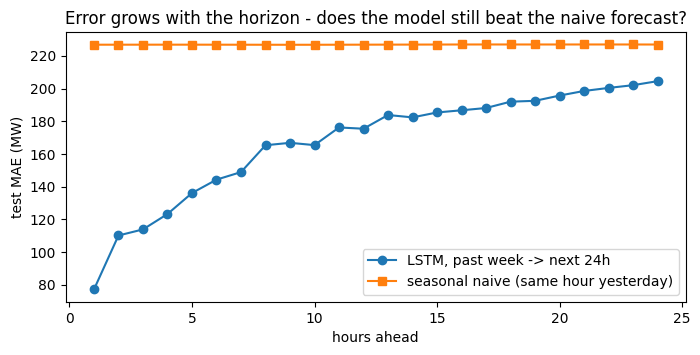

24h-ahead model MAE averaged over horizons: 167.3 MW   | seasonal naive: 226.9 MW


In [17]:
pred_s = sc_y.inverse_transform(step.predict(Xs_te, verbose=0))          # (samples, 24) in MW
true_s = sc_y.inverse_transform(ys_te)
mae_by_h = np.abs(pred_s - true_s).mean(axis=0)                            # MAE at horizon 1..24

# fair baseline at every horizon: same hour yesterday
dem_te = tem["Demand"].values
naive_by_h = np.array([mean_absolute_error(dem_te[n_in+h:len(dem_te)-n_out+h+1], dem_te[n_in+h-24:len(dem_te)-n_out+h+1-24]) for h in range(n_out)])

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 25), mae_by_h, marker="o", label="LSTM, past week -> next 24h")
plt.plot(range(1, 25), naive_by_h, marker="s", label="seasonal naive (same hour yesterday)")
plt.xlabel("hours ahead"); plt.ylabel("test MAE (MW)"); plt.title("Error grows with the horizon - does the model still beat the naive forecast?"); plt.legend(); plt.show()
print(f"24h-ahead model MAE averaged over horizons: {mae_by_h.mean():.1f} MW   | seasonal naive: {naive_by_h.mean():.1f} MW")

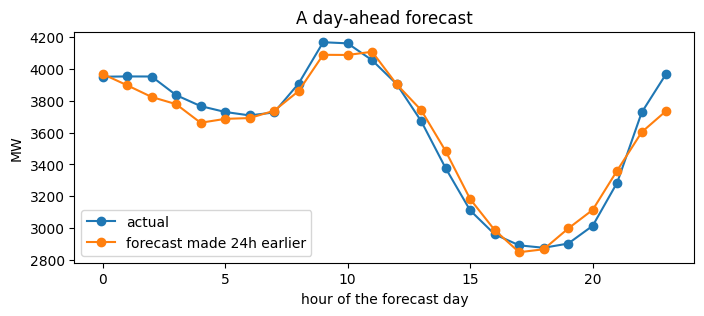

In [18]:
# one test day, all 24 hours at once
d = 200
plt.figure(figsize=(8, 3)); plt.plot(true_s[d], marker="o", label="actual"); plt.plot(pred_s[d], marker="o", label="forecast made 24h earlier")
plt.xlabel("hour of the forecast day"); plt.ylabel("MW"); plt.legend(); plt.title("A day-ahead forecast"); plt.show()

## Bonus: is this a peak hour? (classification)

The desk also wants a flag: *will this hour be one of the expensive ones?* Define a peak as the **top 10% of training-set demand**, put a **sigmoid** on the same multivariate windows, and read precision/recall - the majority-class baseline is 90%, so accuracy is useless here.

In [19]:
thr = train["Demand"].quantile(0.90)
peak_tr = (sc_y.inverse_transform(ym_tr.reshape(-1, 1)).ravel() > thr).astype(int)
peak_te = (y_true > thr).astype(int)
print(f"peak threshold: {thr:.0f} MW | peak hours in test: {peak_te.mean():.1%}  (majority baseline = {1-peak_te.mean():.1%} by always saying 'no')")

clf = Sequential([LSTM(32, input_shape=(n_steps, n_features)), Dense(1, activation="sigmoid")])
clf.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
clf.fit(Xm_tr, peak_tr, epochs=50, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)

p = (clf.predict(Xm_te, verbose=0).ravel() > 0.5).astype(int)
print(classification_report(peak_te, p, target_names=["normal hour", "PEAK hour"]))
print(confusion_matrix(peak_te, p))

peak threshold: 4231 MW | peak hours in test: 8.5%  (majority baseline = 91.5% by always saying 'no')


C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 43: early stopping


Restoring model weights from the end of the best epoch: 35.


              precision    recall  f1-score   support

 normal hour       0.99      0.99      0.99      7995
   PEAK hour       0.91      0.88      0.90       741

    accuracy                           0.98      8736
   macro avg       0.95      0.94      0.94      8736
weighted avg       0.98      0.98      0.98      8736

[[7930   65]
 [  86  655]]


## Save the model and use it again

Reproducibility is a seed **and** a saved artifact. Save the day-ahead model, reload it, prove it gives the same forecast.

In [20]:
step.save('Forecasting_Electricity_Demand_RNN_dayahead.keras')
reloaded = load_model('Forecasting_Electricity_Demand_RNN_dayahead.keras')
print("reloaded model reproduces the forecast:", np.allclose(step.predict(Xs_te[:5], verbose=0), reloaded.predict(Xs_te[:5], verbose=0)))

reloaded model reproduces the forecast: True


## On your own

- Change the look-back (6 hours? 3 days?) and watch what happens to the one-hour and 24-hour errors.
- Add a **holiday flag** - the model has never been told that July 4th isn't a Tuesday.
- Swap `LSTM` for `GRU`, then for a `Bidirectional(LSTM(...))`. One-word changes - same shapes.
- Forecast a **heat-wave week** (try mid-July 2019). Where does the model miss - the peak height, or the timing?
- Train on 2011-2019 and test on **2020**. That's what distribution shift does to a forecast.